In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import h5py


In [2]:
def generate_tuple_2D(n):
    a = []
    for i in range(2*n):
        index = (i%2==0)*int(i/2) + (i%2==1)*(n-1+int((i+1)/2))
        a.append(index)
    return(a)


def generate_tuple_3D(n):
    a = []
    for i in range(3*n):
        index = (i%3==0)*int(i/3) + (i%3==1)*(n+int((i+1)/3)) + (i%3==2)*(2*n-1+int((i+1)/3))
        a.append(index)
    return(a)

In [ ]:
generate_tuple_3D(6)

In [ ]:
#1D-Case

n = 6
x = np.linspace(0, 2*np.pi, 2**n)
y = np.sin(x)

shape_tuple = tuple([2] * n)
y_us = np.reshape(y, shape_tuple)

us = []
singular_values = []

for i in range(1, n):
    shape_u = (2**i, 2**(n-i))
    u = np.reshape(y_us, shape_u)
    _, s, _ = np.linalg.svd(u)
    us.append(u)
    singular_values.append(s)
    print(f"Shape of u{i}:", u.shape)
    print(f"Shape of s{i}:", s.shape)
    print(f"\n")


plt.figure(figsize=(10, 6))
for i, s in enumerate(singular_values):
    plt.semilogy(s, label=f'u{i+1}')

plt.title('Singular Values of Each u')
plt.xlabel('Singular Value Index')
plt.ylabel('Singular Value')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#2D Case without transpose generic 
#(x1|x3x3x4y1y2y3y4) (x1x3|x3x4y1y2y3y4) (x1x3x3|x4y1y2y3y4) ... (x1x3x3x4y1y2y3|y4)

# np.random.seed(10)

us = []
singular_values = []

n = 4
# y = np.random.rand(2**n, 2**n)
x1 = np.linspace(0, 2*np.pi, 2**n)
x3 = np.linspace(0, 2*np.pi, 2**n)
X1, x3 = np.meshgrid(x1, x3)
y = np.sin(X1) * np.exp(x3**2)

for i in range(1, 2*n):
    shape_u = (2**i, 2**(2*n-i))
    u = np.reshape(y, shape_u)
    _, s, _ = np.linalg.svd(u)
    us.append(u)
    singular_values.append(s)
    print(f"Shape of u{i}:", u.shape)
    print(f"Shape of s{i}:", s.shape)
    print(f"\n")

plt.figure(figsize=(10, 6))
for i, s in enumerate(singular_values):
    plt.semilogy(s, label=f'u{i+1}')

plt.title('Singular Values of Each u')
plt.xlabel('Singular Value Index')
plt.ylabel('Singular Value')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
#2D Case with transpose generic form (x1y1|x3y2x3y3x4yx4) (x1y1x3y2|x3y3x4yx4) (x1y1x3y2x3y3|x4yx4)
#y = np.sin(X1) * np.exp(x3**2)

# np.random.seed(10)

us = []
singular_values = []

n = 8
# y = np.random.rand(2**n, 2**n)
x1 = np.linspace(0, 2*np.pi, 2**n)
x3 = np.linspace(0, 2*np.pi, 2**n)
X1, x3 = np.meshgrid(x1, x3)
y = np.sin(X1) * np.exp(x3**2)


shape_tuple = tuple([2] * 2*n)
y = np.reshape(y, shape_tuple)
transpose_tuple = generate_tuple_2D(n)
y = np.transpose(y,transpose_tuple)

for i in range(1, n):
    shape_u = (2**(2*i), 2**(2*n-2*i))
    u = np.reshape(y, shape_u)
    _, s, _ = np.linalg.svd(u)
    us.append(u)
    singular_values.append(s)
    print(f"Shape of u{i}:", u.shape)
    print(f"Shape of s{i}:", s.shape)
    print(f"\n")


plt.figure(figsize=(10, 6))
for i, s in enumerate(singular_values):
    plt.semilogy(s, label=f'u{i+1}')

plt.title('Singular Values of Each u')
plt.xlabel('Singular Value Index')
plt.ylabel('Singular Value')
plt.legend()
plt.grid(True)
plt.show()

sv = np.zeros((n-1, 4**(int(n/2))))
for i in range(n-1):
    sv[i,0:len(singular_values[i])] = singular_values[i]

np.save('sv256.npy', sv)

In [ ]:
generate_tuple_2D(4)

In [ ]:

data = loadmat('u_t_2.00s_64.mat')
variable_names = list(data.keys())

print("Variables in the MATLAB file:")
for name in variable_names:
    print(name)

In [ ]:
#1D-Case

n = 6
data = loadmat('u_t_2.00s_64.mat')
vel = data['result_3D']
slice = 31
y = vel[:, slice, slice]

shape_tuple = tuple([2] * n)
y_us = np.reshape(y, shape_tuple)

us = []
singular_values = []

for i in range(1, n):
    shape_u = (2**i, 2**(n-i))
    u = np.reshape(y_us, shape_u)
    _, s, _ = np.linalg.svd(u)
    us.append(u)
    singular_values.append(s)
    print(f"Shape of u{i}:", u.shape)
    print(f"Shape of s{i}:", s.shape)
    print(f"\n")


plt.figure(figsize=(10, 6))
for i, s in enumerate(singular_values):
    plt.semilogy(s, label=f'u{i+1}')

plt.title('Singular Values of Each u')
plt.xlabel('Singular Value Index')
plt.ylabel('Singular Value')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#2D Case with transpose generic form (x1y1|x3y2x3y3x4yx4) (x1y1x2y2|x3y3x4yx4) (x1y1x2y2x3y3|x4yx4)
#y = 2D u velocity at a channel flow at t=2.00 (s) grid 64x64x64

us = []
singular_values = []
n = 7

### Channel flow data

# data = loadmat('u_t_2.00s_128.mat')
data = loadmat('Channelflow_grid_128_mat/w_t_3.00s.mat')
file_path = 'Channelflow_grid_128_npy/SV_w3'
vel = data['result_3D']
slice = 31
y = vel[:, :, slice]


### Isotropic turb data
# with h5py.File('ut_0.h5', 'r') as file:
#     velocity_dataset = file['Velocity_0001']   
#     vel = velocity_dataset[()]
#
# y = vel[:, :, slice, 1] # u = (u1,u2,u3) -> u1 = vel[:, :, :, 1]
# file_path = 'SVt_u0'


shape_tuple = tuple([2] * 2*n)
y = np.reshape(y, shape_tuple)
transpose_tuple = generate_tuple_2D(n)
y = np.transpose(y,transpose_tuple)

for i in range(1, n):
    shape_u = (2**(2*i), 2**(2*n-2*i))
    u = np.reshape(y, shape_u)
    _, s, _ = np.linalg.svd(u)
    us.append(u)
    singular_values.append(s)
    print(f"Shape of u{i}:", u.shape)
    print(f"Shape of s{i}:", s.shape)
    print(f"\n")


plt.figure(figsize=(10, 6))
for i, s in enumerate(singular_values):
    plt.semilogy(s, label=f'u{i+1}')

plt.title('Singular Values of Each u')
plt.xlabel('Singular Value Index')
plt.ylabel('Singular Value')
plt.legend()
plt.grid(True)
plt.show()

sv = np.zeros((n-1, 4**(int(n/2))))
for i in range(n-1):
    sv[i,0:len(singular_values[i])] = singular_values[i]

np.save(file_path, sv)

In [ ]:
#3D Case with transpose generic form (x1y1z1|x2y2z2x3y3z3x4yx4z4) (x1y1z1x2y2z2|x3y3z3x4yx4z4) (x1y1z1x2y2z2x3y3z3|x4yx4z4)
#y = 3D u velocity at a channel flow at t=2.00 (s) grid 64x64x64

us = []
singular_values = []
n = 6

### Channel flow data

# data = loadmat('u_t_2.00s_64.mat')
# data = loadmat('/Channelflow/03 Grid 256/Channelflow_grid_256_h5/U_t201_whole_domain_256x256x256.mat')
# file_path = 'Channelflow_grid_64_npy/SV_w1'
# y = data['result_3D']

file_path = 'Forced_Isotropic/01 Grid 64/Forced_Isotropic_64Cubed_h5/U_t0.h5'
### Isotropic turb data

with h5py.File(file_path, 'r') as file:
    velocity_dataset = file['Velocity_0001']   
    vel = velocity_dataset[()]

y = vel[:, :, :, 1] # u = (u1,u2,u3) -> u1 = vel[:, :, :, 1], u2 = vel[:, :, :, 2, u3 = vel[:, :, :, 3]


shape_tuple = tuple([2] * 3*n)
y = np.reshape(y, shape_tuple)
transpose_tuple = generate_tuple_3D(n)
y = np.transpose(y,transpose_tuple)

for i in range(1, n):
    shape_u = (2**(3*i), 2**(3*n-3*i))
    u = np.reshape(y, shape_u)
    _, s, _ = np.linalg.svd(u)
    us.append(u)
    singular_values.append(s)
    print(f"Shape of u{i}:", u.shape)
    print(f"Shape of s{i}:", s.shape)
    print(f"\n")


plt.figure(figsize=(10, 6))
for i, s in enumerate(singular_values):
    plt.semilogy(s, label=f'u{i+1}')

plt.title('Singular Values of Each u')
plt.xlabel('Singular Value Index')
plt.ylabel('Singular Value')
plt.legend()
plt.grid(True)
plt.show()

sv = np.zeros((n-1, 8**(int(n/2))))
for i in range(n-1):
    sv[i,0:len(singular_values[i])] = singular_values[i]

np.save(file_path, sv)

In [ ]:
#3D Case with transpose generic form (x1y1z1|x2y2z2x3y3z3x4yx4z4) (x1y1z1x2y2z2|x3y3z3x4yx4z4) (x1y1z1x2y2z2x3y3z3|x4yx4z4)
#y = 3D u velocity at a channel flow at t=2.00 (s) grid 64x64x64

us = []
singular_values = []
n = 6

### Channel flow data

# data = loadmat('u_t_2.00s_64.mat')
# data = loadmat('/Channelflow/03 Grid 256/Channelflow_grid_256_h5/U_t201_whole_domain_256x256x256.mat')
# file_path = 'Channelflow_grid_64_npy/SV_w1'
# y = data['result_3D']

file_path = 'Forced_Isotropic/01 Grid 64/Forced_Isotropic_64Cubed_h5/U_t0.h5'
### Isotropic turb data

with h5py.File(file_path, 'r') as file:
    velocity_dataset = file['Velocity_0001']   
    vel = velocity_dataset[()]

y = vel[:, :, :, 0] # u = (u1,u2,u3) -> u1 = vel[:, :, :, 1], u2 = vel[:, :, :, 2], u3 = vel[:, :, :, 3]


shape_tuple = tuple([2] * 3*n)
y = np.reshape(y, shape_tuple)
transpose_tuple = generate_tuple_3D(n)
y = np.transpose(y,transpose_tuple)

for i in range(1, n):
    shape_u = (2**(3*i), 2**(3*n-3*i))
    u = np.reshape(y, shape_u)
    _, s, _ = np.linalg.svd(u)
    us.append(u)
    singular_values.append(s)
    print(f"Shape of u{i}:", u.shape)
    print(f"Shape of s{i}:", s.shape)
    print(f"\n")


plt.figure(figsize=(10, 6))
for i, s in enumerate(singular_values):
    plt.semilogy(s, label=f'u{i+1}')

plt.title('Singular Values of Each u')
plt.xlabel('Singular Value Index')
plt.ylabel('Singular Value')
plt.legend()
plt.grid(True)
plt.show()

sv = np.zeros((n-1, 8**(int(n/2))))
for i in range(n-1):
    sv[i,0:len(singular_values[i])] = singular_values[i]

np.save(file_path, sv)

In [ ]:
#3D Case with transpose generic form (x1y1z1|x2y2z2x3y3z3x4yx4z4) (x1y1z1x2y2z2|x3y3z3x4yx4z4) (x1y1z1x2y2z2x3y3z3|x4yx4z4)

import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import scipy as sp
import h5py
import time
from sympy import factorint
from math import prod

from velocity_name import velocity_name_FI, velocity_name_ChF
from save_as_mat import save_as_mat

from combine_parts import combine_parts
from MPS_permute import MPS_permute_uneq, MPS_permute
from CritChis_uneq import CritChis_uneq
from FindSingValsAndEntEntr import FindSingValsAndEntEntr_uneq
from prime_sort import prime_sort
from reshape_and_transpose import reshape_and_transpose, inverse_reshape_and_transpose
from comp_ratio_uneq import comp_ratio_uneq
from calculate_u_comp_fidelity_l2norm import calculate_fidelity, calculate_l2norm, calculate_u_comp_fidelity_l2
from process_file import process_file


from Massen_Lib.calculate_eps_stilda import calculate_dissipation_rate
from calculate_gradients import calculate_gradients, calculate_gradients_fidelities
from calculate_tkEnergy import calculate_tkEnergy
from central_difference_3d import central_difference_3d 
from calculate_flow_parameters_comb import calculate_flow_parameters_comb



In [ ]:
from process_file import process_file
import numpy as np
from save_as_mat import save_as_h5

    # file_path = f'Forced_Isotropic/02 Grid 128/Forced_Isotropic_128Cubed_SubDomain_mat/{file_name}.mat'
    # file_path = f'Forced_Isotropic/02 Grid 128/Forced_Isotropic_128Cubed_SubDomain_h5/{file_name}.h5'
    # file_path = f'../Forced_Isotropic/01 Grid 64/Forced_Isotropic_64Cubed_h5/{file_name}.h5'
    # file_path = f'Forced_Isotropic/3 Grid 256/Forced_Isotropic_256Cubed_SubDomain_h5/{file_name}.h5'
    # file_path = f'../../../Forced_Isotropic_512Cubed_SubDomain_h5/{file_name}.h5'
    # file_path = f'Forced_Isotropic/4 Grid 512/Forced_Isotropic_512Cubed_SubDomain_h5/{file_name}.h5'
    # file_path = f'Channelflow/3D/21 Grid 512x512x512_Part1_h5/{file_name}.h5'
    # file_path = f'Channelflow/3D/31 Grid 2048x512x1536_h5/{file_name}.h5'
    # file_path = f'Channelflow/3D/62 Grid 256x64x128_h5/{file_name}.h5'

file_case = 'Forced_Isotropic'
file_name = 'U_t1'
file_format = '.h5'
file_path = f'../{file_case}/01 Grid 64/Forced_Isotropic_64Cubed_h5/{file_name}{file_format}'

result = process_file(file_case,file_name,file_format,file_path)
RT = result['RunTime']
print(f'Time taken to process {file_name}: {RT:.2f} seconds')
print("Chi_max:",np.transpose(result['Chi_max']))
file_name = 'SingVals_t1_2048x512x1536'
save_as_h5(file_name,result)


In [ ]:

import sys
mps_codes_path = "/ix/pgivi/moe32/Schmidt/Nik_code/code/AnalysingResultsFromDNS_demo/ComputationalSpaces/mps_py_codes"

# Add the absolute path to the folder
sys.path.append(mps_codes_path)

from process_file import process_file
import numpy as np
from save_as_h5 import save_as_mat


In [ ]:
import h5py

file_name = 'U_t1'
file_path = f'../Forced_Isotropic/01 Grid 64/Forced_Isotropic_64Cubed_h5/{file_name}.h5'
vel_name = velocity_name_FI(file_name)

# If it's a .h5 file
with h5py.File(file_path, 'r') as sa:
    # Print all keys in the HDF5 file
    print("Keys in the file:")
    for key in sa.keys():
        print(f"Key: {key}")

        # Print the corresponding shape or data type of each key
        data = sa[key]
        print(f"Shape: {data.shape} | Type: {data.dtype}")
        
        # If you want to see a preview of the data, uncomment the line below
        # print(f"Data preview: {data[()][:5]}")  # Preview first 5 elements


In [ ]:
import h5py

file_name = 'U_t1'
file_path = f'../Forced_Isotropic/01 Grid 64/Forced_Isotropic_64Cubed_h5/{file_name}.h5'
vel_name = velocity_name_FI(file_name)

# If it's a .h5 file
with h5py.File(file_path, 'r') as sa:
    # Access the keys and store their values in variables
    vel = sa['Velocity_0501'][()]  # Read the velocity data
    xcoor = sa['xcoor'][()]              # Read x coordinates
    ycoor = sa['ycoor'][()]              # Read y coordinates
    zcoor = sa['zcoor'][()]              # Read z coordinates

u = vel[:, :, :, 0]
v = vel[:, :, :, 1]
w = vel[:, :, :, 2]

xyz_tuple = (2,1,0)
u = np.transpose(u,xyz_tuple)
v = np.transpose(v,xyz_tuple)
w = np.transpose(w,xyz_tuple)

# Now you have the datasets saved in variables
print("Velocity shape:", vel.shape)
print("X coordinates shape:", xcoor.shape)
print("Y coordinates shape:", ycoor.shape)
print("Z coordinates shape:", zcoor.shape)


In [ ]:
import pandas as pd

u_table = np.squeeze(result['co_cr_fid_l2_U'])  # Remove the extra dimension to make it (4, 3)
parameter_names = ['Cutoff', 'Compression Ratio', 'Fidelity', 'L2 Norm']
df = pd.DataFrame(u_table.T, columns=parameter_names)
print(df)

In [ ]:
from process_file import process_file
import numpy as np
from save_as_mat import save_as_mat
import h5py

file_case = 'Forced_Isotropic'
file_name = 'U_t1'
file_format = '.h5'
# file_path = f'../{file_case}/01 Grid 64/Forced_Isotropic_64Cubed_h5/{file_name}{file_format}'
file_path = f'../Forced_Isotropic/02 Grid 128/Forced_Isotropic_128Cubed_WholeDomain_h5/{file_name}{file_format}'

vel_index = 1
result_u = process_file(file_case,file_name,file_format,file_path,vel_index)
output_name = f'SingVals_{file_case}_{file_name}_U{vel_index}_128cubed'
save_as_mat(output_name,result_u)


vel_index = 2
result_v = process_file(file_case,file_name,file_format,file_path,vel_index)
output_name = f'SingVals_{file_case}_{file_name}_U{vel_index}_128cubed'
save_as_mat(output_name,result_v)

vel_index = 3
result_w = process_file(file_case,file_name,file_format,file_path,vel_index)
output_name = f'SingVals_{file_case}_{file_name}_U{vel_index}_128cubed'
save_as_mat(output_name,result_w)





In [ ]:
from process_file import process_file
import numpy as np
from save_as_mat import save_as_mat

file_name = 'U_t1'
result = process_file(file_name,1)
RT = result['RunTime']
print(f'Time taken to process {file_name}: {RT:.2f} seconds')
print("Chi_max:",np.transpose(result['Chi_max']))
file_name = 'SingVals_t1_2048x512x1536'
save_as_mat(file_name,result)

In [ ]:
from process_file import process_file
import numpy as np
from save_as_mat import save_as_mat
import h5py

file_case = 'Forced_Isotropic'
file_name = 'U_t1'
file_format = '.h5'
# file_path = f'../{file_case}/01 Grid 64/Forced_Isotropic_64Cubed_h5/{file_name}{file_format}'
file_path = f'../Forced_Isotropic/02 Grid 128/Forced_Isotropic_128Cubed_WholeDomain_h5/{file_name}{file_format}'

vel_index = 1
result_u = process_file(file_case,file_name,file_format,file_path,vel_index)
output_name = f'SingVals_{file_case}_{file_name}_U{vel_index}_128cubed'
save_as_mat(output_name,result_u)



In [ ]:
from compare_org_comp import compare_org_comp
from save_as_mat import save_as_mat

org_case = 'Forced_Isotropic'
org_name = 'U_t1'
# org_path = f'../Forced_Isotropic/01 Grid 64/Forced_Isotropic_64Cubed_h5/{org_name}.h5'
org_path = f'../Forced_Isotropic/02 Grid 128/Forced_Isotropic_128Cubed_WholeDomain_h5/{org_name}.h5'
# org_path = f'../../Forced_Isotropic_512Cubed_SubDomain_h5/{org_name}.h5'

# comp_path_1 = f'SingVals_Forced_Isotropic_U_t1_U1_64cubed.mat'
# comp_path_2 = f'SingVals_Forced_Isotropic_U_t1_U2_64cubed.mat'
# comp_path_3 = f'SingVals_Forced_Isotropic_U_t1_U3_64cubed.mat'

comp_path_1 = f'SingVals_Forced_Isotropic_U_t1_U1_128cubed.mat'
comp_path_2 = f'SingVals_Forced_Isotropic_U_t1_U2_128cubed.mat'
comp_path_3 = f'SingVals_Forced_Isotropic_U_t1_U3_128cubed.mat'

# comp_path_1 = f'SingVals_U_t1_U_512cubed.mat'
# comp_path_2 = f'SingVals_U_t1_V_512cubed.mat'
# comp_path_3 = f'SingVals_U_t1_W_512cubed.mat'


comp_paths = [comp_path_1, comp_path_2, comp_path_3]

# flow_parameters_central,spectrum_central = compare_org_comp(org_case,org_name,org_path,comp_paths, finite_diff_scheme='central')

# # Output the calculated flow parameters
# print("Flow Parameters (Central) for e2, e3, e4 components:")
# for comp, params in flow_parameters_central.items():
#     print(f"{comp}: {params} \n")

flow_parameters_4th_order,spectrum_4th_order = compare_org_comp(org_case,org_name,org_path,comp_paths, finite_diff_scheme='4th_order_periodic')

# Output the calculated flow parameters
print("Flow Parameters (4th order) for e2, e3, e4 components:")
for comp, params in flow_parameters_4th_order.items():
    print(f"{comp}: {params} \n")

# save_as_mat('flow_parameters_central', flow_parameters_central)
save_as_mat('flow_parameters_4th_order', flow_parameters_4th_order)
# save_as_mat('spectrum_central', spectrum_central)
save_as_mat('spectrum_4th_order', spectrum_4th_order)


In [ ]:
from calculate_u_comp_fidelity_l2norm import calculate_fidelity, calculate_l2norm
from comp_ratio_uneq import comp_ratio_uneq
from process_file_1024 import load_JHS_velocity_1024, load_JHS_velocity_1024_jul
from save_as_mat import save_as_mat
import numpy as np

cutoff = 1e-2
# comp_path_u = f'truncated_u_1024_il_cf0.01.mat'
# comp_path_v = f'truncated_v_1024_il_cf0.01.mat'
# comp_path_w = f'truncated_w_1024_il_cf0.01.mat'

# org_path_u = f'../../../Forced_Isotropic_1024Cubed_mat_in_one/U_t1.mat'
# org_path_v = f'../../../Forced_Isotropic_1024Cubed_mat_in_one/V_t1.mat'
# org_path_w = f'../../../Forced_Isotropic_1024Cubed_mat_in_one/W_t1.mat'


org_path_u = f'../Forced_Isotropic/02 Grid 128/U_t1.mat'
org_path_v = f'../Forced_Isotropic/02 Grid 128/V_t1.mat'
org_path_w = f'../Forced_Isotropic/02 Grid 128/W_t1.mat'

comp_path_u = f'../Julia/truncated_u_il_data.mat'
comp_path_v = f'../Julia/truncated_v_il_data.mat'
comp_path_w = f'../Julia/truncated_w_il_data.mat'

u = load_JHS_velocity_1024(org_path_u)
v = load_JHS_velocity_1024(org_path_v)
w = load_JHS_velocity_1024(org_path_w)
# u = u-np.mean(u)
# v = v-np.mean(v)
# w = w-np.mean(w)

u_comp, chi_u = load_JHS_velocity_1024_jul(comp_path_u)
v_comp, chi_v = load_JHS_velocity_1024_jul(comp_path_v)
w_comp, chi_w = load_JHS_velocity_1024_jul(comp_path_w)
u_comp = u_comp-np.mean(u_comp)
v_comp = v_comp-np.mean(v_comp)
w_comp = w_comp-np.mean(w_comp)


chi_u = np.expand_dims(chi_u, axis=1)
chi_v = np.expand_dims(chi_v, axis=1)
chi_w = np.expand_dims(chi_w, axis=1)
u_size = (2,) *3* int(np.log2(u.shape[0]))

cr_u = comp_ratio_uneq(chi_u,u_size)
cr_v = comp_ratio_uneq(chi_v,u_size)
cr_w = comp_ratio_uneq(chi_w,u_size)
fidelity_u = calculate_fidelity(u, u_comp)
fidelity_v = calculate_fidelity(v, v_comp)
fidelity_w = calculate_fidelity(w, w_comp)
l2_norm_u = calculate_l2norm(u, u_comp)
l2_norm_v = calculate_l2norm(v, v_comp)
l2_norm_w = calculate_l2norm(w, w_comp)

print("cutoff: ", cutoff)
print("cr_u: ", cr_u, "cr_v: ", cr_v, "cr_w: ", cr_w)
print("fidelity_u: ", fidelity_u, "fidelity_v: ", fidelity_v, "fidelity_w: ", fidelity_w)
print("l2_norm_u: ", l2_norm_u, "l2_norm_v: ", l2_norm_v, "l2_norm_w: ", l2_norm_w)

output = {
    'cutoff': cutoff,
    'chi_u': chi_u,
    'chi_v': chi_v,
    'chi_w': chi_w,
    'cr_u': cr_u,
    'cr_v': cr_v,
    'cr_w': cr_w,
    'fidelity_u': fidelity_u,
    'fidelity_v': fidelity_v,
    'fidelity_w': fidelity_w,
    'l2_norm_u': l2_norm_u,
    'l2_norm_v': l2_norm_v,
    'l2_norm_w': l2_norm_w}

save_as_mat(f'chi_cr_fidelity_l2norm_cf_{cutoff}', output)

In [7]:
u_reshaped = np.reshape(u,(2**14,2**7))
U,S,V = np.linalg.svd(u_reshaped)
u(1:3,1,1)

In [ ]:
# np.sum(S[0:96]**2)/np.sum(S[:]**2)
# print(S[1:4])
# print(S[1:4]**2)
# np.sum(S[:]**2)

In [ ]:
from process_file_1024 import load_JHS_velocity_1024, load_JHS_velocity_1024_jul
from calculate_flow_parameters_comb import calculate_flow_parameters_comb
from save_as_mat import save_as_mat
import numpy as np
import json

cutoff = 1e-2
# comp_path_u = f'truncated_u_1024_il_cf0.01.mat'
# comp_path_v = f'truncated_v_1024_il_cf0.01.mat'
# comp_path_w = f'truncated_w_1024_il_cf0.01.mat'

# org_path_u = f'../../../Forced_Isotropic/5 Grid 1024/Forced_Isotropic_1024Cubed_mat_in_one/U_t1.mat'
# org_path_v = f'../../../Forced_Isotropic/5 Grid 1024/Forced_Isotropic_1024Cubed_mat_in_one/V_t1.mat'
# org_path_w = f'../../../Forced_Isotropic/5 Grid 1024/Forced_Isotropic_1024Cubed_mat_in_one/W_t1.mat'


# comp_path_u = f'../Julia/truncated_u_il_data.mat'
# comp_path_v = f'../Julia/truncated_v_il_data.mat'
# comp_path_w = f'../Julia/truncated_w_il_data.mat'

# org_path_u = f'../Forced_Isotropic/02 Grid 128/U_t1.mat'
# org_path_v = f'../Forced_Isotropic/02 Grid 128/V_t1.mat'
# org_path_w = f'../Forced_Isotropic/02 Grid 128/W_t1.mat'

with open("config_FI.json", "r") as f:
    config = json.load(f)

comp_path = config.get("128_comp", {})
org_path = config.get("128_dns", {})

comp_path_u = comp_path['vel'][0]
comp_path_v = comp_path['vel'][1]
comp_path_w = comp_path['vel'][2]

org_path_u = org_path['vel'][0]
org_path_v = org_path['vel'][1]
org_path_w = org_path['vel'][2]


u = load_JHS_velocity_1024(org_path_u)
v = load_JHS_velocity_1024(org_path_v)
w = load_JHS_velocity_1024(org_path_w)
u = u-np.mean(u)
v = v-np.mean(v)
w = w-np.mean(w)

u_comp, chi_u = load_JHS_velocity_1024_jul(comp_path_u)
v_comp, chi_v = load_JHS_velocity_1024_jul(comp_path_v)
w_comp, chi_w = load_JHS_velocity_1024_jul(comp_path_w)
u_comp = u_comp-np.mean(u_comp)
v_comp = v_comp-np.mean(v_comp)
w_comp = w_comp-np.mean(w_comp)

nu= 0.000185
# dx = 0.0061359406
dx = 0.049087387
dy = dx
dz = dx

flow_parameters, spectrum = calculate_flow_parameters_comb((u, v, w), (u_comp, v_comp, w_comp), (dx, dy, dz))
# flow_parameters, spectrum = calculate_flow_parameters_comb((u, v, w), (u, v, w), (dx, dy, dz))

save_as_mat(f'flow_parameters_cf_{cutoff}', flow_parameters)
save_as_mat(f'spectrum_cf_{cutoff}', spectrum)

print(f'Flow Parameters for cutoff = {cutoff} components:')
for comp, params in flow_parameters.items():
    converted_params = [float(p) for p in params]
    print(f"{comp}:\n{converted_params} \n")

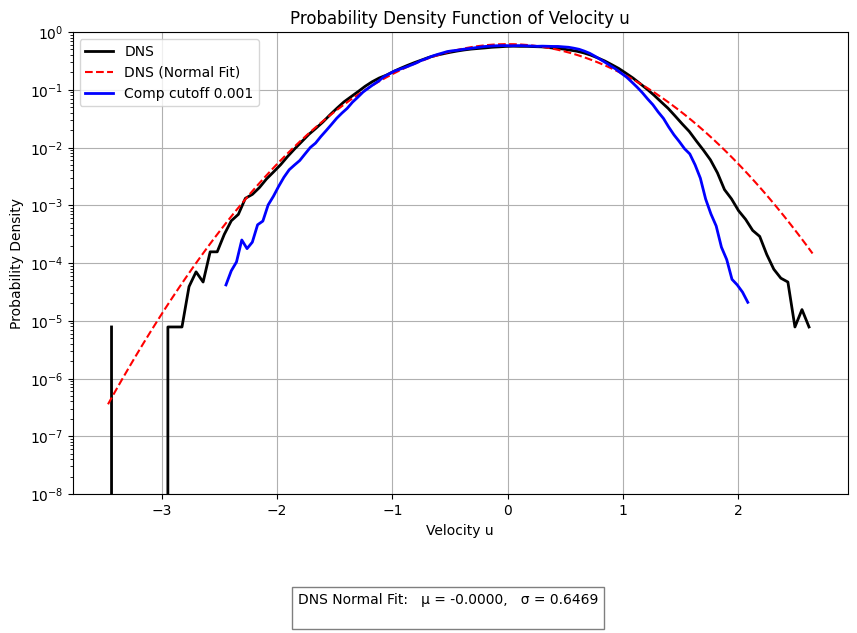

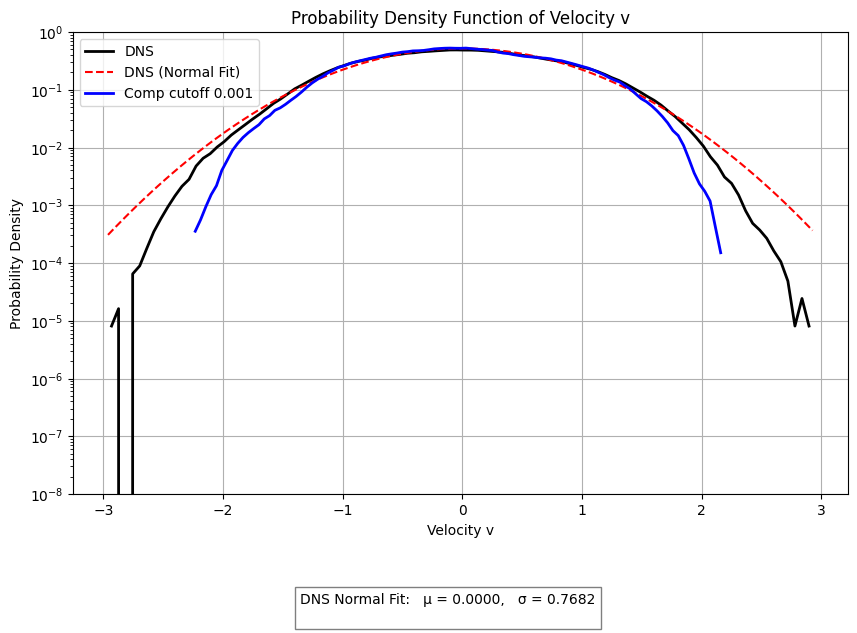

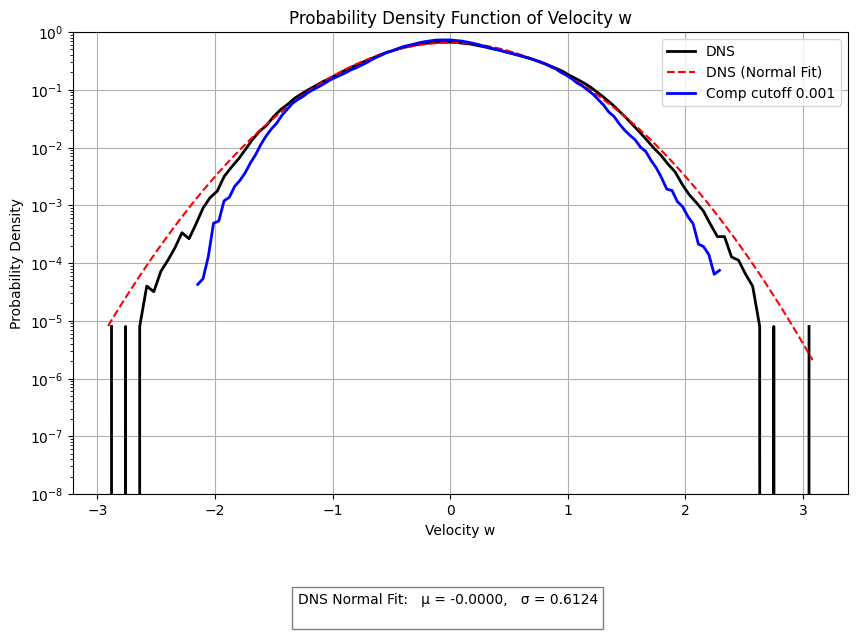

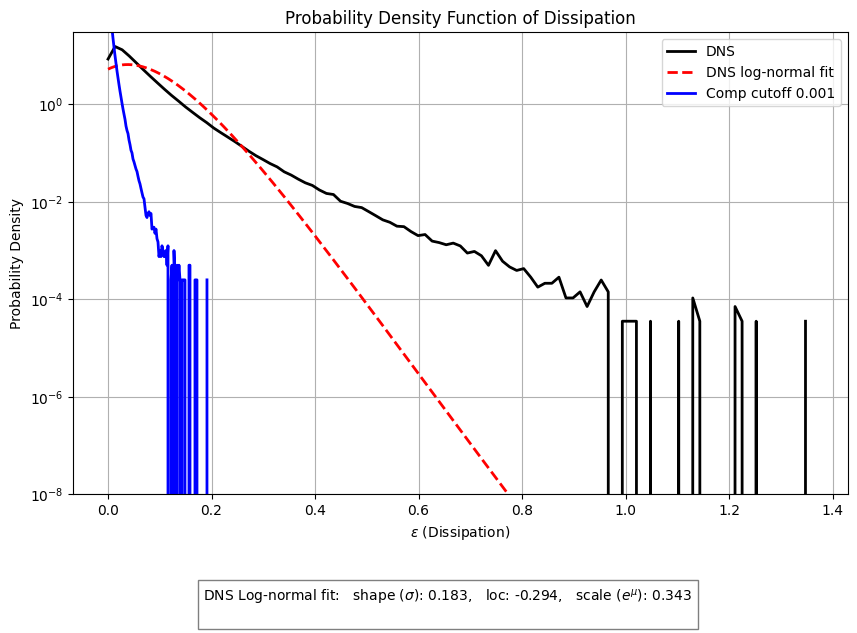

In [ ]:
#PDF velocity and dissipation rate

import numpy as np
import h5py
from process_file_1024 import load_JHS_velocity_1024, load_JHS_velocity_1024_jul
from calculate_flow_parameters_comb import calculate_flow_parameters_comb
from plotting import plot_pdf, plot_pdf_eps
from process_file_1024 import load_JHS_velocity_1024_jul
import json

cutoff = 1e-3

# mps_codes_path = "/ix/pgivi/moe32/Schmidt/Nik_code/code/AnalysingResultsFromDNS_demo/ComputationalSpaces/mps_py_codes"
# config_path = mps_codes_path + "/config_FI.json"
# with open(config_path, "r") as f:
#     config = json.load(f)
# org_path = config.get("full_dns", {})


with open("config_FI.json", "r") as f:
    config = json.load(f)

comp_path = config.get("128_comp", {})
comp_path_u = comp_path['vel'][0]
comp_path_v = comp_path['vel'][1]
comp_path_w = comp_path['vel'][2]

org_path = config.get("128_dns", {})

u = load_JHS_velocity_1024(org_path['vel'][0])
v = load_JHS_velocity_1024(org_path['vel'][1])
w = load_JHS_velocity_1024(org_path['vel'][2])
with h5py.File(org_path['disp'], 'r') as file:
    eps = np.array(file['eps'])


u_comp, _ = load_JHS_velocity_1024_jul(comp_path_u)
v_comp, _ = load_JHS_velocity_1024_jul(comp_path_v)
w_comp, _ = load_JHS_velocity_1024_jul(comp_path_w)
with h5py.File('dissipation_comp.mat', 'r') as file:
    eps_comp = np.array(file['eps_comp'])

pdf_min = 1e-8
pdf_max = 1

plot_pdf({'DNS':u, f'Comp cutoff {cutoff}':u_comp}, title='Velocity u',
         file_name='Velocity_u_1024Cubed', pdf_min=pdf_min, pdf_max=pdf_max)

plot_pdf({'DNS':v, f'Comp cutoff {cutoff}':v_comp}, title='Velocity v',
         file_name='Velocity_v_1024Cubed', pdf_min=pdf_min, pdf_max=pdf_max)

plot_pdf({'DNS':w, f'Comp cutoff {cutoff}':w_comp}, title='Velocity w',
         file_name='Velocity_w_1024Cubed', pdf_min=pdf_min, pdf_max=pdf_max)

plot_pdf_eps({'DNS': eps, f'Comp cutoff {cutoff}': eps_comp})


In [ ]:
import scipy.io
import matplotlib.pyplot as plt
from calculate_spectrum import calculate_spectrum
from process_file import load_JHS_velocity
from process_file_1024 import load_JHS_velocity_1024
from compute_URDNS import compute_URDNS_uvw

org_case = 'Forced_Isotropic'
org_name = 'U_t1'
# org_path = f'../Forced_Isotropic/01 Grid 64/Forced_Isotropic_64Cubed_h5/{org_name}.h5'
# org_path = f'../Forced_Isotropic/02 Grid 128/Forced_Isotropic_128Cubed_WholeDomain_h5/{org_name}.h5'
org_path = f'../Forced_Isotropic/02 Grid 128/Forced_Isotropic_128Cubed_SubDomain_h5/{org_name}.h5'

# org_path_u = f'../Forced_Isotropic/02 Grid 128/U_t1.mat'
# org_path_v = f'../Forced_Isotropic/02 Grid 128/V_t1.mat'
# org_path_w = f'../Forced_Isotropic/02 Grid 128/w_t1.mat'

# org_path = f'../Forced_Isotropic/03 Grid 256/Forced_Isotropic_256Cubed_SubDomain_h5/{org_name}.h5'

u,v,w,xcoor,ycoor,zcoor = load_JHS_velocity(org_path)
# u = load_JHS_velocity_1024(org_path_u)
# v = load_JHS_velocity_1024(org_path_v)
# w = load_JHS_velocity_1024(org_path_w)
k_128,spec_128 = calculate_spectrum(u,v,w)

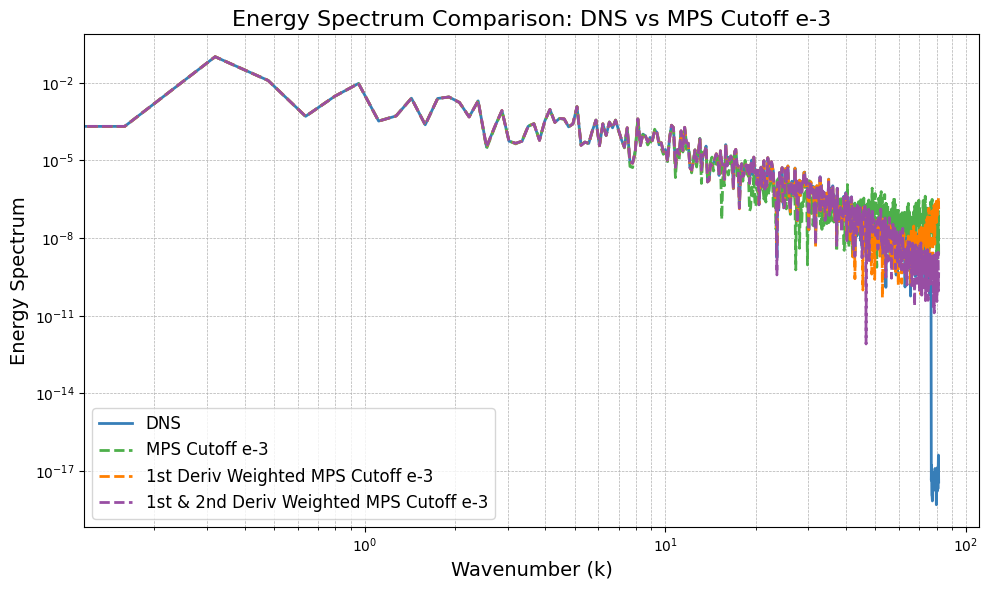

In [17]:
#1D spectrum weighted mps

import matplotlib.pyplot as plt
import h5py
from scipy.io import loadmat
from calculate_spectrum import calculate_1d_spectrum

# Define the file path
file_path = '../Forced_Isotropic/04 Grid 1024 line/Us.mat'
mat_data = loadmat(file_path)
u1x = mat_data['U1x']
u1y = mat_data['U1y']
u1z = mat_data['U1z']

file_path_comp    = '../Julia/Forced_Isotropic_line_comp_mps/truncated_u1z_1024line_sp_cf0.001.mat'
file_path_comp_Dx = '../Julia/Forced_Isotropic_line_comp_mps/truncated_u1z_1024line_sp_cf0.001_weighted_Dx.mat'
file_path_comp_Dx_Dxx = '../Julia/Forced_Isotropic_line_comp_mps/truncated_u1z_1024line_sp_cf0.001_weighted_Dx_Dxx.mat'

with h5py.File(file_path_comp, 'r') as file:
    u_comp   = file['u'][()]
    chi_comp = file['chi_crit'][()]

with h5py.File(file_path_comp_Dx, 'r') as file:
    u_comp_Dx   = file['u'][()]
    chi_comp_Dx = file['chi_crit'][()]    

with h5py.File(file_path_comp_Dx_Dxx, 'r') as file:
    u_comp_Dx_Dxx   = file['u'][()]
    chi_comp_Dx_Dxx = file['chi_crit'][()]   

k,spec = calculate_1d_spectrum(u1z[:,0])
k_comp,spec_comp = calculate_1d_spectrum(u_comp)
k_comp_Dx,spec_comp_Dx = calculate_1d_spectrum(u_comp_Dx)
k_comp_Dx_Dxx,spec_comp_Dx_Dxx = calculate_1d_spectrum(u_comp_Dx_Dxx)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

colors = ['#377eb8', '#4daf4a', '#ff7f00', '#984ea3', '#e41a1c']

ax.plot(k, spec, label='DNS', linestyle='-', linewidth=2, color=colors[0])
ax.plot(k_comp, spec_comp, label='MPS Cutoff e-3', linestyle='--', linewidth=2, color=colors[1])
ax.plot(k_comp_Dx, spec_comp_Dx, label='1st Deriv Weighted MPS Cutoff e-3', linestyle='--', linewidth=2, color=colors[2])
ax.plot(k_comp_Dx_Dxx, spec_comp_Dx_Dxx, label='1st & 2nd Deriv Weighted MPS Cutoff e-3', linestyle='--', linewidth=2, color=colors[3])

# ax.plot(k, spec, label='DNS', linestyle='-', linewidth=2, color='blue')
# ax.plot(k_comp, spec_comp, label='MPS Cutoff e-3', linestyle='--', linewidth=2, color='orange')
# ax.plot(k_comp_Dx, spec_comp_Dx, label='1st Deriv Weighted MPS Cutoff e-3', linestyle='--', linewidth=2, color='green')
# ax.plot(k_comp_Dx_Dxx, spec_comp_Dx_Dxx, label='1st & 2nd Deriv Weighted MPS Cutoff e-3', linestyle='--', linewidth=2, color='red')
ax.set_xscale('log')
ax.set_yscale('log')
# Add grid
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
# ax.set_xlim(10, 76)
# ax.set_ylim(1e-13, 1e-3)

# Add labels and title
ax.set_xlabel('Wavenumber (k)', fontsize=14)
ax.set_ylabel('Energy Spectrum', fontsize=14)
ax.set_title('Energy Spectrum Comparison: DNS vs MPS Cutoff e-3', fontsize=16)

# Customize legend
ax.legend(loc='lower left', fontsize=12)

# Display the plot
plt.tight_layout()
# plt.savefig('spectrum_plot_512Cubed.png', dpi=300, bbox_inches='tight')
plt.show()



L2 Error β = 0:  0.00024130110689942963

L2 Error β = 1.0e-6:  0.00024364117371640143

L2 Error β = 1.0e-7:  0.00024150366402333166

L2 Error β = 1.0e-8:  0.0002413210508518606


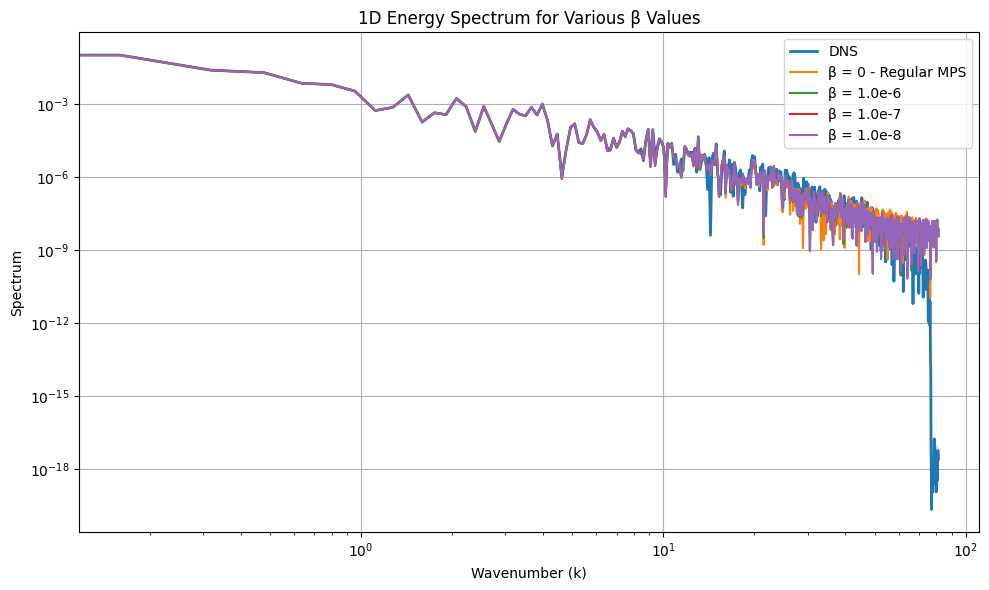

In [59]:
import h5py
import os
import matplotlib.pyplot as plt

file_path = '../Forced_Isotropic/04 Grid 1024 line/Us.mat'
mat_data = loadmat(file_path)
u1x = mat_data['U1x']
k,spec = calculate_1d_spectrum(u1x[:,0])

file_path_comp = 'beta/truncated_u1x_1024line_sp.mat'
with h5py.File(file_path_comp, 'r') as file:
    u_comp   = file['u'][()]
    chi_comp = file['chi_crit'][()]
k_comp1, spec_comp1 = calculate_1d_spectrum(u_comp)
print(f'\nL2 Error β = {0}: ',np.linalg.norm(spec-spec_comp1)/np.linalg.norm(spec))

# Define your directory
directory_path = 'beta/'

# Beta values (from screenshot)
# beta_values = ['1.0','0.1', '0.01']
# beta_values = ['0.001', '0.0001', '1.0e-5']
beta_values = ['1.0e-6', '1.0e-7', '1.0e-8']


plt.figure(figsize=(10, 6))
plt.plot(k, spec, label='DNS', linestyle='-', linewidth=2)
plt.plot(k_comp, spec_comp, label=f'β = 0 - Regular MPS')

# Loop through and plot each spectrum
for beta in beta_values:
    filename = f"truncated_u1x_1024line_sp_chi10_beta{beta}.mat"
    file_path = os.path.join(directory_path, filename)

    with h5py.File(file_path, 'r') as file:
        u_comp = file['u'][()]
    
    k_comp, spec_comp = calculate_1d_spectrum(u_comp)
    print(f'\nL2 Error β = {beta}: ',np.linalg.norm(spec-spec_comp)/np.linalg.norm(spec))

    # Plot with label
    plt.plot(k_comp, spec_comp, label=f'β = {beta}')

plt.xlabel('Wavenumber (k)')
plt.ylabel('Spectrum')
plt.title('1D Energy Spectrum for Various β Values')
plt.legend()
plt.grid(True)
plt.yscale('log')
plt.xscale('log')
plt.tight_layout()
# plt.xlim(10, 76)
# plt.ylim(1e-13, 1e-3)
plt.show()

In [30]:
import matplotlib.pyplot as plt
import h5py
from scipy.io import loadmat
from calculate_spectrum import calculate_2d_spectrum

# Define the file path
file_path = '../Forced_Isotropic/05 Grid 1024 2D/U1_2D.mat'
mat_data = loadmat(file_path)
u1xy = mat_data['U1_xy']
u1xz = mat_data['U1_xz']
u1yz = mat_data['U1_yz']

file_path = '../Forced_Isotropic/05 Grid 1024 2D/V1_2D.mat'
mat_data = loadmat(file_path)
v1xy = mat_data['V1_xy']
v1xz = mat_data['V1_xz']
v1yz = mat_data['V1_yz']

cf_name = '0.0001'
file_path_comp    = f'../Julia/Forced_Isotropic_2D_comp_mps/truncated_u1xy_1024_2D_sp_cf{cf_name}.mat'
file_path_comp_Dx = f'../Julia/Forced_Isotropic_2D_comp_mps/truncated_u1xy_1024_2D_sp_cf{cf_name}_weighted_Dx.mat'
file_path_comp_Dx_Dxx = f'../Julia/Forced_Isotropic_2D_comp_mps/truncated_u1xy_1024_2D_sp_cf{cf_name}_weighted_Dx_Dxx.mat'

with h5py.File(file_path_comp, 'r') as file:
    u_comp   = file['u'][()]
    chi_comp = file['chi_crit'][()]

with h5py.File(file_path_comp_Dx, 'r') as file:
    u_comp_Dx   = file['u'][()]
    chi_comp_Dx = file['chi_crit'][()]    

with h5py.File(file_path_comp_Dx_Dxx, 'r') as file:
    u_comp_Dx_Dxx   = file['u'][()]
    chi_comp_Dx_Dxx = file['chi_crit'][()]   

file_path_comp    = f'../Julia/Forced_Isotropic_2D_comp_mps/truncated_v1xy_1024_2D_sp_cf{cf_name}.mat'
file_path_comp_Dx = f'../Julia/Forced_Isotropic_2D_comp_mps/truncated_v1xy_1024_2D_sp_cf{cf_name}_weighted_Dx.mat'
file_path_comp_Dx_Dxx = f'../Julia/Forced_Isotropic_2D_comp_mps/truncated_v1xy_1024_2D_sp_cf{cf_name}_weighted_Dx_Dxx.mat'

with h5py.File(file_path_comp, 'r') as file:
    v_comp   = file['u'][()]
    chi_comp = file['chi_crit'][()]

with h5py.File(file_path_comp_Dx, 'r') as file:
    v_comp_Dx   = file['u'][()]
    chi_comp_Dx = file['chi_crit'][()]    

with h5py.File(file_path_comp_Dx_Dxx, 'r') as file:
    v_comp_Dx_Dxx   = file['u'][()]
    chi_comp_Dx_Dxx = file['chi_crit'][()]   


# k,spec = calculate_2d_spectrum(u1xy[:,:],v1xy[:,:],)
# k_comp,spec_comp = calculate_2d_spectrum(u_comp, v_comp)
# k_comp_Dx,spec_comp_Dx = calculate_2d_spectrum(u_comp_Dx, v_comp_Dx)
# k_comp_Dx_Dxx,spec_comp_Dx_Dxx = calculate_2d_spectrum(u_comp_Dx_Dxx, v_comp_Dx_Dxx)

In [ ]:
import matplotlib.pyplot as plt

cf_name = '0.0001'
file_path_comp_Dx_Dxx = f'../Julia/Forced_Isotropic_2D_comp_mps/truncated_u1xy_1024_2D_sp_cf{cf_name}_weighted_Dx_Dxx.mat'

with h5py.File(file_path_comp_Dx_Dxx, 'r') as file:
    u_comp_Dx_Dxx   = file['u'][()]
    chi_comp_Dx_Dxx = file['chi_crit'][()]   

plt.figure(figsize=(8, 6))

u_comp = u_comp_Dx_Dxx
u = u1xy

# First velocity plot with transparency
# plt.plot(u_comp_Dx, u1xy, '.',color='blue', alpha=0.1)
plt.plot(u_comp.flatten(), u.flatten(), '.',color='blue', alpha=0.1)

# plt.plot(u_comp_Dx_Dxx, u1xy, '.',color='green', alpha=0.01)

# Add y = x line for reference
x_min = 1.05*min(u.flatten())
x_max = 1.05*max(u.flatten())
x_vals = np.linspace(x_min, x_max, 100)
plt.plot(x_vals, x_vals, '-', color='black', label='y = x')

plt.xlabel('u comp (MPS)')
plt.ylabel('u truth (DNS)')
plt.xlim(x_min, x_max)
plt.ylim(x_min, x_max)
plt.legend()
plt.title('Comparison of Two Velocities')

plt.show()


In [ ]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

colors = ['#377eb8', '#4daf4a', '#ff7f00', '#984ea3', '#e41a1c']

ax.plot(k, spec, label='DNS', linestyle='-', linewidth=2, color=colors[0])
ax.plot(k_comp, spec_comp, label='MPS Cutoff e-3', linestyle='--', linewidth=2, color=colors[1])
ax.plot(k_comp_Dx, spec_comp_Dx, label='1st Deriv Weighted MPS Cutoff e-4', linestyle='--', linewidth=2, color=colors[2])
ax.plot(k_comp_Dx_Dxx, spec_comp_Dx_Dxx, label='1st & 2nd Deriv Weighted MPS Cutoff e-4', linestyle='--', linewidth=2, color=colors[3])
# ax.plot(k, spec, label='DNS', linestyle='-', linewidth=2, color='blue')
# ax.plot(k_comp, spec_comp, label='MPS Cutoff e-4', linestyle='--', linewidth=2, color='orange')
# ax.plot(k_comp_Dx, spec_comp_Dx, label='1st Deriv Weighted MPS Cutoff e-4', linestyle='--', linewidth=2, color='green')
# ax.plot(k_comp_Dx_Dxx, spec_comp_Dx_Dxx, label='1st & 2nd Deriv Weighted MPS Cutoff e-4', linestyle='--', linewidth=2, color='red')

ax.set_xscale('log')
ax.set_yscale('log')
# Add grid
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.set_xlim(1, 480)
ax.set_ylim(1e-8, 1e-0)

# Add labels and title
ax.set_xlabel('Wavenumber (k)', fontsize=14)
ax.set_ylabel('Energy Spectrum', fontsize=14)
ax.set_title('Energy Spectrum Comparison: DNS vs MPS Cutoff e-4', fontsize=16)

# Customize legend
ax.legend(loc='lower left', fontsize=12)

# Display the plot
plt.tight_layout()
# plt.savefig('spectrum_plot_512Cubed.png', dpi=300, bbox_inches='tight')
plt.show()


In [3]:
import h5py
import numpy as np

# Open the HDF5 file
file_name = "isotropic8192.h5"

with h5py.File(file_name, "r") as f:
    # Print available datasets
    print("Datasets in the file:", list(f.keys()))

    # Read a dataset (assuming there's a main dataset, adjust the name if needed)
    dataset_name = list(f.keys())[0]  # Get the first dataset name
    data = f[dataset_name]

    # Check data type
    dtype = data.dtype
    print(f"Data type of '{dataset_name}':", dtype)

    # Determine precision
    if np.issubdtype(dtype, np.float32):
        print("The dataset is stored in single precision (float32).")
    elif np.issubdtype(dtype, np.float64):
        print("The dataset is stored in double precision (float64).")
    else:
        print("The dataset is not in a recognized float format.")


FileNotFoundError: [Errno 2] Unable to open file (unable to open file: name = 'isotropic8192.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
import numpy as np
# np.linalg.norm(spec_comp_Dx - spec)
# np.linalg.norm(spec_comp_Dx_Dxx - spec)

# np.linalg.norm(spec_comp_Dx[0:480] - spec[0:480])
# np.linalg.norm(spec_comp_Dx_Dxx[0:480] - spec[0:480])



In [ ]:
import matplotlib.pyplot as plt
import scipy.io

# Create a figure and axis
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
eps = 0.0788

spectrum_4th_order = scipy.io.loadmat('spectrum_4th_order_512Cubed.mat')
# spec_512URDNS_64 = scipy.io.loadmat('spectrum_512_URDNS_64.mat')
# spec_512URDNS_128 = scipy.io.loadmat('spectrum_512_URDNS_128.mat')
# spec_512URDNS_256 = scipy.io.loadmat('spectrum_512_URDNS_256.mat')
# spec_512URDNS_64 = spec_512URDNS_64['spec'][0]
# spec_512URDNS_128 = spec_512URDNS_128['spec'][0]
# spec_512URDNS_256 = spec_512URDNS_256['spec'][0]

# C = 1/(2*128**6)
C = 1

# Plot the spectra
k = spectrum_4th_order['comp_e2']['k'][0][0][0]
spec = spectrum_4th_order['comp_e2']['spec'][0][0][0]
spec_comp_e2 = spectrum_4th_order['comp_e2']['spec_comp'][0][0][0]
spec_comp_e3 = spectrum_4th_order['comp_e3']['spec_comp'][0][0][0]
spec_comp_e4 = spectrum_4th_order['comp_e4']['spec_comp'][0][0][0]

# Plot the spectra
ax.plot(k, spec, label='Original Spectrum-512 Cubed', linewidth=2)
# ax.plot(k, spec_comp_e2, label='Compressed Spectrum e-2', linestyle='--', linewidth=2)
ax.plot(k, spec_comp_e3, label='Compressed Spectrum e-3', linestyle='--', linewidth=2)
# ax.plot(k, spec_comp_e4, label='Compressed Spectrum e-4', linestyle='--', linewidth=2)
# ax.plot(k, spec_512URDNS_64, label='512 URDNS 64 Cube Spectrum', linestyle='-.', linewidth=2)
# ax.plot(k, spec_512URDNS_128, label='512 URDNS 128 Spectrum', linestyle='-.', linewidth=2)
# ax.plot(k, spec_512URDNS_256, label='512 URDNS 256 Spectrum', linestyle='-.', linewidth=2)
ax.plot(k, C*1.6*eps**(2/3) * k**(-5/3), label=r'$1.6\epsilon^{2/3} k^{-5/3}$', color='black', linestyle='-', linewidth=2)

# ax.plot(k_128, spec_128, label='128 Whole Cube Spectrum', linestyle='-', linewidth=2) #this is skipped of the whole domain not skipped of 512 cubed
# ax.plot(k_URDNS_64, spec_URDNS_64, label='128 Upsampled 64 Whole Cube Spectrum', linestyle='-', linewidth=2)

# ax.plot(k, spectrum_4th_order['comp_e2']['spec'], label='Original Spectrum', linewidth=2)
# ax.plot(k, spectrum_4th_order['comp_e2']['spec_comp'], label='Compressed Spectrum e2', linestyle='--', linewidth=2)
# ax.plot(k, spectrum_4th_order['comp_e3']['spec_comp'], label='Compressed Spectrum e3', linestyle='-.', linewidth=2)
# ax.plot(k, spectrum_4th_order['comp_e4']['spec_comp'], label='Compressed Spectrum e4', linestyle=':', linewidth=2)
# ax.plot(k, C*1.6*eps**(2/3) * k**(-5/3), label=r'$1.6\epsilon^{2/3} k^{-5/3}$', color='black', linestyle='-', linewidth=2)


# Set log scale for both axes
ax.set_xscale('log')
ax.set_yscale('log')

# Add grid
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Add labels and title
ax.set_xlabel('Wavenumber (k)', fontsize=14)
ax.set_ylabel('Energy Spectrum', fontsize=14)
ax.set_title('Energy Spectrum Comparison', fontsize=16)

# Customize legend
ax.legend(loc='best', fontsize=12)
# ax.set_xlim(1, 254)
# ax.set_ylim(1e-6,1)

# Display the plot
plt.tight_layout()
plt.savefig('spectrum_plot_512Cubed.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import scipy.io

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
# eps = 0.0788
# eps = 0.001385190088068
eps = 8.8479e-02
# eps = 0.09
C = 1
# spectrum_cf_1e-05.mat
spectrum_1024 = scipy.io.loadmat('spectrum_1024Cubed.mat')
spectrum_512 = scipy.io.loadmat('spectrum_4th_order_512Cubed.mat')

# C = 1/(2*128**6)
C = 1

# Plot the spectra
k_512 = spectrum_512['comp_e2']['k'][0][0][0]
spec_512 = spectrum_512['comp_e2']['spec'][0][0][0]

k_1024 = spectrum_1024['k'][0]
spec_1024 = spectrum_1024['spec'][0]

ax.plot(k_1024, spec_1024, label='Original Data - 1024 Cubed', linewidth=2)
# ax.plot(k_512, spec_512, label='Subdomain Data - 512 Cubed', linewidth=2)
# ax.plot(k_128, spec_128, label='Whole domain Data - 128 Cubed', linestyle='--', linewidth=2)
ax.plot(k_1024, C*1.6*eps**(2/3) * k_1024**(-5/3), label=r'$1.6\epsilon^{2/3} k^{-5/3}$', color='black', linestyle='-', linewidth=2)

# Set log scale for both axes
ax.set_xscale('log')
ax.set_yscale('log')

# Add grid
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Add labels and title
ax.set_xlabel('Wavenumber (k)', fontsize=14)
ax.set_ylabel('Energy Spectrum', fontsize=14)
ax.set_title('Energy Spectrum Comparison', fontsize=16)

# Customize legend
ax.legend(loc='best', fontsize=12)

ax.set_xlim(1, 480)
ax.set_ylim(1e-7, 1)

# Display the plot
plt.tight_layout()
plt.savefig('spectrum_plot_512Cubed.png', dpi=300, bbox_inches='tight')
plt.show()


#inja

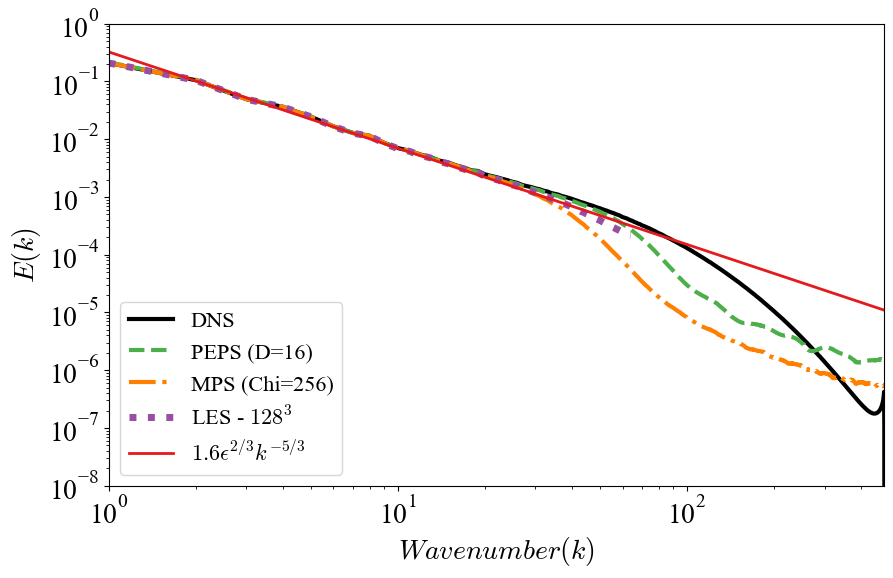

In [40]:
#Plot energy spectrum

import numpy as np
import matplotlib
import matplotlib.backends.backend_pgf as pgf
import matplotlib.legend
import matplotlib.lines

# numpy 2.0
if not hasattr(np, 'float_'): np.float_ = np.float64
if not hasattr(np, 'alltrue'): np.alltrue = np.all

# matplotlib 3.8-3.10
if not hasattr(pgf, 'common_texification'):
    pgf.common_texification = pgf._tex_escape
if not hasattr(matplotlib.legend.Legend, 'legendHandles'):
    matplotlib.legend.Legend.legendHandles = property(lambda self: self.legend_handles)
if not hasattr(matplotlib.lines.Line2D, '_us_dashSeq'):
    matplotlib.lines.Line2D._us_dashSeq = property(lambda self: self._dash_pattern[1])
    matplotlib.lines.Line2D._us_dashOffset = property(lambda self: self._dash_pattern[0])

import tikzplotlib

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # or "TeX Gyre Termes"
    "mathtext.fontset": "cm",
    "font.size": 16,
    "axes.titlepad": 30  # Use 'axes.titlepad' instead of 'title.pad'
})

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
# eps = 0.0788
# eps = 0.001385190088068
# eps = 0.088652
eps = 0.0919
# spectrum_cf_1e-05.mat
colors = ['#377eb8', '#4daf4a', '#ff7f00', '#984ea3', '#e41a1c', '#f781bf']

spec_1024 = scipy.io.loadmat('en_spec_DNS.mat')
# spectrum_cf_e2 = scipy.io.loadmat('en_spec_cf_0.01_spectral.mat')
# spectrum_cf_e3 = scipy.io.loadmat('en_spec_cf_0.001_spectral.mat')
# spectrum_cf_e4 = scipy.io.loadmat('en_spec_cf_0.0001_spectral.mat')
# spectrum_cf_e4_dx = scipy.io.loadmat('spectrum_cf_0.0001_weighted_dx.mat')
# spectrum_cf_e4_split = scipy.io.loadmat('spectrum_cf_0.0001_split.mat')
# spectrum_cf_e4_c_split = scipy.io.loadmat('spectrum_cf_0.0001_c_split.mat')

# spectrum_cf_e5 = scipy.io.loadmat('en_spec_cf_1e-05_spectral.mat')
# spectrum_cf_e8 = scipy.io.loadmat('spectrum_cf_1e-08.mat')
# spectrum_cf_e10 = scipy.io.loadmat('spectrum_cf_1e-10.mat')

# spectrum_cf_e3_sp = scipy.io.loadmat('spectrum_cf_0.001_sp.mat')
# spectrum_cf_e3_sp_w = scipy.io.loadmat('spectrum_cf_0.001_weighted_sp.mat')
# spectrum_cf_e3_sp = spectrum_cf_e3_sp['spec'].T
# spectrum_cf_e3_sp_w = spectrum_cf_e3_sp_w['spec'].T
# spectrum_fbox_3 = scipy.io.loadmat('spectrum_fbox_3x3x3.mat')
# spectrum_fbox_341 = scipy.io.loadmat('spectrum_fbox_3x3x3_size_341.mat')
# spectrum_12_PEPS = scipy.io.loadmat('spectrum_chi_12.mat')
# spectrum_144_PEPS_eq = scipy.io.loadmat('spectrum_chi_144.mat')
spectrum_16_PEPS = scipy.io.loadmat('pspectrum_chi_16.mat')
spectrum_256_PEPS_eq = scipy.io.loadmat('pspectrum_chi_256.mat')
spectrum_20_PEPS = scipy.io.loadmat('pspectrum_chi_20.mat')
spectrum_400_PEPS_eq = scipy.io.loadmat('pspectrum_chi_400.mat')
spectrum_LES_128 = scipy.io.loadmat('spectrum_cf_8.mat')


# C = 1/(2*128**6)
C = 1

k_1024 = spec_1024['k'].T
spec_1024 = spec_1024['spec'].T
# spectrum_cf_e2 = spectrum_cf_e2['spec_comp'].T
# spectrum_cf_e3 = spectrum_cf_e3['spec_comp'].T
# spectrum_cf_e4 = spectrum_cf_e4['spec_comp'].T
# spectrum_cf_e5 = spectrum_cf_e5['spec_comp'].T
# spectrum_cf_e8 = spectrum_cf_e8['spec_comp'].T
# spectrum_cf_e10 = spectrum_cf_e10['spec_comp'].T
# spectrum_cf_e4_dx = spectrum_cf_e4_dx['spec_comp'].T
# spectrum_cf_e4_split = spectrum_cf_e4_split['spec_comp'].T
# spectrum_cf_e4_c_split = spectrum_cf_e4_c_split['spec_comp'].T
# spectrum_fbox_3 = spectrum_fbox_3['spec_comp'].T
# spectrum_fbox_341 = spectrum_fbox_341['spec_comp'].T
# spectrum_12_PEPS = spectrum_12_PEPS['spec_comp'].T
# spectrum_144_PEPS_eq = spectrum_144_PEPS_eq['spec_comp'].T
spectrum_16_PEPS = spectrum_16_PEPS['spec_comp'].T
spectrum_256_PEPS_eq = spectrum_256_PEPS_eq['spec_comp'].T
# spectrum_20_PEPS = spectrum_20_PEPS['spec_comp'].T
# spectrum_400_PEPS_eq = spectrum_400_PEPS_eq['spec_comp'].T

# ax.plot(k_1024, spec_1024, label='Original Data - 1024 Cubed - Massen', linewidth=2)
# ax.plot(bobby_k, bobby_spec_1024, label='Original Data - 1024 Cubed - Bobby', linewidth=2)

# ax.plot(k_1024, spectrum_cf_e5, label='Comp MPS - cutoff 1e-05 - Massen', linestyle='-', linewidth=2)
# ax.plot(bobby_k, bobby_spec_e5, label='Comp MPS - cutoff 1e-05 - Bobby', linestyle='-', linewidth=2)

# ax.plot(k_1024, spectrum_cf_e8, label='Comp MPS - cutoff 1e-08 - Massen', linestyle='-', linewidth=2)
# ax.plot(bobby_k, bobby_spec_e8, label='Comp MPS - cutoff 1e-08 - Bobby', linestyle='-', linewidth=2)


ax.plot(k_1024, spec_1024, label='DNS', linewidth=3, color='black')

# ax.plot(k_1024, spectrum_cf_e2, label='MPS - 1e-2', linestyle='--', linewidth=2, color=colors[0])
# ax.plot(k_1024, spectrum_cf_e3, label='MPS - cutoff 1e-3', linestyle='--', linewidth=2, color=colors[1])
# ax.plot(k_1024, spectrum_cf_e3_sp, label='MPS - Cutoff 1e-3 - split', linestyle='--', linewidth=2, color=colors[2])
# ax.plot(k_1024, spectrum_cf_e3_sp_w, label='1st Deriv. Weighted MPS Cutoff e-3 - split', linestyle='--', linewidth=2, color=colors[3])

# ax.plot(k_1024, spectrum_cf_e4, label='MPS - Eq. DNS 300', linestyle='--', linewidth=5, color=colors[1])
# ax.plot(k_1024, spectrum_cf_e4, label='MPS - cutoff 1e-4', linestyle='--', linewidth=2, color=colors[2]) #interleaved

# ax.plot(k_1024, spectrum_cf_e4_split, label='MPS - cutoff 1e-4, split', linestyle='--', linewidth=2, color=colors[2])
# ax.plot(k_1024, spectrum_cf_e4_c_split, label='MPS - cutoff 1e-4, c-split', linestyle='--', linewidth=2, color=colors[3])

# ax.plot(k_1024, spectrum_cf_e4_dx, label='Comp weighted MPS - cutoff 1e-4, CR = 25', linestyle='--', linewidth=2, color=colors[2])
# ax.plot(k_1024, spectrum_cf_e5, label='MPS - cutoff 1e-5', linestyle='--', linewidth=2, color=colors[3])
# ax.plot(k_1024, spectrum_cf_e5, label='MPS - Eq. DNS 500', linestyle='--', linewidth=5, color=colors[3])

# ax.plot(k_1024, spectrum_cf_e8, label='Comp MPS - cutoff 1e-08', linestyle='--', linewidth=2)
# ax.plot(k_1024, spectrum_fbox_3, label='Filtered - size 1024', linestyle='--', linewidth=3, color=colors[1])
# ax.plot(k_1024[0:170], spectrum_fbox_341, label='Filtered - size 341', linestyle='--', linewidth=3, color=colors[4])
# ax.plot(k_1024, spectrum_12_PEPS, label='PEPS (D=12)', linestyle='--', linewidth=3, color=colors[1])
# ax.plot(k_1024, spectrum_144_PEPS_eq, label='MPS (Chi=144)', linestyle='--', linewidth=3, color=colors[3])
ax.plot(k_1024, spectrum_16_PEPS, label='PEPS (D=16)', linestyle='--', linewidth=3, color=colors[1])
ax.plot(k_1024, spectrum_256_PEPS_eq, label='MPS (Chi=256)', linestyle='-.', linewidth=3, color=colors[2])
# ax.plot(k_1024, spectrum_20_PEPS, label='PEPS (D=20)', linestyle=':', linewidth=3, color=colors[3])
# ax.plot(k_1024, spectrum_400_PEPS_eq, label='MPS (Chi=400)', linestyle='--', linewidth=3, color=colors[3])
# ax.plot(k_1024, spectrum_cf_e10, label='Comp MPS - cutoff 1e-10', linestyle='--', linewidth=2)
ax.plot(k_1024[0:64], spectrum_LES_128['spec_comp'].T, label=r'LES - $128^3$', linestyle=':', linewidth=5, color=colors[3])
# ax.plot(k_1024[0:32], spectrum_LES_64['spec_comp'], label=r'LES - $64^3$', linestyle='-.', linewidth=2, color=colors[1])
# ax.plot(k_1024[0:16], spectrum_LES_32['spec_comp'].T, label=r'LES - $32^3$', linestyle='-.', linewidth=2, color=colors[2])
# ax.plot(k_1024[0:8], spectrum_LES_16['spec_comp'], label=r'LES - $16^3$', linestyle='-.', linewidth=2, color=colors[3])
ax.plot(k_1024, C*1.6*eps**(2/3) * k_1024**(-5/3), label=r'$1.6\epsilon^{2/3} k^{-5/3}$', color=colors[4], linestyle='-', linewidth=2)

# Set log scale for both axes
ax.set_xscale('log')
ax.set_yscale('log')

# Add grid
# ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Add labels and title
ax.set_xlabel(r'$Wavenumber (k)$', fontsize=20)
ax.set_ylabel(r'$E(k)$', fontsize=20)
# ax.set_title('Energy Spectrum Comparison', fontsize=16, pad=30)

# Customize legend
ax.legend(loc='lower left', fontsize=16)

ax.set_xlim(1, 480)
for label in ax.get_xticklabels():
    label.set_fontsize(20)
ax.set_ylim(1e-8, 1)
for label in ax.get_yticklabels():
    label.set_fontsize(20)


# ax.set_xlim(100, 480)
# ax.set_ylim(1e-7, 2e-4)

# Display the plot
# plt.tight_layout()
plt.savefig('Energy_spectrum.pdf', format='pdf', dpi=300, bbox_inches='tight')
# plt.savefig('Energy_spectrum_zoomed.eps', format='EPS', dpi=300, bbox_inches='tight')
tikzplotlib.save('Energy_spectrum.tex')
plt.show()



(64, 1)

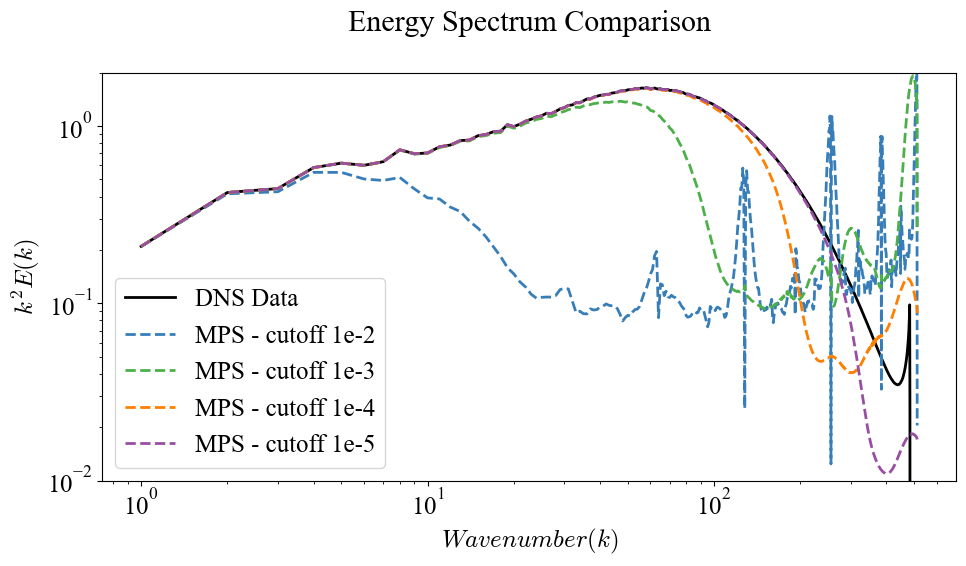

In [44]:
#Plot energy spectrum
import matplotlib.pyplot as plt
import scipy.io
import tikzplotlib
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "cm",
    "font.size": 18,
    "axes.titlepad": 30  
})

fig = plt.figure(figsize=(10, 6))
# fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
# eps = 0.088652
eps = 0.0919

colors = ['#377eb8', '#4daf4a', '#ff7f00', '#984ea3', '#e41a1c']

spec_1024 = scipy.io.loadmat('en_spec_DNS.mat')
spectrum_cf_e2 = scipy.io.loadmat('en_spec_cf_0.01_spectral.mat')
spectrum_cf_e3 = scipy.io.loadmat('en_spec_cf_0.001_spectral.mat')
spectrum_cf_e4 = scipy.io.loadmat('en_spec_cf_0.0001_spectral.mat')
spectrum_cf_e5 = scipy.io.loadmat('en_spec_cf_1e-05_spectral.mat')


# C = 1/(2*128**6)
C = 1
k_1024 = spec_1024['k'].T
spec_1024 = spec_1024['spec'].T
spectrum_cf_e2 = spectrum_cf_e2['spec_comp'].T
spectrum_cf_e3 = spectrum_cf_e3['spec_comp'].T
spectrum_cf_e4 = spectrum_cf_e4['spec_comp'].T
spectrum_cf_e5 = spectrum_cf_e5['spec_comp'].T

# ax.plot(k_1024,spec_1024, label='DNS Data', linewidth=2, color='black')
# ax.plot(k_1024,spectrum_cf_e2, label='MPS - cutoff 1e-2', linestyle='--', linewidth=2, color=colors[0])
# ax.plot(k_1024,spectrum_cf_e3, label='MPS - cutoff 1e-3', linestyle='--', linewidth=2, color=colors[1])
# ax.plot(k_1024,spectrum_cf_e4, label='MPS - cutoff 1e-4', linestyle='--', linewidth=2, color=colors[2])
# ax.plot(k_1024,spectrum_cf_e5, label='MPS - cutoff 1e-5', linestyle='--', linewidth=2, color=colors[3])
# ax.plot(k_1024, C*1.6*eps**(2/3) * k_1024**(-5/3), label=r'$1.6\epsilon^{2/3} k^{-5/3}$', color=colors[4], linestyle='-', linewidth=2)

ax.plot(k_1024,k_1024**2*spec_1024, label='DNS Data', linewidth=2, color='black')
ax.plot(k_1024,k_1024**2*spectrum_cf_e2, label='MPS - cutoff 1e-2', linestyle='--', linewidth=2, color=colors[0])
ax.plot(k_1024,k_1024**2*spectrum_cf_e3, label='MPS - cutoff 1e-3', linestyle='--', linewidth=2, color=colors[1])
ax.plot(k_1024,k_1024**2*spectrum_cf_e4, label='MPS - cutoff 1e-4', linestyle='--', linewidth=2, color=colors[2])
ax.plot(k_1024,k_1024**2*spectrum_cf_e5, label='MPS - cutoff 1e-5', linestyle='--', linewidth=2, color=colors[3])

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$Wavenumber (k)$')
# ax.set_ylabel(r'$E(k)$')
ax.set_ylabel(r'$k^2 E(k)$')
ax.set_title('Energy Spectrum Comparison')
ax.legend(loc='lower left')

# ax.set_xlim(1, 480)
# ax.set_ylim(1e-8, 0.8)
# ax.set_yticks([1e-8, 1e-5, 1e-2])

# ax.set_xlim(100, 480)
# ax.set_ylim(1e-8, 5*1e-4)
# ax.set_yticks([1e-8, 1e-5])

# ax.set_xlim(1, 2.5*10**5)
ax.set_ylim(1e-2, 2)
# ax.set_yticks([1e-8, 1e-5, 1e-2])

# Display the plot
plt.tight_layout()
# plt.savefig('Energy_spectrum.pdf', format='pdf', dpi=300, bbox_inches='tight')
# plt.savefig('Energy_spectrum_zoomed.pdf', format='pdf', dpi=300, bbox_inches='tight')
# tikzplotlib.save('Energy_spectrum.tex')
# plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()



In [ ]:
#inja
# try 1 - 14 -> 1e-2 of b e-3

import matplotlib.pyplot as plt
import scipy.io
import numpy as np

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
# eps = 0.0788
# eps = 0.001385190088068
eps = 0.088652
# eps = 0.09
# spectrum_cf_1e-05.mat
colors = ['#377eb8', '#4daf4a', '#ff7f00', '#984ea3', '#e41a1c']

spectrum_spectral = scipy.io.loadmat('spectrum_cf_0_spectral.mat')
# spectrum_b_e3 = scipy.io.loadmat('spectrum_cf_0.01_beta_e3.mat')
spectrum_b_e3 = scipy.io.loadmat('spectrum_cf_0.006_beta_e3.mat')
# spectrum_b_e3 = scipy.io.loadmat('spectrum_cf_0.001_beta_e3.mat')
spectrum_b_e4 = scipy.io.loadmat('spectrum_cf_0.0001_beta_e4.mat')
spectrum_b_e5 = scipy.io.loadmat('spectrum_cf_1e-05_beta_e5')
# spectrum_b_e0 = scipy.io.loadmat('spectrum_cf_1e-05_beta_0.mat')
spectrum_b_e0 = scipy.io.loadmat('spectrum_cf_8e-06_beta_0.mat')



# spectrum_cf_e3_sp = scipy.io.loadmat('spectrum_cf_0.001_sp.mat')
# spectrum_cf_e3_sp_w = scipy.io.loadmat('spectrum_cf_0.001_weighted_sp.mat')
# spectrum_cf_e3_sp = spectrum_cf_e3_sp['spec'].T
# spectrum_cf_e3_sp_w = spectrum_cf_e3_sp_w['spec'].T

# C = 1/(2*128**6)
C = 1

k_1024 = spectrum_b_e4['k'].T
spec_1024 = spectrum_b_e4['spec'].T
spectrum_spectral = spectrum_spectral['spec'].T
# spectrum_b_e3 = spectrum_b_e3['spec_comp'].T
spectrum_b_e3 = spectrum_b_e3['spec'].T
spectrum_b_e4 = spectrum_b_e4['spec_comp'].T
spectrum_b_e5 = spectrum_b_e5['spec_comp'].T
# spectrum_b_e0 = spectrum_b_e0['spec_comp'].T
spectrum_b_e0 = spectrum_b_e0['spec'].T


ax.plot(k_1024, spec_1024, label='Original Data - 4th order FD', linewidth=2, color=colors[0])
ax.plot(k_1024, spectrum_spectral, label='Original Data - Spectral', linewidth=2, color=colors[2], linestyle='--')

# ax.plot(k_1024, spectrum_b_e0, label='beta 0   , CR = 9.1', linestyle='--', linewidth=2, color=colors[1])
# ax.plot(k_1024, spectrum_b_e0, label='beta 0   , CR = 7.9', linestyle='--', linewidth=2, color=colors[1])
# ax.plot(k_1024, spectrum_b_e5, label='beta e-5, CR = 7.2', linestyle='--', linewidth=2, color=colors[2])
# ax.plot(k_1024, spectrum_b_e4, label='beta e-4, CR = 7.6', linestyle='--', linewidth=2, color=colors[3])
# # ax.plot(k_1024, spectrum_b_e3, label='beta e-3, CR = 3.2', linestyle='--', linewidth=2, color=colors[4])
# ax.plot(k_1024, spectrum_b_e3, label='beta e-3, CR = 7.4', linestyle='--', linewidth=2, color=colors[4])

ax.plot(k_1024, C*1.6*eps**(2/3) * k_1024**(-5/3), label=r'$1.6\epsilon^{2/3} k^{-5/3}$', color='black', linestyle='-', linewidth=2)

# k_1 = np.ones_like(k_1024);
# ax.plot(k_1024, spec_1024*eps**(-2/3) * k_1024**(5/3), label=r'Original Data - E(k) * $\epsilon^{-2/3} k^{5/3}$', linewidth=2)
# ax.plot(k_1024, spectrum_b_e3*eps**(-2/3) * k_1024**(5/3), label='beta e-3, CR = 7.2', linestyle='--', linewidth=2)
# ax.plot(k_1024, spectrum_b_e4*eps**(-2/3) * k_1024**(5/3), label='beta e-4, CR = 7.6', linestyle='--', linewidth=2)
# ax.plot(k_1024, spectrum_b_e5*eps**(-2/3) * k_1024**(5/3), label='beta e-5, CR = 3.2', linestyle='--', linewidth=2)
# ax.plot(k_1024, C*1.6*k_1, label=r'$1.6$', color='black', linestyle='--', linewidth=2)


# Set log scale for both axes
ax.set_xscale('log')
ax.set_yscale('log')

# Add grid
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Add labels and title
ax.set_xlabel('Wavenumber (k)', fontsize=14)
ax.set_ylabel('Energy Spectrum', fontsize=14)
ax.set_title('Energy Spectrum Comparison', fontsize=16)

# Customize legend
ax.legend(loc='lower left', fontsize=12)

ax.set_xlim(1, 482)
ax.set_ylim(1e-8, 1)
# ax.set_ylim(1e-3, 5)

# ax.set_xlim(200, 482)
# ax.set_ylim(1e-8, 1e-4)

# Display the plot
plt.tight_layout()
# plt.savefig('spectrum_plot_512Cubed.png', dpi=300, bbox_inches='tight')
plt.show()


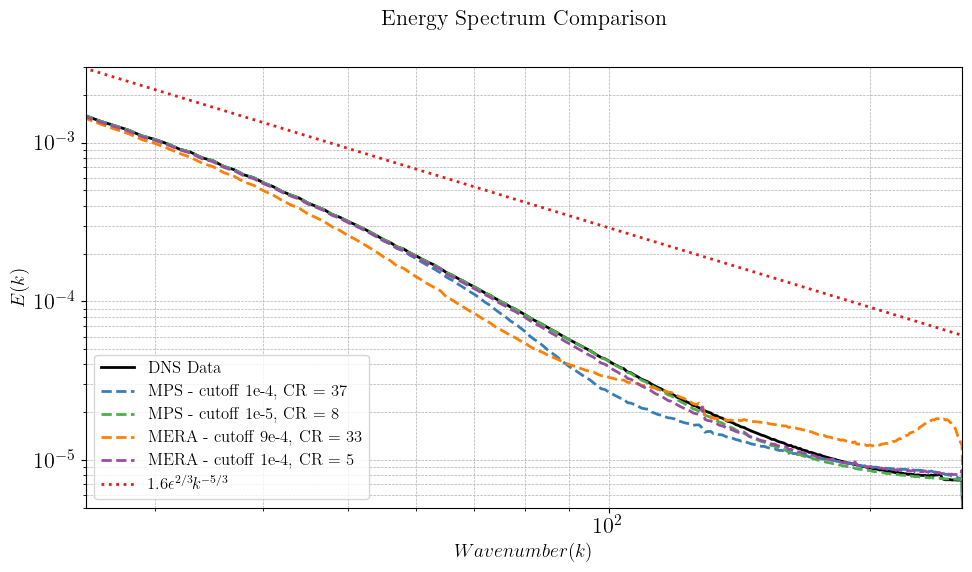

In [ ]:
#Plot energy spectrum - 512 Subdomain
import matplotlib.pyplot as plt
import scipy.io
import tikzplotlib

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # or "TeX Gyre Termes"
    "mathtext.fontset": "cm",
    "font.size": 16,
    "axes.titlepad": 30  # Use 'axes.titlepad' instead of 'title.pad'
})

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
eps = 0.24496163291356418
colors = ['#377eb8', '#4daf4a', '#ff7f00', '#984ea3', '#e41a1c']

spec_512 = scipy.io.loadmat('spectrum_cf_0.0001_mps.mat')
spectrum_mps_e4 = scipy.io.loadmat('spectrum_cf_0.0001_mps.mat')
spectrum_mps_e5 = scipy.io.loadmat('spectrum_cf_0.00001_mps.mat')
spectrum_mera_9e4 = scipy.io.loadmat('spectrum_cf_0.0009_mera.mat')
spectrum_mera_e4 = scipy.io.loadmat('spectrum_cf_0.0001_mera.mat')

# C = 1/(2*128**6)
C = 1

k_512 = spec_512['k'].T
spec_512 = spec_512['spec'].T
spectrum_mps_e4 = spectrum_mps_e4['spec_comp'].T
spectrum_mps_e5 = spectrum_mps_e5['spec_comp'].T
spectrum_mera_9e4 = spectrum_mera_9e4['spec_comp'].T
spectrum_mera_e4 = spectrum_mera_e4['spec_comp'].T


ax.plot(k_512, spec_512, label='DNS Data', linewidth=2, color='black')
ax.plot(k_512, spectrum_mps_e4, label='MPS - cutoff 1e-4, CR = 37', linestyle='--', linewidth=2, color=colors[0])
ax.plot(k_512, spectrum_mps_e5, label='MPS - cutoff 1e-5, CR = 8', linestyle='--', linewidth=2, color=colors[1])
ax.plot(k_512, spectrum_mera_9e4, label='MERA - cutoff 9e-4, CR = 33', linestyle='--', linewidth=2, color=colors[2])
ax.plot(k_512, spectrum_mera_e4, label='MERA - cutoff 1e-4, CR = 5', linestyle='--', linewidth=2, color=colors[3])

ax.plot(k_512, C*1.6*eps**(2/3) * k_512**(-5/3), label=r'$1.6\epsilon^{2/3} k^{-5/3}$', color=colors[4], linestyle=':', linewidth=2)

# Set log scale for both axes
ax.set_xscale('log')
ax.set_yscale('log')

# Add grid
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Add labels and title
ax.set_xlabel(r'$Wavenumber (k)$', fontsize=14)
ax.set_ylabel(r'$E(k)$', fontsize=14)
ax.set_title('Energy Spectrum Comparison', fontsize=16, pad=30)

# Customize legend
ax.legend(loc='lower left', fontsize=12)

# ax.set_xlim(1, 256)

ax.set_xlim(25, 255)
ax.set_ylim(5e-6, 3e-3)

# Display the plot
plt.tight_layout()
# plt.savefig('Energy_spectrum.pdf', format='pdf', dpi=300, bbox_inches='tight')
# plt.savefig('Energy_spectrum_zoomed.eps', format='EPS', dpi=300, bbox_inches='tight')
# tikzplotlib.save('Energy_spectrum.tex')
plt.show()


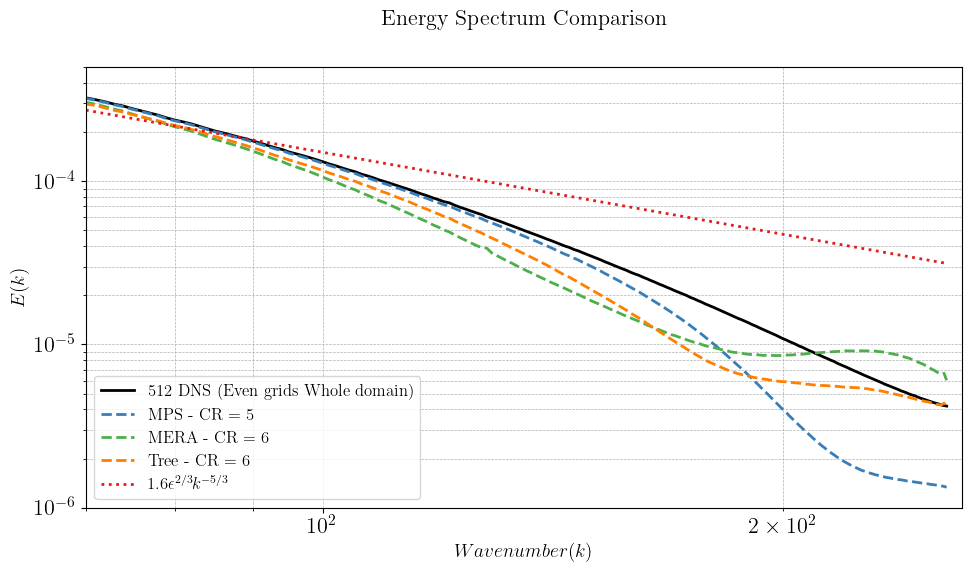

In [234]:
#Plot energy spectrum - 512 Whole domain
import matplotlib.pyplot as plt
import scipy.io
import tikzplotlib

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # or "TeX Gyre Termes"
    "mathtext.fontset": "cm",
    "font.size": 16,
    "axes.titlepad": 30  # Use 'axes.titlepad' instead of 'title.pad'
})

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
eps = 0.0909
colors = ['#377eb8', '#4daf4a', '#ff7f00', '#984ea3', '#e41a1c', '#a65628', '#f781bf']




spec_1024 = scipy.io.loadmat('en_spec_DNS.mat')
spec_512 = scipy.io.loadmat('spectrum_cf_0.0001_mps.mat')
spectrum_odd_even = scipy.io.loadmat('spectrum_odd_even.mat')
spectrum_mps_e3 = scipy.io.loadmat('/Users/massen/Desktop/JHS result/512/WholeDomain/mps/spectrum_cf_0.001.mat')
spectrum_mps_e4 = scipy.io.loadmat('/Users/massen/Desktop/JHS result/512/WholeDomain/mps/spectrum_cf_0.0001.mat')
spectrum_mera_e3 = scipy.io.loadmat('/Users/massen/Desktop/JHS result/512/WholeDomain/mera/spectrum_cf_0.001.mat')
spectrum_mera_5e3 = scipy.io.loadmat('/Users/massen/Desktop/JHS result/512/WholeDomain/mera/spectrum_cf_0.005.mat')
spectrum_tree_5e3 = scipy.io.loadmat('/Users/massen/Desktop/JHS result/512/WholeDomain/tree/spectrum_cf_0.0055.mat')
spectrum_tree_9e4 = scipy.io.loadmat('/Users/massen/Desktop/JHS result/512/WholeDomain/tree/spectrum_cf_0.0009.mat')

# C = 1/(2*128**6)
C = 1

k_1024 = spec_1024['k'].T
k_512 = spec_512['k'].T
spec_1024 = spec_1024['spec'].T
spec_512 = spec_512['spec'].T
spectrum_even = spectrum_odd_even['spec'].T
spectrum_odd = spectrum_odd_even['spec_comp'].T
spectrum_mps_e3 = spectrum_mps_e3['spec_comp'].T
spectrum_mps_e4 = spectrum_mps_e4['spec_comp'].T
spectrum_mera_e3 = spectrum_mera_e3['spec_comp'].T
spectrum_mera_5e3 = spectrum_mera_5e3['spec_comp'].T
spectrum_tree_5e3 = spectrum_tree_5e3['spec_comp'].T
spectrum_tree_9e4 = spectrum_tree_9e4['spec_comp'].T

# ax.plot(k_1024, spec_1024, label='1024 DNS', linewidth=2, color='black')
ax.plot(k_512, spectrum_even, label='512 DNS (Even grids Whole domain)', linestyle='-', linewidth=2, color='black')
# ax.plot(k_512, spectrum_odd, label='512 DNS Odd grids Whole domain', linestyle='--', linewidth=2, color=colors[2])
# ax.plot(k_512, spec_512, label='512 DNS Sub-domain', linewidth=2, color=colors[0])
# ax.plot(k_512, spectrum_mps_e3, label='MPS - CR = 59', linestyle='--', linewidth=2, color=colors[0])
# ax.plot(k_512, spectrum_mera_5e3, label='MERA - CR = 63', linestyle='--', linewidth=2, color=colors[1])
# ax.plot(k_512, spectrum_tree_5e3, label='Tree - CR = 63', linestyle='--', linewidth=2, color=colors[2])
ax.plot(k_512, spectrum_mps_e4, label='MPS - CR = 5', linestyle='--', linewidth=2, color=colors[0])
ax.plot(k_512, spectrum_mera_e3, label='MERA - CR = 6', linestyle='--', linewidth=2, color=colors[1])
ax.plot(k_512, spectrum_tree_9e4, label='Tree - CR = 6', linestyle='--', linewidth=2, color=colors[2])

ax.plot(k_512, C*1.6*eps**(2/3) * k_512**(-5/3), label=r'$1.6\epsilon^{2/3} k^{-5/3}$', color=colors[4], linestyle=':', linewidth=2)
# ax.plot(k_1024, C*1.6*eps**(2/3) * k_1024**(-5/3), label=r'$1.6\epsilon^{2/3} k^{-5/3}$', color=colors[4], linestyle=':', linewidth=2)

# Set log scale for both axes
ax.set_xscale('log')
ax.set_yscale('log')

# Add grid
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Add labels and title
ax.set_xlabel(r'$Wavenumber (k)$', fontsize=14)
ax.set_ylabel(r'$E(k)$', fontsize=14)
ax.set_title('Energy Spectrum Comparison', fontsize=16, pad=30)

# Customize legend
ax.legend(loc='lower left', fontsize=12)

# ax.set_xlim(1, 262)

# ax.set_xlim(20, 262)
# ax.set_ylim(1E-6,5e-3)

ax.set_xlim(70, 262)
ax.set_ylim(1E-6,5e-4)


# Display the plot
plt.tight_layout()
# plt.savefig('Energy_spectrum.pdf', format='pdf', dpi=300, bbox_inches='tight')
# plt.savefig('Energy_spectrum_zoomed.eps', format='EPS', dpi=300, bbox_inches='tight')
# tikzplotlib.save('Energy_spectrum.tex')
plt.show()


In [43]:
ordering_name = "interleaved" #interleaved, sequential, comb1, comb2


/var/folders/r5/t2snqk2n1ps1l1ghz__b_mg40000gn/T/ipykernel_27226/3887438139.py:189: RuntimeWarning: divide by zero encountered in log2
  rf"$2^{{{int(np.log2(i))}}}$" if (np.log2(i - 1) % 3 == 1 and i >= 2) else ""


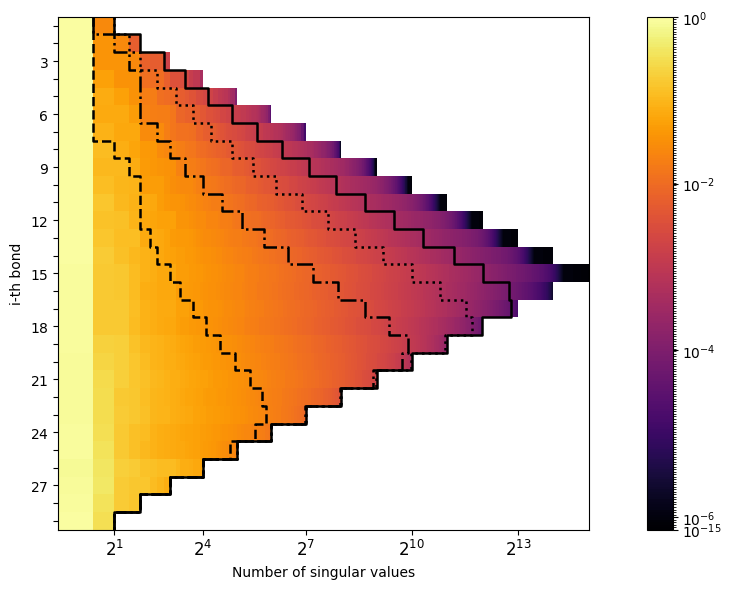

In [44]:
#Schmidt spectrum - Nik's version

# import matplotlib as mpl
# mpl.rcParams.update({
#     "text.usetex": True,          # use LaTeX
#     "font.family": "serif",
#     "font.serif": ["Computer Modern Roman"],
#     "mathtext.fontset": "cm",     # Computer Modern for math
# })


import numpy as np
import matplotlib.pyplot as plt
import h5py
from matplotlib.colors import LogNorm
from scipy.io import loadmat
from comp_ratio_uneq import comp_ratio_memory

def loadmat_hdf5(filename):
    out = []
    with h5py.File(filename, "r") as f:
        out = f['chi_crit'][:]
    return out




chi_name = 'chi_u'
# chi_name1 = 'chi_phi1'

#JHS full 1024 cubed Velocities
file_path_dns = "chis/full_singular_values_U_t1.mat"
file_path_c2 = "chis/chi_cr_fidelity_l2norm_cf_0.01.mat"
file_path_c3 = "chis/chi_cr_fidelity_l2norm_cf_0.001.mat"
file_path_c4 = "chis/chi_cr_fidelity_l2norm_cf_0.0001.mat"
file_path_c5 = "chis/chi_cr_fidelity_l2norm_cf_1e-05.mat"

#JHS 2D slices
# file_dir1 = "/cutoff" #maxdim, cutoff
# file_dir0 = "chis/2D_slice"
# file_dir = file_dir0 + file_dir1
# velocity_name = "Uxy" #Uxy, Vxy
# ordering_name = "interleaved" #interleaved, sequential, comb1, comb2
# file_path_dns = file_dir0 + "/full_singular_values_" + velocity_name + "_" + ordering_name + ".mat"
# cf_name = ["cf0.001", "cf0.0001", "cf1.0e-5"]
# cf_name = ["chi40", "chi70", "chi100"]
# file_path_c3 = file_dir + "/truncated_" + velocity_name + "_1024_2D_" + ordering_name + "_" + cf_name[0] + ".mat"
# file_path_c4 = file_dir + "/truncated_" + velocity_name + "_1024_2D_" + ordering_name + "_" + cf_name[1] + ".mat"
# file_path_c5 = file_dir + "/truncated_" + velocity_name + "_1024_2D_" + ordering_name + "_" + cf_name[2] + ".mat"

with h5py.File(file_path_dns, "r") as f:
    sv_refs = f["sv"]
    sv = [f[ref][()].squeeze() for ref in sv_refs]

data_c2 = loadmat(file_path_c2)
data_c3 = loadmat(file_path_c3)
data_c4 = loadmat(file_path_c4)
data_c5 = loadmat(file_path_c5)

chi_c2 = data_c2[chi_name][0]
chi_c3 = data_c3[chi_name][0]
chi_c4 = data_c4[chi_name][0]
chi_c5 = data_c5[chi_name][0]

#JHS 2D slices
# chi_c3 = loadmat_hdf5(file_path_c3)
# chi_c4 = loadmat_hdf5(file_path_c4)
# chi_c5 = loadmat_hdf5(file_path_c5)

logbase = 10
base = 2
cmap = "inferno"
# saveas = None
saveas = f"singval_heatmap_{chi_name}_bar.png"
show = True

nbonds = len(sv)
maxlen = max(len(v) for v in sv)

# Pad M with NaN to rectangular shape
M = np.full((nbonds, maxlen), np.nan)
for row, vec in enumerate(sv):
    M[row, :len(vec)] = vec

# Color normalization (log colorbar, but M itself is linear)
# norm = LogNorm(vmin=np.nanmin(M[M > 0]), vmax=np.nanmax(M))
# vmin = 1e-6
# vmax = 1

# Piecewise log normalization
from matplotlib.colors import Normalize
class PiecewiseLogNorm(Normalize):
    def __init__(self, vmin=None, vmax=None, threshold=1e-7, high_scale=3.0, **kwargs):
        super().__init__(vmin, vmax, **kwargs)
        self.threshold = threshold
        self.high_scale = high_scale  # >1 means stretch the upper part

    def __call__(self, value, clip=None):
        # Normalize in log space
        v = np.array(value)
        log_v = np.log10(v)
        log_min = np.log10(self.vmin)
        log_thr = np.log10(self.threshold)
        log_max = np.log10(self.vmax)

        normed = np.zeros_like(log_v)

        # Upper range: stretch
        mask_high = log_v >= log_thr
        normed[mask_high] = (log_v[mask_high] - log_min) / (log_thr - log_min)
        normed[mask_high] = normed[mask_high] ** (1 / self.high_scale) * 0.5  # map to 0–0.5

        # Lower range: compress
        mask_low = log_v < log_thr
        normed[mask_low] = (log_v[mask_low] - log_thr) / (log_max - log_thr)
        normed[mask_low] = 0.5 + normed[mask_low] * 0.5  # map to 0.5–1

        return normed

# Example usage:
# norm = PiecewiseLogNorm(vmin=1e-15, vmax=1, threshold=1e-7, high_scale=3.0)
from matplotlib.colors import BoundaryNorm

cmap_obj = plt.get_cmap(cmap)

# Many bins from 1 to 1e-7 (high resolution), few bins from 1e-7 to 1e-15 (low resolution)
hi_edges = np.logspace(0, -6, 200)   # increase 160 for even more variation in the upper range
lo_edges = np.logspace(-6, -15, 6)  # fewer bins below 1e-7
boundaries = np.unique(np.r_[hi_edges, lo_edges])

norm = BoundaryNorm(boundaries, ncolors=cmap_obj.N, clip=True)


# --- Make x-axis edges log₂-spaced ---
x_edges = np.log2(np.arange(1, maxlen + 2))  # shape: (maxlen+1,)
y_edges = np.arange(nbonds + 1)              # standard uniform

fig, ax = plt.subplots(figsize=(12, 6))


# Plot heatmap with log-scaled x-axis
im = ax.pcolormesh(x_edges, y_edges, M, cmap=cmap, shading="flat", norm=norm)
# im = ax.pcolormesh(x_edges, y_edges, M, cmap=cmap, shading="flat", vmin=vmin, vmax=vmax)

# Flip Y-axis to show bond 1 at top
ax.set_ylim(nbonds, 0)

# # --- Y-axis ticks ---
# y_tick_pos = np.arange(0.5, nbonds, 1)
# y_tick_labels = [rf"${i}$" if i % 3 == 0 else "" for i in range(1, nbonds + 1)]
# ax.set_yticks(y_tick_pos)
# ax.set_yticklabels(y_tick_labels, fontsize=12)


# --- Y-axis ticks (your block, unchanged except fontsize if desired) ---
y_interleaved_flag = 0

if y_interleaved_flag == 1:
    n_sites = 10
    labels_interleaved = []
    for i in range(1, n_sites + 1):
        labels_interleaved.extend([
            rf"$x_{{{i}}}$",
            rf"$y_{{{i}}}$",
            rf"$z_{{{i}}}$",
        ])

    if len(labels_interleaved) < nbonds:
        labels_interleaved += [""] * (nbonds - len(labels_interleaved))
    else:
        labels_interleaved = labels_interleaved[:nbonds]

    y_tick_pos = np.arange(0.5, nbonds, 1)
    ax.set_yticks(y_tick_pos)
    ax.set_yticklabels(labels_interleaved, fontsize=10)

else:
    y_tick_pos = np.arange(0.5, nbonds, 1)
    y_tick_labels = [rf"${i}$" if i % 3 == 0 else "" for i in range(1, nbonds + 1)]
    ax.set_yticks(y_tick_pos)
    ax.set_yticklabels(y_tick_labels, fontsize=10)




# Tick every 4th power, but shift labels one tick to the right
x_tick_pos_all = np.log2(np.arange(1, maxlen + 1))
x_tick_labels_all = [
    rf"$2^{{{int(np.log2(i))}}}$" if (np.log2(i - 1) % 3 == 1 and i >= 2) else ""
    for i in range(1, maxlen + 1)]

# Keep only ticks where label is non-empty
x_tick_pos = [x for x, label in zip(x_tick_pos_all, x_tick_labels_all) if label != ""]
x_tick_labels = [label for label in x_tick_labels_all if label != ""]

ax.set_xticks(x_tick_pos)
ax.set_xticklabels(x_tick_labels, fontsize=12)



# # Optional vertical lines at powers of 2
# k_max = int(np.floor(np.log(maxlen) / np.log(base)))
# pow_vals = [base**(k) for k in range(1,k_max+1)]
# pow_idx = np.log(pow_vals) / np.log(base) 
# for x in pow_idx:
#     ax.axvline(x, color="grey", linestyle="dashdot", linewidth=0.6)

# Axis labels
# ax.set_ylabel("n-th Bipartition")
# ax.set_xlabel(r"$\log_2(\alpha)$")
ax.set_ylabel("i-th bond")
ax.set_xlabel("Number of singular values")
ax.set_aspect("equal")

from matplotlib.ticker import FuncFormatter

def log_tick_formatter(val, pos):
    exponent = int(np.log10(val))
    return rf"$10^{{{exponent}}}$"

# cbar = fig.colorbar(im, ax=ax, format=FuncFormatter(log_tick_formatter))
# cbar = fig.colorbar(im, ax=ax)  # no format=FuncFormatter(...)
ticks = [1, 1e-2, 1e-4, 1e-6, 1e-15]
cbar = fig.colorbar(im, ax=ax, ticks=ticks)
cbar.ax.set_yticklabels([f"$10^{{{int(np.log10(t))}}}$" for t in ticks])


# Build staircase-style coordinates
x_vals_c2 = []
x_vals_c3 = []
x_vals_c4 = []
x_vals_c5 = []
y_vals = []

for i, val in enumerate(chi_c2):
    x_vals_c2.extend([np.log2(val+1), np.log2(val+1)])
    y_vals.extend([i, i + 1])
for i, val in enumerate(chi_c3): x_vals_c3.extend([np.log2(val+1), np.log2(val+1)])

# for i, val in enumerate(chi_c3):
#     x_vals_c3.extend([np.log2(val+1), np.log2(val+1)])
#     y_vals.extend([i, i + 1])

for i, val in enumerate(chi_c4): x_vals_c4.extend([np.log2(val+1), np.log2(val+1)])
for i, val in enumerate(chi_c5): x_vals_c5.extend([np.log2(val+1), np.log2(val+1)])
# Plot the staircase line
ax.plot(x_vals_c2, y_vals, color='black', linestyle='--', linewidth=1.8, label=r"C2")
ax.plot(x_vals_c3, y_vals, color='black', linestyle='-.', linewidth=1.8, label=fr"$C3$")# - CR= {comp_ratio_memory(chi_c3):.1f}$")
ax.plot(x_vals_c4, y_vals, color='black', linestyle=':', linewidth=1.8, label=fr"$C4$")# - CR = {comp_ratio_memory(chi_c4):.1f}$")
ax.plot(x_vals_c5, y_vals, color='black', linestyle='-', linewidth=1.8, label=fr"$C5$")# - CR = {comp_ratio_memory(chi_c5):.1f}$")
# ax.plot(x_vals_c2, y_vals, color='black', linestyle='--', linewidth=1.8, label=r"MPS - Eq. DNS 20")
# ax.plot(x_vals_c3, y_vals, color='black', linestyle='-.', linewidth=1.8, label=r"MPS - Eq. DNS 120")
# ax.plot(x_vals_c4, y_vals, color='black', linestyle=':', linewidth=1.8, label=r"MPS - Eq. DNS 300")
# ax.plot(x_vals_c5, y_vals, color='black', linestyle='-', linewidth=1.8, label=r"MPS - Eq. DNS 500")
# ax.legend(loc="upper right")
ax.set_aspect(0.5)  # optional, allows x to stretch
fig.tight_layout()
# ax.set_title(rf"Schmidt Decomposition of $U_{{xy}}$ {ordering_name}")

if saveas is not None:
    fig.savefig(saveas, bbox_inches="tight")
if show:
    plt.show()


# plot_singular_heatmap(sv, logbase=10, base=2, cmap="turbo", saveas="singval_heatmap.pdf", show=True)

/var/folders/r5/t2snqk2n1ps1l1ghz__b_mg40000gn/T/ipykernel_27226/1815696936.py:89: RuntimeWarning: divide by zero encountered in log2
  rf"$2^{{{int(np.log2(i))}}}$" if (np.log2(i - 1) % 3 == 1 and i >= 2) else ""


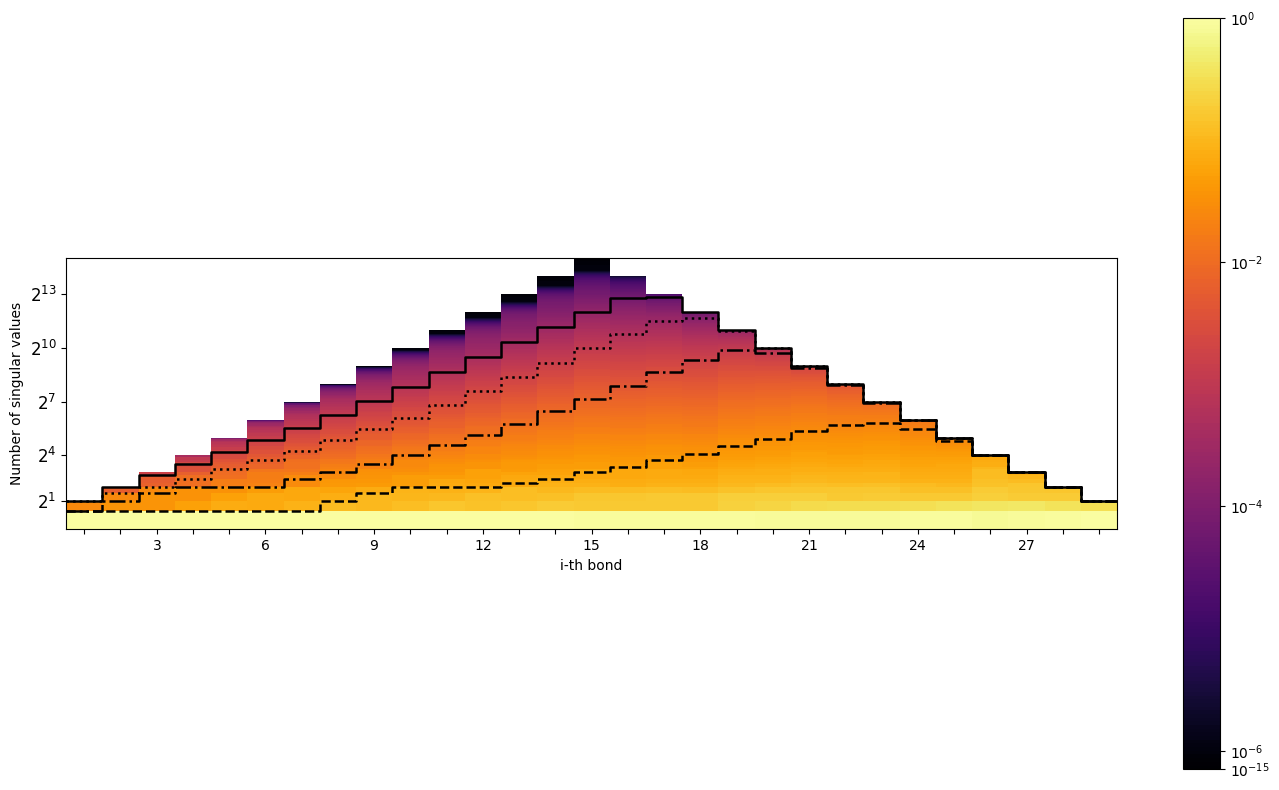

In [88]:
# Schmidt spectrum – x/y swapped, figsize (18, 6), x-axis flipped
# FIX: heatmap data (M) mirrored in x so it matches the flipped axis (no other logic changed)

import numpy as np
import matplotlib.pyplot as plt
import h5py
from matplotlib.colors import BoundaryNorm
from scipy.io import loadmat
from comp_ratio_uneq import comp_ratio_memory

def loadmat_hdf5(filename):
    with h5py.File(filename, "r") as f:
        return f['chi_crit'][:]

chi_name = 'chi_u'

file_path_dns = "chis/full_singular_values_U_t1.mat"
file_path_c2  = "chis/chi_cr_fidelity_l2norm_cf_0.01.mat"
file_path_c3  = "chis/chi_cr_fidelity_l2norm_cf_0.001.mat"
file_path_c4  = "chis/chi_cr_fidelity_l2norm_cf_0.0001.mat"
file_path_c5  = "chis/chi_cr_fidelity_l2norm_cf_1e-05.mat"

with h5py.File(file_path_dns, "r") as f:
    sv_refs = f["sv"]
    sv = [f[ref][()].squeeze() for ref in sv_refs]

data_c2 = loadmat(file_path_c2)
data_c3 = loadmat(file_path_c3)
data_c4 = loadmat(file_path_c4)
data_c5 = loadmat(file_path_c5)

chi_c2 = data_c2[chi_name][0]
chi_c3 = data_c3[chi_name][0]
chi_c4 = data_c4[chi_name][0]
chi_c5 = data_c5[chi_name][0]

nbonds = len(sv)
maxlen = max(len(v) for v in sv)

# rectangular matrix (bond index along axis 0)
M = np.full((nbonds, maxlen), np.nan)
for i, v in enumerate(sv):
    M[i, :len(v)] = v

# --- ONLY FLIP M ALONG THE BOND AXIS (axis=0) ---
# so that when we plot bonds on x and flip x-axis, heatmap content matches the dashed lines
M = M[::-1, :]   # <--- this is the key fix

# color normalization
cmap = "inferno"
cmap_obj = plt.get_cmap(cmap)

hi_edges = np.logspace(0, -6, 200)
lo_edges = np.logspace(-6, -15, 6)
boundaries = np.unique(np.r_[hi_edges, lo_edges])
norm = BoundaryNorm(boundaries, ncolors=cmap_obj.N, clip=True)

# swapped edges
x_edges = np.arange(nbonds + 1)                 # bonds → x
y_edges = np.log2(np.arange(1, maxlen + 2))     # singular-value index → y (log2)

fig, ax = plt.subplots(figsize=(14, 8))

# swapped heatmap (same call, but M has been flipped before transpose)
im = ax.pcolormesh(
    x_edges,
    y_edges,
    M.T,
    cmap=cmap,
    shading="flat",
    norm=norm
)

# flip x-axis (bonds)
ax.invert_xaxis()

# x ticks (bonds) — labels consistent with flip
x_tick_pos = np.arange(0.5, nbonds, 1)
x_tick_labels = []
for i in range(1, nbonds + 1):
    bond = nbonds - i + 1
    x_tick_labels.append(rf"${bond}$" if bond % 3 == 0 else "")
ax.set_xticks(x_tick_pos)
ax.set_xticklabels(x_tick_labels, fontsize=10)

# y ticks (powers of 2)
y_tick_pos_all = np.log2(np.arange(1, maxlen + 1))
y_tick_labels_all = [
    rf"$2^{{{int(np.log2(i))}}}$" if (np.log2(i - 1) % 3 == 1 and i >= 2) else ""
    for i in range(1, maxlen + 1)
]
y_tick_pos = [y for y, lab in zip(y_tick_pos_all, y_tick_labels_all) if lab != ""]
y_tick_labels = [lab for lab in y_tick_labels_all if lab != ""]
ax.set_yticks(y_tick_pos)
ax.set_yticklabels(y_tick_labels, fontsize=12)

# axis labels
ax.set_xlabel("i-th bond")
ax.set_ylabel("Number of singular values")

# colorbar
ticks = [1, 1e-2, 1e-4, 1e-6, 1e-15]
cbar = fig.colorbar(im, ax=ax, ticks=ticks)
cbar.ax.set_yticklabels([f"$10^{{{int(np.log10(t))}}}$" for t in ticks])
cbar.ax.minorticks_off()

# staircase curves (swapped) — keep your already-correct mirroring
y_vals = []
x_vals_c2, x_vals_c3, x_vals_c4, x_vals_c5 = [], [], [], []

for i, v in enumerate(chi_c2):
    x_vals_c2.extend([np.log2(v + 1), np.log2(v + 1)])
    y_vals.extend([i, i + 1])

for v in chi_c3:
    x_vals_c3.extend([np.log2(v + 1), np.log2(v + 1)])
for v in chi_c4:
    x_vals_c4.extend([np.log2(v + 1), np.log2(v + 1)])
for v in chi_c5:
    x_vals_c5.extend([np.log2(v + 1), np.log2(v + 1)])

x_stair = (nbonds - np.asarray(y_vals)).tolist()

ax.plot(x_stair, x_vals_c2, color='black', linestyle='--', linewidth=1.8, label=r"$C=2$")
ax.plot(x_stair, x_vals_c3, color='black', linestyle='-.', linewidth=1.8, label=r"$C=3$")
ax.plot(x_stair, x_vals_c4, color='black', linestyle=':',  linewidth=1.8, label=r"$C=4$")
ax.plot(x_stair, x_vals_c5, color='black', linestyle='-',  linewidth=1.8, label=r"$C=5$")

ax.set_aspect(0.5)
fig.tight_layout()

fig.savefig(f"singval_heatmap_{chi_name}_bar_xy_swapped.png", bbox_inches="tight")
plt.show()


/var/folders/r5/t2snqk2n1ps1l1ghz__b_mg40000gn/T/ipykernel_63635/2347965927.py:42: RuntimeWarning: divide by zero encountered in log2
  rf"$2^{{{int(np.log2(i))}}}$" if (np.log2(i - 1) % 3 == 1 and i >= 2) else ""


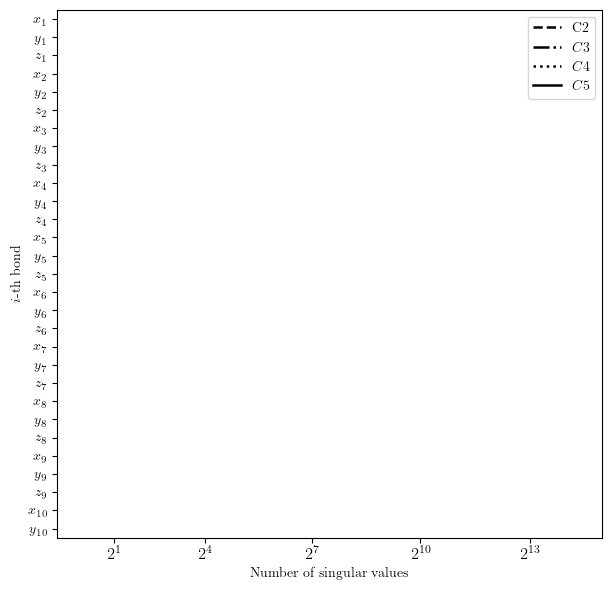

In [19]:
# --- Make x-axis edges log₂-spaced (same as before, using maxlen & nbonds) ---
x_edges = np.log2(np.arange(1, maxlen + 2))  # shape: (maxlen+1,)
y_edges = np.arange(nbonds + 1)              # standard uniform

fig, ax = plt.subplots(figsize=(12, 6))

# --- NO pcolormesh, NO data inside the box ---
# just set limits so the box has the correct size
ax.set_xlim(x_edges.min(), x_edges.max())
ax.set_ylim(nbonds, 0)   # flip Y to match your previous orientation

# --- Y-axis ticks (LaTeX labels x_i, y_i, z_i, ...) ---
y_interleaved_flag = 1

if y_interleaved_flag == 1:
    n_sites = 10
    labels_interleaved = []
    for i in range(1, n_sites + 1):
        labels_interleaved.extend([
            rf"$x_{{{i}}}$",
            rf"$y_{{{i}}}$",
            rf"$z_{{{i}}}$",
        ])

    if len(labels_interleaved) < nbonds:
        labels_interleaved += [""] * (nbonds - len(labels_interleaved))
    else:
        labels_interleaved = labels_interleaved[:nbonds]

    y_tick_pos = np.arange(0.5, nbonds, 1)
    ax.set_yticks(y_tick_pos)
    ax.set_yticklabels(labels_interleaved, fontsize=10)
else:
    y_tick_pos = np.arange(0.5, nbonds, 1)
    y_tick_labels = [rf"${i}$" if i % 3 == 0 else "" for i in range(1, nbonds + 1)]
    ax.set_yticks(y_tick_pos)
    ax.set_yticklabels(y_tick_labels, fontsize=10)

# --- X-axis ticks (same style as before, but no data) ---
x_tick_pos_all = np.log2(np.arange(1, maxlen + 1))
x_tick_labels_all = [
    rf"$2^{{{int(np.log2(i))}}}$" if (np.log2(i - 1) % 3 == 1 and i >= 2) else ""
    for i in range(1, maxlen + 1)
]

x_tick_pos = [x for x, label in zip(x_tick_pos_all, x_tick_labels_all) if label != ""]
x_tick_labels = [label for label in x_tick_labels_all if label != ""]

ax.set_xticks(x_tick_pos)
ax.set_xticklabels(x_tick_labels, fontsize=12)

# --- Axis labels ---
ax.set_ylabel(r"$i$-th bond")
ax.set_xlabel("Number of singular values")

# --- Dummy lines just for legend (no data drawn) ---
dummy_c2, = ax.plot([], [], color='black', linestyle='--', linewidth=1.8, label=r"C2")
dummy_c3, = ax.plot([], [], color='black', linestyle='-.', linewidth=1.8, label=r"$C3$")
dummy_c4, = ax.plot([], [], color='black', linestyle=':', linewidth=1.8, label=r"$C4$")
dummy_c5, = ax.plot([], [], color='black', linestyle='-', linewidth=1.8, label=r"$C5$")

ax.legend(loc="upper right")

# keep aspect if you like
ax.set_aspect(0.5)
fig.tight_layout()

if saveas is not None:
    fig.savefig(saveas if saveas.endswith('.pdf') else saveas + '.pdf', bbox_inches="tight")
if show:
    plt.show()


In [14]:
data_c3

array([ 1,  2,  3,  3,  4,  5,  8, 12, 19, 29, 47, 72, 86, 59, 31, 16,  8,
        4,  2])

In [77]:
#Daniel 1024
import numpy as np
from process_file_1024 import load_velocity_binary

N = 32

# File reading
u = load_velocity_binary('binary_daniel_32/rstrt.0020.bin', N, skip_bytes=192)
v = load_velocity_binary('binary_daniel_32/rstrt.0020.2.bin', N)
w = load_velocity_binary('binary_daniel_32/rstrt.0020.3.bin', N)
p  = load_velocity_binary('binary_daniel_32/rstrt.0020.4.bin', N)

# # Optional: Check array shapes
# print("u shape:", u.shape if u is not None else "Error")
# print("v shape:", v.shape if v is not None else "Error")
# print("w shape:", w.shape if w is not None else "Error")
# print("p  shape:", p.shape  if p  is not None else "Error")

vel_fields = (u, v, w)
direction = "x"
axis = {"x":0,"y":1,"z":2}[direction]
Nlag = vel_fields[0].shape[axis]


In [ ]:
#1_cr

import sys
mps_codes_path = "/ix/pgivi/moe32/Schmidt/mps_py_codes"
sys.path.append(mps_codes_path)

###########################################################################################################################

from calculate_u_comp_fidelity_l2norm import calculate_fidelity, calculate_l2norm
from comp_ratio_uneq import comp_ratio_uneq, comp_ratio_memory
from process_file_1024 import load_velocity_binary, load_JHS_velocity_1024_jul, load_JHS_velocity_1024
from save_as_mat import save_as_mat
import numpy as np
import json

cutoff = 1e-4
comp_path_u = f'truncated_U_1024_il_cf0.0001.mat'
comp_path_v = f'truncated_V_1024_il_cf0.0001.mat'
comp_path_w = f'truncated_W_1024_il_cf0.0001.mat'

###########################################################################################################################
## Binary data - Daniel

# comp_path_u = f'truncated_U_1024_il_cf0.0001.mat'
# comp_path_v = f'truncated_V_1024_il_cf0.0001.mat'
# comp_path_w = f'truncated_W_1024_il_cf0.0001.mat'

# N = 32
# config_path = "config_FI.json"
# with open(config_path, "r") as f:
#     config = json.load(f)
# org_path = config.get("32_binary_dns", {})


# N = 1024
# config_path = mps_codes_path + "/config_FI.json"
# with open(config_path, "r") as f:
#     config = json.load(f)
# org_path = config.get("full_binary_dns", {})


# u = load_velocity_binary(org_path['vel']['U'], N, skip_bytes=192)
# v = load_velocity_binary(org_path['vel']['V'], N)
# w = load_velocity_binary(org_path['vel']['W'], N)
# u = u-np.mean(u)
# v = v-np.mean(v)
# w = w-np.mean(w)


###########################################################################################################################
## JHS data

N = 128
comp_path_u = f'jhs_truncated_u_1024_il_cf0.0001.mat'
comp_path_v = f'jhs_truncated_v_1024_il_cf0.0001.mat'
comp_path_w = f'jhs_truncated_w_1024_il_cf0.0001.mat'
config_path = "config_FI.json"
with open(config_path, "r") as f:
    config = json.load(f)
org_path = config.get("128_dns", {})

# N = 1024
# config_path = mps_codes_path + "/config_FI.json"
# with open(config_path, "r") as f:
#     config = json.load(f)
# org_path = config.get("full_dns", {})

u = load_JHS_velocity_1024(org_path['vel']['U'])
v = load_JHS_velocity_1024(org_path['vel']['V'])
w = load_JHS_velocity_1024(org_path['vel']['W'])
# # u = u-np.mean(u)
# # v = v-np.mean(v)
# # w = w-np.mean(w)


###########################################################################################################################

u_comp, chi_u = load_JHS_velocity_1024_jul(comp_path_u)
v_comp, chi_v = load_JHS_velocity_1024_jul(comp_path_v)
w_comp, chi_w = load_JHS_velocity_1024_jul(comp_path_w)
# u_comp = u_comp-np.mean(u_comp)
# v_comp = v_comp-np.mean(v_comp)
# w_comp = w_comp-np.mean(w_comp)

#comp ratio dof - Nik's thesis
# chi_u = np.expand_dims(chi_u, axis=1)
# chi_v = np.expand_dims(chi_v, axis=1)
# chi_w = np.expand_dims(chi_w, axis=1)
# u_size = (2,) *3* int(np.log2(u.shape[0]))
# cr_u = comp_ratio_uneq(chi_u,u_size)
# cr_v = comp_ratio_uneq(chi_v,u_size)
# cr_w = comp_ratio_uneq(chi_w,u_size)

#comp ratio of memory
cr_u = comp_ratio_memory(chi_u, cr_dof=True) # both cr_memory and cr_dof
cr_v = comp_ratio_memory(chi_v, cr_dof=True)
cr_w = comp_ratio_memory(chi_w, cr_dof=True)
fidelity_u = calculate_fidelity(u, u_comp)
fidelity_v = calculate_fidelity(v, v_comp)
fidelity_w = calculate_fidelity(w, w_comp)
l2_norm_u = calculate_l2norm(u, u_comp)
l2_norm_v = calculate_l2norm(v, v_comp)
l2_norm_w = calculate_l2norm(w, w_comp)

print("cutoff: ", cutoff)
print("cr_u: ", cr_u, "cr_v: ", cr_v, "cr_w: ", cr_w)
print("fidelity_u: ", fidelity_u, "fidelity_v: ", fidelity_v, "fidelity_w: ", fidelity_w)
print("l2_norm_u: ", l2_norm_u, "l2_norm_v: ", l2_norm_v, "l2_norm_w: ", l2_norm_w)

output = {
    'cutoff': cutoff,
    'chi_u': chi_u,
    'chi_v': chi_v,
    'chi_w': chi_w,
    'cr_u': cr_u,
    'cr_v': cr_v,
    'cr_w': cr_w,
    'fidelity_u': fidelity_u,
    'fidelity_v': fidelity_v,
    'fidelity_w': fidelity_w,
    'l2_norm_u': l2_norm_u,
    'l2_norm_v': l2_norm_v,
    'l2_norm_w': l2_norm_w}

save_as_mat(f'chi_cr_fidelity_l2norm_cf_{cutoff}', output)

cutoff:  0.0001
cr_u:  (38.95011329445414, 81.04622043592518) cr_v:  (124.93458834743238, 258.33357969943336) cr_w:  (21.15770782889427, 44.1106366867888)
fidelity_u:  0.8738696948714516 fidelity_v:  0.8733276534936304 fidelity_w:  0.8774895646816845
l2_norm_u:  0.35517601730178827 l2_norm_v:  0.3559549796080598 l2_norm_w:  0.3500441027626955
Saved result to chi_cr_fidelity_l2norm_cf_0.0001.mat


In [44]:
#Comp_memory_true
from comp_ratio_uneq import comp_ratio_uneq, comp_ratio_memory
import numpy as np

# chi_u = np.array([2**i for i in [1,2,3,4,5,6,7,8,9,10,11,12,11,10,9,8,7,6,5,4,3,2,1]])
# chi_u = np.array([2,4,8,16,32,64,128,256,512,1024,2048,4096,2048,1024,512,256,128,64,32,16,8,4,2])
# chi_u = np.array([2,4,8,16,32,64,128,256,333,333 ,333 ,333 ,333 ,333 ,333,256,128,64,32,16,8,4,2])
# chi_u = np.array([2,4,8,16,32,64,64 ,64 ,64 , 64 , 64 , 64 , 64 , 64 , 64, 64, 64,64,32,16,8,4,2])
# chi_u = np.array([1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1])
# chi_u = np.array([2,4,8,16,32,64,128,256,256,256 ,256 ,256 ,256 ,256 ,256,256,128,64,32,16,8,4,2])
# chi_u = np.array([2**i for i in [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,14,13,12,11,10,9,8,7,6,5,4,3,2,1]])
chi_u = np.array([2**i for i in [1,2,3,4,5,6,7,8,9,10,11,12,13,13,12,11,10,9,8,7,6,5,4,3,2,1]])

chi_c = 9
for idx, val in enumerate(chi_u):
    if val > chi_c:
        chi_u[idx] = chi_c

comp_ratio_memory(chi_u, cr_dof=True)

(np.float64(37978.983588002266), np.float64(76871.55097365407))

In [45]:
# (1024/400**(1/3))
# 2**12
# 16**(3/2)
# JHS LES = 32x32x32 -> mps chi = 27
# JHS LES = 64x64x64 -> mps chi = 84
# JET LES = 16x16x16 -> mps chi = 9
# JET LES = 32x32x32 -> mps chi = 29
2**15

32768

In [ ]:
# import numpy as np
# def rel_error(s1,s2):
#     return 100*np.abs(s1-s2)/np.abs(s1)

# disp = 0.5006249914573896
# disp_comp = 11.198300257695939
# rel_error(disp, disp_comp)
# 206.46/23.38
# 575.02/57.81

9.946722020411693

In [ ]:
#Comp_memory_true
from comp_ratio_uneq import comp_ratio_uneq, comp_ratio_memory
import numpy as np

# chi_u = np.array([2**i for i in [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,14,13,12,11,10,9,8,7,6,5,4,3,2,1]])
# chi_u = np.array([2**i for i in [1,2,3,2,1]])
# cr_u = comp_ratio_memory(chi_u, cr_dof=True)

import scipy.io
cr_phi1 = np.zeros((3,2))
cr_u = np.zeros((4,2))
cr_v = np.zeros((4,2))
cr_w = np.zeros((4,2))

for i in range(2,6):
    file_path = f'/Users/massen/Desktop/JHS result/e{i}/co_chi_cr_dof_fidelity_l2norm.mat'
    vel_data = scipy.io.loadmat(file_path)
    chi_u = np.transpose(vel_data['chi_u']).squeeze()
    chi_v = np.transpose(vel_data['chi_v']).squeeze()
    chi_w = np.transpose(vel_data['chi_w']).squeeze()
    cr_u[i-2,] = comp_ratio_memory(chi_u, cr_dof=True)
    cr_v[i-2,] = comp_ratio_memory(chi_v, cr_dof=True)
    cr_w[i-2,] = comp_ratio_memory(chi_w, cr_dof=True)

for i in range(3,6):
    file_path_phi1 = f"/Users/massen/Desktop/JHS result/Daniel data/scalar/e{i}/co_chi_cr_dof_fidelity_l2norm.mat"
    phi1_data = scipy.io.loadmat(file_path_phi1)
    chi_phi1 = np.transpose(phi1_data['chi_phi1']).squeeze()
    cr_phi1[i-3,] = comp_ratio_memory(chi_phi1, cr_dof=True)

print(cr_u)
# print(cr_v)
# print(cr_w)
# print(cr_phi1)

# Cr_vel = 1/3*(cr_u+cr_v+cr_w)
# eq_vel = (1024**3/(Cr_vel[:,0]))**(1/3)
# print(Cr_vel)
# print(eq_vel)


[[4.17213951e+04 8.71685196e+04]
 [2.23269304e+02 4.87207865e+02]
 [1.99367371e+01 4.42964370e+01]
 [4.10588712e+00 9.16419822e+00]]


In [11]:
#Tucker

import sys
mps_codes_path = "/ix/pgivi/moe32/Schmidt/mps_py_codes"
sys.path.append(mps_codes_path)

###########################################################################################################################

from calculate_u_comp_fidelity_l2norm import calculate_fidelity, calculate_l2norm
from comp_ratio_uneq import comp_ratio_uneq, comp_ratio_memory
from process_file_1024 import load_velocity_binary, load_JHS_velocity_1024_jul, load_JHS_velocity_1024
from save_as_mat import save_as_mat
import numpy as np
import json

cutoff = 1e-4
comp_path_u = f'truncated_U_1024_il_cf0.0001.mat'
comp_path_v = f'truncated_V_1024_il_cf0.0001.mat'
comp_path_w = f'truncated_W_1024_il_cf0.0001.mat'

###########################################################################################################################
## Binary data - Daniel

# comp_path_u = f'truncated_U_1024_il_cf0.0001.mat'
# comp_path_v = f'truncated_V_1024_il_cf0.0001.mat'
# comp_path_w = f'truncated_W_1024_il_cf0.0001.mat'

# N = 32
# config_path = "config_FI.json"
# with open(config_path, "r") as f:
#     config = json.load(f)
# org_path = config.get("32_binary_dns", {})


# N = 1024
# config_path = mps_codes_path + "/config_FI.json"
# with open(config_path, "r") as f:
#     config = json.load(f)
# org_path = config.get("full_binary_dns", {})


# u = load_velocity_binary(org_path['vel']['U'], N, skip_bytes=192)
# v = load_velocity_binary(org_path['vel']['V'], N)
# w = load_velocity_binary(org_path['vel']['W'], N)
# u = u-np.mean(u)
# v = v-np.mean(v)
# w = w-np.mean(w)


###########################################################################################################################
## JHS data

N = 128
comp_path_u = f'jhs_truncated_u_1024_il_cf0.0001.mat'
comp_path_v = f'jhs_truncated_v_1024_il_cf0.0001.mat'
comp_path_w = f'jhs_truncated_w_1024_il_cf0.0001.mat'
config_path = "config_FI.json"
with open(config_path, "r") as f:
    config = json.load(f)
org_path = config.get("128_dns", {})

# N = 1024
# config_path = mps_codes_path + "/config_FI.json"
# with open(config_path, "r") as f:
#     config = json.load(f)
# org_path = config.get("full_dns", {})

u = load_JHS_velocity_1024(org_path['vel']['U'])
# v = load_JHS_velocity_1024(org_path['vel']['V'])
# w = load_JHS_velocity_1024(org_path['vel']['W'])
# # u = u-np.mean(u)
# # v = v-np.mean(v)
# # w = w-np.mean(w)


###########################################################################################################################

# u_comp, chi_u = load_JHS_velocity_1024_jul(comp_path_u)
# v_comp, chi_v = load_JHS_velocity_1024_jul(comp_path_v)
# w_comp, chi_w = load_JHS_velocity_1024_jul(comp_path_w)
# u_comp = u_comp-np.mean(u_comp)
# v_comp = v_comp-np.mean(v_comp)
# w_comp = w_comp-np.mean(w_comp)

import quimb.tensor as qtn
from math import log
from autoray import size, reshape
import numpy as np


def comb_from_dense(psi, dim=2, num_branch=3, maxdim=None, cutoff=1e-10, dim_ind_id='I{}', dim_tag_id='R{}', site_ind_id='k{}', site_tag_id='s{}'):
    """
    Create comb tensor network on a given tensor.

    Parameters:
    tensor (np.ndarray): The input tensor to decompose.
    dim (int): The dimension of each mode.
    num_branch (int): The number of branches in the tucker decomposition.
    maxdim (int): The maximum bond dimension for the decomposition.
    cutoff (float): The cutoff value for singular values.

    Returns:
    TN (tuple): A tuple containing the core tensor and factor matrices.
    """
    
    # make sure array_like
    psi = qtn.array_ops.asarray(psi)

    # getting the length of each branch 
    L = round(log(size(psi), dim))
    if L % num_branch != 0:
        raise ValueError(f"Length of each branch must be a multiple of {num_branch}.")
    dims = (dim ** (L // num_branch),) * num_branch
    mps_dims = (dim,) * (L // num_branch) + (-1,)
    
    comb = qtn.tensor_core.TensorNetwork()
    vdag = qtn.Tensor(data=reshape(psi, dims), inds=[dim_ind_id.format(n) for n in range(num_branch)])

    for n in range(num_branch):
        u, vdag = vdag.split(
                    left_inds=dim_ind_id.format(n),
                    ltags=dim_tag_id.format(n),
                    get="tensors",
                    method = 'svd',
                    absorb = 'left',
                    max_bond = maxdim,
                    cutoff = cutoff,
                    bond_ind = 'm{}'.format(n),
                )
        inds = [site_ind_id.format(i + n * (L // num_branch)) for i in range(L // num_branch)] + ['m{}'.format(n)]
        tm = qtn.Tensor(data=reshape(u.data, mps_dims), inds=inds)
        for i in range(L // num_branch - 1):
            tm, tr = tm.split(
                left_inds=inds[:-i-2],
                rtags=site_tag_id.format(i + n * (L // num_branch)),
                get="tensors",
                method = 'svd',
                absorb = 'left',
                max_bond = maxdim,
                cutoff = cutoff,
            )
            comb |= tr
        tm.add_tag(site_tag_id.format((n+1) * (L // num_branch) - 1))
        comb |= tm
        
    vdag.add_tag('core')
    comb |= vdag

    return comb

def dense_from_comb(comb):
    """
    Reconstruct the original tensor from its comb tensor network representation.

    Parameters:
    comb (TN): The comb tensor network.

    Returns:
    np.ndarray: The reconstructed tensor.
    """
    L = len(comb.shape)
    inds = [f'k{i}' for i in range(L)]
    return (comb ^ ...).transpose(*inds, inplace=True).data.reshape(2 ** (L // 3), 2 ** (L // 3), 2 ** (L // 3))

# uu = np.arange(512, dtype=float).reshape(8,8,8)
# core = comb_from_dense(uu, dim=2, num_branch=3, cutoff=1e-100000)
# uu_recon = dense_from_comb(core)
# print(np.linalg.norm(uu - uu_recon))

n=128
max_dim = 128
# uu = np.arange(n**3, dtype=float).reshape(n,n,n)
core = comb_from_dense(u, dim=2, num_branch=3, maxdim=max_dim)
# core = comb_from_dense(u, dim=2, num_branch=3, cutoff=1e-1)
uu_recon = dense_from_comb(core)
print(np.linalg.norm(u - uu_recon)/np.linalg.norm(u))


5.2140886e-06


In [12]:
core

TensorNetwork(tensors=22, indices=42)

In [90]:
# pip install tensorly numpy matplotlib  (if needed)

import time
import numpy as np
import tensorly as tl
from tensorly.decomposition import tucker
from tensorly.tucker_tensor import tucker_to_tensor
import matplotlib.pyplot as plt

tl.set_backend("numpy")

def tucker_truncate(u, ranks, n_iter_max=100, tol=None):
    """
    Tucker decomposition with specified ranks, then reconstruction.
    Returns: core, factors, u_hat, info(dict)
    """
    t0 = time.time()
    # NOTE: 'rank=' not 'ranks='
    core, factors = tucker(u, rank=ranks, init='svd',
                           n_iter_max=n_iter_max, tol=tol)
    u_hat = tucker_to_tensor((core, factors))
    t1 = time.time()

    # Metrics
    fn_u   = np.linalg.norm(u.ravel())                # Frobenius == discrete L2
    err    = u_hat - u
    fn_e   = np.linalg.norm(err.ravel())
    rel_l2 = fn_e / fn_u if fn_u != 0 else np.nan
    snr_db = 20.0 * np.log10(fn_u / fn_e) if fn_e != 0 else np.inf

    # Energy captured (orthonormal factors => ||core||_F^2 / ||u||_F^2)
    energy_ratio = (np.linalg.norm(core.ravel())**2) / (fn_u**2) if fn_u != 0 else np.nan

    # Storage & compression ratio (bigger is better)
    dims = u.shape
    r1,r2,r3 = ranks
    core_sz = r1*r2*r3
    fact_sz = dims[0]*r1 + dims[1]*r2 + dims[2]*r3
    stored  = core_sz + fact_sz
    full    = dims[0]*dims[1]*dims[2]
    compression_ratio = full / stored

    info = {
        "rel_l2": rel_l2,
        "snr_db": snr_db,
        "energy_captured": energy_ratio,
        "compression_ratio": compression_ratio,
        "time_sec": t1 - t0
    }
    return core, factors, u_hat, info

def sweep_ranks(u, rank_list):
    """
    Run tucker_truncate for every (r1,r2,r3) in rank_list.
    Returns list of dict rows for printing/plotting.
    """
    rows = []
    for ranks in rank_list:
        _, _, _, info = tucker_truncate(u, ranks)
        rows.append({
            "ranks": ranks,
            **info
        })
    return rows

def print_results(rows):
    header = f"{'ranks':>12} | {'rel_L2':>10} | {'SNR(dB)':>8} | {'Energy':>8} | {'Comp.×':>8} | {'t(s)':>6}"
    line   = "-" * len(header)
    print(header)
    print(line)
    for r in rows:
        print(f"{str(r['ranks']):>12} | {r['rel_l2']:10.4e} | {r['snr_db']:8.2f} | "
              f"{r['energy_captured']:8.4f} | {r['compression_ratio']:8.2f} | {r['time_sec']:6.2f}")

def plot_error(rows, title="Tucker truncation on 3D field"):
    # Use geometric mean of ranks as a single x-axis proxy
    x = [ (r["ranks"][0]*r["ranks"][1]*r["ranks"][2]) ** (1/3) for r in rows ]
    y = [ r["rel_l2"] for r in rows ]
    plt.figure()
    plt.plot(x, y, marker='o')
    plt.xlabel("Geometric mean of ranks (r̄)")
    plt.ylabel("Relative L2 error")
    plt.title(title)
    plt.grid(True)
    plt.show()

# -------------------------
# Example usage
# -------------------------
if __name__ == "__main__":
    # Replace this with your actual data load
    # u should be a 3D numpy array of shape (128,128,128)
    np.random.seed(0)
    # u = np.random.randn(16,16,16).astype(np.float32)

    # Choose a set of (r1,r2,r3) to compare; symmetric ranks are common:
    # rank_list = [
    #     (4,4,4), (6,6,6), (8,8,8), (12,12,12), (16,16,16), (24,24,24), (32,32,32)
    # ]

    # rank_list = [
    #     (20,20,20), (40,40,40), (60,60,60)
    # ]
    rank_list = [
        (128,128,128)
    ]

    rows = sweep_ranks(u, rank_list)
    print_results(rows)
    # Optional plot
    # plot_error(rows, title="Tucker truncation: error vs. rank")

    rows = []
for ranks in rank_list:
    metrics = []
    for c in range(u.shape[0]):
        _, _, _, info = tucker_truncate(u[c], ranks)
        metrics.append(info)
    # energy-weighted average example:
    rel_l2 = np.mean([m["rel_l2"] for m in metrics])
    snr_db = np.mean([m["snr_db"] for m in metrics])
    energy = np.mean([m["energy_captured"] for m in metrics])
    comp   = np.mean([m["compression_ratio"] for m in metrics])
    tsec   = np.sum([m["time_sec"] for m in metrics])  # sum of components
    rows.append({"ranks": ranks, "rel_l2": rel_l2, "snr_db": snr_db,
                 "energy_captured": energy, "compression_ratio": comp, "time_sec": tsec})
print_results(rows)



       ranks |     rel_L2 |  SNR(dB) |   Energy |   Comp.× |   t(s)
-------------------------------------------------------------------
(128, 128, 128) | 5.8646e-07 |   124.64 |   0.9996 |     0.98 | 127.13


IndexError: tuple index out of range

In [89]:
rows = []
for ranks in rank_list:
    metrics = []
    for c in range(u.shape[0]):
        _, _, _, info = tucker_truncate(u[c], ranks)
        metrics.append(info)
    # energy-weighted average example:
    rel_l2 = np.mean([m["rel_l2"] for m in metrics])
    snr_db = np.mean([m["snr_db"] for m in metrics])
    energy = np.mean([m["energy_captured"] for m in metrics])
    comp   = np.mean([m["compression_ratio"] for m in metrics])
    tsec   = np.sum([m["time_sec"] for m in metrics])  # sum of components
    rows.append({"ranks": ranks, "rel_l2": rel_l2,
                 "energy_captured": energy, "compression_ratio": comp, "time_sec": tsec})
print_results(rows)

IndexError: tuple index out of range

In [ ]:
#skip 1024 grid points to get 512 
import sys
mps_codes_path = "/ix/pgivi/moe32/Schmidt/mps_py_codes"
sys.path.append(mps_codes_path)

###########################################################################################################################

from calculate_u_comp_fidelity_l2norm import calculate_fidelity, calculate_l2norm
from comp_ratio_uneq import comp_ratio_uneq, comp_ratio_memory
from process_file_1024 import load_velocity_binary, load_JHS_velocity_1024_jul, load_JHS_velocity_1024
from save_as_mat import save_as_mat
import numpy as np
import json

###########################################################################################################################
## JHS data

N = 128
config_path = "config_FI.json"
with open(config_path, "r") as f:
    config = json.load(f)
org_path = config.get("128_dns", {})

# N = 1024
# config_path = mps_codes_path + "/config_FI.json"
# with open(config_path, "r") as f:
#     config = json.load(f)
# org_path = config.get("full_dns", {})

u = load_JHS_velocity_1024(org_path['vel']['U'])
v = load_JHS_velocity_1024(org_path['vel']['V'])
w = load_JHS_velocity_1024(org_path['vel']['W'])
# # u = u-np.mean(u)
# # v = v-np.mean(v)
# # w = w-np.mean(w)


u_odd = u[1::2, 1::2, 1::2]   
u_even = u[0::2, 0::2, 0::2]
v_odd = v[1::2, 1::2, 1::2]
v_even = v[0::2, 0::2, 0::2]
w_odd = w[1::2, 1::2, 1::2]
w_even = w[0::2, 0::2, 0::2]

save_as_mat('U_odd', {'U': u_odd})
save_as_mat('U_even', {'U': u_even})
save_as_mat('V_odd', {'V': v_odd})
save_as_mat('V_even', {'V': v_even})
save_as_mat('W_odd', {'W': w_odd})
save_as_mat('W_even', {'W': w_even})

print("u_odd.shape: ", u_odd.shape)
print("u_even.shape: ", u_even.shape)
print("v_odd.shape: ", v_odd.shape)
print("v_even.shape: ", v_even.shape)
print("w_odd.shape: ", w_odd.shape)
print("w_even.shape: ", w_even.shape)

Saved result to U_odd.mat
Saved result to U_even.mat
Saved result to V_odd.mat
Saved result to V_even.mat
Saved result to W_odd.mat
Saved result to W_even.mat
u_odd.shape:  (64, 64, 64)
u_even.shape:  (64, 64, 64)
v_odd.shape:  (64, 64, 64)
v_even.shape:  (64, 64, 64)
w_odd.shape:  (64, 64, 64)
w_even.shape:  (64, 64, 64)


In [3]:
#2_scalars

import sys
mps_codes_path = "/ix/pgivi/moe32/Schmidt/mps_py_codes"
sys.path.append(mps_codes_path)

###########################################################################################################################

from process_file_1024 import load_velocity_binary, load_JHS_velocity_1024_jul, load_JHS_velocity_1024
from calculate_flow_parameters_comb import calculate_flow_parameters_comb_dani, calculate_flow_parameters_comb
from save_as_mat import save_as_mat
import numpy as np
import json



cutoff = 1e-4
comp_path_u = f'truncated_U_1024_il_cf0.0001.mat'
comp_path_v = f'truncated_V_1024_il_cf0.0001.mat'
comp_path_w = f'truncated_W_1024_il_cf0.0001.mat'


###########################################################################################################################
## Binary data - Daniel

# comp_path_u = f'truncated_U_1024_il_cf0.0001.mat'
# comp_path_v = f'truncated_V_1024_il_cf0.0001.mat'
# comp_path_w = f'truncated_W_1024_il_cf0.0001.mat'

N = 32
config_path = "config_FI.json"
with open(config_path, "r") as f:
    config = json.load(f)
org_path = config.get("32_binary_dns", {})


# N = 1024
# config_path = mps_codes_path + "/config_FI.json"
# with open(config_path, "r") as f:
#     config = json.load(f)
# org_path = config.get("full_binary_dns", {})


u = load_velocity_binary(org_path['vel']['U'], N, skip_bytes=192)
v = load_velocity_binary(org_path['vel']['V'], N)
w = load_velocity_binary(org_path['vel']['W'], N)
u = u-np.mean(u)
v = v-np.mean(v)
w = w-np.mean(w)

nu = 0.0005
dx = 2*np.pi/N
dy = dx
dz = dx

###########################################################################################################################
## JHS data

# N = 128
# comp_path_u = f'jhs_truncated_u_1024_il_cf0.0001.mat'
# comp_path_v = f'jhs_truncated_v_1024_il_cf0.0001.mat'
# comp_path_w = f'jhs_truncated_w_1024_il_cf0.0001.mat'
# config_path = "config_FI.json"
# with open(config_path, "r") as f:
#     config = json.load(f)
# org_path = config.get("128_dns", {})

# N = 1024
# config_path = mps_codes_path + "/config_FI.json"
# with open(config_path, "r") as f:
#     config = json.load(f)
# org_path = config.get("full_dns", {})

# u = load_JHS_velocity_1024(org_path['vel']['U'])
# v = load_JHS_velocity_1024(org_path['vel']['V'])
# w = load_JHS_velocity_1024(org_path['vel']['W'])
# u = u-np.mean(u)
# v = v-np.mean(v)
# w = w-np.mean(w)

# nu = 0.000185
# dx = 0.0061359406
# dy = dx
# dz = dx

###########################################################################################################################

u_comp, chi_u = load_JHS_velocity_1024_jul(comp_path_u)
v_comp, chi_v = load_JHS_velocity_1024_jul(comp_path_v)
w_comp, chi_w = load_JHS_velocity_1024_jul(comp_path_w)
u_comp = u_comp-np.mean(u_comp)
v_comp = v_comp-np.mean(v_comp)
w_comp = w_comp-np.mean(w_comp)


# flow_parameters, spectrum = calculate_flow_parameters_comb_dani((u, v, w), (u_comp, v_comp, w_comp), (dx, dy, dz), nu)
flow_parameters, spectrum = calculate_flow_parameters_comb((u, v, w), (u_comp, v_comp, w_comp), (dx, dy, dz), nu)

save_as_mat(f'flow_parameters_cf_{cutoff}', flow_parameters)
save_as_mat(f'spectrum_cf_{cutoff}', spectrum)

print(f'Flow Parameters for cutoff = {cutoff} components:')
for comp, params in flow_parameters.items():
    converted_params = [float(p) for p in params]
    print(f"{comp}:\n{converted_params} \n")


# 0.00553672480595447

Saved grad_dux_dx_comp.h5 successfully.
Saved grad_dux_dy_comp.h5 successfully.
Saved grad_dux_dz_comp.h5 successfully.
Saved grad_duy_dx_comp.h5 successfully.
Saved grad_duy_dy_comp.h5 successfully.
Saved grad_duy_dz_comp.h5 successfully.
Saved grad_duz_dx_comp.h5 successfully.
Saved grad_duz_dy_comp.h5 successfully.
Saved grad_duz_dz_comp.h5 successfully.
 
Saved dissipation_comp.h5 successfully.
Saved result to flow_parameters_cf_0.0001.mat
Saved result to spectrum_cf_0.0001.mat
Flow Parameters for cutoff = 0.0001 components:
E:
[0.69189101557673, 0.9815603314714413, 41.866321338665685] 

mean_eps:
[0.091859602123993, 0.005594768597178295, 93.90943519478081] 

u_prime:
[0.6791617458685032, 0.8089335907936411, 19.107649350772455] 

Lambda:
[0.19406247582719865, 0.7863443732013139, 305.2016598518035] 

Rey_Taylor:
[263.59961978072886, 1068.1100347145564, 305.2016598518035] 

tau:
[0.07377729400246501, 0.2989468198917333, 305.20165985180347] 

eta:
[0.006073602473098853, 0.012225931864

In [12]:
#scalars_for_LES_filtered

import sys
mps_codes_path = "/ix/pgivi/moe32/Schmidt/mps_py_codes"
sys.path.append(mps_codes_path)

###########################################################################################################################

from process_file_1024 import load_velocity_binary, load_JHS_velocity_1024_jul, load_JHS_velocity_1024
from calculate_flow_parameters_comb import calculate_flow_parameters_comb_dani, calculate_flow_parameters_comb
from save_as_mat import save_as_mat
from scipy.io import loadmat
import numpy as np
import json


cutoff = 32
comp_path_u = 'JHS_filtered/filtered_U_t1_32x32x32.mat'
comp_path_v = 'JHS_filtered/filtered_V_t1_32x32x32.mat'
comp_path_w = 'JHS_filtered/filtered_W_t1_32x32x32.mat'

###########################################################################################################################
## JHS data

N = 128
# comp_path_u = f'jhs_truncated_u_1024_il_cf0.0001.mat'
# comp_path_v = f'jhs_truncated_v_1024_il_cf0.0001.mat'
# comp_path_w = f'jhs_truncated_w_1024_il_cf0.0001.mat'
config_path = "config_FI.json"
with open(config_path, "r") as f:
    config = json.load(f)
org_path = config.get("128_dns", {})

# N = 1024
# config_path = mps_codes_path + "/config_FI.json"
# with open(config_path, "r") as f:
#     config = json.load(f)
# org_path = config.get("full_dns", {})

u = load_JHS_velocity_1024(org_path['vel']['U'])
v = load_JHS_velocity_1024(org_path['vel']['V'])
w = load_JHS_velocity_1024(org_path['vel']['W'])
u = u-np.mean(u)
v = v-np.mean(v)
w = w-np.mean(w)

nu = 0.000185
dx = 0.0061359406*cutoff
dy = dx
dz = dx

###########################################################################################################################

import h5py

with h5py.File(comp_path_u, 'r') as f:
    key = list(f.keys())[0]
    u_comp = f[key][()]

with h5py.File(comp_path_v, 'r') as f:
    key = list(f.keys())[0]
    v_comp = f[key][()]

with h5py.File(comp_path_w, 'r') as f:
    key = list(f.keys())[0]
    w_comp = f[key][()]


# flow_parameters, spectrum = calculate_flow_parameters_comb_dani((u, v, w), (u_comp, v_comp, w_comp), (dx, dy, dz), nu)
flow_parameters, spectrum = calculate_flow_parameters_comb((u_comp, v_comp, w_comp), (u_comp, v_comp, w_comp), (dx, dy, dz), nu)

save_as_mat(f'flow_parameters_cf_{cutoff}', flow_parameters)
save_as_mat(f'spectrum_cf_{cutoff}', spectrum)

print(f'Flow Parameters for cutoff = {cutoff} components:')
for comp, params in flow_parameters.items():
    converted_params = [float(p) for p in params]
    print(f"{comp}:\n{converted_params} \n")


Saved grad_dux_dx_comp.h5 successfully.
Saved grad_dux_dy_comp.h5 successfully.
Saved grad_dux_dz_comp.h5 successfully.
Saved grad_duy_dx_comp.h5 successfully.
Saved grad_duy_dy_comp.h5 successfully.
Saved grad_duy_dz_comp.h5 successfully.
Saved grad_duz_dx_comp.h5 successfully.
Saved grad_duz_dy_comp.h5 successfully.
Saved grad_duz_dz_comp.h5 successfully.
 
Saved dissipation_comp.h5 successfully.
Saved result to flow_parameters_cf_32.mat
Saved result to spectrum_cf_32.mat
Flow Parameters for cutoff = 32 components:
E:
[0.69189101557673, 0.5979310092173368, 13.58017436909082] 

mean_eps:
[0.091859602123993, 0.004544369483994009, 95.05291838967474] 

u_prime:
[0.6791617458685032, 0.6313641364629115, 7.037735811293198] 

Lambda:
[0.11804359564985879, 0.4933720983684764, 317.957531412308] 

Rey_Taylor:
[433.3551054602906, 1683.7699937367984, 288.5427845481069] 

tau:
[0.04487697595449897, 0.2017664936507698, 349.5991304212254] 

eta:
[0.002881360885342603, 0.006109566377853048, 112.03752

[0.69189101557673,
 np.float64(0.6673140681999432),
 np.float64(3.552141424513306)]

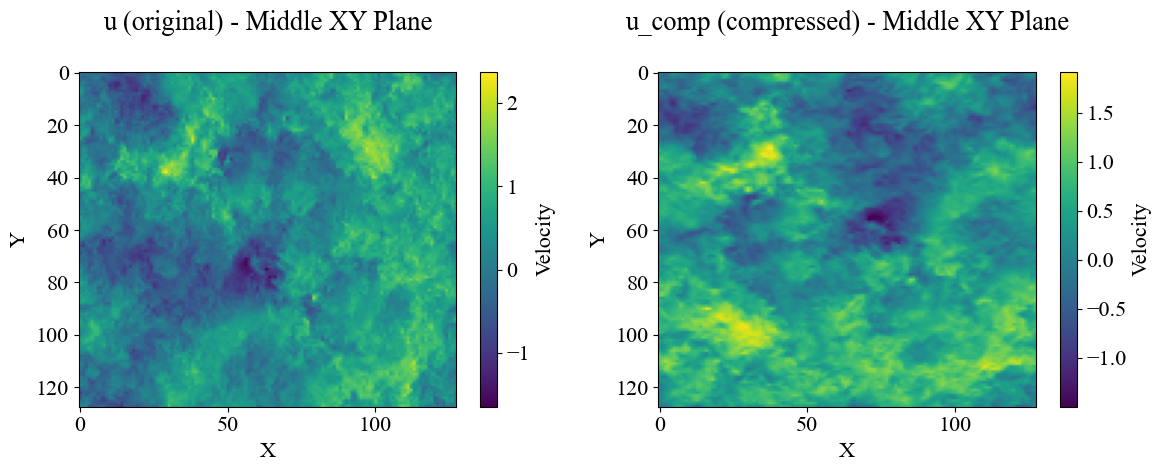

In [35]:
import matplotlib.pyplot as plt

# Assume u and u_comp are 3D arrays: (Nx, Ny, Nz)
# Plot a contour (imshow) at the central z-plane

mid_z = u.shape[2] // 2

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(u[:,:,10], cmap='viridis', aspect='auto')
plt.title('u (original) - Middle XY Plane')
plt.xlabel('X')
plt.ylabel('Y')
plt.colorbar(label='Velocity')

plt.subplot(1,2,2)
plt.imshow(u_comp[10,:,:], cmap='viridis', aspect='auto')
plt.title('u_comp (compressed) - Middle XY Plane')
plt.xlabel('X')
plt.ylabel('Y')
plt.colorbar(label='Velocity')

plt.tight_layout()
plt.show()

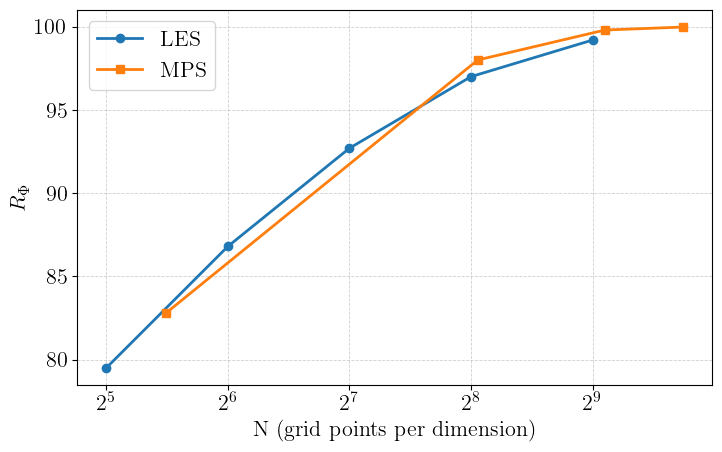

In [25]:
# cr = 12015.9
# ((1024**3)/cr)**(1/3)
import numpy as np
import matplotlib.pyplot as plt

# x-axis: N (grid points per dimension)
N_les = np.array([512, 256, 128,  64,  32], dtype=int)
R_les = np.array([99.2, 97.0, 92.7, 86.8, 79.5], dtype=float)

N_mps = np.array([858, 549, 266,  45], dtype=int)
R_mps = np.array([99.98, 99.8, 98.0, 82.8], dtype=float)

# sort so lines connect in increasing N
i_les = np.argsort(N_les)
i_mps = np.argsort(N_mps)

plt.figure(figsize=(7.5, 4.8))
plt.plot(N_les[i_les], R_les[i_les], marker='o', linewidth=2, label='LES')
plt.plot(N_mps[i_mps], R_mps[i_mps], marker='s', linewidth=2, label='MPS')

plt.xlabel('N (grid points per dimension)')
plt.xscale('log', base=2)
plt.ylabel(r'$R_{\Phi}$')
plt.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
#scalars_for_LES_filtered

import sys
mps_codes_path = "/ix/pgivi/moe32/Schmidt/mps_py_codes"
sys.path.append(mps_codes_path)

###########################################################################################################################

from process_file_1024 import load_velocity_binary, load_JHS_velocity_1024_jul, load_JHS_velocity_1024
from calculate_flow_parameters_comb import calculate_flow_parameters_comb_dani, calculate_flow_parameters_comb
from save_as_mat import save_as_mat
from scipy.io import loadmat
import numpy as np
import json


cutoff = 32
comp_path_u = 'JHS_filtered/filtered_U_t1_64x64x64.mat'
comp_path_v = 'JHS_filtered/filtered_V_t1_64x64x64.mat'
comp_path_w = 'JHS_filtered/filtered_W_t1_64x64x64.mat'

###########################################################################################################################
## Binary data - Daniel

# comp_path_u = f'truncated_U_1024_il_cf0.0001.mat'
# comp_path_v = f'truncated_V_1024_il_cf0.0001.mat'
# comp_path_w = f'truncated_W_1024_il_cf0.0001.mat'

N = 32
config_path = "config_FI.json"
with open(config_path, "r") as f:
    config = json.load(f)
org_path = config.get("32_binary_dns", {})


# N = 1024
# config_path = mps_codes_path + "/config_FI.json"
# with open(config_path, "r") as f:
#     config = json.load(f)
# org_path = config.get("full_binary_dns", {})


u = load_velocity_binary(org_path['vel']['U'], N, skip_bytes=192)
v = load_velocity_binary(org_path['vel']['V'], N)
w = load_velocity_binary(org_path['vel']['W'], N)
u = u-np.mean(u)
v = v-np.mean(v)
w = w-np.mean(w)


nu = 0.000185
dx = 0.0061359406*16
dy = dx
dz = dx

###########################################################################################################################

import h5py

with h5py.File(comp_path_u, 'r') as f:
    key = list(f.keys())[0]
    u_comp = f[key][()]

with h5py.File(comp_path_v, 'r') as f:
    key = list(f.keys())[0]
    v_comp = f[key][()]

with h5py.File(comp_path_w, 'r') as f:
    key = list(f.keys())[0]
    w_comp = f[key][()]


# flow_parameters, spectrum = calculate_flow_parameters_comb_dani((u, v, w), (u_comp, v_comp, w_comp), (dx, dy, dz), nu)
flow_parameters, spectrum = calculate_flow_parameters_comb((u_comp, v_comp, w_comp), (u_comp, v_comp, w_comp), (dx, dy, dz), nu)

save_as_mat(f'flow_parameters_cf_{cutoff}', flow_parameters)
save_as_mat(f'spectrum_cf_{cutoff}', spectrum)

print(f'Flow Parameters for cutoff = {cutoff} components:')
for comp, params in flow_parameters.items():
    converted_params = [float(p) for p in params]
    print(f"{comp}:\n{converted_params} \n")


Saved grad_dux_dx_comp.h5 successfully.
Saved grad_dux_dy_comp.h5 successfully.
Saved grad_dux_dz_comp.h5 successfully.
Saved grad_duy_dx_comp.h5 successfully.
Saved grad_duy_dy_comp.h5 successfully.
Saved grad_duy_dz_comp.h5 successfully.
Saved grad_duz_dx_comp.h5 successfully.
Saved grad_duz_dy_comp.h5 successfully.
Saved grad_duz_dz_comp.h5 successfully.
 
Saved dissipation_comp.h5 successfully.
Saved result to flow_parameters_cf_32.mat
Saved result to spectrum_cf_32.mat
Flow Parameters for cutoff = 32 components:
E:
[0.69189101557673, 0.6395237645191123, 7.568713840570208] 

mean_eps:
[0.091859602123993, 0.01232535095148515, 86.5824032910046] 

u_prime:
[0.6791617458685032, 0.6529541916138335, 3.8588089529624225] 

Lambda:
[0.11804359564985879, 0.3222590056306013, 172.99999111047646] 

Rey_Taylor:
[433.3551054602906, 1183.059399383389, 172.99999111047643] 

tau:
[0.04487697595449897, 0.12251414036643284, 172.9999911104764] 

eta:
[0.002881360885342603, 0.004760789426953273, 65.2271

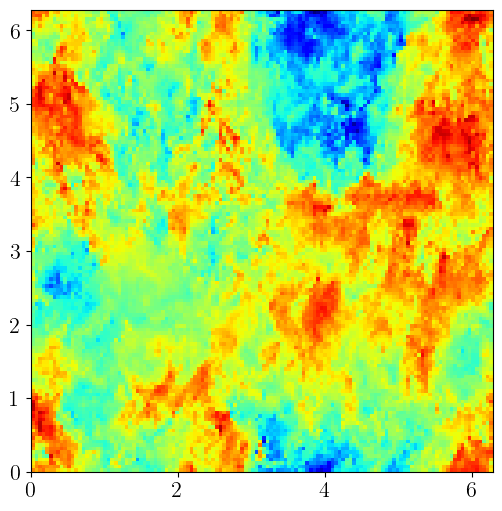

In [ ]:
import cmasher as cmr
import h5py
import scipy.io
import numpy as np
from plotting import plot_contour

# file_path = 'JHS_filtered/scalar/filtered_phi1_16x16x16.mat'
# with h5py.File(file_path, 'r') as f:
#     key = list(f.keys())[0]
#     u_comp = f[key][()]
# u_comp = u_comp.transpose(2, 1, 0)
# v_min = -0.095
# v_max = 0.095

file_path = '/Users/massen/Desktop/JHS_timesteps/U_t1.mat'
mat_contents = scipy.io.loadmat(file_path)
key = list(mat_contents.keys())[3]
u_comp = mat_contents[key][:, :, :, 0]
u_comp = u_comp.transpose(2, 1, 0)

n = u_comp.shape[0]
k = n // 2
u_comp = u_comp[:, :, k]
# c_map = cmr.iceburn
c_map = 'jet'
# v_min = -3
# v_max = 2
# plot_contour(u_comp, c_map=c_map, v_min=v_min, v_max=v_max)
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
img = plt.imshow(u_comp,
                origin='lower',
                cmap=c_map,
                extent=[0, 2*np.pi, 0, 2*np.pi])

# spectrum_LES_32 = spectrum
# spectrum_LES_16 = spectrum
# spectrum_LES_64 = spectrum




In [53]:
print(mat_contents.keys())
# np.shape(u_comp)

dict_keys(['__header__', '__version__', '__globals__', 'Velocity_0501', 'xcoor', 'ycoor', 'zcoor'])


In [2]:
from process_file_1024 import load_JHS_velocity_1024_jul_2

comp_path_u = '/Users/massen/Downloads/U_wf_D=12_periodic.mat'
u_comp = load_JHS_velocity_1024_jul_2(comp_path_u)

u_comp.shape

(1024, 1024, 1024)

In [18]:
# np.linalg.norm(u_comp)
N = 1024
config_path = mps_codes_path + "/config_FI.json"
with open(config_path, "r") as f:
    config = json.load(f)
org_path = config.get("full_dns", {})

u = load_JHS_velocity_1024(org_path['vel']['U'])



NameError: name 'mps_codes_path' is not defined

In [114]:
#2_scalars - 512

import sys
mps_codes_path = "/ix/pgivi/moe32/Schmidt/mps_py_codes"
sys.path.append(mps_codes_path)

###########################################################################################################################

from calculate_flow_parameters_comb import calculate_flow_parameters_comb_dani, calculate_flow_parameters_comb
from save_as_mat import save_as_mat
import numpy as np
from scipy.io import loadmat
import json


cutoff = 1e-5
mat = loadmat('U_t1_cutoff_1e-5.mat')

u_comp = mat['Velocity_0501'][:, :, :, 0]
v_comp = mat['Velocity_0501'][:, :, :, 1]
w_comp = mat['Velocity_0501'][:, :, :, 2]
del mat
u_comp = u_comp-np.mean(u_comp)
v_comp = v_comp-np.mean(v_comp)
w_comp = w_comp-np.mean(w_comp)

###########################################################################################################################
## JHS data

mat = loadmat('/ix/pgivi/moe32/Forced_Isotropic_512/U_t1.mat')
u = mat['Velocity_0501'][:, :, :, 0]
v = mat['Velocity_0501'][:, :, :, 1]
w = mat['Velocity_0501'][:, :, :, 2]
del mat
u = u-np.mean(u)
v = v-np.mean(v)
w = w-np.mean(w)

nu = 0.000185
dx = 0.0061359406
dy = dx
dz = dx

###########################################################################################################################


flow_parameters, spectrum = calculate_flow_parameters_comb((u, v, w), (u_comp, v_comp, w_comp), (dx, dy, dz), nu)

save_as_mat(f'flow_parameters_cf_{cutoff}', flow_parameters)
save_as_mat(f'spectrum_cf_{cutoff}', spectrum)

print(f'Flow Parameters for cutoff = {cutoff} components:')
for comp, params in flow_parameters.items():
    converted_params = [float(p) for p in params]
    print(f"{comp}:\n{converted_params} \n")



FileNotFoundError: [Errno 2] No such file or directory: 'U_t1_cutoff_1e-5.mat'

In [ ]:
#3_scatters

import sys
mps_codes_path = "/ix/pgivi/moe32/Schmidt/mps_py_codes"
sys.path.append(mps_codes_path)

###########################################################################################################################

from process_file_1024 import load_JHS_velocity_1024_jul, load_JHS_velocity_1024, load_velocity_binary
from plotting import plot_scatter, plot_contour
from calculate_flow_parameters_comb import rel_error
from calculate_orientation import calculate_unit_vectors
from save_as_mat import save_as_mat
import numpy as np
import matplotlib.pyplot as plt
import json
import h5py

cutoff = 1e-4
comp_path_u = f'truncated_U_1024_il_cf0.0001.mat'
comp_path_v = f'truncated_V_1024_il_cf0.0001.mat'
comp_path_w = f'truncated_W_1024_il_cf0.0001.mat'

###########################################################################################################################
## Binary data - Daniel

# comp_path_u = f'truncated_U_1024_il_cf0.0001.mat'
# comp_path_v = f'truncated_V_1024_il_cf0.0001.mat'
# comp_path_w = f'truncated_W_1024_il_cf0.0001.mat'

# N = 32
# config_path = "config_FI.json"
# with open(config_path, "r") as f:
#     config = json.load(f)
# org_path = config.get("32_binary_dns", {})


# # N = 1024
# # config_path = mps_codes_path + "/config_FI.json"
# # with open(config_path, "r") as f:
# #     config = json.load(f)
# # org_path = config.get("full_binary_dns", {})


# u = load_velocity_binary(org_path['vel']['U'], N, skip_bytes=192)
# v = load_velocity_binary(org_path['vel']['V'], N)
# w = load_velocity_binary(org_path['vel']['W'], N)
# # u = u-np.mean(u)
# # v = v-np.mean(v)
# # w = w-np.mean(w)

# v_max = 3.6
# v_min = -4.2

###########################################################################################################################
## JHS data

# N = 128
# comp_path_u = f'jhs_truncated_u_1024_il_cf0.0001.mat'
# comp_path_v = f'jhs_truncated_v_1024_il_cf0.0001.mat'
# comp_path_w = f'jhs_truncated_w_1024_il_cf0.0001.mat'
# config_path = "config_FI.json"
# with open(config_path, "r") as f:
#     config = json.load(f)
# org_path = config.get("128_dns", {})

N = 1024
config_path = mps_codes_path + "/config_FI.json"
with open(config_path, "r") as f:
    config = json.load(f)
org_path = config.get("full_dns", {})

u = load_JHS_velocity_1024(org_path['vel']['U'])
v = load_JHS_velocity_1024(org_path['vel']['V'])
w = load_JHS_velocity_1024(org_path['vel']['W'])
# u = u-np.mean(u)
# v = v-np.mean(v)
# w = w-np.mean(w)

# v_max = 2
# v_min = -3

###########################################################################################################################

u_comp, chi_u = load_JHS_velocity_1024_jul(comp_path_u)
v_comp, chi_v = load_JHS_velocity_1024_jul(comp_path_v)
w_comp, chi_w = load_JHS_velocity_1024_jul(comp_path_w)

# u_hat, v_hat, w_hat = calculate_unit_vectors(u, v, w)
# u_comp_hat, v_comp_hat, w_comp_hat = calculate_unit_vectors(u_comp, v_comp, w_comp)

with h5py.File(org_path['disp'], 'r') as file:
    eps = np.array(file['eps'])
with h5py.File('dissipation_comp.h5', 'r') as file:
    eps_comp = np.array(file['eps_comp'])


print("Cutoff:", cutoff)
print(f"Correlation coeff for u:\t {np.corrcoef(u.flatten(), u_comp.flatten())[0, 1]:.6f}")
print(f"Correlation coeff for v:\t {np.corrcoef(v.flatten(), v_comp.flatten())[0, 1]:.6f}")
print(f"Correlation coeff for w:\t {np.corrcoef(w.flatten(), w_comp.flatten())[0, 1]:.6f}\n")

print(f"Correlation coeff for eps.T:\t {np.corrcoef(eps.T.flatten(), eps_comp.flatten())[0, 1]:.6f}")
print(f"Correlation coeff for eps:\t {np.corrcoef(eps.flatten(), eps_comp.flatten())[0, 1]:.6f}\n")

E_k = 0.5 * (u**2+v**2+w**2)
E_k_comp = 0.5 * (u_comp**2+v_comp**2+w_comp**2)
print(f"Correlation coeff for E_k:\t {np.corrcoef(E_k.flatten(), E_k_comp.flatten())[0, 1]:.6f}")

u_comp = u_comp-np.mean(u_comp)
v_comp = v_comp-np.mean(v_comp)
w_comp = w_comp-np.mean(w_comp)
print(f"Correlation coeff for u'u':\t {np.corrcoef((u*u).flatten(), (u_comp*u_comp).flatten())[0, 1]:.6f}")
print(f"Correlation coeff for v'v':\t {np.corrcoef((v*v).flatten(), (v_comp*v_comp).flatten())[0, 1]:.6f}")
print(f"Correlation coeff for w'w':\t {np.corrcoef((w*w).flatten(), (w_comp*w_comp).flatten())[0, 1]:.6f}\n")
print(f"Correlation coeff for u'v':\t {np.corrcoef((u*v).flatten(), (u_comp*v_comp).flatten())[0, 1]:.6f}")
print(f"Correlation coeff for u'w':\t {np.corrcoef((u*w).flatten(), (u_comp*w_comp).flatten())[0, 1]:.6f}")
print(f"Correlation coeff for v'w':\t {np.corrcoef((v*w).flatten(), (v_comp*w_comp).flatten())[0, 1]:.6f}\n")

# plot_scatter(E_k, E_k_comp, cutoff, title='Kinetic Energy', label=r'$E_{k}$', file_name='Kinetic_Energy')
# plot_scatter(eps.T, eps_comp, cutoff, title='Dissipation', label=r'$\varepsilon$', file_name='Dissipation_scatter_2')
# plot_scatter(u, u_comp, cutoff, title='Velocity u', label='u', file_name='Velocity_u')
# plot_scatter(v, v_comp, cutoff, title='Velocity v', label='v', file_name='Velocity_v')
# plot_scatter(w, w_comp, cutoff, title='Velocity w', label='w', file_name='Velocity_w')

# plot_scatter(u*u, u_comp*u_comp, cutoff, title='Reynolds Stress u\'u\'', label='u\'u\'', file_name='Reynolds_Stress_uu')
# plot_scatter(v*v, v_comp*v_comp, cutoff, title='Reynolds Stress v\'v\'', label='v\'v\'', file_name='Reynolds_Stress_vv')
# plot_scatter(w*w, w_comp*w_comp, cutoff, title='Reynolds Stress w\'w\'', label='w\'w\'', file_name='Reynolds_Stress_ww')
# plot_scatter(u*v, u_comp*v_comp, cutoff, title='Reynolds Stress u\'v\'', label='u\'v\'', file_name='Reynolds_Stress_uv')
# plot_scatter(u*w, u_comp*w_comp, cutoff, title='Reynolds Stress u\'w\'', label='u\'w\'', file_name='Reynolds_Stress_uw')
# plot_scatter(v*w, v_comp*w_comp, cutoff, title='Reynolds Stress v\'w\'', label='v\'w\'', file_name='Reynolds_Stress_vw')


# plot_scatter(u_hat, u_comp_hat, cutoff, title='Orientation of Velocity u', label='u hat', file_name='Orientation_of_Velocity_u')
# plot_scatter(v_hat, v_comp_hat, cutoff, title='Orientation of Velocity v', label='v hat', file_name='Orientation_of_Velocity_v')
# plot_scatter(w_hat, w_comp_hat, cutoff, title='Orientation of Velocity w', label='w hat', file_name='Orientation_of_Velocity_w')

# print(f'DNS:  mean(u) = {np.mean(u)}, max(u) = {np.max(u)}, min(u) = {np.min(u)}')
# print(f'Comp: mean(u) = {np.mean(u_comp)}, max(u) = {np.max(u_comp)}, min(u) = {np.min(u_comp)}')
# print(f'DNS:  mean(v) = {np.mean(v)}, max(v) = {np.max(v)}, min(v) = {np.min(v)})')
# print(f'Comp: mean(v) = {np.mean(v_comp)}, max(v) = {np.max(v_comp)}, min(v) = {np.min(v_comp)}')
# print(f'DNS:  mean(w) = {np.mean(w)}, max(w) = {np.max(w)}, min(w) = {np.min(w)}')
# print(f'Comp: mean(w) = {np.mean(w_comp)}, max(w) = {np.max(w_comp)}, min(w) = {np.min(w_comp)}')

# k = N // 2
# print("max u at k = ", k, " is ", np.max(u[:, :, k]))
# print("min u at k = ", k, " is ", np.min(u[:, :, k]))

# print("\nmax u_comp at k = ", k, " is ", np.max(u_comp[:, :, k]))
# print("min u_comp at k = ", k, " is ", np.min(u_comp[:, :, k]))

# c_map = 'cmr.iceburn'

# plot_contour(u, c_map=c_map, v_min=v_min, v_max=v_max)
# plot_contour(u_comp, cutoff=cutoff, c_map=c_map, v_min=v_min, v_max=v_max)


# u = u-np.mean(u)
# v = v-np.mean(v)
# w = w-np.mean(w)
# u_comp = u_comp-np.mean(u_comp)
# v_comp = v_comp-np.mean(v_comp)
# w_comp = w_comp-np.mean(w_comp)

# # mean_rs[_][0] = truth, mean_rs[_][1] = comp, mean_rs[_][2] = rel_error
# mean_rs = {'uu': [0, 0, 0], 'vv': [0, 0, 0], 'ww': [0, 0, 0], 'uv': [0, 0, 0], 'uw': [0, 0, 0], 'vw': [0, 0, 0]}
# mean_rs['uu'][0]= np.mean(u*u)
# mean_rs['uu'][1]= np.mean(u_comp*u_comp)
# mean_rs['uu'][2]= rel_error(mean_rs['uu'][0], mean_rs['uu'][1])

# mean_rs['vv'][0]= np.mean(v*v)
# mean_rs['vv'][1]= np.mean(v_comp*v_comp)
# mean_rs['vv'][2]= rel_error(mean_rs['vv'][0], mean_rs['vv'][1])

# mean_rs['ww'][0]= np.mean(w*w)
# mean_rs['ww'][1]= np.mean(w_comp*w_comp)
# mean_rs['ww'][2]= rel_error(mean_rs['ww'][0], mean_rs['ww'][1])

# mean_rs['uv'][0]= np.mean(u*v)
# mean_rs['uv'][1]= np.mean(u_comp*v_comp)
# mean_rs['uv'][2]= rel_error(mean_rs['uv'][0], mean_rs['uv'][1])

# mean_rs['uw'][0]= np.mean(u*w)
# mean_rs['uw'][1]= np.mean(u_comp*w_comp)
# mean_rs['uw'][2]= rel_error(mean_rs['uw'][0], mean_rs['uw'][1])

# mean_rs['vw'][0]= np.mean(v*w)
# mean_rs['vw'][1]= np.mean(v_comp*w_comp)
# mean_rs['vw'][2]= rel_error(mean_rs['vw'][0], mean_rs['vw'][1])

# save_as_mat('mean_rs', mean_rs)

# print('mean E_k: ',np.mean(E_k))
# print('mean u\'u\': ',mean_rs['uu'])
# print('mean v\'v\': ',mean_rs['vv'])
# print('mean w\'w\': ',mean_rs['ww'])
# print('mean u\'v\': ',mean_rs['uv'])
# print('mean u\'w\': ',mean_rs['uw'])
# print('mean v\'w\': ',mean_rs['vw'])


Cutoff: 0.0001
Correlation coeff for u:	 0.999732
Correlation coeff for v:	 0.999742
Correlation coeff for w:	 0.999718

Correlation coeff for eps.T:	 0.163177
Correlation coeff for eps:	 0.988221

Correlation coeff for E_k:	 0.999271
Correlation coeff for u'u':	 0.999319
Correlation coeff for v'v':	 0.999407
Correlation coeff for w'w':	 0.999371

Correlation coeff for u'v':	 0.999346
Correlation coeff for u'w':	 0.999399
Correlation coeff for v'w':	 0.999351



Cutoff: 0.0001
Correlation coeff for grad_dux_dx: 0.98245711038269
Correlation coeff for grad_dux_dy: 0.9938466791682208
Correlation coeff for alpha: 0.973622512320449
Correlation coeff for beta: 0.9609815975694244
Correlation coeff for gamma: 0.987040991604893


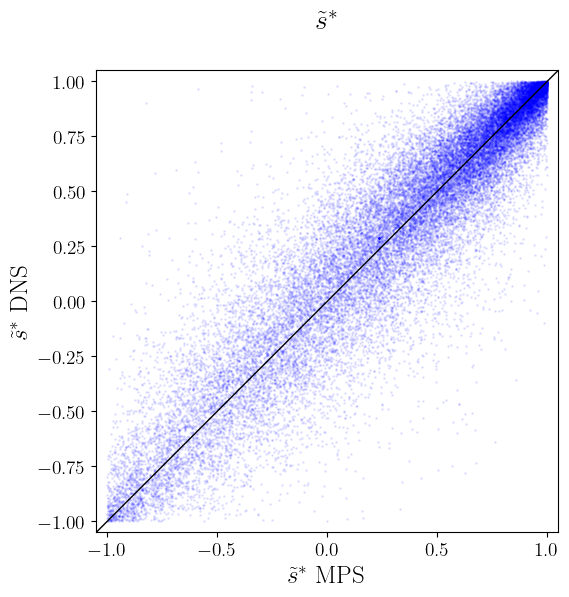

Correlation coeff for s_tilde: 0.9272198455736425


In [ ]:
#84_scatters_grad_strain_rate

import sys
mps_codes_path = "/ix/pgivi/moe32/Schmidt/mps_py_codes"
sys.path.append(mps_codes_path)

###########################################################################################################################

from plotting import plot_scatter
from save_as_mat import save_as_mat, load_h5
import numpy as np
import matplotlib.pyplot as plt
import json

cutoff = 1e-4

###########################################################################################################################
## Binary data - Daniel

# N = 32
# config_path = "config_FI.json"
# with open(config_path, "r") as f:
#     config = json.load(f)
# org_path = config.get("32_binary_dns", {})

###########################################################################################################################
## JHS data

N = 1024
config_path = mps_codes_path + "/config_FI.json"
with open(config_path, "r") as f:
    config = json.load(f)
org_path = config.get("full_dns", {})

###########################################################################################################################
legend_flag = False
grad_dux_dx = load_h5(org_path['grad_vel']['dux_dx'])
grad_dux_dx_comp = load_h5("grad_dux_dx_comp.h5")
# plot_scatter(grad_dux_dx, grad_dux_dx_comp, cutoff, title=r'$\partial u_x / \partial x$', 
#              label=r'$\partial u_x / \partial x$', file_name=f'Scatter_grad_dux_dx_cf_{cutoff}'
#              , legend_flag=legend_flag)
print("Cutoff:", cutoff)
print("Correlation coeff for grad_dux_dx:",np.corrcoef(grad_dux_dx.flatten(), grad_dux_dx_comp.flatten())[0, 1])
del grad_dux_dx, grad_dux_dx_comp

grad_dux_dy = load_h5(org_path['grad_vel']['dux_dy'])
grad_dux_dy_comp = load_h5("grad_dux_dy_comp.h5")
# plot_scatter(grad_dux_dy, grad_dux_dy_comp, cutoff, title=r'$\partial u_x / \partial y$', 
#              label=r'$\partial u_x / \partial y$', file_name=f'Scatter_grad_dux_dy_cf_{cutoff}'
#              , legend_flag=legend_flag)
print("Correlation coeff for grad_dux_dy:",np.corrcoef(grad_dux_dy.flatten(), grad_dux_dy_comp.flatten())[0, 1])
del grad_dux_dy, grad_dux_dy_comp

alpha = load_h5(org_path['strain_rate']['alpha'])
alpha_comp = load_h5('Strain_rate_eigen_values_alpha_comp.h5')
# plot_scatter(alpha, alpha_comp, cutoff, title=r'$\alpha$', label=r'$\alpha$', 
#              file_name=f'Scatter_strain_rate_eigen_values_alpha_cf_{cutoff}'
#              , legend_flag=legend_flag)
print("Correlation coeff for alpha:",np.corrcoef(alpha.flatten(), alpha_comp.flatten())[0, 1])
del alpha, alpha_comp

beta  = load_h5(org_path['strain_rate']['beta'])
beta_comp = load_h5('Strain_rate_eigen_values_beta_comp.h5')
# plot_scatter(beta, beta_comp, cutoff, title=r'$\beta$', label=r'$\beta$', 
#              file_name=f'Scatter_strain_rate_eigen_values_beta_cf_{cutoff}'
#              , legend_flag=legend_flag)
print("Correlation coeff for beta:",np.corrcoef(beta.flatten(), beta_comp.flatten())[0, 1])
del beta, beta_comp

gamma = load_h5(org_path['strain_rate']['gamma'])
gamma_comp = load_h5('Strain_rate_eigen_values_gamma_comp.h5')
# plot_scatter(gamma, gamma_comp, cutoff, title=r'$\gamma$', label=r'$\gamma$', 
#              file_name=f'Scatter_strain_rate_eigen_values_gamma_cf_{cutoff}'
#              , legend_flag=legend_flag)
print("Correlation coeff for gamma:",np.corrcoef(gamma.flatten(), gamma_comp.flatten())[0, 1])
del gamma, gamma_comp

s_tilde = load_h5(org_path['strain_rate']['s_tilde'])
s_tilde_comp = load_h5('Strain_rate_eigen_values_stilde_comp.h5')
plot_scatter(s_tilde, s_tilde_comp, cutoff, title=r'$\tilde{s}^*$', label=r'$\tilde{s}^*$', 
             file_name=f'Scatter_strain_rate_eigen_values_stilde_cf_{cutoff}'
             , legend_flag=legend_flag, alpha=0.08)
print("Correlation coeff for s_tilde:",np.corrcoef(s_tilde.flatten(), s_tilde_comp.flatten())[0, 1])
del s_tilde, s_tilde_comp


In [ ]:
#edit plots


#Joint PDF
# box = (144, 55, 1110, 914)
#colorbar Joint PDF
# box = (23, 26, 61, 818)

#Joint PDF
# bg = ax.imshow(im_data, extent=[-10, 10, -10, 10], aspect='auto')
# ax.set_xlabel(r'$R/Q_{w}^{\frac{3}{2}}$')
# ax.set_ylabel(r'$Q/Q_{w}$')
# ax.set_xticks([-10, -5, 0, 5, 10])
# ax.set_yticks([-10, -5, 0, 5, 10])

#colorbar Joint PDF
# bg = ax.imshow(im_data, extent=[0, 0.5, -8, 0.954], aspect=1.5)
# ax.tick_params(axis='y', direction='in', right=True, left=False, labelright=True, labelleft=False)
# ax.set_xticks([])
# ax.set_yticks([-8, -6, -4, -2, 0])
# ax.set_yticklabels([r'$10^{-8}$', r'$10^{-6}$', r'$10^{-4}$', r'$10^{-2}$', r'$10^{0}$'])

# ax.set_xlabel(r"$\Phi_{MPS}$")
# ax.set_ylabel(r"$\Phi_{DNS}$")
# ax.set_xticks([0, 0.5, 1.0])
# ax.set_yticks([0, 0.5, 1.0])


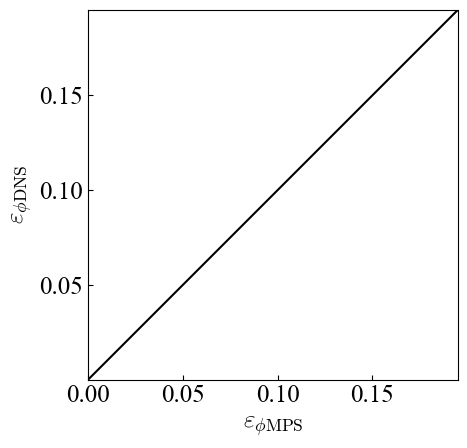

In [8]:
#edit plots

from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "cm",
    "font.size": 18,
    "axes.titlepad": 30  
})

file_name = "Scatter_Kinetic Energy"
# file_name = "Joint_PDF"
file_case = "e3"
# file_name = "mps"
# file_name = "colorbar"
file_path = f"/Users/massen/Desktop/JHS result/{file_case}/plots"
im = Image.open(f"{file_path}/{file_name}.png")
# im = Image.open(f"/Users/massen/Pictures/Picture1.png")

# box = (168, 210, 1560, 1595)
# box = (346, 235, 1872, 1758)
box = (0, 4, 1435, 1071)

legend_flag = True
im_data = im.crop(box)
fig, ax = plt.subplots()

# bg = ax.imshow(im_data, extent=[0, 1, 0, 1], aspect='equal')
# bg = ax.imshow(im_data, extent=[-0.114, 0.103, -0.114, 0.103], aspect='equal')
# bg = ax.imshow(im_data, extent=[-3.94, 2.94, -3.94, 2.94], aspect='equal')
ax.plot([0, 0.195], [0, 0.195], 'k-')
ax.set_xlabel(r"${\varepsilon}_{\mathrm{\phi MPS}}$")
ax.set_ylabel(r"${\varepsilon}_{\mathrm{\phi DNS}}$")
# ax.set_xlabel(r'$R/Q_{w}^{\frac{3}{2}}$')
# ax.set_ylabel(r'$Q/Q_{w}$')
ax.set_xticks([0, 0.05, 0.10, 0.15])
ax.set_yticks([0.05, 0.10, 0.15])
ax.tick_params(axis='both', which='both', direction='in')
ax.set_xlim(0, 0.195)
ax.set_ylim(0, 0.195)
ax.set_aspect('equal')


# if legend_flag:
#     # patch_mps = mpatches.Patch(color='blue', label='MPS')
#     # line_yx = mlines.Line2D([], [], color='black', label='y = x')
#     # line_yx = mlines.Line2D([], [], color='black', label='DNS')
#     # line_mps = mlines.Line2D([], [], color='blue', label='MPS')
#     # line_th = mlines.Line2D([], [], color='red', label=fr"$\frac{{27}}{{4}} R^2 + Q^3 = 0$")
#     # ax.legend(handles=[patch_mps, line_yx], fontsize=12, loc='upper left')
#     # Legend with full opacity and custom box size
#     ax.legend(
#         handles=[patch_mps, line_yx],
#         handles=[line_yx, line_mps, line_th],
#         fontsize=12,
#         loc='upper left',
#         framealpha=1,       # full opacity
#         borderpad=0.5,      # space inside the legend border
#         handlelength=1,     # length of legend handles
#         handleheight=0.5,   # height of legend handles
#         labelspacing=0.5    # space between legend entries
#         )

plt.savefig(f"{file_path}/edited/{file_name}.pdf", dpi=300, bbox_inches='tight')
# plt.savefig(f"{file_name}_edited.png", dpi=300, bbox_inches='tight')

plt.show()

mean of 15*nu*grad_dux_dx**2:	 0.004812
mean of 15*nu*grad_duy_dy**2:	 0.005152
mean of 15*nu*grad_duz_dz**2:	 0.004469
mean of 15/2*nu*grad_dux_dy**2:	 0.006583
mean of 15/2*nu*grad_dux_dz**2:	 0.004755
mean of 15/2*nu*grad_duy_dx**2:	 0.005063
mean of 15/2*nu*grad_duy_dz**2:	 0.004208
mean of 15/2*nu*grad_duz_dx**2:	 0.006116
mean of 15/2*nu*grad_duz_dy**2:	 0.007584
mean of eps:			 0.005537


/Users/massen/Desktop/Johns Hopkins Turbulence Database/Schmidt/Nik_code/code/AnalysingResultsFromDNS_demo/ComputationalSpaces/Massen_Lib/plotting.py:489: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(yticklabels)
/Users/massen/Desktop/Johns Hopkins Turbulence Database/Schmidt/Nik_code/code/AnalysingResultsFromDNS_demo/ComputationalSpaces/Massen_Lib/plotting.py:498: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xticklabels)
/Users/massen/Desktop/Johns Hopkins Turbulence Database/Schmidt/Nik_code/code/AnalysingResultsFromDNS_demo/ComputationalSpaces/Massen_Lib/plotting.py:506: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xticklabels, fontproperties=bold_font)
/Users/massen/Desktop/Johns Hopkins Turbulence Database/Schmidt/Nik_code/code/AnalysingResultsFromDNS_demo/ComputationalSpaces/Massen_Lib/plotting.py:507: UserWarning: FixedFormatter

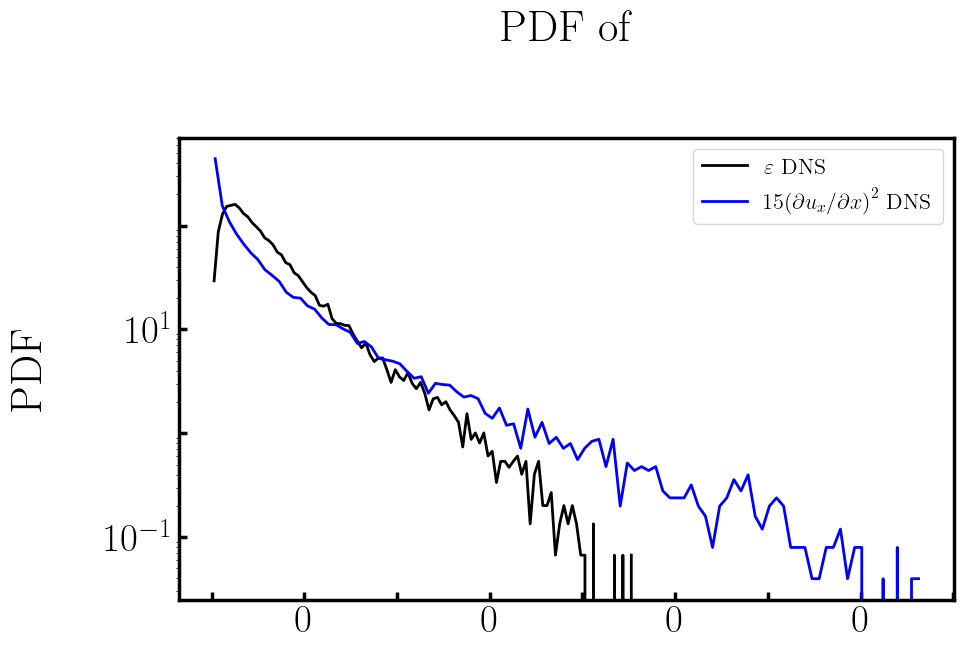

/Users/massen/Desktop/Johns Hopkins Turbulence Database/Schmidt/Nik_code/code/AnalysingResultsFromDNS_demo/ComputationalSpaces/Massen_Lib/plotting.py:489: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(yticklabels)
/Users/massen/Desktop/Johns Hopkins Turbulence Database/Schmidt/Nik_code/code/AnalysingResultsFromDNS_demo/ComputationalSpaces/Massen_Lib/plotting.py:498: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xticklabels)
/Users/massen/Desktop/Johns Hopkins Turbulence Database/Schmidt/Nik_code/code/AnalysingResultsFromDNS_demo/ComputationalSpaces/Massen_Lib/plotting.py:506: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xticklabels, fontproperties=bold_font)
/Users/massen/Desktop/Johns Hopkins Turbulence Database/Schmidt/Nik_code/code/AnalysingResultsFromDNS_demo/ComputationalSpaces/Massen_Lib/plotting.py:507: UserWarning: FixedFormatter

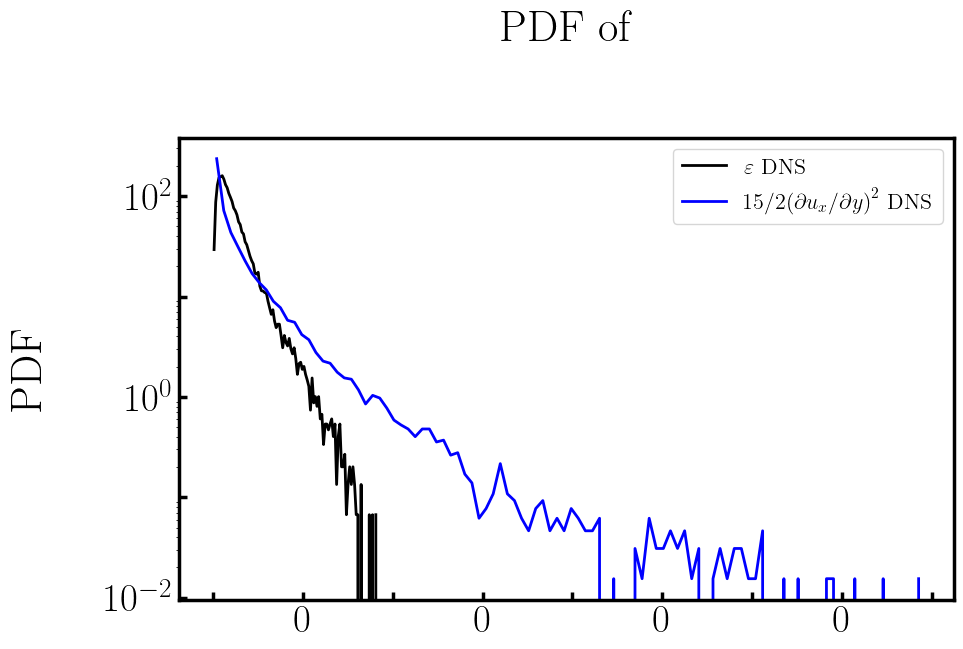

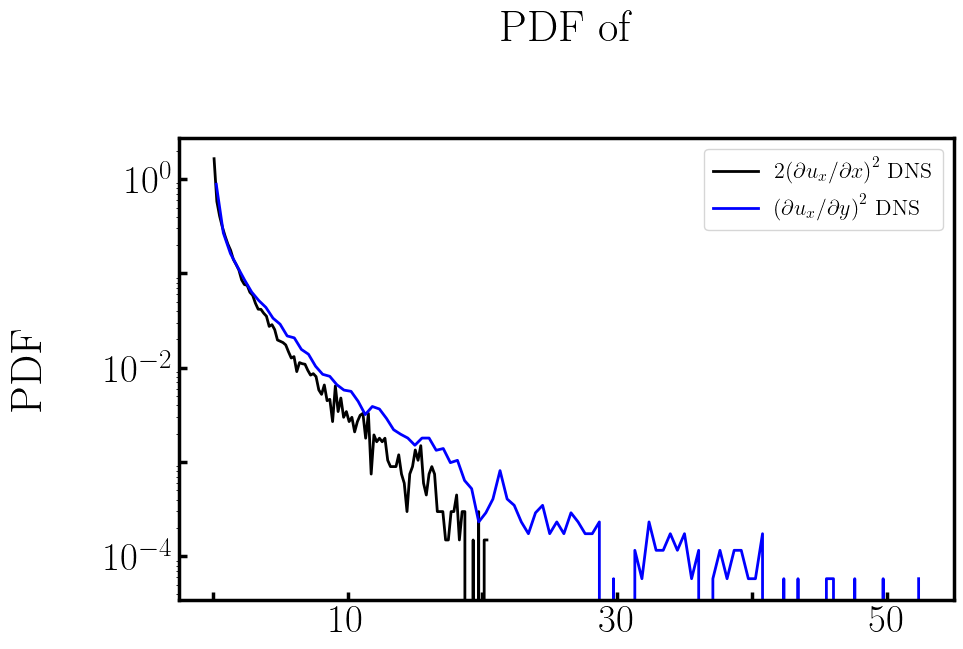

In [ ]:
#4_pdf_grad

import sys
mps_codes_path = "/ix/pgivi/moe32/Schmidt/mps_py_codes"
sys.path.append(mps_codes_path)

###########################################################################################################################

#PDF of Gradients

import numpy as np
from save_as_mat import load_h5
from plotting import plot_pdf, plot_pdf_eps
import json
import h5py


cutoff = 1e-4
# grad_dux_dx_comp = load_h5("grad_dux_dx_comp.h5")
# grad_dux_dy_comp = load_h5("grad_dux_dy_comp.h5")
# grad_dux_dz_comp = load_h5("grad_dux_dz.h5")
# grad_duy_dx_comp = load_h5("grad_duy_dx.h5")
# grad_duy_dy_comp = load_h5("grad_duy_dy.h5")
# grad_duy_dz_comp = load_h5("grad_duy_dz.h5")
# grad_duz_dx_comp = load_h5("grad_duz_dx.h5")
# grad_duz_dy_comp = load_h5("grad_duz_dy.h5")
# grad_duz_dz_comp = load_h5("grad_duz_dz.h5")


###########################################################################################################################
## Binary data - Daniel

# N = 32
# config_path = "config_FI.json"
# with open(config_path, "r") as f:
#     config = json.load(f)
# org_path = config.get("32_binary_dns", {})
# nu = 0.0005

# # N = 1024
# # config_path = mps_codes_path + "/config_FI.json"
# # with open(config_path, "r") as f:
# #     config = json.load(f)
# # org_path = config.get("full_binary_dns", {})

###########################################################################################################################
## JHS data

# N = 128
# config_path = "config_FI.json"
# with open(config_path, "r") as f:
#     config = json.load(f)
# org_path = config.get("128_dns", {})

N = 1024
config_path = mps_codes_path + "/config_FI.json"
with open(config_path, "r") as f:
    config = json.load(f)
org_path = config.get("full_dns", {})
nu = 0.000185


###########################################################################################################################


grad_dux_dx = load_h5(org_path['grad_vel']['dux_dx'])
grad_dux_dy = load_h5(org_path['grad_vel']['dux_dy'])
grad_dux_dz = load_h5(org_path['grad_vel']['dux_dz'])
grad_duy_dx = load_h5(org_path['grad_vel']['duy_dx'])
grad_duy_dy = load_h5(org_path['grad_vel']['duy_dy'])
grad_duy_dz = load_h5(org_path['grad_vel']['duy_dz'])
grad_duz_dx = load_h5(org_path['grad_vel']['duz_dx'])
grad_duz_dy = load_h5(org_path['grad_vel']['duz_dy'])
grad_duz_dz = load_h5(org_path['grad_vel']['duz_dz'])
with h5py.File(org_path['disp'], 'r') as file:
    eps = np.array(file['eps'])

print(f'mean of 15*nu*grad_dux_dx**2:\t {np.mean(15*nu*(grad_dux_dx)**2):.6f}')
print(f'mean of 15*nu*grad_duy_dy**2:\t {np.mean(15*nu*(grad_duy_dy)**2):.6f}')
print(f'mean of 15*nu*grad_duz_dz**2:\t {np.mean(15*nu*(grad_duz_dz)**2):.6f}')

print(f'mean of 15/2*nu*grad_dux_dy**2:\t {np.mean(15/2*nu*(grad_dux_dy)**2):.6f}')
print(f'mean of 15/2*nu*grad_dux_dz**2:\t {np.mean(15/2*nu*(grad_dux_dz)**2):.6f}')
print(f'mean of 15/2*nu*grad_duy_dx**2:\t {np.mean(15/2*nu*(grad_duy_dx)**2):.6f}')
print(f'mean of 15/2*nu*grad_duy_dz**2:\t {np.mean(15/2*nu*(grad_duy_dz)**2):.6f}')
print(f'mean of 15/2*nu*grad_duz_dx**2:\t {np.mean(15/2*nu*(grad_duz_dx)**2):.6f}')
print(f'mean of 15/2*nu*grad_duz_dy**2:\t {np.mean(15/2*nu*(grad_duz_dy)**2):.6f}')
print(f'mean of eps:\t\t\t {eps.mean():.6f}')
del grad_dux_dz, grad_duy_dx, grad_duy_dz, grad_duz_dx, grad_duz_dy

# with h5py.File('dissipation_comp.h5', 'r') as file:
#     eps_comp = np.array(file['eps_comp'])

#Daniel's data 
# pdf_min = 1e-11
# pdf_max = 1e-1
# x_max = 550
# # x_max_longitudinal = 300
# # x_min_longitudinal = -x_max_longitudinal
# x_min = -x_max
# gen_norm_dist = True

#JHS data 
# pdf_min = 1e-8
# pdf_max = 1e-0
# x_max = 200
# x_min = -x_max
# laplace_dist = True


pdf_min = None
pdf_max = None
x_max = None
x_min = None
laplace_dist = True

# plot_pdf_eps({'DNS': eps, f'Comp cutoff {cutoff}': eps_comp}, log_norm_dist=False, 
#              x_min=x_min, x_max=x_max, pdf_min=pdf_min, pdf_max=pdf_max)

plot_pdf({r'$\varepsilon$ DNS': eps, r'$15{(\partial u_x / \partial x)}^2$ DNS': 15*nu*(grad_dux_dx**2)},
         title=r' ', file_name='eps_grad_dux_dx2')
plot_pdf({r'$\varepsilon$ DNS': eps, r'$15/2{(\partial u_x / \partial y)}^2$ DNS': 15/2*nu*(grad_dux_dy**2)},
         title=r' ', file_name='eps_grad_dux_dy2')

plot_pdf({r'$2{(\partial u_x / \partial x)}^2$ DNS':2*(grad_dux_dx**2), r'${(\partial u_x / \partial y)}^2$ DNS':(grad_dux_dy**2)}, 
        title=r' ', file_name='grad_dux_dx2_grad_dux_dy2', laplace_dist=False)
         
# plot_pdf({'DNS':grad_dux_dx, f'Comp cutoff {cutoff}':grad_dux_dx_comp}, 
#         title=r'$\partial u / \partial x$', file_name='grad_dux_dx_SameLimits', 
#          pdf_min=pdf_min, pdf_max=pdf_max, x_min=x_min, x_max=x_max, 
#          laplace_dist=laplace_dist)

# plot_pdf({'DNS':grad_duy_dy, f'Comp cutoff {cutoff}':grad_duy_dy_comp}, 
#          title=r'$\partial v / \partial y$', file_name='grad_duy_dy_SameLimits', 
#          pdf_min=pdf_min, pdf_max=pdf_max, x_min=x_min, x_max=x_max, 
#          laplace_dist=laplace_dist)

# plot_pdf({'DNS':grad_duz_dz, f'Comp cutoff {cutoff}':grad_duz_dz_comp}, 
#          title=r'$\partial w / \partial z$', file_name='grad_duz_dz_SameLimits', 
#          pdf_min=pdf_min, pdf_max=pdf_max, x_min=x_min, x_max=x_max, 
#          laplace_dist=laplace_dist)

# plot_pdf({'DNS':grad_dux_dy, f'Comp cutoff {cutoff}':grad_dux_dy_comp}, 
#          title=r'$\partial u / \partial y$', file_name='grad_dux_dy_SameLimits', 
#          pdf_min=pdf_min, pdf_max=pdf_max, x_min=x_min, x_max=x_max, 
#          laplace_dist=laplace_dist)

# plot_pdf({'DNS':grad_dux_dz, f'Comp cutoff {cutoff}':grad_dux_dz_comp}, 
#          title=r'$\partial u / \partial z$', file_name='grad_dux_dz_SameLimits', 
#          pdf_min=pdf_min, pdf_max=pdf_max, x_min=x_min, x_max=x_max, 
#          laplace_dist=laplace_dist)

# plot_pdf({'DNS':grad_duy_dx, f'Comp cutoff {cutoff}':grad_duy_dx_comp}, 
#          title=r'$\partial v / \partial x$', file_name='grad_duy_dx_SameLimits', 
#          pdf_min=pdf_min, pdf_max=pdf_max, x_min=x_min, x_max=x_max, 
#          laplace_dist=laplace_dist)

# plot_pdf({'DNS':grad_duy_dz, f'Comp cutoff {cutoff}':grad_duy_dz_comp}, 
#          title=r'$\partial v / \partial z$', file_name='grad_duy_dz_SameLimits', 
#          pdf_min=pdf_min, pdf_max=pdf_max, x_min=x_min, x_max=x_max, 
#          laplace_dist=laplace_dist)

# plot_pdf({'DNS':grad_duz_dx, f'Comp cutoff {cutoff}':grad_duz_dx_comp}, 
#          title=r'$\partial w / \partial x$', file_name='grad_duz_dx_SameLimits', 
#          pdf_min=pdf_min, pdf_max=pdf_max, x_min=x_min, x_max=x_max, 
#          laplace_dist=laplace_dist)

# plot_pdf({'DNS':grad_duz_dy, f'Comp cutoff {cutoff}':grad_duz_dy_comp}, 
#          title=r'$\partial w / \partial y$', file_name='grad_duz_dy_SameLimits', 
#          pdf_min=pdf_min, pdf_max=pdf_max, x_min=x_min, x_max=x_max, 
#          laplace_dist=laplace_dist)

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following

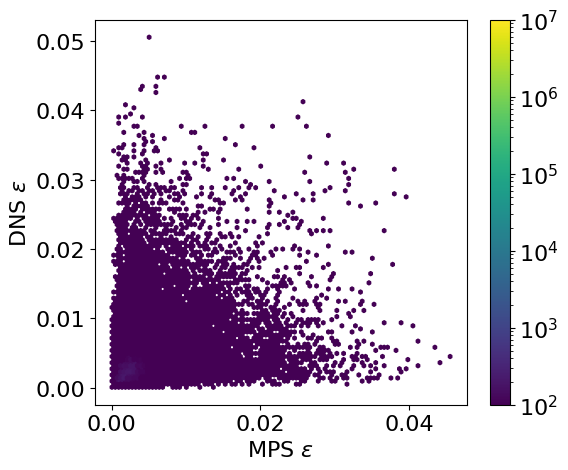

In [15]:
#5_pdf_u_disp

import sys
mps_codes_path = "/ix/pgivi/moe32/Schmidt/mps_py_codes"
sys.path.append(mps_codes_path)

###########################################################################################################################

#PDF velocity and dissipation rate

import numpy as np
import h5py
from process_file_1024 import load_velocity_binary, load_JHS_velocity_1024_jul, load_JHS_velocity_1024
from plotting import plot_pdf, plot_pdf_eps, plot_scatter
from process_file_1024 import load_JHS_velocity_1024_jul
import json



cutoff = 1e-4
comp_path_u = f'truncated_U_1024_il_cf0.0001.mat'
comp_path_v = f'truncated_V_1024_il_cf0.0001.mat'
comp_path_w = f'truncated_W_1024_il_cf0.0001.mat'

###########################################################################################################################
## Binary data - Daniel

# comp_path_u = f'truncated_U_1024_il_cf0.0001.mat'
# comp_path_v = f'truncated_V_1024_il_cf0.0001.mat'
# comp_path_w = f'truncated_W_1024_il_cf0.0001.mat'

N = 32
config_path = "config_FI.json"
with open(config_path, "r") as f:
    config = json.load(f)
org_path = config.get("32_binary_dns", {})


# # N = 1024
# # config_path = mps_codes_path + "/config_FI.json"
# # with open(config_path, "r") as f:
# #     config = json.load(f)
# # org_path = config.get("full_binary_dns", {})


u = load_velocity_binary(org_path['vel']['U'], N, skip_bytes=192)
v = load_velocity_binary(org_path['vel']['V'], N)
w = load_velocity_binary(org_path['vel']['W'], N)
# # u = u-np.mean(u)
# # v = v-np.mean(v)
# # w = w-np.mean(w)

###########################################################################################################################
## JHS data

# N = 128
# comp_path_u = f'jhs_truncated_u_1024_il_cf0.0001.mat'
# comp_path_v = f'jhs_truncated_v_1024_il_cf0.0001.mat'
# comp_path_w = f'jhs_truncated_w_1024_il_cf0.0001.mat'
# config_path = "config_FI.json"
# with open(config_path, "r") as f:
#     config = json.load(f)
# org_path = config.get("128_dns", {})

# N = 1024
# config_path = mps_codes_path + "/config_FI.json"
# with open(config_path, "r") as f:
#     config = json.load(f)
# org_path = config.get("full_dns", {})

# u = load_JHS_velocity_1024(org_path['vel']['U'])
# v = load_JHS_velocity_1024(org_path['vel']['V'])
# w = load_JHS_velocity_1024(org_path['vel']['W'])
# u = u-np.mean(u)
# v = v-np.mean(v)
# w = w-np.mean(w)

###########################################################################################################################


with h5py.File(org_path['disp'], 'r') as file:
    eps = np.array(file['eps'])

u_comp, _ = load_JHS_velocity_1024_jul(comp_path_u)
v_comp, _ = load_JHS_velocity_1024_jul(comp_path_v)
w_comp, _ = load_JHS_velocity_1024_jul(comp_path_w)
with h5py.File('dissipation_comp.h5', 'r') as file:
    eps_comp = np.array(file['eps_comp'])


#Daniel's data 
# pdf_min = 1e-9
# pdf_max = 1
# x_max = 6.1
# x_min = -x_max
# norm_dist = True

#JHS data 
# pdf_min = 1e-8
# pdf_max = 1
# x_max = 4
# x_min = -x_max
# norm_dist = True
# log_norm_dist = True
# x_max_disp = 22
# x_min_disp = -1
# pdf_max_disp = 10
# pdf_min_disp = 1e-8
# ticks_min = 0     #for dissipation 
# ticks_max = 20  #for dissipation

# log_scale = False
# x_max_disp = 40
# x_min_disp = 1e-8
# pdf_max_disp = 1
# pdf_min_disp = 1e-6

# x_max_disp = 0.02
# pdf_max_disp = 200
# pdf_min_disp = 1


pdf_min = None
pdf_max = None
x_max = None
x_min = None
x_min_disp = None
x_max_disp = None
pdf_min_disp = None
pdf_max_disp = None
norm_dist = False
log_norm_dist = False

# plot_pdf({'DNS':u, f'Comp cutoff {cutoff}':u_comp}, title=r'$u$',
#         file_name='Velocity_u_1024Cubed_SameLimits', pdf_min=pdf_min, pdf_max=pdf_max,
#         x_min=x_min, x_max=x_max, norm_dist=norm_dist)

# plot_pdf({'DNS':v, f'Comp cutoff {cutoff}':v_comp}, title=r'$v$',
#         file_name='Velocity_v_1024Cubed_SameLimits', pdf_min=pdf_min, pdf_max=pdf_max,
#         x_min=x_min, x_max=x_max, norm_dist=norm_dist)

# plot_pdf({'DNS':w, f'Comp cutoff {cutoff}':w_comp}, title=r'$w$',
#         file_name='Velocity_w_1024Cubed_SameLimits', pdf_min=pdf_min, pdf_max=pdf_max,
#         x_min=x_min, x_max=x_max, norm_dist=norm_dist)

# plot_pdf_eps({'DNS': eps, f'Comp cutoff {cutoff}': eps_comp}, log_norm_dist=log_norm_dist)

# plot_pdf_eps({'DNS': eps, f'Comp cutoff {cutoff}': eps_comp}, log_norm_dist=log_norm_dist, 
#              x_min=x_min_disp, x_max=x_max_disp, pdf_min=pdf_min_disp, pdf_max=pdf_max_disp)

# plot_scatter(eps.T, eps_comp, cutoff, title='Dissipation', label=r'$\varepsilon$', file_name='Dissipation_scatter_1')

import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['text.usetex'] = False
plt.figure(figsize=(6,5))
hb = plt.hexbin(eps.T.flatten(),eps_comp.flatten(),gridsize=100,
                bins='log',cmap='viridis', vmin=1e2, vmax=1e7)
cb = plt.colorbar(hb)
plt.ylabel(r'DNS $\varepsilon$')
plt.xlabel(r'MPS $\varepsilon$')
plt.savefig(f'Hexbin_dissipation_cf_{cutoff}.png', dpi=300, bbox_inches='tight')


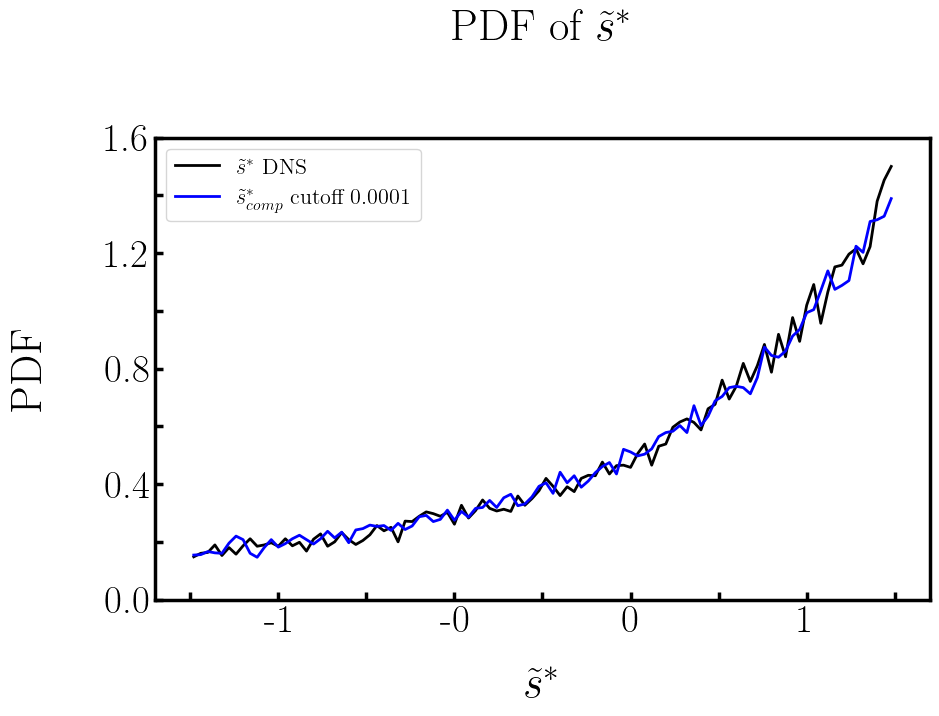

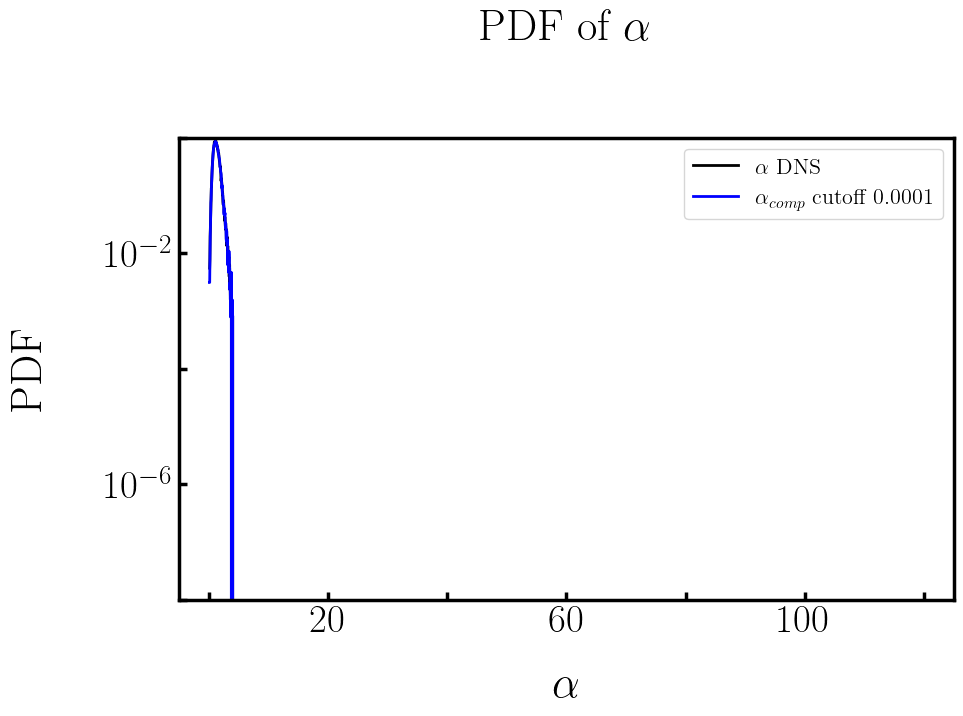

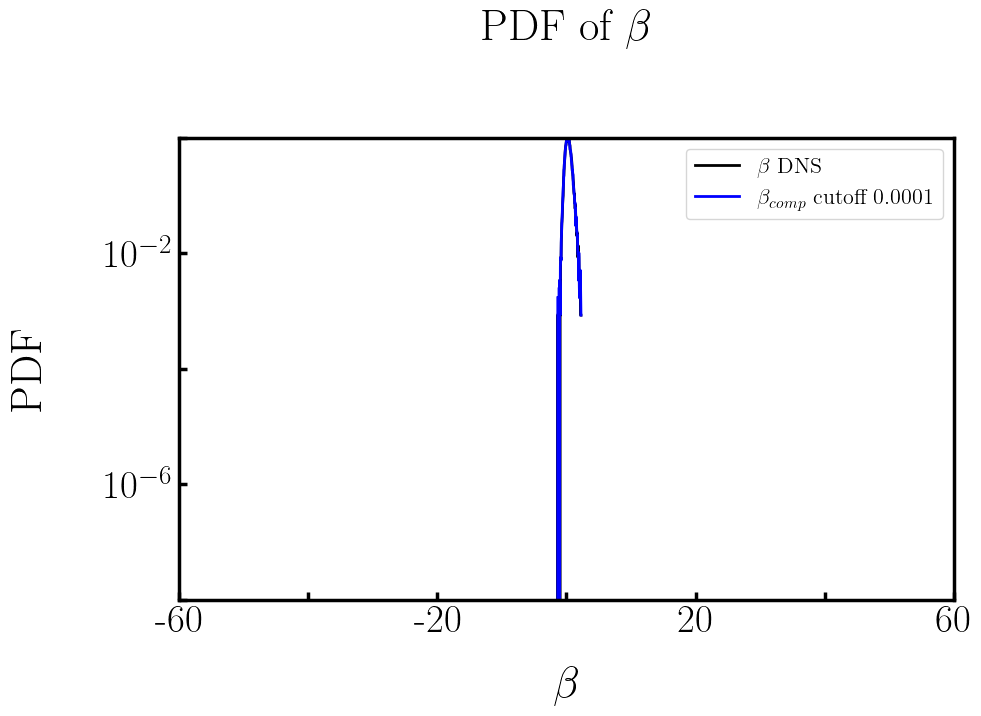

/Users/massen/Desktop/Johns Hopkins Turbulence Database/Schmidt/Nik_code/code/AnalysingResultsFromDNS_demo/ComputationalSpaces/Massen_Lib/plotting.py:481: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(yticklabels)
/Users/massen/Desktop/Johns Hopkins Turbulence Database/Schmidt/Nik_code/code/AnalysingResultsFromDNS_demo/ComputationalSpaces/Massen_Lib/plotting.py:490: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xticklabels)
/Users/massen/Desktop/Johns Hopkins Turbulence Database/Schmidt/Nik_code/code/AnalysingResultsFromDNS_demo/ComputationalSpaces/Massen_Lib/plotting.py:498: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xticklabels, fontproperties=bold_font)
/Users/massen/Desktop/Johns Hopkins Turbulence Database/Schmidt/Nik_code/code/AnalysingResultsFromDNS_demo/ComputationalSpaces/Massen_Lib/plotting.py:499: UserWarning: FixedFormatter

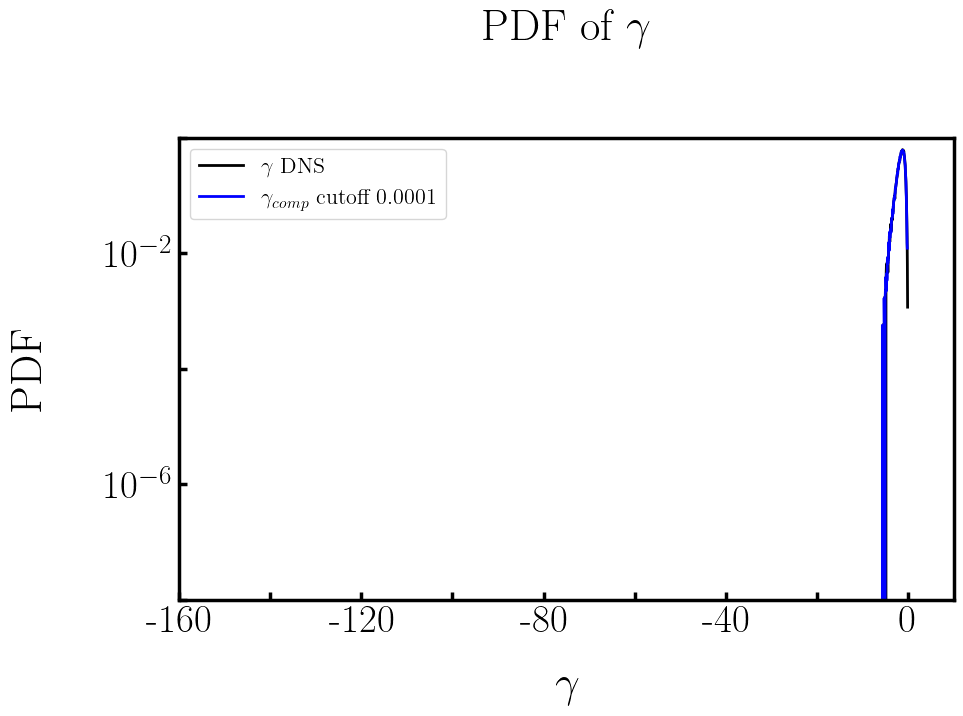

In [11]:
#6_stilde

import sys
mps_codes_path = "/ix/pgivi/moe32/Schmidt/mps_py_codes"
sys.path.append(mps_codes_path)

###########################################################################################################################

#PDF of stilde 
import numpy as np
from save_as_mat import load_h5
from plotting import plot_pdf
from calculate_eps_stilde import calculate_s_tilde
from save_as_mat import save_as_h5
import json

cutoff = 1e-4


###########################################################################################################################
## Binary data - Daniel

N = 32
config_path = "config_FI.json"
with open(config_path, "r") as f:
    config = json.load(f)
org_path = config.get("32_binary_dns", {})


# # N = 1024
# # config_path = mps_codes_path + "/config_FI.json"
# # with open(config_path, "r") as f:
# #     config = json.load(f)
# # org_path = config.get("full_binary_dns", {})


###########################################################################################################################
## JHS data

# N = 128
# config_path = "config_FI.json"
# with open(config_path, "r") as f:
#     config = json.load(f)
# org_path = config.get("128_dns", {})

# N = 1024
# config_path = mps_codes_path + "/config_FI.json"
# with open(config_path, "r") as f:
#     config = json.load(f)
# org_path = config.get("full_dns", {})


###########################################################################################################################

## when calc for DNS is done
alpha = load_h5(org_path['strain_rate']['alpha'])
beta  = load_h5(org_path['strain_rate']['beta'])
gamma = load_h5(org_path['strain_rate']['gamma'])
s_tilde = load_h5(org_path['strain_rate']['s_tilde'])

## when calc for comp is done
alpha_comp = load_h5('Strain_rate_eigen_values_alpha_comp.h5')
beta_comp = load_h5('Strain_rate_eigen_values_beta_comp.h5')
gamma_comp = load_h5('Strain_rate_eigen_values_gamma_comp.h5')
s_tilde_comp = load_h5('Strain_rate_eigen_values_stilde_comp.h5')


# grad_dux_dx = load_h5(org_path['grad_vel']['dux_dx'])
# grad_dux_dy = load_h5(org_path['grad_vel']['dux_dy'])
# grad_dux_dz = load_h5(org_path['grad_vel']['dux_dz'])
# grad_duy_dx = load_h5(org_path['grad_vel']['duy_dx'])
# grad_duy_dy = load_h5(org_path['grad_vel']['duy_dy'])
# grad_duy_dz = load_h5(org_path['grad_vel']['duy_dz'])
# grad_duz_dx = load_h5(org_path['grad_vel']['duz_dx'])
# grad_duz_dy = load_h5(org_path['grad_vel']['duz_dy'])
# grad_duz_dz = load_h5(org_path['grad_vel']['duz_dz'])


# # Symmetric velocity gradients
# S11 = grad_dux_dx + grad_dux_dx
# S12 = grad_dux_dy + grad_duy_dx 
# S13 = grad_dux_dz + grad_duz_dx
# S22 = grad_duy_dy + grad_duy_dy
# S23 = grad_duy_dz + grad_duz_dy
# S33 = grad_duz_dz + grad_duz_dz

# Sij = np.array([[S11, S12, S13], 
#                 [S12, S22, S23],
#                 [S13, S23, S33]])/2
# Sij = np.transpose(Sij, axes=(2,3,4,0,1))

# print("Sij shape: ", Sij.shape)
# s_tilde, alpha, beta, gamma = calculate_s_tilde(Sij)



# grad_dux_dx_comp = load_h5("grad_dux_dx_comp.h5")
# grad_dux_dy_comp = load_h5("grad_dux_dy_comp.h5")
# grad_dux_dz_comp = load_h5("grad_dux_dz_comp.h5")
# grad_duy_dx_comp = load_h5("grad_duy_dx_comp.h5")
# grad_duy_dy_comp = load_h5("grad_duy_dy_comp.h5")
# grad_duy_dz_comp = load_h5("grad_duy_dz_comp.h5")
# grad_duz_dx_comp = load_h5("grad_duz_dx_comp.h5")
# grad_duz_dy_comp = load_h5("grad_duz_dy_comp.h5")
# grad_duz_dz_comp = load_h5("grad_duz_dz_comp.h5")


# # Symmetric velocity gradients
# S11_comp = grad_dux_dx_comp + grad_dux_dx_comp
# S12_comp = grad_dux_dy_comp + grad_duy_dx_comp
# S13_comp = grad_dux_dz_comp + grad_duz_dx_comp
# S22_comp = grad_duy_dy_comp + grad_duy_dy_comp
# S23_comp = grad_duy_dz_comp + grad_duz_dy_comp
# S33_comp = grad_duz_dz_comp + grad_duz_dz_comp

# Sij_comp = np.array([[S11_comp, S12_comp, S13_comp], 
#                      [S12_comp, S22_comp, S23_comp],
#                      [S13_comp, S23_comp, S33_comp]])/2
# Sij_comp = np.transpose(Sij_comp, axes=(2,3,4,0,1))

# print("Sij_comp shape: ", Sij_comp.shape)
# s_tilde_comp, alpha_comp, beta_comp, gamma_comp = calculate_s_tilde(Sij_comp)

##when calc is done, comment these lines
# save_as_h5('Strain_rate_eigen_values_stilde', 'stilde', s_tilde)
# save_as_h5('Strain_rate_eigen_values_alpha', 'alpha', alpha)
# save_as_h5('Strain_rate_eigen_values_beta', 'beta', beta)
# save_as_h5('Strain_rate_eigen_values_gamma', 'gamma', gamma)

# save_as_h5('Strain_rate_eigen_values_stilde_comp', 'stilde', s_tilde_comp)
# save_as_h5('Strain_rate_eigen_values_alpha_comp', 'alpha', alpha_comp)
# save_as_h5('Strain_rate_eigen_values_beta_comp', 'beta', beta_comp)
# save_as_h5('Strain_rate_eigen_values_gamma_comp', 'gamma', gamma_comp)


norm_dist = False
log_Y = False

plot_pdf({rf'$\tilde{{s}}^*$ DNS':s_tilde, rf'$\tilde{{s}}^*_{{comp}}$ cutoff {cutoff}':s_tilde_comp}, 
         title=r'$\tilde{s}^*$', log_Y=log_Y, norm_dist=norm_dist, 
         file_name='Strain_rate_eigen_values_stilde', x_min=-1.1, x_max=1.1, 
         pdf_min=0, pdf_max=1.6)

plot_pdf({rf'$\alpha$ DNS':alpha, rf'$\alpha_{{comp}}$ cutoff {cutoff}':alpha_comp},
         title=r'$\alpha$', norm_dist=norm_dist,
         file_name='Strain_rate_eigen_values_alpha', x_min=-5, x_max=125,
         pdf_min=1e-8, pdf_max=1)

plot_pdf({rf'$\beta$ DNS':beta, rf'$\beta_{{comp}}$ cutoff {cutoff}':beta_comp},
         title=r'$\beta$', norm_dist=norm_dist,
         file_name='Strain_rate_eigen_values_beta', x_min=-60, x_max=60,
         pdf_min=1e-8, pdf_max=1)

plot_pdf({rf'$\gamma$ DNS':gamma, rf'$\gamma_{{comp}}$ cutoff {cutoff}':gamma_comp},
         title=r'$\gamma$', norm_dist=norm_dist,
         file_name='Strain_rate_eigen_values_gamma', x_min=-160, x_max=10, 
         pdf_min=1e-8, pdf_max=1)

/Users/massen/Desktop/Johns Hopkins Turbulence Database/Schmidt/Nik_code/code/AnalysingResultsFromDNS_demo/ComputationalSpaces/Massen_Lib/plotting.py:489: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(yticklabels)
/Users/massen/Desktop/Johns Hopkins Turbulence Database/Schmidt/Nik_code/code/AnalysingResultsFromDNS_demo/ComputationalSpaces/Massen_Lib/plotting.py:498: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xticklabels)
/Users/massen/Desktop/Johns Hopkins Turbulence Database/Schmidt/Nik_code/code/AnalysingResultsFromDNS_demo/ComputationalSpaces/Massen_Lib/plotting.py:506: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xticklabels, fontproperties=bold_font)
/Users/massen/Desktop/Johns Hopkins Turbulence Database/Schmidt/Nik_code/code/AnalysingResultsFromDNS_demo/ComputationalSpaces/Massen_Lib/plotting.py:507: UserWarning: FixedFormatter

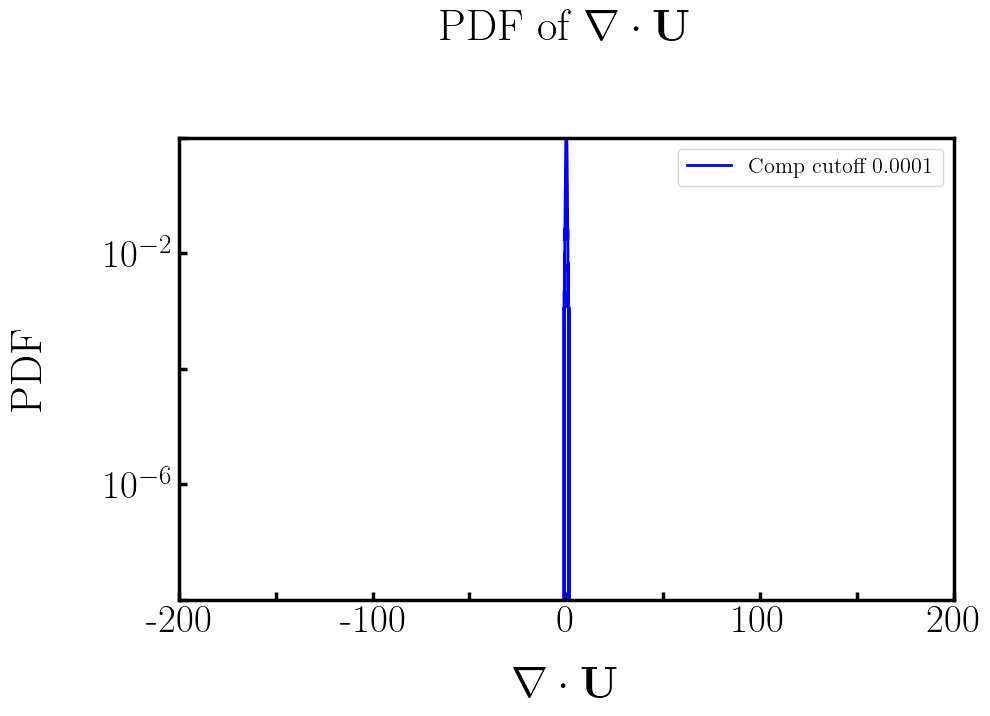

H.min() before = 0.0
H.max() before = 5.094468154907295
H.min() after = 1e-08
H.max() after = 5.094468154907295



/Users/massen/Desktop/Johns Hopkins Turbulence Database/Schmidt/Nik_code/code/AnalysingResultsFromDNS_demo/ComputationalSpaces/Massen_Lib/plotting.py:283: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(yticklabels)
/Users/massen/Desktop/Johns Hopkins Turbulence Database/Schmidt/Nik_code/code/AnalysingResultsFromDNS_demo/ComputationalSpaces/Massen_Lib/plotting.py:292: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xticklabels)
/Users/massen/Desktop/Johns Hopkins Turbulence Database/Schmidt/Nik_code/code/AnalysingResultsFromDNS_demo/ComputationalSpaces/Massen_Lib/plotting.py:300: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xticklabels, fontproperties=bold_font)
/Users/massen/Desktop/Johns Hopkins Turbulence Database/Schmidt/Nik_code/code/AnalysingResultsFromDNS_demo/ComputationalSpaces/Massen_Lib/plotting.py:301: UserWarning: FixedFormatter

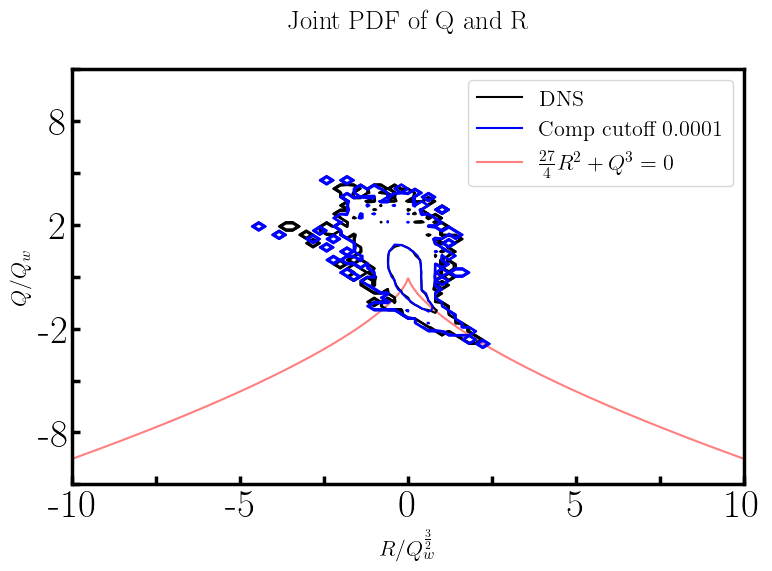

In [1]:
#7_joint_pdf_QR

import sys
mps_codes_path = "/ix/pgivi/moe32/Schmidt/mps_py_codes"
sys.path.append(mps_codes_path)

###########################################################################################################################
#Joint PDF plot

import matplotlib.pyplot as plt
import numpy as np
from plotting import plot_QR_joint_pdf
from calculate_gradients import calculate_invariants, calculate_invariants_exact, compute_Qw
from save_as_mat import save_as_h5, load_h5
from plotting import plot_pdf
import json


cutoff = 1e-4
# Qw_comp =

N = 32
config_path = "config_FI.json"
with open(config_path, "r") as f:
    config = json.load(f)
org_path = config.get("32_binary_dns", {})
Qw =  2.353024608021444

# N = 1024
# config_path = mps_codes_path + "/config_FI.json"
# with open(config_path, "r") as f:
#     config = json.load(f)

#Daniel
# org_path = config.get("full_binary_dns", {})
# Qw = 32.59979212200147

#JHS
# org_path = config.get("full_dns", {})
# Qw = 15.756560377380076

## when calc is done
div_exact_comp = load_h5('first_invariant_div_spectral_exact_comp.h5')
Q_exact_comp = load_h5('second_invariant_Q_spectral_exact_comp.h5')
R_exact_comp = load_h5('third_invariant_R_spectral_exact_comp.h5')
Qw_comp = Qw

## when calc is done
div_exact = load_h5(org_path['invars']['div'])
Q_exact = load_h5(org_path['invars']['Q'])
R_exact = load_h5(org_path['invars']['R'])

# grad_dux_dx = load_h5(org_path['grad_vel']['dux_dx'])
# grad_dux_dy = load_h5(org_path['grad_vel']['dux_dy'])
# grad_dux_dz = load_h5(org_path['grad_vel']['dux_dz'])
# grad_duy_dx = load_h5(org_path['grad_vel']['duy_dx'])
# grad_duy_dy = load_h5(org_path['grad_vel']['duy_dy'])
# grad_duy_dz = load_h5(org_path['grad_vel']['duy_dz'])
# grad_duz_dx = load_h5(org_path['grad_vel']['duz_dx'])
# grad_duz_dy = load_h5(org_path['grad_vel']['duz_dy'])
# grad_duz_dz = load_h5(org_path['grad_vel']['duz_dz'])

# grad = np.array([[grad_dux_dx, grad_dux_dy, grad_dux_dz],
#                  [grad_duy_dx, grad_duy_dy, grad_duy_dz],
#                  [grad_duz_dx, grad_duz_dy, grad_duz_dz]])

# grad = np.transpose(grad, (2, 3, 4, 0, 1))  # Rearrange dimensions

# div_inexact, Q_inexact, R_inexact = calculate_invariants(grad)
# div_exact, Q_exact, R_exact = calculate_invariants_exact(grad)
# Qw = compute_Qw(grad)
# print("Qw = ", Qw)
# print("\nnorm(div_inexact-div_exact) = ", np.linalg.norm(div_inexact-div_exact))
# print("norm(Q_inexact-Q_exact) = ", np.linalg.norm(Q_inexact-Q_exact))
# print("norm(R_inexact-R_exact) = ", np.linalg.norm(R_inexact-R_exact))

# save_as_h5('first_invariant_div_spectral_inexact','div', div_inexact)
# save_as_h5('second_invariant_Q_spectral_inexact','Q', Q_inexact)
# save_as_h5('third_invariant_R_spectral_inexact','R', R_inexact)

# save_as_h5('first_invariant_div_spectral_exact','div', div_exact)
# save_as_h5('second_invariant_Q_spectral_exact','Q', Q_exact)
# save_as_h5('third_invariant_R_spectral_exact','R', R_exact)

# # double comment
# grad_dux_dx_comp = load_h5("grad_dux_dx_comp.h5")
# grad_dux_dy_comp = load_h5("grad_dux_dy_comp.h5")
# grad_dux_dz_comp = load_h5("grad_dux_dz_comp.h5")
# grad_duy_dx_comp = load_h5("grad_duy_dx_comp.h5")
# grad_duy_dy_comp = load_h5("grad_duy_dy_comp.h5")
# grad_duy_dz_comp = load_h5("grad_duy_dz_comp.h5")
# grad_duz_dx_comp = load_h5("grad_duz_dx_comp.h5")
# grad_duz_dy_comp = load_h5("grad_duz_dy_comp.h5")
# grad_duz_dz_comp = load_h5("grad_duz_dz_comp.h5")

# grad_comp = np.array([[grad_dux_dx_comp, grad_dux_dy_comp, grad_dux_dz_comp],
#                       [grad_duy_dx_comp, grad_duy_dy_comp, grad_duy_dz_comp],
#                       [grad_duz_dx_comp, grad_duz_dy_comp, grad_duz_dz_comp]])

# grad_comp = np.transpose(grad_comp, (2, 3, 4, 0, 1))  

# div_inexact_comp, Q_inexact_comp, R_inexact_comp = calculate_invariants(grad_comp)
# div_exact_comp, Q_exact_comp, R_exact_comp = calculate_invariants_exact(grad_comp)
# Qw_comp = compute_Qw(grad_comp)


# print("\nnorm(div_inexact_comp-div_exact_comp) = ", np.linalg.norm(div_inexact_comp-div_exact_comp))
# print("norm(Q_inexact_comp-Q_exact_comp) = ", np.linalg.norm(Q_inexact_comp-Q_exact_comp))
# print("norm(R_inexact_comp-R_exact_comp) = ", np.linalg.norm(R_inexact_comp-R_exact_comp))

# save_as_h5('first_invariant_div_spectral_inexact_comp','div_comp', div_inexact_comp)
# save_as_h5('second_invariant_Q_spectral_inexact_comp','Q_comp', Q_inexact_comp)
# save_as_h5('third_invariant_R_spectral_inexact_comp','R_comp', R_inexact_comp)

# save_as_h5('first_invariant_div_spectral_exact_comp','div_comp', div_exact_comp)
# save_as_h5('second_invariant_Q_spectral_exact_comp','Q_comp', Q_exact_comp)
# save_as_h5('third_invariant_R_spectral_exact_comp','R_comp', R_exact_comp)

# print("Qw: ", Qw, "\tQw_comp: ", Qw_comp)

x_max = 200
x_min = -x_max
pdf_max = 1
pdf_min = 1e-8

# x_max = None
# x_min = None
# pdf_max = None
# pdf_min = None


# # plot_pdf({'DNS':div_exact}, title='Divergence (First Invariant)',
# #          file_name='div_DNS_1024Cubed_spectral', x_min=x_min, 
# #          x_max=x_max, pdf_min=pdf_min, pdf_max=pdf_max)

plot_pdf({f'Comp cutoff {cutoff}':div_exact_comp}, 
         title=r'$\nabla \cdot \mathbf{U}$',file_name='div_1024Cubed_spectral',
         x_min=x_min, x_max=x_max, pdf_min=pdf_min, pdf_max=pdf_max, my_color='blue')

# plot_pdf({f'Comp cutoff {cutoff}':div_exact_comp}, my_color='blue', 
#          title='Divergence',file_name='div_1024Cubed_spectral_SameLimits',
#          x_min=x_min, x_max=x_max, ticks_min=-100, ticks_max=100,
#          pdf_min=pdf_min, pdf_max=pdf_max)

# # plot_QR_joint_pdf(Q_exact, R_exact, Qw,
# #                   label_1 = 'DNS (No Assumption)',
# #                   file_name=f'PDF_QR_Joint_DNS_exact')

# # plot_QR_joint_pdf(Q_inexact, R_inexact, Qw, 
# #                   label_1 = rf'DNS (Assume $\nabla \cdot U = 0$)',
# #                   file_name=f'PDF_QR_Joint_DNS_inexact')

# plot_QR_joint_pdf(Q_exact_comp, R_exact_comp, Qw_comp,
#                   label_1 = rf'Comp cutoff {cutoff} (No Assumption)',
#                   file_name=f'PDF_QR_Joint_cutoff_{cutoff}_exact')

# plot_QR_joint_pdf(Q_inexact_comp, R_inexact_comp, Qw_comp, 
#                   label_1 = rf'Comp cutoff {cutoff} (Assume $\nabla \cdot U = 0$)',
#                   file_name=f'PDF_QR_Joint_cutoff_{cutoff}_inexact')


# # plot_QR_joint_pdf(Q_exact, R_exact, Qw, Q_inexact, R_inexact, Qw,
# #                   label_1=r'DNS (No Assumption)', colormesh=False,
# #                   label_2=r'DNS (Assume $\nabla \cdot {U} = 0$)',
# #                   file_name=f'PDF_QR_Joint_DNS_contourlines')

# plot_QR_joint_pdf(Q_exact_comp, R_exact_comp, Qw_comp, Q_inexact_comp, R_inexact_comp, Qw_comp,
#                   label_1=rf'Comp cutoff {cutoff} (No Assumption)', colormesh=False,
#                   label_2=rf'Comp cutoff {cutoff} (Assume $\nabla \cdot U = 0$)',
#                   file_name=f'PDF_QR_Joint_cutoff_{cutoff}_contourlines')

plot_QR_joint_pdf(Q_exact, R_exact, Qw, Q_exact_comp, R_exact_comp, Qw_comp,
                  label_1=r'DNS', colormesh=False,
                  label_2=rf'Comp cutoff {cutoff}',
                  file_name=f'PDF_QR_Joint_cutoff_{cutoff}_exact_contourlines')

# # plot_QR_joint_pdf(Q_inexact, R_inexact, Qw, Q_inexact_comp, R_inexact_comp, Qw_comp,
# #                   label_1=r'DNS (Assume $\nabla \cdot U = 0$)', colormesh=False,
# #                   label_2=rf'Comp cutoff {cutoff} (Assume $\nabla \cdot U = 0$)',
# #                   file_name=f'PDF_QR_Joint_cutoff_{cutoff}_inexact_contourlines')
                  

In [97]:
#8_structure_functions

import sys
mps_codes_path = "/ix/pgivi/moe32/Schmidt/mps_py_codes"
sys.path.append(mps_codes_path)

###########################################################################################################################


import numpy as np
from process_file_1024 import load_velocity_binary, load_JHS_velocity_1024_jul, load_JHS_velocity_1024
from process_file_1024 import load_JHS_velocity_1024_jul
from structure_functions import safe_struct
from save_as_mat import save_as_mat
import json


# cutoff = 1e-4
# comp_path_u = f'truncated_U_1024_il_cf0.0001.mat'
# comp_path_v = f'truncated_V_1024_il_cf0.0001.mat'
# comp_path_w = f'truncated_W_1024_il_cf0.0001.mat'
direction = "z"

###########################################################################################################################
## Binary data - Daniel

# comp_path_u = f'truncated_U_1024_il_cf0.0001.mat'
# comp_path_v = f'truncated_V_1024_il_cf0.0001.mat'
# comp_path_w = f'truncated_W_1024_il_cf0.0001.mat'

N = 32
config_path = "config_FI.json"
with open(config_path, "r") as f:
    config = json.load(f)
org_path = config.get("32_binary_dns", {})


# # N = 1024
# # config_path = mps_codes_path + "/config_FI.json"
# # with open(config_path, "r") as f:
# #     config = json.load(f)
# # org_path = config.get("full_binary_dns", {})


u = load_velocity_binary(org_path['vel']['U'], N, skip_bytes=192)
v = load_velocity_binary(org_path['vel']['V'], N)
w = load_velocity_binary(org_path['vel']['W'], N)
# u = u-np.mean(u)
# v = v-np.mean(v)
# w = w-np.mean(w)

###########################################################################################################################
## JHS data

# N = 128
# comp_path_u = f'jhs_truncated_u_1024_il_cf0.0001.mat'
# comp_path_v = f'jhs_truncated_v_1024_il_cf0.0001.mat'
# comp_path_w = f'jhs_truncated_w_1024_il_cf0.0001.mat'
# config_path = "config_FI.json"
# with open(config_path, "r") as f:
#     config = json.load(f)
# org_path = config.get("128_dns", {})

# N = 1024
# config_path = mps_codes_path + "/config_FI.json"
# with open(config_path, "r") as f:
#     config = json.load(f)
# org_path = config.get("full_dns", {})

# u = load_JHS_velocity_1024(org_path['vel']['U'])
# v = load_JHS_velocity_1024(org_path['vel']['V'])
# w = load_JHS_velocity_1024(org_path['vel']['W'])
# u = u-np.mean(u)
# v = v-np.mean(v)
# w = w-np.mean(w)

###########################################################################################################################

# u_comp, _ = load_JHS_velocity_1024_jul(comp_path_u)
# v_comp, _ = load_JHS_velocity_1024_jul(comp_path_v)
# w_comp, _ = load_JHS_velocity_1024_jul(comp_path_w)


# D = safe_struct((u_comp, v_comp, w_comp), direction, chkpt_freq=64, dtype=np.float64)
# save_as_mat(f'sf_cf_{cutoff}_dir_{direction}_comp', D)

D = safe_struct((u, v, w), direction, chkpt_freq=64, dtype=np.float64)
# save_as_mat(f'sf_DNS_{N}_dir_{direction}', D)
save_as_mat(f'sf_DNS_{N}_dir_{direction}_SLTT', D)




• Starting fresh run
  → lags [0:32) …saved
Saved result to sf_DNS_32_dir_z_SLTT.mat


In [ ]:
eta_k = (2*np.pi)/data[-1,0]
epsilon_k = (nu**3)/(eta_k**4)
eta_k1 = (nu**3 / epsilon) ** 0.25
# epsilon_k
eta_k1

0.010859416776729707

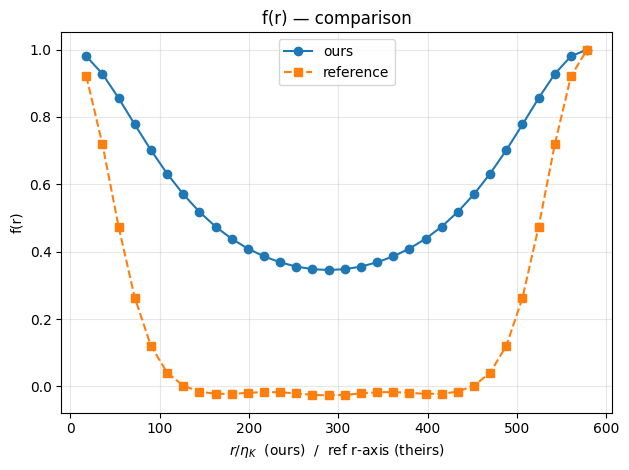

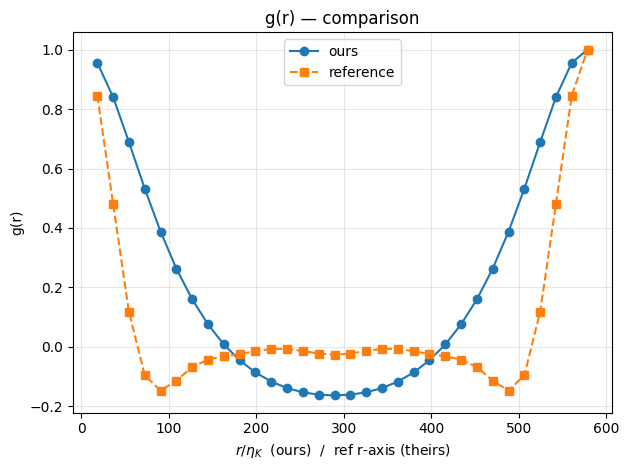

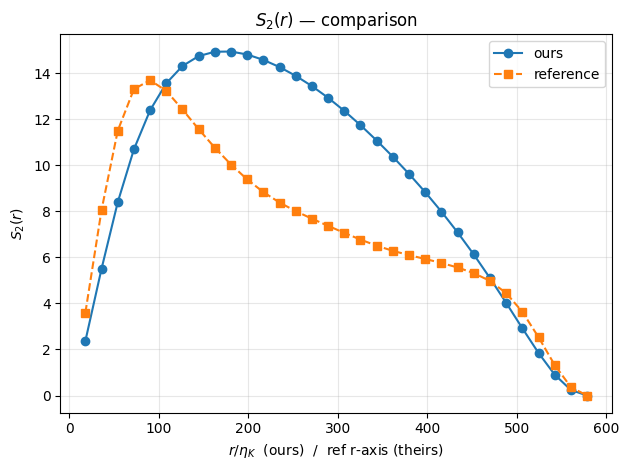

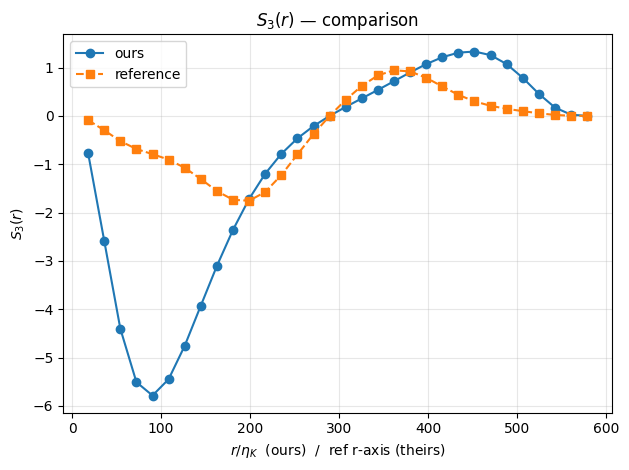

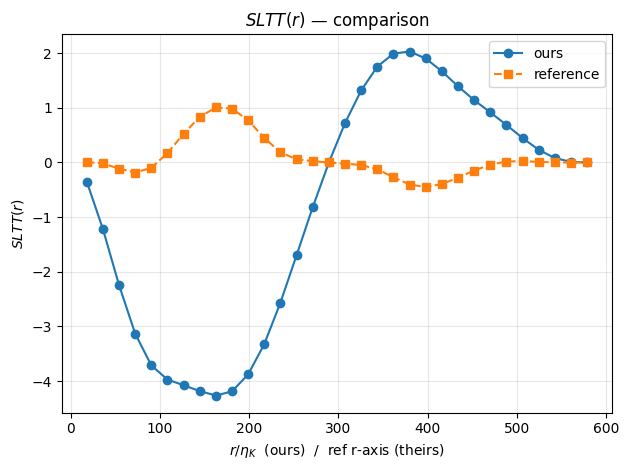

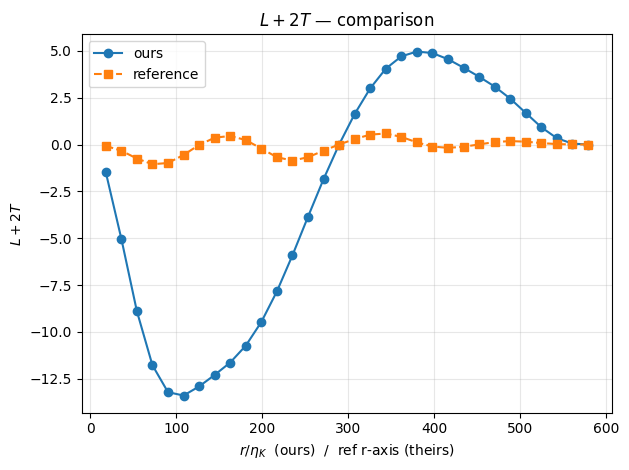

In [156]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- load their file ----------
def load_reference(file_path):
    ref = np.loadtxt(file_path, comments="#")
    if ref.ndim == 1:
        ref = ref[None, :]
    cols = ref.shape[1]
    if cols < 3:
        raise ValueError("Reference needs at least 3 columns: r, f, g.")
    out = {
        "r":   ref[:, 0],
        "f":   ref[:, 1],
        "g":   ref[:, 2],
    }
    if cols >= 4: out["S2"]   = ref[:, 3]
    if cols >= 5: out["S3"]   = ref[:, 4]
    if cols >= 6: out["SLTT"] = ref[:, 5]
    if cols >= 7: out["L2T"]  = ref[:, 6]  # (L+2T), if present
    return out

# ---------- pick our r-axis ----------
def get_model_x(out, r_units="physical"):
    if r_units == "physical":
        if "r_physical" not in out:
            raise ValueError("out lacks 'r_physical'")
        return out["r_physical"], r"$r$"
    elif r_units == "eta":
        if "r_over_etaK" not in out:
            raise ValueError("r_units='eta' but out lacks 'r_over_etaK' (pass nu to two_point_stats_all).")
        return out["r_over_etaK"], r"$r/\eta_K$"
    else:
        raise ValueError("r_units must be 'physical' or 'eta'.")

# ---------- optional scale (no interpolation) ----------
def best_scale(x_src, x_tgt):
    """
    Find alpha minimizing || alpha*x_src - x_tgt || in least squares (zero intercept).
    Returns alpha>0. Use to roughly align x-axes for visual comparison.
    """
    num = np.dot(x_src, x_tgt)
    den = np.dot(x_src, x_src)
    return float(num/den) if den > 0 else 1.0

def plot_compare_no_interp(
    file_path,
    model_out,              # dict from two_point_stats_all(...)
    r_units="physical",     # "physical" or "eta" for our x-axis
    x_mode="both_native",   # "both_native" | "ref_x" | "model_x" | "scaled_model_to_ref"
    suptitle=None
):
    ref = load_reference(file_path)

    x_model, xlab = get_model_x(model_out, r_units=r_units)
    # our series
    series = {
        "f":    model_out["f"],
        "g":    model_out["g"],
        "S2":   model_out.get("S2", None),
        "S3":   model_out.get("S3", None),
        "SLTT": model_out.get("SLTT", None),
    }
    # also derive (L+2T) on our side
    series["L2T"] = None
    if ("S3" in model_out) and ("SLTT" in model_out):
        series["L2T"] = model_out["S3"] + 2.0*model_out["SLTT"]

    # figure out x to use for plotting
    if x_mode == "both_native":
        # plot theirs vs ref['r'], ours vs x_model (two sets of x)
        x_model_plot = x_model
        x_ref_plot = ref["r"]
        xlab_final = xlab + "  (ours)  /  ref r-axis (theirs)"
    elif x_mode == "ref_x":
        # plot both against the reference r (we just use our own y-values against ref x for visualization)
        # NOTE: still no interpolation; points won’t coincide in x—this is purely visual.
        x_model_plot = ref["r"]  # reuse ref x for our markers (no math interpolation)
        x_ref_plot = ref["r"]
        xlab_final = "reference r-axis"
    elif x_mode == "model_x":
        # plot both against our model x (ref values vs our x for visualization)
        x_model_plot = x_model
        x_ref_plot = x_model
        xlab_final = xlab
    elif x_mode == "scaled_model_to_ref":
        # scale our x by single factor to roughly align with reference x (no interpolation)
        # choose scaling to best match in least squares sense
        # (Use overlapping length for a fair scale; here we just compute a global factor.)
        # Only use finite values for safety
        xm = np.asarray(x_model)
        xr = np.asarray(ref["r"])
        # truncate to common length for scale fit if desired; here use min length
        n = min(len(xm), len(xr))
        alpha = best_scale(xm[:n], xr[:n])
        x_model_plot = alpha * x_model
        x_ref_plot = ref["r"]
        xlab_final = f"reference r-axis (ours scaled by α={alpha:.6g})"
        print(f"[info] scaling our x by α={alpha:.6g} to align with reference axis.")
    else:
        raise ValueError("x_mode must be one of: 'both_native', 'ref_x', 'model_x', 'scaled_model_to_ref'.")

    # what to plot (only if present in both)
    labels = [
        ("f", "f(r)"),
        ("g", "g(r)"),
        ("S2", r"$S_2(r)$"),
        ("S3", r"$S_3(r)$"),
        ("SLTT", r"$SLTT(r)$"),
        ("L2T", r"$L+2T$"),
    ]

    for key, ylabel in labels:
        y_ref = ref.get(key, None)
        y_model = series.get(key, None)
        if y_ref is None or y_model is None:
            # skip if missing on either side
            continue

        # mask NaNs (e.g., our S2/S3/SLTT at r=0)
        m_model = np.isfinite(y_model)
        m_ref   = np.isfinite(y_ref)

        plt.figure()
        # ours
        plt.plot(x_model_plot[m_model], y_model[m_model], marker="o", linestyle="-", label="ours")
        # theirs
        plt.plot(x_ref_plot[m_ref], y_ref[m_ref], marker="s", linestyle="--", label="reference")
        plt.xlabel(xlab_final)
        plt.ylabel(ylabel)
        ttl = f"{ylabel} — comparison"
        if suptitle:
            ttl = suptitle + " — " + ttl
        plt.title(ttl)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()


file_path = "/Users/massen/Library/CloudStorage/OneDrive-UniversityofPittsburgh/Shared with Everyone/Test_Case_Data/it32/stats-32/spectra/twoptmeasures.00010.dat"

# 1) Compute your outputs
out = two_point_stats_all(u, v, w, dx=dx, epsilon=epsilon, periodic=True, nu=nu)

# 2) Plot both on the same figure, no interpolation:
#    Option A: show both on their native x-axes (two different x scales in same plot)
plot_compare_no_interp(file_path, out, r_units="eta", x_mode="both_native")

#    Option B (recommended for visual alignment): rescale our x by one factor α to line up with theirs
# plot_compare_no_interp(file_path, out, r_units="eta", x_mode="scaled_model_to_ref")

#    If you know their first column is *physical r*, use r_units="physical"
# plot_compare_no_interp(file_path, out, r_units="physical", x_mode="scaled_model_to_ref")



In [150]:
print(np.max(np.abs(S_LTT_f[0][:]-S_LTT[0][:])))

0.05061023492981814


In [31]:
#compare structure functions loop and vectorized
import numpy as np
import time

def structure_functions_loop(vel_fields, direction):
    """Compute vlcorr, vstruct2, vstruct3 using explicit for-loops."""
    ux, uy, uz = vel_fields
    NXT, NYT, NZT = ux.shape
    max_lag = ux.shape[{"x": 0, "y": 1, "z": 2}[direction]]

    vlcorr = np.zeros(max_lag)
    vstruct2 = np.zeros(max_lag)
    vstruct3 = np.zeros(max_lag)

    for l in range(max_lag):
        for i in range(NXT):
            for j in range(NYT):
                for k in range(NZT):
                    if direction == "x":
                        q = (i + l) % NXT
                        u1, u2, u3 = ux[i,j,k], uy[i,j,k], uz[i,j,k]
                        uq1, uq2, uq3 = ux[q,j,k], uy[q,j,k], uz[q,j,k]
                    elif direction == "y":
                        q = (j + l) % NYT
                        u1, u2, u3 = ux[i,j,k], uy[i,j,k], uz[i,j,k]
                        uq1, uq2, uq3 = ux[i,q,k], uy[i,q,k], uz[i,q,k]
                    elif direction == "z":
                        q = (k + l) % NZT
                        u1, u2, u3 = ux[i,j,k], uy[i,j,k], uz[i,j,k]
                        uq1, uq2, uq3 = ux[i,j,q], uy[i,j,q], uz[i,j,q]
                    else:
                        raise ValueError("Invalid direction")

                    # Longitudinal (first component)
                    # du = u1 - uq1
                    # vlcorr[l] += u1 * uq1
                    # vstruct2[l] += du**2
                    # vstruct3[l] += du**3

                    # Transverse components
                    for u, uq in [(u1, uq1), (u2, uq2), (u3, uq3)]:
                        du = u - uq
                        vlcorr[l] += u * uq
                        vstruct2[l] += du**2
                        vstruct3[l] += du**3

    norm = NXT * NYT * NZT
    vlcorr /= norm
    vstruct2 /= norm
    vstruct3 /= norm

    u2_mean = (np.mean(ux**2) + np.mean(uy**2) + np.mean(uz**2)) / 3
    vlcorr /= u2_mean

    return vlcorr, vstruct2, vstruct3


def structure_functions_vectorized(vel_fields, direction):
    """Compute vlcorr, vstruct2, vstruct3 using NumPy vectorized operations."""
    ux, uy, uz = vel_fields
    NXT, NYT, NZT = ux.shape
    max_lag = ux.shape[{"x": 0, "y": 1, "z": 2}[direction]]

    vlcorr = np.zeros(max_lag)
    vstruct2 = np.zeros(max_lag)
    vstruct3 = np.zeros(max_lag)

    for l in range(max_lag):
        shift_axis = {"x": 0, "y": 1, "z": 2}[direction]

        shifted_x = np.roll(ux, -l, axis=shift_axis)
        shifted_y = np.roll(uy, -l, axis=shift_axis)
        shifted_z = np.roll(uz, -l, axis=shift_axis)

        # Longitudinal and Transverse
        for u, uq in [(ux, shifted_x), (uy, shifted_y), (uz, shifted_z)]:
            du = u - uq
            vlcorr[l] += np.sum(u * uq)
            vstruct2[l] += np.sum(du**2)
            vstruct3[l] += np.sum(du**3)

    norm = NXT * NYT * NZT
    vlcorr /= norm
    vstruct2 /= norm
    vstruct3 /= norm

    u2_mean = (np.mean(ux**2) + np.mean(uy**2) + np.mean(uz**2)) / 3
    vlcorr /= u2_mean

    return vlcorr, vstruct2, vstruct3


# === Example Usage ===
np.random.seed(0)
N = 16  # Small size for demonstration
ux = np.random.randn(N, N, N)
uy = np.random.randn(N, N, N)
uz = np.random.randn(N, N, N)
vel_fields = (ux, uy, uz)


# Inside your loop:
for direction in ["x", "y", "z"]:
    start_loop = time.perf_counter()
    loop_result = structure_functions_loop(vel_fields, direction)
    end_loop = time.perf_counter()
    loop_time = end_loop - start_loop

    start_vec = time.perf_counter()
    vec_result = structure_functions_vectorized(vel_fields, direction)
    end_vec = time.perf_counter()
    vec_time = end_vec - start_vec

    print(f"\nDirection: {direction.upper()}")
    print(f"  Loop Time:       {loop_time:.6f} sec")
    print(f"  Vectorized Time: {vec_time:.6f} sec")

    for name, loop_arr, vec_arr in zip(
        ["vlcorr", "vstruct2", "vstruct3"], loop_result, vec_result
    ):
        max_diff = np.max(np.abs(loop_arr - vec_arr))
        print(f"  {name:<10} max |difference| = {max_diff:.3e}")




Direction: X
  Loop Time:       0.126439 sec
  Vectorized Time: 0.002685 sec
  vlcorr     max |difference| = 7.994e-15
  vstruct2   max |difference| = 3.642e-14
  vstruct3   max |difference| = 1.804e-15

Direction: Y
  Loop Time:       0.116248 sec
  Vectorized Time: 0.002862 sec
  vlcorr     max |difference| = 7.994e-15
  vstruct2   max |difference| = 3.730e-14
  vstruct3   max |difference| = 1.721e-15

Direction: Z
  Loop Time:       0.117433 sec
  Vectorized Time: 0.002985 sec
  vlcorr     max |difference| = 7.994e-15
  vstruct2   max |difference| = 4.530e-14
  vstruct3   max |difference| = 1.110e-15


In [10]:
#Load Structure Functions

import matplotlib.pyplot as plt
from scipy.io import loadmat
import numpy as np

N = 1024
# N = 32
# sf_path = '/Users/massen/Desktop/JHS result/Daniel data/new data/'
sf_path = 'structure_functions/'
# sf_path = 'structure_functions/32 cubed/'
S_x = loadmat(f'{sf_path}sf_DNS_dir_x.mat')
S_y = loadmat(f'{sf_path}sf_DNS_dir_y.mat')
S_z = loadmat(f'{sf_path}sf_DNS_dir_z.mat')
# S_x = loadmat(f'sf_DNS_1024_dir_x_SLTT.mat')
# S_y = loadmat(f'sf_DNS_1024_dir_y_SLTT.mat')
# S_z = loadmat(f'sf_DNS_1024_dir_z_SLTT.mat')
S_x_comp_e3 = loadmat(f'{sf_path}sf_cf_0.001_dir_x_comp.mat')
S_y_comp_e3 = loadmat(f'{sf_path}sf_cf_0.001_dir_y_comp.mat')
S_z_comp_e3 = loadmat(f'{sf_path}sf_cf_0.001_dir_z_comp.mat')
S_x_comp_e4 = loadmat(f'{sf_path}sf_cf_0.0001_dir_x_comp.mat')
S_y_comp_e4 = loadmat(f'{sf_path}sf_cf_0.0001_dir_y_comp.mat')
S_z_comp_e4 = loadmat(f'{sf_path}sf_cf_0.0001_dir_z_comp.mat')
S_x_comp_e5 = loadmat(f'{sf_path}sf_cf_1e-05_dir_x_comp.mat')
S_y_comp_e5 = loadmat(f'{sf_path}sf_cf_1e-05_dir_y_comp.mat')
S_z_comp_e5 = loadmat(f'{sf_path}sf_cf_1e-05_dir_z_comp.mat')


# C_4_3, C_4_5, C_4_15 = 27, 12, 55
# C_4_3, C_4_5, C_4_15 = 1.4, 1, 2.5
C_4_3, C_4_5, C_4_15 = 1, 1, 1

#32 data - Daniel
# eps = 0.00553672480595447
# eta = 0.012257849044743967

# #128 data
# eps = 3.6589818991297434
# eta = 0.0011469348022442917

# # 1024 data
eps = 0.091859602123993
eta = 0.002881360885343
# eps = 1
# eta = 1

#add eps and eta for different cutoffs for 1024 data
# cutoff = 1e-3
eps_comp_e3 = 0.109463075921358
eta_comp_e3 = 0.002757794393646

# cutoff = 1e-4
eps_comp_e4 = 0.088226140935342
eta_comp_e4 = 0.002910579562332

# cutoff = 1e-5
eps_comp_e5 = 0.089441391651130
eta_comp_e5 = 0.002900642188653


r = S_x["r"]
r_safe = np.where(r > 0, r, np.nan)
r_eta = r.T/eta

corr2pt_L = (S_x["corr2pt_L"]+S_y["corr2pt_L"]+S_z["corr2pt_L"])/3
S_LL = (S_x["LL"]+S_y["LL"]+S_z["LL"])/3
S_LLL = (S_x["LLL"]+S_y["LLL"]+S_z["LLL"])/3
S_TT = (S_x["TT"]+S_y["TT"]+S_z["TT"])/3
S_TTT = (S_x["TTT"]+S_y["TTT"]+S_z["TTT"])/3
S_LTT = (S_x["LTT"]+S_y["LTT"]+S_z["LTT"])/6

corr2pt_L_comp_e3 = (S_x_comp_e3["corr2pt_L"]+S_y_comp_e3["corr2pt_L"]+S_z_comp_e3["corr2pt_L"])/3
S_LL_comp_e3 = (S_x_comp_e3["LL"]+S_y_comp_e3["LL"]+S_z_comp_e3["LL"])/3
S_LLL_comp_e3 = (S_x_comp_e3["LLL"]+S_y_comp_e3["LLL"]+S_z_comp_e3["LLL"])/3
S_TT_comp_e3 = (S_x_comp_e3["TT"]+S_y_comp_e3["TT"]+S_z_comp_e3["TT"])/3
S_TTT_comp_e3 = (S_x_comp_e3["TTT"]+S_y_comp_e3["TTT"]+S_z_comp_e3["TTT"])/3
S_LTT_comp_e3 = (S_x_comp_e3["LTT"]+S_y_comp_e3["LTT"]+S_z_comp_e3["LTT"])/3/2

corr2pt_L_comp_e4 = (S_x_comp_e4["corr2pt_L"]+S_y_comp_e4["corr2pt_L"]+S_z_comp_e4["corr2pt_L"])/3
S_LL_comp_e4 = (S_x_comp_e4["LL"]+S_y_comp_e4["LL"]+S_z_comp_e4["LL"])/3
S_LLL_comp_e4 = (S_x_comp_e4["LLL"]+S_y_comp_e4["LLL"]+S_z_comp_e4["LLL"])/3
S_TT_comp_e4 = (S_x_comp_e4["TT"]+S_y_comp_e4["TT"]+S_z_comp_e4["TT"])/3
S_TTT_comp_e4 = (S_x_comp_e4["TTT"]+S_y_comp_e4["TTT"]+S_z_comp_e4["TTT"])/3
S_LTT_comp_e4 = (S_x_comp_e4["LTT"]+S_y_comp_e4["LTT"]+S_z_comp_e4["LTT"])/3/2

corr2pt_L_comp_e5 = (S_x_comp_e5["corr2pt_L"]+S_y_comp_e5["corr2pt_L"]+S_z_comp_e5["corr2pt_L"])/3
S_LL_comp_e5 = (S_x_comp_e5["LL"]+S_y_comp_e5["LL"]+S_z_comp_e5["LL"])/3
S_LLL_comp_e5 = (S_x_comp_e5["LLL"]+S_y_comp_e5["LLL"]+S_z_comp_e5["LLL"])/3
S_TT_comp_e5 = (S_x_comp_e5["TT"]+S_y_comp_e5["TT"]+S_z_comp_e5["TT"])/3
S_TTT_comp_e5 = (S_x_comp_e5["TTT"]+S_y_comp_e5["TTT"]+S_z_comp_e5["TTT"])/3
S_LTT_comp_e5 = (S_x_comp_e5["LTT"]+S_y_comp_e5["LTT"]+S_z_comp_e5["LTT"])/3/2

D_4_3  = (S_LLL + 2 * S_LTT) / (C_4_3*eps * r_safe)
D_4_5  = S_LLL / (C_4_5*eps * r_safe)
D_4_15 = S_LTT / (C_4_15*eps * r_safe)

D_4_3_comp_e3  = (S_LLL_comp_e3 + 2 * S_LTT_comp_e3) / (C_4_3*eps_comp_e3 * r_safe)
D_4_5_comp_e3  = S_LLL_comp_e3 / (C_4_5*eps_comp_e3 * r_safe)
D_4_15_comp_e3 = S_LTT_comp_e3 / (C_4_15*eps_comp_e3 * r_safe)

D_4_3_comp_e4  = (S_LLL_comp_e4 + 2 * S_LTT_comp_e4) / (C_4_3*eps_comp_e4 * r_safe)
D_4_5_comp_e4  = S_LLL_comp_e4 / (C_4_5*eps_comp_e4 * r_safe)
D_4_15_comp_e4 = S_LTT_comp_e4 / (C_4_15*eps_comp_e4 * r_safe)

D_4_3_comp_e5  = (S_LLL_comp_e5 + 2 * S_LTT_comp_e5) / (C_4_3*eps_comp_e5 * r_safe)
D_4_5_comp_e5  = S_LLL_comp_e5 / (C_4_5*eps_comp_e5 * r_safe)
D_4_15_comp_e5 = S_LTT_comp_e5 / (C_4_15*eps_comp_e5 * r_safe)

# D_4_3[0][0], D_4_5[0][0], D_4_15[0][0] = 0, 0, 0
# D_4_3_comp_e3[0][0], D_4_5_comp_e3[0][0], D_4_15_comp_e3[0][0] = 0, 0, 0
# D_4_3_comp_e4[0][0], D_4_5_comp_e4[0][0], D_4_15_comp_e4[0][0] = 0, 0, 0
# D_4_3_comp_e5[0][0], D_4_5_comp_e5[0][0], D_4_15_comp_e5[0][0] = 0, 0, 0



In [7]:
# eps_4_5 = 1.0781361
# eps_4_5 = 1/210.86044549
# print(data[:,4][0:5])
# print(1/eps_4_5*D_4_5[0][0:5])
# print(data[:,4][0:5]/D_4_5[0][0:5])
# print(data[:,4][0:5]-eps_4_5*D_4_5[0][1:6])
# print(np.max(np.abs(data[:,4][0:510]-(eps_4_5*D_4_5[0][1:511]))))

# eps_4_15 = 0.74552389
# eps_4_15 = 1/210.86044549
# print(data[:,5][1:6])
# print(1/eps_4_15*D_4_15[0][1:6])
# print(data[:,5][0:5]/(D_4_15[0][0:5]))
# print(np.max(data[:,5][0:510]/(eps_4_15*D_4_15[0][1:511])))
# print(np.mean(data[:,5][0:510]/(eps_4_15*D_4_15[0][1:511])))

# print(np.max(np.abs(data[:,4][0:510]-(eps_4_5*D_4_5[0][1:511]))))
# data[:,5][0:10]-eps_dum*(D_4_15[0][1:11])

# e_k = 1/293.49729304
# e_k = 1/92.08597667
# e_k = 1/78.48266049
# data[:,0] - r/e_k
# print(data[:,0][0:5])
# print(r[0][1:6])
# print(data[:,0][0:5])
# print(data[:,5][0:5]/D_4_15[0][2:7])

# np.max(np.abs(D_4_5[0][1:511]/eps_4_5-D_4_5_dani[0:510].T))
# np.max(np.abs(D_4_15_f.T/eps_4_5 - D_4_15_dani))

eps_4_5 = 1/210.86044549
S_LLr = S_LL / (r_safe*eps_4_5)**(2/3)
print(data[:,3][0:5])
print(S_LLr[0][0:5])
print(data[:,3][0:5]/S_LLr[0][0:5])



[ 2.51940192  5.85329627  8.91869657 11.36381903 13.16385559]
[ 2.51940157  5.85329554  8.91869553 11.36381776 13.16385419]
[1.00000014 1.00000012 1.00000012 1.00000011 1.00000011]


• Starting fresh run
  → lags [0:32) …saved


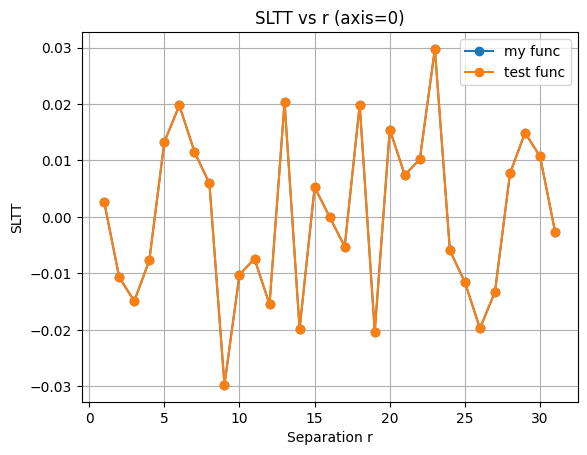

In [ ]:
#test that SLTT of struct func is correct
import numpy as np
import matplotlib.pyplot as plt
from structure_functions import safe_struct

# # it's wrong because it calculates 6 terms for each direction so total of 18 terms. but should be 2 terms per direction to get 6 total.
# def SLTT_all(u1, u2, u3, dissipation, axis=0):
#     """
#     Compute SLTT for all separations r along one axis, assuming periodic BCs.
    
#     Parameters
#     ----------
#     u1, u2, u3 : ndarray
#         3D velocity component arrays of the same shape (Nx,Ny,Nz).
#     dissipation : float
#         Dissipation rate ε.
#     axis : int
#         Axis along which to compute the shift (0=x, 1=y, 2=z).
    
#     Returns
#     -------
#     sltt_vals : ndarray
#         1D array of SLTT values for r = 0..N-1
#     """
#     N = u1.shape[axis]
#     sltt_vals = np.zeros(N)

#     for r in range(N):
#         if r == 0:
#             sltt_vals[r] = 0.0
#             continue

#         # periodic shift
#         u1_shift = np.roll(u1, shift=-r, axis=axis)
#         u2_shift = np.roll(u2, shift=-r, axis=axis)
#         u3_shift = np.roll(u3, shift=-r, axis=axis)

#         # velocity increments
#         du1 = u1 - u1_shift
#         du2 = u2 - u2_shift
#         du3 = u3 - u3_shift

#         # corrected terms
#         term1 = np.mean(du1 * du2**2)
#         term2 = np.mean(du1 * du3**2)
#         term3 = np.mean(du2 * du1**2)
#         term4 = np.mean(du2 * du3**2)
#         term5 = np.mean(du3 * du1**2)
#         term6 = np.mean(du3 * du2**2)

#         numerator = term1 + term2 + term3 + term4 + term5 + term6
#         denominator = 6 * dissipation

#         sltt_vals[r] = numerator / denominator

#     return sltt_vals


def SLTT_all(u1, u2, u3, dissipation, axis=0):
    """
    Compute SLTT for all separations r along one axis, assuming periodic BCs.
    
    Parameters
    ----------
    u1, u2, u3 : ndarray
        3D velocity component arrays of the same shape (Nx,Ny,Nz).
    dissipation : float
        Dissipation rate ε.
    axis : int
        Axis along which to compute the shift (0=x, 1=y, 2=z).
        This is the longitudinal direction.
    
    Returns
    -------
    sltt_vals : ndarray
        1D array of SLTT values for r = 0..N-1
    """
    N = u1.shape[axis]
    sltt_vals = np.zeros(N)

    # pick longitudinal and transverse components
    if axis == 0:
        uL, uT1, uT2 = u1, u2, u3
    elif axis == 1:
        uL, uT1, uT2 = u2, u1, u3
    elif axis == 2:
        uL, uT1, uT2 = u3, u1, u2
    else:
        raise ValueError("axis must be 0, 1, or 2")

    for r in range(N):
        if r == 0:
            sltt_vals[r] = 0.0
            continue

        # periodic shift
        uL_shift  = np.roll(uL,  shift=-r, axis=axis)
        uT1_shift = np.roll(uT1, shift=-r, axis=axis)
        uT2_shift = np.roll(uT2, shift=-r, axis=axis)

        # increments
        duL  = uL  - uL_shift
        duT1 = uT1 - uT1_shift
        duT2 = uT2 - uT2_shift

        # only 2 terms per direction
        term1 = np.mean(duL * duT1**2)
        term2 = np.mean(duL * duT2**2)

        numerator = term1 + term2
        denominator = 2 * dissipation   # 2 terms per axis

        sltt_vals[r] = numerator / denominator

    return sltt_vals

Nx = Ny = Nz = 32
np.random.seed(12)
u1 = np.random.randn(Nx, Ny, Nz)
u2 = np.random.randn(Nx, Ny, Nz)
u3 = np.random.randn(Nx, Ny, Nz)

dissipation = 1
sltt_curve = SLTT_all(u1, u2, u3, dissipation, axis=0)
S_x = safe_struct((u1, u2, u3), direction="x", chkpt_freq=64, dtype=np.float64)
plt.plot(range(1,Nx), S_x["LTT"][0:31]/2, marker='o', label ="my func")
plt.plot(range(1,Nx), sltt_curve[1:32], marker='o', label = "test func")

plt.xlabel("Separation r")
plt.ylabel("SLTT")
plt.legend()
plt.title("SLTT vs r (axis=0)")
plt.grid(True)
plt.show()

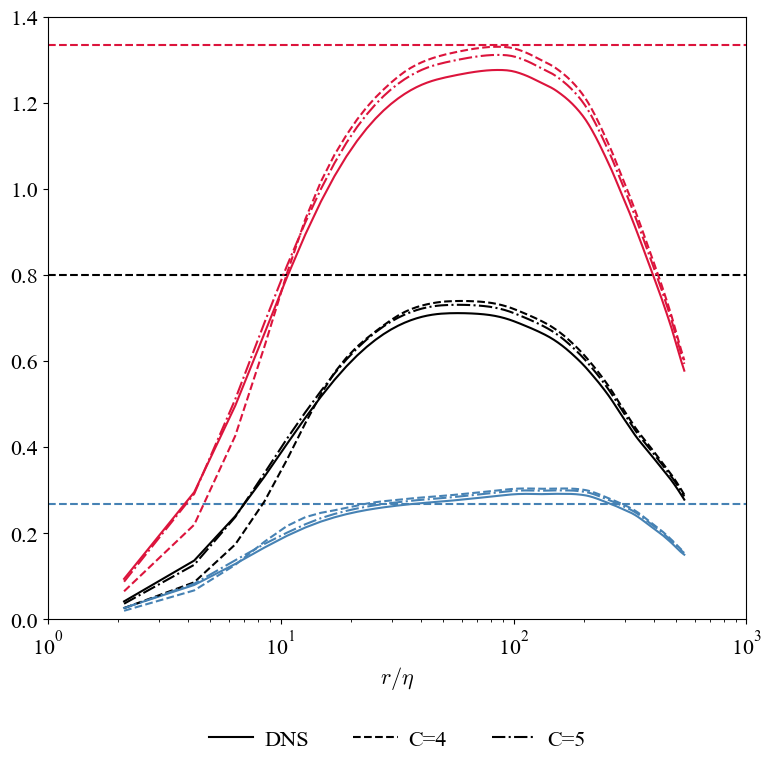

In [13]:
#Plot structure functions

# plt.figure(figsize=(8, 6))
# plt.title('2-pt Correlation')
# plt.ylabel('2-pt Correlation')
# plt.plot(r_eta, corr2pt_L.T, label='DNS - Avg', color='black')
# plt.plot(r_eta, S_x["corr2pt_L"].T, label='DNS - x', color='red')
# plt.plot(r_eta, S_y["corr2pt_L"].T, label='DNS - y', color='blue')
# plt.plot(r_eta, S_z["corr2pt_L"].T, label='DNS - z', color='green')
# plt.plot(r_eta, corr2pt_L_comp_e3.T, label='MPS C3 - Avg', linestyle='--', color='black')
# plt.plot(r_eta, S_x_comp_e3["corr2pt_L"].T, label='MPS C3 - x', linestyle='--', color='red')
# plt.plot(r_eta, S_y_comp_e3["corr2pt_L"].T, label='MPS C3 - y', linestyle='--', color='blue')
# plt.plot(r_eta, S_z_comp_e3["corr2pt_L"].T, label='MPS C3 - z', linestyle='--', color='green')
# plt.plot(r_eta, corr2pt_L_comp_e4.T, label='MPS C4 - Avg', linestyle=':', color='black')
# plt.plot(r_eta, S_x_comp_e4["corr2pt_L"].T, label='MPS C4 - x', linestyle=':', color='red')
# plt.plot(r_eta, S_y_comp_e4["corr2pt_L"].T, label='MPS C4 - y', linestyle=':', color='blue')
# plt.plot(r_eta, S_z_comp_e4["corr2pt_L"].T, label='MPS C4 - z', linestyle=':', color='green')
# plt.plot(r_eta, corr2pt_L_comp_e5.T, label='MPS C5 - Avg', linestyle='-.', color='black')
# plt.plot(r_eta, S_x_comp_e5["corr2pt_L"].T, label='MPS C5 - x', linestyle='-.', color='red')
# plt.plot(r_eta, S_y_comp_e5["corr2pt_L"].T, label='MPS C5 - y', linestyle='-.', color='blue')
# plt.plot(r_eta, S_z_comp_e5["corr2pt_L"].T, label='MPS C5 - z', linestyle='-.', color='green')

# plt.figure(figsize=(8, 6))
# plt.title(r'$4/5$ law')
# plt.ylabel(r'$D_{LLL}/(\varepsilon r)$')
# plt.axhline(4/5, label=r'$4/5$ law', linestyle=':', color='gray', linewidth=2.5)
# plt.plot(r_eta, (S_LLL/(C_4_5*eps*r_safe)).T, label='DNS - Avg', color='black')
# plt.plot(r_eta, (S_x["LLL"]/(C_4_5*eps*r_safe)).T, label='DNS - x', color='red')
# plt.plot(r_eta, (S_y["LLL"]/(C_4_5*eps*r_safe)).T, label='DNS - y', color='blue')
# plt.plot(r_eta, (S_z["LLL"]/(C_4_5*eps*r_safe)).T, label='DNS - z', color='green')
# plt.plot(r_eta, (S_LLL_comp_e3/(C_4_5*eps_comp_e3*r_safe)).T, label='MPS C3 - Avg', linestyle='--', color='black')
# plt.plot(r_eta, (S_x_comp_e3["LLL"]/(C_4_5*eps_comp_e3*r_safe)).T, label='MPS C3 - x', linestyle='--', color='red')
# plt.plot(r_eta, (S_y_comp_e3["LLL"]/(C_4_5*eps_comp_e3*r_safe)).T, label='MPS C3 - y', linestyle='--', color='blue')
# plt.plot(r_eta, (S_z_comp_e3["LLL"]/(C_4_5*eps_comp_e3*r_safe)).T, label='MPS C3 - z', linestyle='--', color='green')
# plt.plot(r_eta, (S_LLL_comp_e4/(C_4_5*eps_comp_e4*r_safe)).T, label='MPS C4 - Avg', linestyle=':', color='black')
# plt.plot(r_eta, (S_x_comp_e4["LLL"]/(C_4_5*eps_comp_e4*r_safe)).T, label='MPS C4 - x', linestyle=':', color='red')
# plt.plot(r_eta, (S_y_comp_e4["LLL"]/(C_4_5*eps_comp_e4*r_safe)).T, label='MPS C4 - y', linestyle=':', color='blue')
# plt.plot(r_eta, (S_z_comp_e4["LLL"]/(C_4_5*eps_comp_e4*r_safe)).T, label='MPS C4 - z', linestyle=':', color='green')
# plt.plot(r_eta, (S_LLL_comp_e5/(C_4_5*eps_comp_e5*r_safe)).T, label='MPS C5 - Avg', linestyle='-.', color='black')
# plt.plot(r_eta, (S_x_comp_e5["LLL"]/(C_4_5*eps_comp_e5*r_safe)).T, label='MPS C5 - x', linestyle='-.', color='red')
# plt.plot(r_eta, (S_y_comp_e5["LLL"]/(C_4_5*eps_comp_e5*r_safe)).T, label='MPS C5 - y', linestyle='-.', color='blue')
# plt.plot(r_eta, (S_z_comp_e5["LLL"]/(C_4_5*eps_comp_e5*r_safe)).T, label='MPS C5 - z', linestyle='-.', color='green')

# plt.ylabel(r'$-D_{LLL}/(\varepsilon r)$')
# plt.plot(r_eta[1:513], (-(S_LLL[0][1023:511:-1])/(C_4_5*eps*r_safe[0][1:513])).T, label='DNS - Avg', color='black')
# plt.plot(r_eta[1:513], (-(S_x["LLL"][0][1023:511:-1])/(C_4_5*eps*r_safe[0][1:513])).T, label='DNS - x', color='red')
# plt.plot(r_eta[1:513], (-(S_y["LLL"][0][1023:511:-1])/(C_4_5*eps*r_safe[0][1:513])).T, label='DNS - y', color='blue')
# plt.plot(r_eta[1:513], (-(S_z["LLL"][0][1023:511:-1])/(C_4_5*eps*r_safe[0][1:513])).T, label='DNS - z', color='green')


# plt.figure(figsize=(8, 6))
# plt.title(r'$4/15$ law')
# plt.ylabel(r'$D_{LTT}/(\varepsilon r)$')
# plt.axhline(4/15, label=r'$4/15$ law', linestyle=':', color='gray', linewidth=2.5)
# plt.plot(r_eta, (S_LTT/(C_4_15*eps*r_safe)).T, label='DNS - Avg', color='black')
# plt.plot(r_eta, (S_x["LTT"]/(C_4_15*eps*r_safe)).T, label='DNS - x', color='red')
# plt.plot(r_eta, (S_y["LTT"]/(C_4_15*eps*r_safe)).T, label='DNS - y', color='blue')
# plt.plot(r_eta, (S_z["LTT"]/(C_4_15*eps*r_safe)).T, label='DNS - z', color='green')
# plt.plot(r_eta, (S_LTT_comp_e3/(C_4_15*eps_comp_e3*r_safe)).T, label='MPS C3 - Avg', linestyle='--', color='black')
# plt.plot(r_eta, (S_x_comp_e3["LTT"]/(C_4_15*eps_comp_e3*r_safe)).T, label='MPS C3 - x', linestyle='--', color='red')
# plt.plot(r_eta, (S_y_comp_e3["LTT"]/(C_4_15*eps_comp_e3*r_safe)).T, label='MPS C3 - y', linestyle='--', color='blue')
# plt.plot(r_eta, (S_z_comp_e3["LTT"]/(C_4_15*eps_comp_e3*r_safe)).T, label='MPS C3 - z', linestyle='--', color='green')
# plt.plot(r_eta, (S_LTT_comp_e4/(C_4_15*eps_comp_e4*r_safe)).T, label='MPS C4 - Avg', linestyle=':', color='black')
# plt.plot(r_eta, (S_x_comp_e4["LTT"]/(C_4_15*eps_comp_e4*r_safe)).T, label='MPS C4 - x', linestyle=':', color='red')
# plt.plot(r_eta, (S_y_comp_e4["LTT"]/(C_4_15*eps_comp_e4*r_safe)).T, label='MPS C4 - y', linestyle=':', color='blue')
# plt.plot(r_eta, (S_z_comp_e4["LTT"]/(C_4_15*eps_comp_e4*r_safe)).T, label='MPS C4 - z', linestyle=':', color='green')
# plt.plot(r_eta, (S_LTT_comp_e5/(C_4_15*eps_comp_e5*r_safe)).T, label='MPS C5 - Avg', linestyle='-.', color='black')
# plt.plot(r_eta, (S_x_comp_e5["LTT"]/(C_4_15*eps_comp_e5*r_safe)).T, label='MPS C5 - x', linestyle='-.', color='red')
# plt.plot(r_eta, (S_y_comp_e5["LTT"]/(C_4_15*eps_comp_e5*r_safe)).T, label='MPS C5 - y', linestyle='-.', color='blue')
# plt.plot(r_eta, (S_z_comp_e5["LTT"]/(C_4_15*eps_comp_e5*r_safe)).T, label='MPS C5 - z', linestyle='-.', color='green')

# plt.figure(figsize=(8, 6))
# plt.title(r'$4/3$ law')
# plt.ylabel(r'$(D_{LLL} + 2D_{LTT})/(\varepsilon r)$')
# plt.axhline(4/3, label=r'$4/3$ law', linestyle=':', color='gray', linewidth=2.5)
# plt.plot(r_eta, ((S_LLL + 2 * S_LTT)/(C_4_3*eps*r_safe)).T, label='DNS - Avg', color='black')
# plt.plot(r_eta, ((S_x["LLL"] + 2 * S_x["LTT"])/(C_4_3*eps*r_safe)).T, label='DNS - x', color='red')
# plt.plot(r_eta, ((S_y["LLL"] + 2 * S_y["LTT"])/(C_4_3*eps*r_safe)).T, label='DNS - y', color='blue')
# plt.plot(r_eta, ((S_z["LLL"] + 2 * S_z["LTT"])/(C_4_3*eps*r_safe)).T, label='DNS - z', color='green')
# plt.plot(r_eta, ((S_LLL_comp_e3 + 2 * S_LTT_comp_e3)/(C_4_3*eps_comp_e3*r_safe)).T, label='MPS C3 - Avg', linestyle='--', color='black')
# plt.plot(r_eta, ((S_x_comp_e3["LLL"] + 2 * S_x_comp_e3["LTT"])/(C_4_3*eps_comp_e3*r_safe)).T, label='MPS C3 - x', linestyle='--', color='red')
# plt.plot(r_eta, ((S_y_comp_e3["LLL"] + 2 * S_y_comp_e3["LTT"])/(C_4_3*eps_comp_e3*r_safe)).T, label='MPS C3 - y', linestyle='--', color='blue')
# plt.plot(r_eta, ((S_z_comp_e3["LLL"] + 2 * S_z_comp_e3["LTT"])/(C_4_3*eps_comp_e3*r_safe)).T, label='MPS C3 - z', linestyle='--', color='green')
# plt.plot(r_eta, ((S_LLL_comp_e4 + 2 * S_LTT_comp_e4)/(C_4_3*eps_comp_e4*r_safe)).T, label='MPS C4 - Avg', linestyle=':', color='black')
# plt.plot(r_eta, ((S_x_comp_e4["LLL"] + 2 * S_x_comp_e4["LTT"])/(C_4_3*eps_comp_e4*r_safe)).T, label='MPS C4 - x', linestyle=':', color='red')
# plt.plot(r_eta, ((S_y_comp_e4["LLL"] + 2 * S_y_comp_e4["LTT"])/(C_4_3*eps_comp_e4*r_safe)).T, label='MPS C4 - y', linestyle=':', color='blue')
# plt.plot(r_eta, ((S_z_comp_e4["LLL"] + 2 * S_z_comp_e4["LTT"])/(C_4_3*eps_comp_e4*r_safe)).T, label='MPS C4 - z', linestyle=':', color='green')
# plt.plot(r_eta, ((S_LLL_comp_e5 + 2 * S_LTT_comp_e5)/(C_4_3*eps_comp_e5*r_safe)).T, label='MPS C5 - Avg', linestyle='-.', color='black')
# plt.plot(r_eta, ((S_x_comp_e5["LLL"] + 2 * S_x_comp_e5["LTT"])/(C_4_3*eps_comp_e5*r_safe)).T, label='MPS C5 - x', linestyle='-.', color='red')
# plt.plot(r_eta, ((S_y_comp_e5["LLL"] + 2 * S_y_comp_e5["LTT"])/(C_4_3*eps_comp_e5*r_safe)).T, label='MPS C5 - y', linestyle='-.', color='blue')
# plt.plot(r_eta, ((S_z_comp_e5["LLL"] + 2 * S_z_comp_e5["LTT"])/(C_4_3*eps_comp_e5*r_safe)).T, label='MPS C5 - z', linestyle='-.', color='green')

plt.figure(figsize=(8, 8))
plt.axhline(4/15, linestyle='--', color='steelblue')
plt.axhline(4/5, linestyle='--', color='black')
plt.axhline(4/3, linestyle='--', color='crimson')
# plt.plot(r_eta[0:255], D_4_3.T[0:255],  label=r'DNS - $4/3$', color='crimson')
# plt.plot(r_eta[0:255], D_4_5.T[0:255],  label=r'DNS - $4/5$', color='black')
# plt.plot(r_eta[0:255], D_4_15.T[0:255], label=r'DNS - $4/15$', color='steelblue')
# # plt.plot(r_eta, D_4_3_comp_e3.T,  label=r'$4/3$   law - MPS C3 Avg', linestyle='--', color='crimson')
# # plt.plot(r_eta, D_4_5_comp_e3.T,  label=r'$4/5$   law - MPS C3 Avg', linestyle='--', color='black')
# # plt.plot(r_eta, D_4_15_comp_e3.T, label=r'$4/15$ law - MPS C3 Avg', linestyle='--', color='steelblue')
# plt.plot(r_eta[0:255], D_4_3_comp_e4.T[0:255],  label=r'C4 - $4/3$', color='crimson')
# plt.plot(r_eta[0:255], D_4_5_comp_e4.T[0:255],  label=r'C4 - $4/5$', color='black')
# plt.plot(r_eta[0:255], D_4_15_comp_e4.T[0:255], label=r'C4 - $4/15$', color='steelblue')
# plt.plot(r_eta[0:255], D_4_3_comp_e5.T[0:255],  label=r'C5 - $4/3$', color='crimson')
# plt.plot(r_eta[0:255], D_4_5_comp_e5.T[0:255],  label=r'C5 - $4/5$', color='black')
# plt.plot(r_eta[0:255], D_4_15_comp_e5.T[0:255], label=r'C5 - $4/15$', color='steelblue')
# plt.plot(r_eta[0:255], D_4_3_comp_e5.T[0:255],  label=r'MPS - $4/3$  law', color='crimson')
# plt.plot(r_eta[0:255], D_4_5_comp_e5.T[0:255],  label=r'MPS - $4/5$  law', color='black')
# plt.plot(r_eta[0:255], D_4_15_comp_e5.T[0:255], label=r'MPS - $4/15$ law', color='steelblue')

# plt.plot(r_d, D_4_3.T,  label=r'$4/3$   law', linestyle='-', color='crimson')
# plt.plot(r_d, D_4_5.T,  label=r'$4/5$   law', linestyle='-', color='black')
# plt.plot(r_d, D_4_15.T, label=r'$4/15$ law', linestyle='-', color='steelblue')

# plt.xlim(r_eta[1], r_eta[511])
# plt.xlim(r_eta[511], r_eta[1023])
# plt.ylim(0,0.125)
# plt.xlim(2, 1100)

plt.plot(r_eta[0:255], D_4_3.T[0:255], color='crimson')
plt.plot(r_eta[0:255], D_4_5.T[0:255],  label=r'DNS', color='black')
plt.plot(r_eta[0:255], D_4_15.T[0:255], color='steelblue')
# plt.plot(r_eta, D_4_3_comp_e3.T,  label=r'$4/3$   law - MPS C3 Avg', linestyle='--', color='crimson')
# plt.plot(r_eta, D_4_5_comp_e3.T,  label=r'$4/5$   law - MPS C3 Avg', linestyle='--', color='black')
# plt.plot(r_eta, D_4_15_comp_e3.T, label=r'$4/15$ law - MPS C3 Avg', linestyle='--', color='steelblue')
plt.plot(r_eta[0:255], D_4_3_comp_e4.T[0:255], color='crimson', linestyle='--')
plt.plot(r_eta[0:255], D_4_5_comp_e4.T[0:255],  label=r'C=4', color='black', linestyle='--')
plt.plot(r_eta[0:255], D_4_15_comp_e4.T[0:255], color='steelblue', linestyle='--')
plt.plot(r_eta[0:255], D_4_3_comp_e5.T[0:255], color='crimson', linestyle='-.')
plt.plot(r_eta[0:255], D_4_5_comp_e5.T[0:255],  label=r'C=5', color='black', linestyle='-.')
plt.plot(r_eta[0:255], D_4_15_comp_e5.T[0:255], color='steelblue', linestyle='-.')


plt.ylim(0,1.4)
plt.xlim(1, 1e3)
plt.xlabel(r'$r/\eta$')
plt.xscale('log')
# plt.legend(loc='upper left')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False, fontsize=16, columnspacing=2.0, handletextpad=0.5, labelspacing=0.7)
# plt.grid(True, which='both', linestyle=':', linewidth=0.7, alpha=0.7)
plt.tight_layout()
plt.savefig('structure_functions.pdf', dpi=300)
# import tikzplotlib
# tikzplotlib.save('structure_functions.tex')
plt.show()


In [33]:
r_eta

array([[0.00000000e+00],
       [2.12952261e+00],
       [4.25904522e+00],
       ...,
       [2.17424258e+03],
       [2.17637211e+03],
       [2.17850163e+03]])

In [5]:
# max(S_LLL[0][1023:511:-1] + S_LLL[0][1:513])
# S_LLL[0][1023:511:-1] + S_LLL[0][1:513]

# file_path = "/Users/massen/Library/CloudStorage/OneDrive-UniversityofPittsburgh/Shared with Everyone/Forced Isotropic Dataset/1024 Double/Data 2/stats-1024-2/spectra/twoptmeasures.00102.dat"
# file_path = "/Users/massen/Desktop/Daniel 32 cubed/stats-32/spectra/twoptmeasures.00010.dat"
file_path = "/Users/massen/Desktop/spectra/twoptmeasures.00000.dat"

with open(file_path, "r") as f:
    for _ in range(10):  # show first 10 lines
        print(f.readline().strip())


# time=   99.999999999999702
#       r      f      g  vstr2  vstr3  vsLTT (L+2T)
0.15410034352318E+02  0.98042158720323E+00  0.95598434883593E+00  0.25194019216594E+01  0.14637548460581E+01  0.66381971225385E+00  0.27913942705658E+01
0.30820068704636E+02  0.92780523721112E+00  0.84044476680560E+00  0.58532962659606E+01  0.48975218081777E+01  0.23109273829206E+01  0.95193765740190E+01
0.46230103056954E+02  0.85590301220786E+00  0.68887035434345E+00  0.89186965727621E+01  0.83449362800393E+01  0.42544312695605E+01  0.16853798819160E+02
0.61640137409272E+02  0.77774517129501E+00  0.53212509960118E+00  0.11363819025879E+02  0.10442154121796E+02  0.59386633429440E+01  0.22319480807685E+02
0.77050171761590E+02  0.70165283694027E+00  0.38771355385898E+00  0.13163855590546E+02  0.10966746863263E+02  0.70378806474453E+01  0.25042508158153E+02
0.92460206113908E+02  0.63203159501163E+00  0.26317519496257E+00  0.14408146593917E+02  0.10325833496560E+02  0.75278940791676E+01  0.25381621654895E+02
0

Text(0.5, 0, '$r/\\eta$')

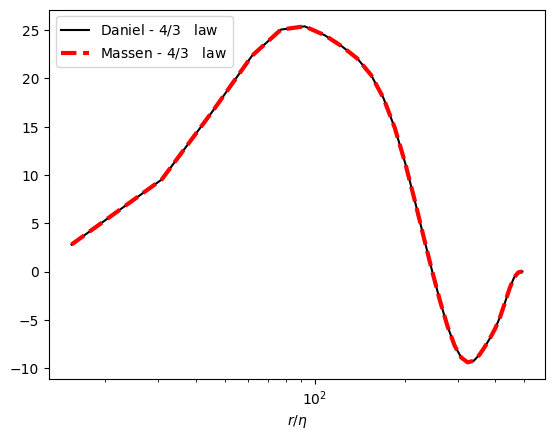

In [6]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt(file_path, comments="#")
r_d  = np.array(data[:,0]).reshape(-1, 1)
r1 = r_d*((2*np.pi)/data[-1,0])
a1 = np.array(data[:,1]).reshape(-1, 1)
# a = a1 - corr2pt_L.T
# print(a.T[0:15])
# plt.plot(a, color='blue', linestyle='--')
# plt.xlabel('Index')
# plt.ylabel('Difference')
# plt.grid(True)

# plt.title('2pt Correlation')
# plt.plot(r1[0:-1], corr2pt_L.T[1:], label='Massen', linestyle='-', color='steelblue')
# plt.plot(r1[0:-1], a1[0:-1], label='Daniel', linestyle='-', color='black')
# plt.plot(r_d[0:-15], a1[0:-15], label='Daniel', linestyle='-', color='black')

# epsilon = 0.008988433455919723
# eta_k1 = 0.010859416776729707
# nu = 5e-4
# r_eta = r.T/ eta_k1
# D_4_15 = S_LTT / (C_4_15*epsilon * r_safe)
eps_4_5 = 1/210.86044549
# eps_4_5 = 1
Cdd = 1
D_4_3_dani  = np.array(data[:,6]).reshape(-1, 1)/Cdd
D_4_5_dani  = np.array(data[:,4]).reshape(-1, 1)/Cdd
D_4_15_dani = np.array(data[:,5]).reshape(-1, 1)/Cdd

# plt.figure(figsize=(8, 6))
plt.plot(r_d, D_4_3_dani,  label=r'Daniel - $4/3$   law', linestyle='-', color='black')
# plt.plot(r_d, D_4_5_dani,  label=r'Daniel - $4/5$   law', linestyle='-', color='black')
# plt.plot(r_d, D_4_15_dani, label=r'Daniel - $4/15$ law', linestyle='-', color='black')
# plt.plot(data[:,0], data[:,6],  label=r'$4/3$   law', linestyle='-', color='crimson')
# plt.plot(data[:,0], data[:,4],  label=r'$4/5$   law', linestyle='-', color='black')
# plt.plot(r_d[1:511], data[:,5][0:510], label=r'$4/15$ law', linestyle='-', color='steelblue')

plt.plot(r_d,  D_4_3.T/eps_4_5,  label=r'Massen - $4/3$   law', linestyle='--', color='red', linewidth=3)
# plt.plot(r_d, D_4_5.T/eps_4_5,  label=r'Massen - $4/5$   law', linestyle='--', color='red', linewidth=3)
# plt.plot(r_d, D_4_15.T/eps_4_5, label=r'Massen - $4/15$ law', linestyle='--', color='red', linewidth=3)
# plt.plot(r_d, S_x["LTT_f"].T/eps_4_5, label=r'Massen 3x - $4/15$ law', linestyle='-.', color='red')
# plt.plot(r_d, S_y["LTT_f"].T/eps_4_5, label=r'Massen 3y - $4/15$ law', linestyle='-.', color='red')
# plt.plot(r_d, S_z["LTT_f"].T/eps_4_5, label=r'Massen 3z - $4/15$ law', linestyle='-.', color='red')

# plt.axhline(4/15, linestyle=':', color='steelblue', linewidth=2.5)
# plt.axhline(4/5, linestyle=':', color='black', linewidth=2.5)
# plt.axhline(4/3, linestyle=':', color='crimson', linewidth=2.5)
# plt.legend(loc='upper right')
# plt.xscale('log')
# plt.xlabel(r'$r/\eta$')
# plt.xlim(r_d[1], r_d[511])

# plt.plot(r_eta[1:16], D_4_15.T[1:16], label=r'$4/15$ law', linestyle='-', color='steelblue')

# plt.plot(r_d, data[:,1], label='Daniel -  2pt corr', linestyle='-', color='black')
# plt.plot(r_d, corr2pt_L.T, label='Massen - 2pt corr', linestyle='--', color='red', linewidth=3)

# plt.plot(r_d, data[:,3], label=fr'Daniel -  $S_{{L\,L}}$', linestyle='-', color='black')
# plt.plot(r_d, S_LLr.T, label=fr'Massen -  $S_{{L\,L}}$', linestyle='--', color='red', linewidth=3)

plt.legend()
plt.xscale('log')
plt.xlabel(r'$r/\eta$')
# plt.grid(True)
# data.shape
# r_eta[1:] -r_d[0:-1]

In [ ]:
# print(np.max(np.abs(data[:,3]-(S_LLr))))
# print(np.max(np.abs(data[:,4]-(1/eps_4_5*D_4_5))))
# print(np.max(np.abs(data[:,5]-(1/eps_4_5*D_4_15))))
# print(np.max(np.abs(data[:,6]-(1/eps_4_5*D_4_3))))


4.680273946178204e-10


In [ ]:
#verification of eps / dissipation rate calculation

import numpy as np

# Utility: uniform periodic grid [0, 2π)^3
def grid(N):
    L = 2*np.pi
    x = np.linspace(0, L, N, endpoint=False)
    return np.meshgrid(x, x, x, indexing="ij")

# --------------------------
# 1) Taylor–Green vortex (3D)
# u = ( U0 sin x cos y cos z,  -U0 cos x sin y cos z,  0 )
# Exact: ε = (3/4) ν U0^2
# --------------------------
def make_taylor_green(N=32, U0=1.0, nu=1.0):
    X,Y,Z = grid(N)
    ux = U0*np.sin(X)*np.cos(Y)*np.cos(Z)
    uy = -U0*np.cos(X)*np.sin(Y)*np.cos(Z)
    uz = np.zeros_like(X)
    eps_true = 0.75 * nu * U0**2
    return ux, uy, uz, nu, eps_true

# --------------------------
# 2) Single shear wave (divergence-free)
# u = (0, U0 sin(k x), 0)
# Exact (box 2π): ε = (1/2) ν U0^2 k^2
# --------------------------
def make_shear_wave(N=32, U0=1.0, k=3, nu=1.0):
    X,Y,Z = grid(N)
    ux = np.zeros_like(X)
    uy = U0*np.sin(k*X)
    uz = np.zeros_like(X)
    eps_true = 0.5 * nu * U0**2 * k**2
    return ux, uy, uz, nu, eps_true

# --------------------------
# 3) ABC (Beltrami) flow
# u = ( A sin z + C cos y,  B sin x + A cos z,  C sin y + B cos x )
# Exact (box 2π): ε = ν (A^2 + B^2 + C^2)
# --------------------------
def make_abc(N=32, A=1.0, B=2.0, C=3.0, nu=1.0):
    X,Y,Z = grid(N)
    ux = A*np.sin(Z) + C*np.cos(Y)
    uy = B*np.sin(X) + A*np.cos(Z)
    uz = C*np.sin(Y) + B*np.cos(X)
    eps_true = nu * (A**2 + B**2 + C**2)
    return ux, uy, uz, nu, eps_true

# --------------------------
# Example harness (replace `compute_eps` with your function)
# --------------------------
from calculate_gradients import calculate_gradients
from calculate_eps_stilde import calculate_eps
def compute_eps(ux, uy, uz, nu, N):
    dx = 2*np.pi/N
    gradients = calculate_gradients((ux, uy, uz), (dx, dx, dx), order = 4, spectral = True)
    dissipation_rate = calculate_eps(gradients, nu)
    eps = np.sum(dissipation_rate) / (N**3)
    return eps

N = 32
tests = [
    ("Taylor-Green", make_taylor_green()),
    ("Shear wave",    make_shear_wave()),
    ("ABC flow",      make_abc())
]
for name, pack in tests:
    ux,uy,uz,nu,eps_true = pack
    # Example signatures you might have:
    # eps_hat = compute_eps(ux, uy, uz, nu)                # gradient/vorticity based
    # eps_hat = compute_eps(ux, uy, uz, nu, periodic=True) # if needed
    eps_hat = compute_eps(ux, uy, uz, nu, N)                  # <- plug yours here
    rel_err = abs(eps_hat - eps_true)/eps_true
    print(f"{name:12s}  eps_true={eps_true:.12f}  eps_hat={eps_hat:.12f}  rel_err={rel_err:.3e}")




Taylor-Green  eps_true=0.750000000000  eps_hat=0.750000000000  rel_err=0.000e+00
Shear wave    eps_true=4.500000000000  eps_hat=4.500000000000  rel_err=1.974e-16
ABC flow      eps_true=14.000000000000  eps_hat=14.000000000000  rel_err=0.000e+00


In [201]:
# print(data[:10,1])
# print(corr2pt_L[0][1023:1013:-1].T)
a = data[1:-1,0]-data[0:-2,0]
print(max(a))
print(min(a))
b = (data[:,0]-data[0,0])/((data[-1,0]-data[0,0])/2/np.pi)
print(b)
# c = data[:,0]/((data[1,0]-data[0,0])/(512/np.pi))
# print(c)
# data[1,0]-data[0,0]

1.800876835300187
1.8008768351999151
[0.00000000e+00 6.14192112e-03 1.22838422e-02 ... 6.27090146e+00
 6.27704339e+00 6.28318531e+00]


In [ ]:
#85_scalar_dissipation

import sys
mps_codes_path = "/ix/pgivi/moe32/Schmidt/mps_py_codes"
sys.path.append(mps_codes_path)

###########################################################################################################################

from calculate_u_comp_fidelity_l2norm import calculate_fidelity, calculate_l2norm
from process_file_1024 import load_velocity_binary, load_JHS_velocity_1024_jul, load_JHS_velocity_1024
from plotting import plot_pdf, plot_scatter
from save_as_mat import save_as_h5, load_h5
from calculate_spectral_derivative import spectral_derivative
import numpy as np
import json

cutoff = 1e-4
comp_path_u = f'truncated_U_1024_il_cf0.0001.mat'


###########################################################################################################################
## Binary data - Daniel

comp_path_u = f'truncated_U_1024_il_cf0.0001.mat'


N = 32
config_path = "config_FI.json"
with open(config_path, "r") as f:
    config = json.load(f)
org_path = config.get("32_binary_dns", {})


# N = 1024
# config_path = mps_codes_path + "/config_FI.json"
# with open(config_path, "r") as f:
#     config = json.load(f)
# org_path = config.get("full_binary_dns", {})


u = load_velocity_binary(org_path['vel']['U'], N, skip_bytes=192)
# u_comp = u + 0.01 * np.random.normal(size=u.shape)
nu = 0.0005
dx = 2*np.pi/N
dy = dx
dz = dx

###########################################################################################################################
## JHS data

# N = 128
# comp_path_u = f'jhs_truncated_u_1024_il_cf0.0001.mat'
# comp_path_v = f'jhs_truncated_v_1024_il_cf0.0001.mat'
# comp_path_w = f'jhs_truncated_w_1024_il_cf0.0001.mat'
# config_path = "config_FI.json"
# with open(config_path, "r") as f:
#     config = json.load(f)
# org_path = config.get("128_dns", {})

# N = 1024
# config_path = mps_codes_path + "/config_FI.json"
# with open(config_path, "r") as f:
#     config = json.load(f)
# org_path = config.get("full_dns", {})

# u = load_JHS_velocity_1024(org_path['vel']['U'])
# v = load_JHS_velocity_1024(org_path['vel']['V'])
# w = load_JHS_velocity_1024(org_path['vel']['W'])
# # u = u-np.mean(u)
# # v = v-np.mean(v)
# # w = w-np.mean(w)


###########################################################################################################################

gradients = {}
# gradients['dux_dx'] = spectral_derivative(u, axis=0, dx=dx)
# gradients['dux_dy'] = spectral_derivative(u, axis=1, dx=dy)
# gradients['dux_dz'] = spectral_derivative(u, axis=2, dx=dz)
# gradients['disp'] = gradients['dux_dx']**2 + gradients['dux_dy']**2 + gradients['dux_dz']**2
# eps_scalar = np.mean(gradients['disp'])

gradients_comp = {}
# gradients_comp['dux_dx'] = spectral_derivative(u_comp, axis=0, dx=dx)
# gradients_comp['dux_dy'] = spectral_derivative(u_comp, axis=1, dx=dy)
# gradients_comp['dux_dz'] = spectral_derivative(u_comp, axis=2, dx=dz)
# gradients_comp['disp'] = gradients_comp['dux_dx']**2 + gradients_comp['dux_dy']**2 + gradients_comp['dux_dz']**2
# eps_scalar_comp = np.mean(gradients_comp['disp'])

# print(f"Cutoff: {cutoff}")
# print(f"eps_scalar DNS: \t{eps_scalar}")
# print(f"eps_scalar comp:\t{eps_scalar_comp}")
# print(f"eps_scalar infidelity:\t{1-calculate_fidelity(gradients['disp'], gradients_comp['disp'])}")
# print(f"eps_scalar l2 norm:\t{calculate_l2norm(gradients['disp'], gradients_comp['disp'])}")
# print(f"eps_scalar corr coeff:\t{np.corrcoef(gradients['disp'].flatten(), gradients_comp['disp'].flatten())[0, 1]}")

# print(f"\nmean grad (dphi/dx)^2:\t{np.mean(gradients['dux_dx']**2)}")
# print(f"mean grad (dphi/dy)^2:\t{np.mean(gradients['dux_dy']**2)}")
# print(f"mean grad (dphi/dz)^2:\t{np.mean(gradients['dux_dz']**2)}")

# print(f"mean grad (dphi/dx)^2 comp:\t{np.mean(gradients_comp['dux_dx']**2)}")
# print(f"mean grad (dphi/dy)^2 comp:\t{np.mean(gradients_comp['dux_dy']**2)}")
# print(f"mean grad (dphi/dz)^2 comp:\t{np.mean(gradients_comp['dux_dz']**2)}\n")

# save_as_h5(f'dissipation_scalar', 'disp', gradients['disp'])
# save_as_h5(f'dissipation_scalar_comp', 'disp', gradients_comp['disp'])

gradients['disp'] = load_h5('dissipation_scalar.h5')
gradients_comp['disp'] = load_h5('dissipation_scalar_comp.h5')
# import matplotlib as mpl
# mpl.rcParams['text.usetex'] = False
# plot_pdf({r'Scalar $\varepsilon$ DNS':gradients['disp'], r'Scalar $\varepsilon$ MPS':gradients_comp['disp']}, 
#         title=r'Scalar $\varepsilon$', file_name='dissipation_scalar', laplace_dist=False)

# plot_scatter(gradients['disp'], gradients_comp['disp'], cutoff, title=r'Scalar $\varepsilon$', 
#              label=r'Scalar $\varepsilon$', file_name='dissipation_scalar')


from save_as_mat import save_as_mat

def rel_error(s1,s2):
    return 100*np.abs(s1-s2)/np.abs(s1)

Es = np.mean(u**2)
Es_comp = np.mean(u_comp**2)

mean_disp = np.mean(gradients['disp'])
mean_disp_comp = np.mean(gradients_comp['disp'])

compare = {
    "Es": [Es, Es_comp, rel_error(Es, Es_comp)],
    "mean_disp": [mean_disp, mean_disp_comp, rel_error(mean_disp, mean_disp_comp)],
}
print(compare)
save_as_mat('mean_energy_disp', compare)


{'Es': [0.6768566185404385, 0.6770169214070668, 0.023683430469209923], 'mean_disp': [3.664865542725578, 3.6883778271971006, 0.6415592658833628]}
Saved result to compare_org_comp.mat


findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following

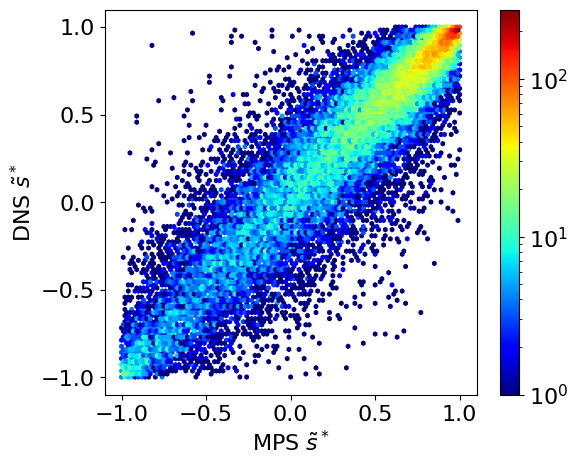

In [21]:
from save_as_mat import load_h5
s_tilde = load_h5(org_path['strain_rate']['s_tilde'])
s_tilde_comp = load_h5('Strain_rate_eigen_values_stilde_comp.h5')
# plot_scatter(s_tilde, s_tilde_comp, cutoff, title=r'$\tilde{s}^*$', label=r'$\tilde{s}^*$', 
#              file_name=f'Scatter_strain_rate_eigen_values_stilde_cf_{cutoff}'
#              , legend_flag=legend_flag, alpha=0.08)
# print("Correlation coeff for s_tilde:",np.corrcoef(s_tilde.flatten(), s_tilde_comp.flatten())[0, 1])
import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
hb = plt.hexbin(s_tilde_comp.flatten(),s_tilde.flatten(),gridsize=100,bins='log',cmap='jet')
cb = plt.colorbar(hb)
plt.ylabel(r'DNS $\tilde{s}^*$')
plt.xlabel(r'MPS $\tilde{s}^*$')
plt.savefig(f'Hexbin_strain_rate_eigen_values_stilde_cf_{cutoff}_SameLimits.png', dpi=300, bbox_inches='tight')


In [8]:
import numpy as np

print(np.corrcoef(dns, reconstructed)[0, 1])


0.9986633798172432


In [ ]:
#9_dispppp

import sys
mps_codes_path = "/ix/pgivi/moe32/Schmidt/mps_py_codes"
sys.path.append(mps_codes_path)

###########################################################################################################################

import numpy as np
from save_as_mat import load_h5
from calculate_eps_stilde import calculate_eps
from save_as_mat import save_as_h5
import json
from process_file_1024 import load_velocity_binary, load_JHS_velocity_1024_jul
from calculate_gradients import calculate_gradients
from calculate_u_comp_fidelity_l2norm import calculate_fidelity



# N = 32
# config_path = "config_FI.json"
# with open(config_path, "r") as f:
#     config = json.load(f)
# org_path = config.get("32_binary_dns", {})


N = 1024
config_path = mps_codes_path + "/config_FI.json"
with open(config_path, "r") as f:
    config = json.load(f)
org_path = config.get("full_binary_dns", {})



gradients = {}
gradients['dux_dx'] = load_h5(org_path['grad_vel']['dux_dx'])
gradients['dux_dy'] = load_h5(org_path['grad_vel']['dux_dy'])
gradients['dux_dz'] = load_h5(org_path['grad_vel']['dux_dz'])
gradients['duy_dx'] = load_h5(org_path['grad_vel']['duy_dx'])
gradients['duy_dy'] = load_h5(org_path['grad_vel']['duy_dy'])
gradients['duy_dz'] = load_h5(org_path['grad_vel']['duy_dz'])
gradients['duz_dx'] = load_h5(org_path['grad_vel']['duz_dx'])
gradients['duz_dy'] = load_h5(org_path['grad_vel']['duz_dy'])
gradients['duz_dz'] = load_h5(org_path['grad_vel']['duz_dz'])


gradients_comp = {}
gradients_comp['dux_dx'] = load_h5("grad_dux_dx_comp.h5")
gradients_comp['dux_dy'] = load_h5("grad_dux_dy_comp.h5")
gradients_comp['dux_dz'] = load_h5("grad_dux_dz_comp.h5")
gradients_comp['duy_dx'] = load_h5("grad_duy_dx_comp.h5")
gradients_comp['duy_dy'] = load_h5("grad_duy_dy_comp.h5")
gradients_comp['duy_dz'] = load_h5("grad_duy_dz_comp.h5")
gradients_comp['duz_dx'] = load_h5("grad_duz_dx_comp.h5")
gradients_comp['duz_dy'] = load_h5("grad_duz_dy_comp.h5")
gradients_comp['duz_dz'] = load_h5("grad_duz_dz_comp.h5")

nu = 0.0005
# Calculate the dissipation rates for original and compressed flow
dissipation_rate = calculate_eps(gradients, nu)
dissipation_rate_comp = calculate_eps(gradients_comp, nu)

save_as_h5('dissipation_from_grad', 'eps', dissipation_rate)
save_as_h5('dissipation_comp_from_grad', 'eps_comp', dissipation_rate_comp)

nx, ny, nz, ntime = N, N, N, 1
eps = np.sum(dissipation_rate) / (nx * ny * nz) / ntime
eps_comp = np.sum(dissipation_rate_comp) / (nx * ny * nz) / ntime


# u = load_velocity_binary(org_path['vel']['U'], N, skip_bytes=192)
# v = load_velocity_binary(org_path['vel']['V'], N)
# w = load_velocity_binary(org_path['vel']['W'], N)
# u = u-np.mean(u)
# v = v-np.mean(v)
# w = w-np.mean(w)

# dx = 2*np.pi / N
# h = (dx, dx, dx)
# order = 4
# spectral = True
# gradients_2 = calculate_gradients((u, v, w), h, order = order, spectral = spectral)
# dissipation_rate_2 = calculate_eps(gradients_2, nu)



# comp_path_u = f'truncated_U_1024_il_cf0.0001.mat'
# comp_path_v = f'truncated_V_1024_il_cf0.0001.mat'
# comp_path_w = f'truncated_W_1024_il_cf0.0001.mat'

# u_comp, chi_u = load_JHS_velocity_1024_jul(comp_path_u)
# v_comp, chi_v = load_JHS_velocity_1024_jul(comp_path_v)
# w_comp, chi_w = load_JHS_velocity_1024_jul(comp_path_w)
# u_comp = u_comp-np.mean(u_comp)
# v_comp = v_comp-np.mean(v_comp)
# w_comp = w_comp-np.mean(w_comp)

# gradients_comp_2 = calculate_gradients((u_comp, v_comp, w_comp), h, order = order, spectral = spectral)
# dissipation_rate_comp_2 = calculate_eps(gradients_comp_2, nu)

# eps_2 = np.sum(dissipation_rate_2) / (nx * ny * nz) / ntime
# eps_comp_2 = np.sum(dissipation_rate_comp_2) / (nx * ny * nz) / ntime

print(f"DNS mean eps (from gradients) : {eps}")
# print(f"DNS mean eps (from velocities): {eps_2}")
# print(f"MPS mean eps (from velocities): {eps_comp_2}")
print(f"MPS mean eps (from gradients) : {eps_comp}")
# print(f"fidelity of DNS: {calculate_fidelity(dissipation_rate, dissipation_rate_2)}")
# print(f"fidelity of MPS: {calculate_fidelity(dissipation_rate_comp, dissipation_rate_comp_2)}")

# save_as_h5('dissipation_direct_from_vel', 'eps', dissipation_rate_2)
# save_as_h5('dissipation_comp_direct_from_vel', 'eps_comp', dissipation_rate_comp_2)


Saved dissipation_from_grad.h5 successfully.
Saved dissipation_comp_from_grad.h5 successfully.
DNS mean eps (from gradients) : 0.00553672480595447
MPS mean eps (from gradients) : 0.0055947685971782955


In [15]:
import numpy as np

filename = 'rstrt.0010.bin'

with open(filename, 'rb') as f:
    header_bytes = f.read(192)

header_floats = np.frombuffer(header_bytes, dtype=np.float64)
print("Decoded Header (24 float64 values):")
for i, val in enumerate(header_floats):
    print(f"header[{i}] = {val:.16e}")


Decoded Header (24 float64 values):
header[0] = 1.2404087992193638e+224
header[1] = 1.0000000000000000e+00
header[2] = 9.9999999999999702e+01
header[3] = 1.1986456893704688e-02
header[4] = 6.7903865312370911e-313
header[5] = 6.7903865326698815e-313
header[6] = 5.3878799379977617e-315
header[7] = 0.0000000000000000e+00
header[8] = 0.0000000000000000e+00
header[9] = 0.0000000000000000e+00
header[10] = 6.2831853071795862e+00
header[11] = 6.2831853071795862e+00
header[12] = 6.2831853071795862e+00
header[13] = 8.4879831638610893e-314
header[14] = 3.0376012766403972e-152
header[15] = 6.0134700169990685e-154
header[16] = 1.1307188735114441e+277
header[17] = 6.0134700169990685e-154
header[18] = 1.1307188735114441e+277
header[19] = 6.0134700169990685e-154
header[20] = 1.1307188735114441e+277
header[21] = 6.0134700169990685e-154
header[22] = 4.7871905297015630e+180
header[23] = 6.0134700169990685e-154


In [ ]:
import os
import numpy as np

# === Configuration ===
folder = '/Users/massen/Library/CloudStorage/OneDrive-UniversityofPittsburgh/Shared with Everyone/Forced Isotropic Dataset/1024 Double'  # <<< Replace with your actual path
N = 1024
expected_data_bytes = N**3 * 8
header_bytes = 192

# Files to check
files = [
    "rstrt.0020.bin",      # likely has header
    "rstrt.0020.2.bin",    # likely no header
    "rstrt.0020.3.bin",
    "rstrt.0020.4.bin"
]

# === Processing ===
for filename in files:
    full_path = os.path.join(folder, filename)
    
    if not os.path.isfile(full_path):
        print(f"❌ File not found: {full_path}")
        continue

    size = os.path.getsize(full_path)
    diff = size - expected_data_bytes

    print(f"\n📂 {filename}")
    print(f"   Size: {size:,} bytes")
    print(f"{diff}")

    if diff == 0:
        print("   ✅ Matches expected size for 1024³ float64 — no header detected.")
    elif diff == header_bytes:
        print("   ✅ Matches expected size with 192-byte header.")
        
    #     # Optionally peek at header values
    #     with open(full_path, 'rb') as f:
    #         header = np.frombuffer(f.read(header_bytes), dtype=np.float64)
    #         print(f"   Header sample (first 4): {header[:4]}")
    # else:
    #     print(f"   ⚠️ Unexpected file size. Difference: {diff} bytes")



📂 rstrt.0020.bin
   Size: 8,589,934,784 bytes
192
   ✅ Matches expected size with 192-byte header.
   Header sample (first 4): [1.24040880e+224 1.00000000e+000 5.00000000e+000 2.12177464e-004]

📂 rstrt.0020.2.bin
   Size: 8,589,934,592 bytes
0
   ✅ Matches expected size for 1024³ float64 — no header detected.

📂 rstrt.0020.3.bin
   Size: 8,589,934,592 bytes
0
   ✅ Matches expected size for 1024³ float64 — no header detected.

📂 rstrt.0020.4.bin
   Size: 8,589,934,592 bytes
0
   ✅ Matches expected size for 1024³ float64 — no header detected.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from calculate_gradients import calculate_gradients, calculate_invariants
from save_as_mat import save_as_mat
from process_file_1024 import load_JHS_velocity_1024
from process_file import load_JHS_velocity
from plot_pdf import plot_pdf_invariants, plot_QR_joint_pdf

# org_path_u = f'../Forced_Isotropic/02 Grid 128/U_t1.mat'
# org_path_v = f'../Forced_Isotropic/02 Grid 128/V_t1.mat'
# org_path_w = f'../Forced_Isotropic/02 Grid 128/W_t1.mat'

# u = load_JHS_velocity_1024(org_path_u)
# v = load_JHS_velocity_1024(org_path_v)
# w = load_JHS_velocity_1024(org_path_w)



# org_case = 'Forced_Isotropic'
org_name = 'U_t1'
# org_path = f'../Forced_Isotropic/01 Grid 64/Forced_Isotropic_64Cubed_h5/{org_name}.h5'
org_path = f'../Forced_Isotropic/02 Grid 128/Forced_Isotropic_128Cubed_WholeDomain_h5/{org_name}.h5'
# org_path = f'../Forced_Isotropic/02 Grid 128/Forced_Isotropic_128Cubed_SubDomain_h5/{org_name}.h5'

# org_path_u = f'../Forced_Isotropic/02 Grid 128/U_t1.mat'
# org_path_v = f'../Forced_Isotropic/02 Grid 128/V_t1.mat'
# org_path_w = f'../Forced_Isotropic/02 Grid 128/w_t1.mat'

# org_path = f'../Forced_Isotropic/03 Grid 256/Forced_Isotropic_256Cubed_SubDomain_h5/{org_name}.h5'

u,v,w,xcoord,ycoord,zcoord = load_JHS_velocity(org_path)

# xcoor = 0.0061359406
xcoor = xcoord[2]-xcoord[1]
ycoor = xcoor
zcoor = xcoor
velocity_field = (u, v, w)
h = (xcoor,ycoor,zcoor)

gradients_2 = calculate_gradients(velocity_field, h, order=2)
gradients_4 = calculate_gradients(velocity_field, h, order=4)
gradients_8 = calculate_gradients(velocity_field, h, order=8)

save_as_mat('gradients_2nd_order', {'gradient': gradients_2})
save_as_mat('gradients_4th_order', {'gradient': gradients_4})
save_as_mat('gradients_8th_order', {'gradient': gradients_8})
print(" ")

# Calculate divergence, Q, and R
div_2, Q_2, R_2 = calculate_invariants(gradients_2)
div_4, Q_4, R_4 = calculate_invariants(gradients_4)
div_8, Q_8, R_8 = calculate_invariants(gradients_8)

print("Divergence shape:", div_2.shape)
print("Second Invariant (Q) shape:", Q_2.shape)
print("Third Invariant (R) shape:", R_2.shape)
print(" ")

save_as_mat('first_invariant_div_2nd_order',{'div': div_2})
save_as_mat('second_invariant_Q_2nd_order',{'Q': Q_2})
save_as_mat('third_invariant_R_2nd_order',{'R': R_2})

save_as_mat('first_invariant_div_4th_order',{'div': div_4})
save_as_mat('second_invariant_Q_4th_order',{'Q': Q_4})
save_as_mat('third_invariant_R_4th_order',{'R': R_4})

save_as_mat('first_invariant_div_8th_order',{'div': div_8})
save_as_mat('second_invariant_Q_8th_order',{'Q': Q_8})
save_as_mat('third_invariant_R_8th_order',{'R': R_8})

plot_pdf_invariants({'Div_2nd_order':div_2, 'Div_4th_order':div_4, 'Div_8th_order':div_8}, title='Divergence (First Invariant)')
plt.savefig('PDF_div_1024Cubed.png', dpi=300, bbox_inches='tight')

plot_pdf_invariants({'Q_2nd_order':Q_2, 'Q_4th_order':Q_4, 'Q_8th_order':Q_8}, title='Q (Second Invariant) ')
plt.savefig('PDF_Q_1024Cubed.png', dpi=300, bbox_inches='tight')

plot_pdf_invariants({'R_2nd_order':R_2, 'R_4th_order':R_4, 'R_8th_order':R_8}, title='R (Third Invariant)')
plt.savefig('PDF_R_1024Cubed.png', dpi=300, bbox_inches='tight')

plot_QR_joint_pdf(Q_8, R_8)
plt.savefig('PDF_QR_Joint_1024Cubed.png', dpi=300, bbox_inches='tight')


#QR

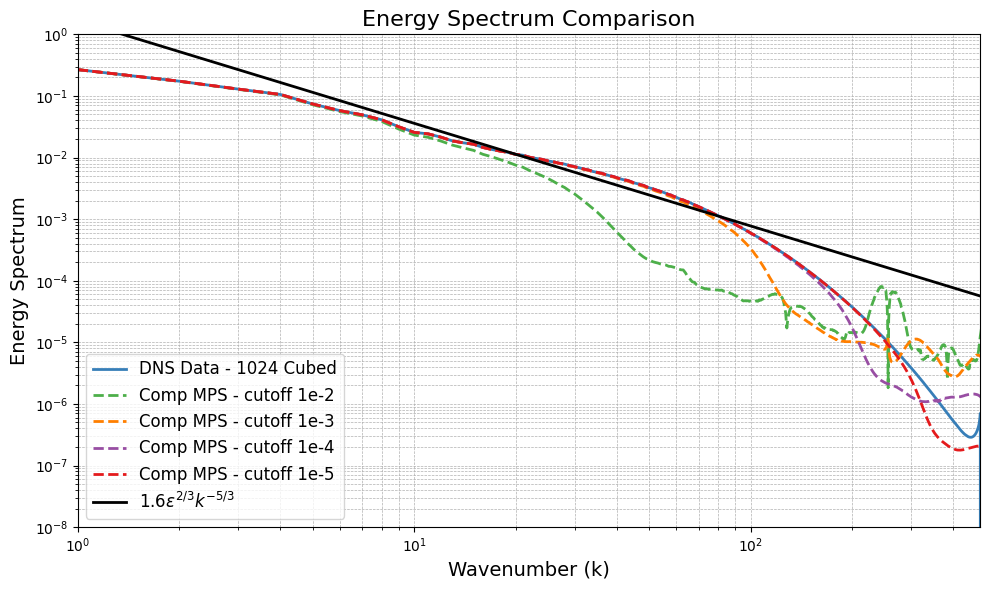

In [ ]:
#Plot energy spectrum - Daniel's data
import matplotlib.pyplot as plt
import scipy.io

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
eps = 1.0627464463977074
colors = ['#377eb8', '#4daf4a', '#ff7f00', '#984ea3', '#e41a1c']

spec_path = '../Massen_Lib/binary_daniel_32/energy_spectrum_1024/'
spec_1024 = scipy.io.loadmat(spec_path+'daniel_energy_spectrum_dns.mat')
spectrum_cf_e2 = scipy.io.loadmat(spec_path+'daniel_energy_spectrum_cf_0.01.mat')
spectrum_cf_e3 = scipy.io.loadmat(spec_path+'daniel_energy_spectrum_cf_0.001.mat')
spectrum_cf_e4 = scipy.io.loadmat(spec_path+'daniel_energy_spectrum_cf_0.0001.mat')
spectrum_cf_e5 = scipy.io.loadmat(spec_path+'daniel_energy_spectrum_cf_1e-05.mat')

# C = 1/(2*128**6)
C = 1

k_1024 = spec_1024['k'].T
spec_1024 = spec_1024['spec'].T
spectrum_cf_e2 = spectrum_cf_e2['spec_comp'].T
spectrum_cf_e3 = spectrum_cf_e3['spec_comp'].T
spectrum_cf_e4 = spectrum_cf_e4['spec_comp'].T
spectrum_cf_e5 = spectrum_cf_e5['spec_comp'].T


ax.plot(k_1024, spec_1024, label='DNS Data - 1024 Cubed', linewidth=2, color=colors[0])
ax.plot(k_1024, spectrum_cf_e2, label='Comp MPS - cutoff 1e-2', linestyle='--', linewidth=2, color=colors[1])
ax.plot(k_1024, spectrum_cf_e3, label='Comp MPS - cutoff 1e-3', linestyle='--', linewidth=2, color=colors[2])
ax.plot(k_1024, spectrum_cf_e4, label='Comp MPS - cutoff 1e-4', linestyle='--', linewidth=2, color=colors[3])
ax.plot(k_1024, spectrum_cf_e5, label='Comp MPS - cutoff 1e-5', linestyle='--', linewidth=2, color=colors[4])
ax.plot(k_1024, C*1.6*eps**(2/3) * k_1024**(-5/3), label=r'$1.6\epsilon^{2/3} k^{-5/3}$', color='black', linestyle='-', linewidth=2)

ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.set_xlabel('Wavenumber (k)', fontsize=14)
ax.set_ylabel('Energy Spectrum', fontsize=14)
ax.set_title('Energy Spectrum Comparison', fontsize=16)
ax.legend(loc='lower left', fontsize=12)

# ax.set_xlim(1, 490)
# ax.set_ylim(1e-7, 2)

#for JHS
ax.set_xlim(1, 480)
ax.set_ylim(1e-8, 1)

# ax.set_xlim(40, 482)
# ax.set_ylim(1e-8, 1e-2)

plt.tight_layout()
plt.show()


In [ ]:
# scatter velocity & velocity orientation & reynolds stress & kinetic energy

from process_file_1024 import load_JHS_velocity_1024_jul, load_JHS_velocity_1024
from plotting import plot_scatter
from calculate_flow_parameters_comb import rel_error
from calculate_orientation import calculate_unit_vectors
from save_as_mat import save_as_mat
import numpy as np

cutoff = 1e-2

org_path_u = f'../Forced_Isotropic/02 Grid 128/U_t1.mat'
org_path_v = f'../Forced_Isotropic/02 Grid 128/V_t1.mat'
org_path_w = f'../Forced_Isotropic/02 Grid 128/W_t1.mat'

comp_path_u = f'../Julia/truncated_u_il_data.mat'
comp_path_v = f'../Julia/truncated_v_il_data.mat'
comp_path_w = f'../Julia/truncated_w_il_data.mat'

u = load_JHS_velocity_1024(org_path_u)
v = load_JHS_velocity_1024(org_path_v)
w = load_JHS_velocity_1024(org_path_w)
u = u - np.mean(u)
v = v - np.mean(v)
w = w - np.mean(w)

u_comp, chi_u = load_JHS_velocity_1024_jul(comp_path_u)
v_comp, chi_v = load_JHS_velocity_1024_jul(comp_path_v)
w_comp, chi_w = load_JHS_velocity_1024_jul(comp_path_w)
u_comp = u_comp - np.mean(u_comp)
v_comp = v_comp - np.mean(v_comp)
w_comp = w_comp - np.mean(w_comp)

# u_hat, v_hat, w_hat = calculate_unit_vectors(u, v, w)
# u_comp_hat, v_comp_hat, w_comp_hat = calculate_unit_vectors(u_comp, v_comp, w_comp)

# plot_scatter(u, u_comp, title='Velocity u', label='u', file_name='Velocity_u')
# plot_scatter(v, v_comp, title='Velocity v', label='v', file_name='Velocity_v')
# plot_scatter(w, w_comp, title='Velocity w', label='w', file_name='Velocity_w')

# # plot_scatter(u_hat, u_comp_hat, title='Orientation of Velocity u', label='u hat', file_name='Orientation_of_Velocity_u')
# # plot_scatter(v_hat, v_comp_hat, title='Orientation of Velocity v', label='v hat', file_name='Orientation_of_Velocity_v')
# # plot_scatter(w_hat, w_comp_hat, title='Orientation of Velocity w', label='w hat', file_name='Orientation_of_Velocity_w')

# plot_scatter(u*u, u_comp*u_comp, title='Reynolds Stress u\'u\'', label='u\'u\'', file_name='Reynolds_Stress_uu')
# plot_scatter(v*v, v_comp*v_comp, title='Reynolds Stress v\'v\'', label='v\'v\'', file_name='Reynolds_Stress_vv')
# plot_scatter(w*w, w_comp*w_comp, title='Reynolds Stress w\'w\'', label='w\'w\'', file_name='Reynolds_Stress_ww')

# plot_scatter(u*v, u_comp*v_comp, title='Reynolds Stress u\'v\'', label='u\'v\'', file_name='Reynolds_Stress_uv')
# plot_scatter(u*w, u_comp*w_comp, title='Reynolds Stress u\'w\'', label='u\'w\'', file_name='Reynolds_Stress_uw')
# plot_scatter(v*w, v_comp*w_comp, title='Reynolds Stress v\'w\'', label='v\'w\'', file_name='Reynolds_Stress_vw')

E_k = 0.5 * (u**2 +v**2 +w**2)
E_k_comp = 0.5 * (u_comp**2 +v_comp**2 +w_comp**2)
plot_scatter(E_k, E_k_comp, title='Kinetic Energy', label=r'$E_{k}$', file_name='Kinetic Energy')

## mean_rs[_][0] = truth, mean_rs[_][1] = comp, mean_rs[_][2] = rel_error
mean_rs = {'uu': [0, 0, 0], 'vv': [0, 0, 0], 'ww': [0, 0, 0], 'uv': [0, 0, 0], 'uw': [0, 0, 0], 'vw': [0, 0, 0]}
mean_rs['uu'][0]= np.mean(u*u)
mean_rs['uu'][1]= np.mean(u_comp*u_comp)
mean_rs['uu'][2]= rel_error(mean_rs['uu'][0], mean_rs['uu'][1])

mean_rs['vv'][0]= np.mean(v*v)
mean_rs['vv'][1]= np.mean(v_comp*v_comp)
mean_rs['vv'][2]= rel_error(mean_rs['vv'][0], mean_rs['vv'][1])

mean_rs['ww'][0]= np.mean(w*w)
mean_rs['ww'][1]= np.mean(w_comp*w_comp)
mean_rs['ww'][2]= rel_error(mean_rs['ww'][0], mean_rs['ww'][1])

mean_rs['uv'][0]= np.mean(u*v)
mean_rs['uv'][1]= np.mean(u_comp*v_comp)
mean_rs['uv'][2]= rel_error(mean_rs['uv'][0], mean_rs['uv'][1])

mean_rs['uw'][0]= np.mean(u*w)
mean_rs['uw'][1]= np.mean(u_comp*w_comp)
mean_rs['uw'][2]= rel_error(mean_rs['uw'][0], mean_rs['uw'][1])

mean_rs['vw'][0]= np.mean(v*w)
mean_rs['vw'][1]= np.mean(v_comp*w_comp)
mean_rs['vw'][2]= rel_error(mean_rs['vw'][0], mean_rs['vw'][1])

print('mean u\'u\': ',mean_rs['uu'])
print('mean v\'v\': ',mean_rs['vv'])
print('mean w\'w\': ',mean_rs['ww'])
print('mean u\'v\': ',mean_rs['uv'])
print('mean u\'w\': ',mean_rs['uw'])
print('mean v\'w\': ',mean_rs['vw'])

save_as_mat('mean_reynolds_stress', {'mean_rs': mean_rs})


In [ ]:
#Angle detection

import numpy as np
import matplotlib.pyplot as plt

# --------------------------
# 1) Generate synthetic data
# --------------------------
N = 20
np.random.seed(0)

# Separate arrays for the velocity components: u_x, u_y, u_z
u_x = np.random.randn(N, N, N)
u_y = np.random.randn(N, N, N)
u_z = np.random.randn(N, N, N)

# Create "compressed" versions: add noise + scale
noise_factor = 0.1
u_x_comp = u_x + noise_factor * np.random.randn(N, N, N)
u_y_comp = u_y + noise_factor * np.random.randn(N, N, N)
u_z_comp = u_z + noise_factor * np.random.randn(N, N, N)

# ---------------------------------
# 2) Compute the norms (magnitudes)
# ---------------------------------
epsilon = 1e-12

# Norm of the original velocity
u_norm = np.sqrt(u_x**2 + u_y**2 + u_z**2)

# Norm of the compressed velocity
u_comp_norm = np.sqrt(u_x_comp**2 + u_y_comp**2 + u_z_comp**2)

# --------------------------
# 3) Unit vectors (directions)
# --------------------------
# We'll avoid dividing by zero by using np.divide(..., where=...).
u_x_hat = np.divide(u_x, u_norm, out=np.zeros_like(u_x), where=(u_norm > epsilon))
u_y_hat = np.divide(u_y, u_norm, out=np.zeros_like(u_y), where=(u_norm > epsilon))
u_z_hat = np.divide(u_z, u_norm, out=np.zeros_like(u_z), where=(u_norm > epsilon))

u_x_comp_hat = np.divide(u_x_comp, u_comp_norm, out=np.zeros_like(u_x_comp), where=(u_comp_norm > epsilon))
u_y_comp_hat = np.divide(u_y_comp, u_comp_norm, out=np.zeros_like(u_y_comp), where=(u_comp_norm > epsilon))
u_z_comp_hat = np.divide(u_z_comp, u_comp_norm, out=np.zeros_like(u_z_comp), where=(u_comp_norm > epsilon))

# ------------------------------------------------
# 4) Dot product of unit vectors => cos(theta)
# ------------------------------------------------
dot_product = (u_x_hat * u_x_comp_hat +
               u_y_hat * u_y_comp_hat +
               u_z_hat * u_z_comp_hat)

# Clip to [-1, 1] range to avoid floating-point errors
dot_product_clipped = np.clip(dot_product, -1.0, 1.0)

# theta in radians
theta = np.arccos(dot_product_clipped)

# Convert to degrees
theta_degrees = np.degrees(theta)

# ----------------------------------------------------
# 5) Calculate statistics & plot histogram of the angle
# ----------------------------------------------------
mean_angle_deg =   np.mean(theta_degrees)
median_angle_deg = np.median(theta_degrees)
std_angle_deg =    np.std(theta_degrees)

print(f"Mean angle difference (degrees):   {mean_angle_deg:.2f}")
print(f"Median angle difference (degrees): {median_angle_deg:.2f}")
print(f"Std dev of angles (degrees):       {std_angle_deg:.2f}")

# Flatten the 3D array for plotting
theta_degrees_flat = theta_degrees.flatten()

plt.figure(figsize=(7,5))
plt.hist(theta_degrees_flat, bins=40, color='royalblue', alpha=0.8, edgecolor='black')
plt.xlabel('Angle Difference (degrees)')
plt.ylabel('Frequency')
plt.title('Distribution of Directional Differences between u and u_comp')
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
#skewness

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew

# Generate synthetic isotropic turbulence velocity field (N x N x N)
np.random.seed(42)
N = 64  # Grid size
u = np.random.normal(0, 1, (N, N, N))  # Random velocity field

# Compute longitudinal velocity gradient ∂u/∂x using central differences
du_dx = np.zeros_like(u)
du_dx[1:-1, :, :] = (u[2:, :, :] - u[:-2, :, :]) / 2  # Central difference
du_dx[0, :, :] = (u[1, :, :] - u[0, :, :])  # Forward difference at boundary
du_dx[-1, :, :] = (u[-1, :, :] - u[-2, :, :])  # Backward difference at boundary

# Flatten 3D arrays for binning
u_flat = u.flatten()
du_dx_flat = du_dx.flatten()

# Define velocity bins
num_bins = 30
velocity_bins = np.linspace(np.min(u_flat), np.max(u_flat), num_bins)
bin_centers = 0.5 * (velocity_bins[:-1] + velocity_bins[1:])
skewness_values = []

# Compute skewness of velocity gradient within each velocity bin
for i in range(len(velocity_bins) - 1):
    bin_mask = (u_flat >= velocity_bins[i]) & (u_flat < velocity_bins[i+1])
    du_dx_bin = du_dx_flat[bin_mask]
    if len(du_dx_bin) > 10:  # Avoid small sample noise
        skewness_values.append(skew(du_dx_bin))
    else:
        skewness_values.append(np.nan)

# Plot Skewness of Velocity Gradient vs. Velocity
plt.figure(figsize=(8, 5))
plt.plot(bin_centers, skewness_values, marker='o', linestyle='-')
plt.axhline(-0.5, color='r', linestyle='--', label='Expected Skewness (~-0.5)')
plt.xlabel("Velocity $u$")
plt.ylabel("Skewness of $\\partial u / \\partial x$")
plt.title("Skewness of Velocity Gradient vs. Velocity")
plt.legend()
plt.grid()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from calculate_gradients import calculate_gradients, calculate_invariants
from save_as_mat import save_as_h5
from process_file_1024 import load_JHS_velocity_1024
from process_file import load_JHS_velocity
from plotting import plot_pdf_invariants, plot_QR_joint_pdf

# org_name = 'U_t1'
# # org_path = f'../Forced_Isotropic/01 Grid 64/Forced_Isotropic_64Cubed_h5/{org_name}.h5'
# org_path = f'../Forced_Isotropic/02 Grid 128/Forced_Isotropic_128Cubed_WholeDomain_h5/{org_name}.h5'
# # org_path = f'../Forced_Isotropic/02 Grid 128/Forced_Isotropic_128Cubed_SubDomain_h5/{org_name}.h5'

# # org_path_u = f'../Forced_Isotropic/02 Grid 128/U_t1.mat'
# # org_path_v = f'../Forced_Isotropic/02 Grid 128/V_t1.mat'
# # org_path_w = f'../Forced_Isotropic/02 Grid 128/w_t1.mat'

# # org_path = f'../Forced_Isotropic/03 Grid 256/Forced_Isotropic_256Cubed_SubDomain_h5/{org_name}.h5'

# u,v,w,xcoord,ycoord,zcoord = load_JHS_velocity(org_path)


org_path_u = f'../Forced_Isotropic/02 Grid 128/U_t1.mat'
org_path_v = f'../Forced_Isotropic/02 Grid 128/V_t1.mat'
org_path_w = f'../Forced_Isotropic/02 Grid 128/W_t1.mat'

u = load_JHS_velocity_1024(org_path_u)
v = load_JHS_velocity_1024(org_path_v)
w = load_JHS_velocity_1024(org_path_w)

order = 8

xcoor = 0.0061359406
# xcoor = xcoord[2]-xcoord[1]
ycoor = xcoor
zcoor = xcoor
velocity_field = (u, v, w)
h = (xcoor,ycoor,zcoor)

# gradients = calculate_gradients(velocity_field, h, order=order)
gradients = calculate_gradients(velocity_field, h)


save_as_h5('grad_dux_dx', 'dux_dx', gradients['dux_dx'])
save_as_h5('grad_dux_dy', 'dux_dy', gradients['dux_dy'])
save_as_h5('grad_dux_dz', 'dux_dz', gradients['dux_dz'])
save_as_h5('grad_duy_dx', 'duy_dx', gradients['duy_dx'])
save_as_h5('grad_duy_dy', 'duy_dy', gradients['duy_dy'])
save_as_h5('grad_duy_dz', 'duy_dz', gradients['duy_dz'])
save_as_h5('grad_duz_dx', 'duz_dx', gradients['duz_dx'])
save_as_h5('grad_duz_dy', 'duz_dy', gradients['duz_dy'])
save_as_h5('grad_duz_dz', 'duz_dz', gradients['duz_dz'])
print(" ")

M = np.array([[gradients['dux_dx'], gradients['dux_dy'], gradients['dux_dz']],
            [gradients['duy_dx'], gradients['duy_dy'], gradients['duy_dz']],
            [gradients['duz_dx'], gradients['duz_dy'], gradients['duz_dz']]])

M = np.transpose(M, (2, 3, 4, 0, 1))  # Rearrange dimensions

# Calculate divergence, Q, and R
div, Q, R = calculate_invariants(M)
Qw_comp = compute_W_norm_3D(M)
# div_sp, Q_sp, R_sp = calculate_invariants(gradients)

print("Divergence shape:", div.shape)
print("Second Invariant (Q) shape:", Q.shape)
print("Third Invariant (R) shape:", R.shape)
print(" ")

# save_as_h5('first_invariant_div_2nd_order','div', div)
# save_as_h5('second_invariant_Q_2nd_order','Q', Q)
# save_as_h5('third_invariant_R_2nd_order','R', R)

# # plot_pdf_invariants({'Div_FD':div, 'Div_sp':div_sp}, title='Divergence (First Invariant)')
# plot_pdf_invariants({'Div':div}, title='Divergence (First Invariant)')
# # plt.savefig('PDF_div_1024Cubed.png', dpi=300, bbox_inches='tight')

# # plot_pdf_invariants({'Q_FD':Q, 'Q_sp':Q_sp}, title='Q (Second Invariant) ')
# plot_pdf_invariants({'Q_FD':Q}, title='Q (Second Invariant) ')
# # plt.savefig('PDF_Q_1024Cubed.png', dpi=300, bbox_inches='tight')

# plot_pdf_invariants({'R_FD':R}, title='R (Third Invariant)')
# # plt.savefig('PDF_R_1024Cubed.png', dpi=300, bbox_inches='tight')

plot_QR_joint_pdf(Q, R, Qw_comp, contour_levels=5, percentile_threshold=95)
# plot_QR_joint_pdf(Q_sp, R_sp, contour_levels=5, percentile_threshold=90)
plt.savefig('PDF_QR_Joint_1024Cubed_2nd_order.png', dpi=300, bbox_inches='tight')


In [ ]:
import numpy as np
from calculate_eps_stilda import calculate_eps_stilda
from calculate_gradients import calculate_gradients_spectral
from process_file_1024 import load_JHS_velocity_1024

org_path_u = f'../Forced_Isotropic/02 Grid 128/U_t1.mat'
org_path_v = f'../Forced_Isotropic/02 Grid 128/V_t1.mat'
org_path_w = f'../Forced_Isotropic/02 Grid 128/W_t1.mat'

u = load_JHS_velocity_1024(org_path_u)
v = load_JHS_velocity_1024(org_path_v)
w = load_JHS_velocity_1024(org_path_w)

xcoor = 0.0061359406
# xcoor = xcoord[2]-xcoord[1]
ycoor = xcoor
zcoor = xcoor
# velocity_field = (u, v, w)
h = (xcoor,ycoor,zcoor)

# gradients = calculate_gradients(velocity_field, h, order=order)
gradients = calculate_gradients_spectral((u, v, w), h)

# Compute s_tilda
eps, s_tilda_field = calculate_eps_stilda(gradients)

print("Shape of s_tilda_field:", s_tilda_field.shape)  # should be (N, N, N)


In [7]:
#Daniel QR

import torch
import matplotlib.pyplot as plt
import h5py
import numpy as np
from plotting import plot_pdf_invariants, plot_QR_joint_pdf
from calculate_gradients import calculate_gradients, calculate_invariants, calculate_gradients_spectral
from save_as_mat import save_as_h5


def compute_W_norm_3D(A):
    """
    Computes Qw (mean vorticity norm) for a 3D velocity gradient tensor.

    Parameters:
    A (numpy.ndarray): Velocity gradient tensor of shape (N, N, N, 3, 3).

    Returns:
    float: Scalar value representing Qw.
    """
    # Compute the antisymmetric part (vorticity tensor W_ij)
    W = 0.5 * (A - np.transpose(A, axes=(0,1,2,4,3)))

    # Compute W_ij W_ij (Frobenius norm squared)
    # W_squared = np.einsum("...ij,...ij->...", W, W)
    # W_squared = np.sum(W.numpy() * W.numpy(), axis=(-2, -1))
    W_squared = np.sum(W* W, axis=(-2, -1))

    # Compute Qw = (1/2) * mean(W_ij W_ij)
    # Qw = 0.5 * np.mean(W_squared)
    Qw = np.sqrt(np.mean(W_squared))

    return Qw

def load_h5_file(file_name):
    with h5py.File(file_name, "r") as h5file:
        dataset_name = list(h5file.keys())[0]
        data = h5file[dataset_name][()]  
    return data

grad_dux_dx = load_h5_file("grad_dux_dx.h5")
grad_dux_dy = load_h5_file("grad_dux_dy.h5")
grad_dux_dz = load_h5_file("grad_dux_dz.h5")
grad_duy_dx = load_h5_file("grad_duy_dx.h5")
grad_duy_dy = load_h5_file("grad_duy_dy.h5")
grad_duy_dz = load_h5_file("grad_duy_dz.h5")
grad_duz_dx = load_h5_file("grad_duz_dx.h5")
grad_duz_dy = load_h5_file("grad_duz_dy.h5")
grad_duz_dz = load_h5_file("grad_duz_dz.h5")
# div = load_h5_file("first_invariant_div_order.h5")
# Q = load_h5_file("second_invariant_Q_order.h5")
# R = load_h5_file("third_invariant_R_order.h5")

grad = np.array([[grad_dux_dx, grad_dux_dy, grad_dux_dz],
                 [grad_duy_dx, grad_duy_dy, grad_duy_dz],
                 [grad_duz_dx, grad_duz_dy, grad_duz_dz]])

grad = np.transpose(grad, (2, 3, 4, 0, 1))  # Rearrange dimensions

w_norm = 15.756560377380076
# Convert NumPy grad (N, N, N, 3, 3) to PyTorch
grad_torch = torch.tensor(grad, dtype=torch.float32)  # Ensure dtype is correct

# Compute Q and R from friend's function
Q_torch = -0.5 * torch.einsum('...ij,...ji', grad_torch, grad_torch) / (w_norm**2)
R_torch = -(1/3) * torch.einsum('...ij,...jk,...ki', grad_torch, grad_torch, grad_torch) / (w_norm**3)

# Convert PyTorch tensors to NumPy for comparison
Q_torch_np = Q_torch.numpy()
R_torch_np = R_torch.numpy()

# div, Q, R = calculate_invariants(grad)
# w_norm = compute_W_norm_3D(grad)
print(Q_torch_np.shape)
print(R_torch_np.shape)
# print(w_norm)


save_as_h5('second_invariant_Q_dani','Q', Q_torch_np)
save_as_h5('third_invariant_R_dani','R', R_torch_np)


# plot_QR_joint_pdf(Q, R, w_norm, contour_levels=5, percentile_threshold=90)
plot_QR_joint_pdf(Q_torch_np, R_torch_np, 1, contour_levels=5, percentile_threshold=90)
# plot_QR_joint_pdf(Q_sp, R_sp, contour_levels=5, percentile_threshold=90)
# plt.savefig('PDF_QR_Joint_1024Cubed_spectral_dani.png', dpi=300, bbox_inches='tight')

ImportError: cannot import name 'plot_pdf_invariants' from 'plotting' (/Users/massen/Desktop/Johns Hopkins Turbulence Database/Schmidt/Nik_code/code/AnalysingResultsFromDNS_demo/ComputationalSpaces/Massen_Lib/plotting.py)

In [ ]:
#Joint PDF plot

import matplotlib.pyplot as plt
import numpy as np
from plotting import plot_QR_joint_pdf
from calculate_gradients import calculate_invariants, compute_Qw
from save_as_mat import save_as_h5, load_h5
from plotting import plot_pdf
import json

config_path = mps_codes_path + "/config_FI.json"
with open(config_path, "r") as f:
    config = json.load(f)

org_path = config.get("full_dns", {})
div = load_h5(org_path['invars']['div'])
Q = load_h5(org_path['invars']['Q'])
R = load_h5(org_path['invars']['R'])
Qw = 15.756560377380076

cutoff = 1e-3
grad_dux_dx = load_h5("grad_dux_dx.h5")
grad_dux_dy = load_h5("grad_dux_dy.h5")
grad_dux_dz = load_h5("grad_dux_dz.h5")
grad_duy_dx = load_h5("grad_duy_dx.h5")
grad_duy_dy = load_h5("grad_duy_dy.h5")
grad_duy_dz = load_h5("grad_duy_dz.h5")
grad_duz_dx = load_h5("grad_duz_dx.h5")
grad_duz_dy = load_h5("grad_duz_dy.h5")
grad_duz_dz = load_h5("grad_duz_dz.h5")

grad = np.array([[grad_dux_dx, grad_dux_dy, grad_dux_dz],
                 [grad_duy_dx, grad_duy_dy, grad_duy_dz],
                 [grad_duz_dx, grad_duz_dy, grad_duz_dz]])

grad = np.transpose(grad, (2, 3, 4, 0, 1))  # Rearrange dimensions


div_comp, Q_comp, R_comp = calculate_invariants(grad)
Qw_comp = compute_Qw(grad)
print(Q_comp.shape)
print(R_comp.shape)

# div = div_comp*0.8
# Q = Q_comp.copy()*2.2
# R = R_comp.copy()*2.2
# Qw = Qw_comp*1.02

print("Qw: ", Qw, "\tQw_comp: ", Qw_comp)

save_as_h5('first_invariant_div_spectral','div', div_comp)
save_as_h5('second_invariant_Q_spectral','Q', Q_comp)
save_as_h5('third_invariant_R_spectral','R', R_comp)


plot_pdf({'DNS':div, f'Comp cutoff {cutoff}':div_comp}, title='Divergence (First Invariant)',
         file_name='div_1024Cubed_spectral', norm_dist=True, pdf_min=1e-4, pdf_max=1)

plot_QR_joint_pdf(Q_comp, R_comp, Qw_comp, cutoff=cutoff)

plot_QR_joint_pdf(Q, R, Qw, Q_comp, R_comp, Qw_comp, cutoff=cutoff, colormesh=False)


H_max =  2.9552077057936468
H_min =  1.001e-05


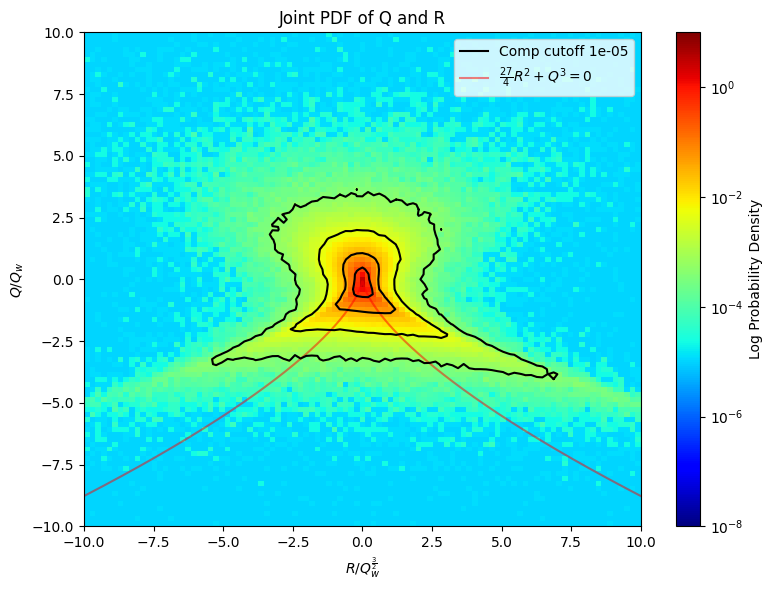

In [ ]:
#Joint PDF plot QR

import matplotlib.pyplot as plt
import numpy as np
from plotting import plot_QR_joint_pdf
from calculate_gradients import calculate_invariants, compute_Qw
from save_as_mat import save_as_h5, load_h5
from plotting import plot_pdf
# import json

# config_path = mps_codes_path + "/config_FI.json"
# with open(config_path, "r") as f:
#     config = json.load(f)

# org_path = config.get("full_dns", {})
# div = load_h5(org_path['invars']['div'])
# Q = load_h5(org_path['invars']['Q'])
# R = load_h5(org_path['invars']['R'])
# Qw = 15.756560377380076

cutoff = 1e-5
# grad_dux_dx = load_h5("grad_dux_dx.h5")
# grad_dux_dy = load_h5("grad_dux_dy.h5")
# grad_dux_dz = load_h5("grad_dux_dz.h5")
# grad_duy_dx = load_h5("grad_duy_dx.h5")
# grad_duy_dy = load_h5("grad_duy_dy.h5")
# grad_duy_dz = load_h5("grad_duy_dz.h5")
# grad_duz_dx = load_h5("grad_duz_dx.h5")
# grad_duz_dy = load_h5("grad_duz_dy.h5")
# grad_duz_dz = load_h5("grad_duz_dz.h5")

# grad = np.array([[grad_dux_dx, grad_dux_dy, grad_dux_dz],
#                  [grad_duy_dx, grad_duy_dy, grad_duy_dz],
#                  [grad_duz_dx, grad_duz_dy, grad_duz_dz]])

# grad = np.transpose(grad, (2, 3, 4, 0, 1))  # Rearrange dimensions


div_comp, Q_comp, R_comp = calculate_invariants(grad)
Qw_comp = compute_Qw(grad)
print(Q_comp.shape)
print(R_comp.shape)


# print("Qw: ", Qw, "\tQw_comp: ", Qw_comp)

# save_as_h5('first_invariant_div_spectral','div', div_comp)
# save_as_h5('second_invariant_Q_spectral','Q', Q_comp)
# save_as_h5('third_invariant_R_spectral','R', R_comp)

# Q_comp = load_h5("second_invariant_Q_spectral.h5")
# R_comp = load_h5("third_invariant_R_spectral.h5")
# Qw_comp = 3.5

plot_pdf({'DNS':div, f'Comp cutoff {cutoff}':div_comp}, title='Divergence (First Invariant)',
         file_name='div_1024Cubed_spectral', norm_dist=True, pdf_min=1e-4, pdf_max=1)

# plot_QR_joint_pdf(Q_comp, R_comp, Qw_comp, cutoff=cutoff)

# plot_QR_joint_pdf(Q, R, Qw, Q_comp, R_comp, Qw_comp, cutoff=cutoff, colormesh=False)

(128, 128, 128)
(128, 128, 128)
Saved second_invariant_Q_spectral_exact.h5 successfully.
Saved third_invariant_R_spectral_exact.h5 successfully.
H_max =  3.2665550889175323
H_min =  1e-08


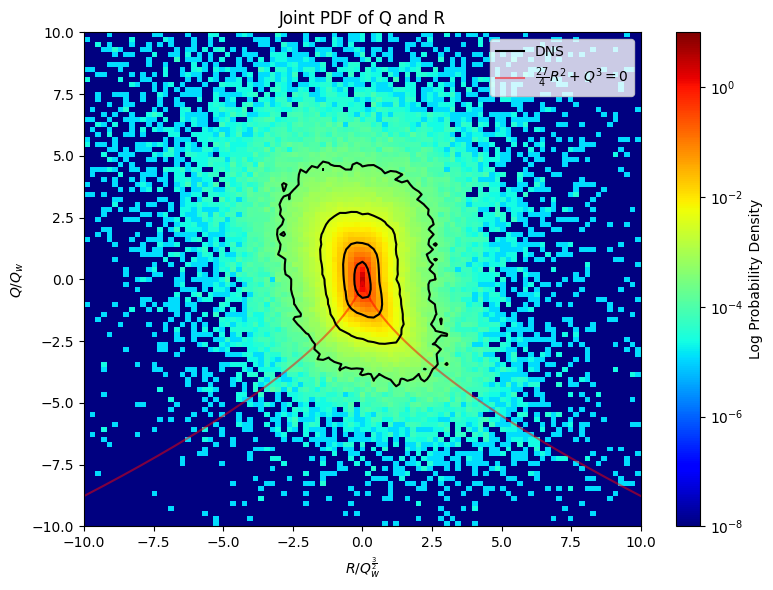

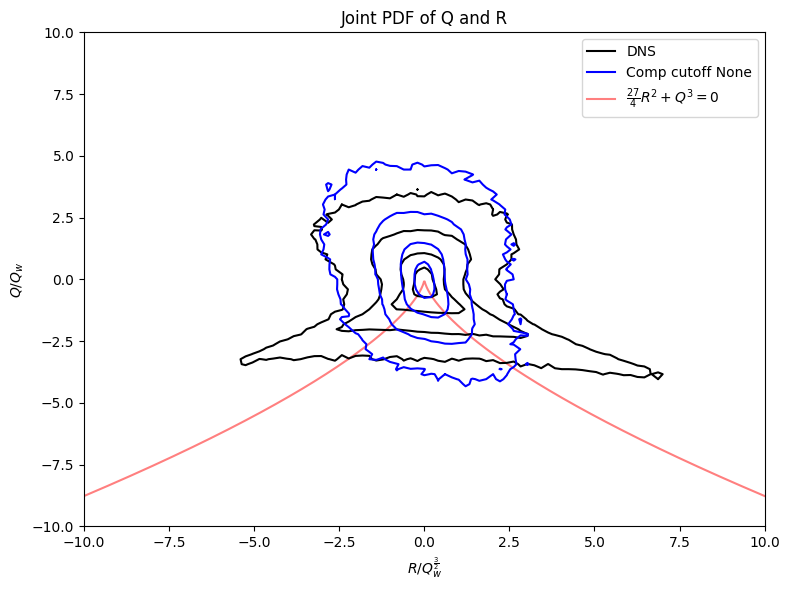

In [ ]:
#Joint PDF plot QRexact

import matplotlib.pyplot as plt
import numpy as np
from plotting import plot_QR_joint_pdf
from calculate_gradients import calculate_invariants_exact, compute_Qw
from save_as_mat import save_as_h5, load_h5
from plotting import plot_pdf
import json

config_path = mps_codes_path + "/config_FI.json"
with open(config_path, "r") as f:
    config = json.load(f)

org_path = config.get("full_dns", {})
# div = load_h5(org_path['invars']['div'])
Q = load_h5(org_path['invars']['Q'])
R = load_h5(org_path['invars']['R'])
Qw = 15.756560377380076
# Qw = 3.5

# grad_dux_dx = load_h5("grad_dux_dx.h5")
# grad_dux_dy = load_h5("grad_dux_dy.h5")
# grad_dux_dz = load_h5("grad_dux_dz.h5")
# grad_duy_dx = load_h5("grad_duy_dx.h5")
# grad_duy_dy = load_h5("grad_duy_dy.h5")
# grad_duy_dz = load_h5("grad_duy_dz.h5")
# grad_duz_dx = load_h5("grad_duz_dx.h5")
# grad_duz_dy = load_h5("grad_duz_dy.h5")
# grad_duz_dz = load_h5("grad_duz_dz.h5")

grad_dux_dx = load_h5(org_path['grad_vel']['dux_dx'])
grad_dux_dy = load_h5(org_path['grad_vel']['dux_dy'])
grad_dux_dz = load_h5(org_path['grad_vel']['dux_dz'])
grad_duy_dx = load_h5(org_path['grad_vel']['duy_dx'])
grad_duy_dy = load_h5(org_path['grad_vel']['duy_dy'])
grad_duy_dz = load_h5(org_path['grad_vel']['duy_dz'])
grad_duz_dx = load_h5(org_path['grad_vel']['duz_dx'])
grad_duz_dy = load_h5(org_path['grad_vel']['duz_dy'])
grad_duz_dz = load_h5(org_path['grad_vel']['duz_dz'])

grad = np.array([[grad_dux_dx, grad_dux_dy, grad_dux_dz],
                 [grad_duy_dx, grad_duy_dy, grad_duy_dz],
                 [grad_duz_dx, grad_duz_dy, grad_duz_dz]])

grad = np.transpose(grad, (2, 3, 4, 0, 1))  # Rearrange dimensions


_, Q_exact, R_exact = calculate_invariants_exact(grad)
# Qw_exact = compute_Qw(grad)
print(Q_exact.shape)
print(R_exact.shape)

# div = div_comp*0.8
# Q = Q_comp.copy()*2.2
# R = R_comp.copy()*2.2
# Qw = Qw_comp*1.02

# Q = load_h5("second_invariant_Q_spectral.h5")
# R = load_h5("third_invariant_R_spectral.h5")


save_as_h5('second_invariant_Q_spectral_exact','Q', Q_exact)
save_as_h5('third_invariant_R_spectral_exact','R', R_exact)


# plot_pdf({'DNS':div, f'Comp cutoff {cutoff}':div_comp}, title='Divergence (First Invariant)',
#          file_name='div_1024Cubed_spectral', norm_dist=True, pdf_min=1e-4, pdf_max=1)

plot_QR_joint_pdf(Q_exact, R_exact, Qw)

plot_QR_joint_pdf(Q, R, Qw, Q_exact, R_exact, Qw, colormesh=False)


In [ ]:
import sys
mps_codes_path = "/ix/pgivi/moe32/Schmidt/Nik_code/code/AnalysingResultsFromDNS_demo/ComputationalSpaces/mps_py_codes"
sys.path.append(mps_codes_path)

###########################################################################################################################

#Joint PDF plot

import matplotlib.pyplot as plt
import numpy as np
from plotting import plot_QR_joint_pdf
from calculate_gradients import calculate_invariants, calculate_invariants_exact, compute_Qw
from save_as_mat import save_as_h5, load_h5
from plotting import plot_pdf
import json

config_path = mps_codes_path + "/config_FI.json"
with open(config_path, "r") as f:
    config = json.load(f)

org_path = config.get("full_dns", {})
# div = load_h5(org_path['invars']['div'])
Q = load_h5(org_path['invars']['Q'])
R = load_h5(org_path['invars']['R'])
Qw = 15.756560377380076

cutoff = 1e-2
grad_dux_dx = load_h5("grad_dux_dx.h5")
grad_dux_dy = load_h5("grad_dux_dy.h5")
grad_dux_dz = load_h5("grad_dux_dz.h5")
grad_duy_dx = load_h5("grad_duy_dx.h5")
grad_duy_dy = load_h5("grad_duy_dy.h5")
grad_duy_dz = load_h5("grad_duy_dz.h5")
grad_duz_dx = load_h5("grad_duz_dx.h5")
grad_duz_dy = load_h5("grad_duz_dy.h5")
grad_duz_dz = load_h5("grad_duz_dz.h5")

grad = np.array([[grad_dux_dx, grad_dux_dy, grad_dux_dz],
                 [grad_duy_dx, grad_duy_dy, grad_duy_dz],
                 [grad_duz_dx, grad_duz_dy, grad_duz_dz]])

grad = np.transpose(grad, (2, 3, 4, 0, 1))  # Rearrange dimensions


# div_comp, Q_comp, R_comp = calculate_invariants(grad)
div_comp, Q_comp, R_comp = calculate_invariants_exact(grad)
# Qw_comp = compute_Qw(grad)
print(Q_comp.shape)
print(R_comp.shape)


# print("Qw: ", Qw, "\tQw_comp: ", Qw_comp)

# save_as_h5('first_invariant_div_spectral','div', div_comp)
save_as_h5('second_invariant_Q_spectral_exact','Q', Q_comp)
save_as_h5('third_invariant_R_spectral_exact','R', R_comp)

# Q_comp = load_h5("second_invariant_Q_spectral.h5")
# R_comp = load_h5("third_invariant_R_spectral.h5")
Qw_comp = 9.171738021735438

# plot_pdf({'DNS':div, f'Comp cutoff {cutoff}':div_comp}, title='Divergence (First Invariant)',
#          file_name='div_1024Cubed_spectral', norm_dist=True, pdf_min=1e-4, pdf_max=1)

plot_QR_joint_pdf(Q_comp, R_comp, Qw_comp, cutoff=cutoff)

plot_QR_joint_pdf(Q, R, Qw, Q_comp, R_comp, Qw_comp, cutoff=cutoff, colormesh=False)

In [ ]:
import json

config_path = mps_codes_path + "/config_FI.json"
config_path = "config_FI.json"
with open(config_path, "r") as f:
    config = json.load(f)

org_path = config.get("128_dns", {})
du_dx = load_h5(org_path['invars']['Q'])


In [ ]:
#PDF of Gradients

import numpy as np
from save_as_mat import load_h5
from plotting import plot_pdf
import json
config_path = mps_codes_path + "/config_FI.json"
with open(config_path, "r") as f:
    config = json.load(f)

org_path = config.get("full_dns", {})

cutoff = 1e-4
# grad_dux_dx_comp = load_h5("grad_dux_dx_spectral.mat",2)
# grad_dux_dy_comp = load_h5("grad_dux_dy_spectral.mat",2)
grad_dux_dz_comp = load_h5("grad_dux_dz_spectral.mat",2)
grad_duy_dx_comp = load_h5("grad_duy_dx_spectral.mat",2)
grad_duy_dy_comp = load_h5("grad_duy_dy_spectral.mat",2)
grad_duy_dz_comp = load_h5("grad_duy_dz_spectral.mat",2)
grad_duz_dx_comp = load_h5("grad_duz_dx_spectral.mat",2)
grad_duz_dy_comp = load_h5("grad_duz_dy_spectral.mat",2)
grad_duz_dz_comp = load_h5("grad_duz_dz_spectral.mat",2)


# grad_dux_dx = load_h5(org_path['grad_vel']['dux_dx'])
# grad_dux_dy = load_h5(org_path['grad_vel']['dux_dy'])
grad_dux_dz = load_h5(org_path['grad_vel']['dux_dz'])
grad_duy_dx = load_h5(org_path['grad_vel']['duy_dx'])
grad_duy_dy = load_h5(org_path['grad_vel']['duy_dy'])
grad_duy_dz = load_h5(org_path['grad_vel']['duy_dz'])
grad_duz_dx = load_h5(org_path['grad_vel']['duz_dx'])
grad_duz_dy = load_h5(org_path['grad_vel']['duz_dy'])
grad_duz_dz = load_h5(org_path['grad_vel']['duz_dz'])


# grad_dux_dx = grad_dux_dx_comp*0.9
# grad_dux_dy = grad_dux_dy_comp*0.9
# grad_dux_dz = grad_dux_dz_comp*0.9
# grad_duy_dx = grad_duy_dx_comp*0.9
# grad_duy_dy = grad_duy_dy_comp*0.9
# grad_duy_dz = grad_duy_dz_comp*0.9
# grad_duz_dx = grad_duz_dx_comp*0.9
# grad_duz_dy = grad_duz_dy_comp*0.9
# grad_duz_dz = grad_duz_dz_comp*0.9

pdf_min = 1e-10
pdf_max = 1
x_max = 300
x_min = -x_max

# plot_pdf({'DNS':grad_dux_dx, f'Comp cutoff {cutoff}':grad_dux_dx_comp}, 
#          title=r'$\partial u / \partial x$', file_name='grad_dux_dx_SameLimits', 
#          pdf_min=pdf_min, pdf_max=pdf_max, x_min=x_min, x_max=x_max, gen_norm_dist=False)

plot_pdf({'DNS':grad_duy_dy, f'Comp cutoff {cutoff}':grad_duy_dy_comp}, 
         title=r'$\partial v / \partial y$', file_name='grad_duy_dy_SameLimits', 
         pdf_min=pdf_min, pdf_max=pdf_max, x_min=x_min, x_max=x_max, gen_norm_dist=False)

plot_pdf({'DNS':grad_duz_dz, f'Comp cutoff {cutoff}':grad_duz_dz_comp}, 
         title=r'$\partial w / \partial z$', file_name='grad_duz_dz_SameLimits', 
         pdf_min=pdf_min, pdf_max=pdf_max, x_min=x_min, x_max=x_max, gen_norm_dist=False)

# plot_pdf({'DNS':grad_dux_dy, f'Comp cutoff {cutoff}':grad_dux_dy_comp}, 
#          title=r'$\partial u / \partial y$', file_name='grad_dux_dy_SameLimits', 
#          pdf_min=pdf_min, pdf_max=pdf_max, x_min=x_min, x_max=x_max, gen_norm_dist=False)

plot_pdf({'DNS':grad_dux_dz, f'Comp cutoff {cutoff}':grad_dux_dz_comp}, 
         title=r'$\partial u / \partial z$', file_name='grad_dux_dz_SameLimits', 
         pdf_min=pdf_min, pdf_max=pdf_max, x_min=x_min, x_max=x_max, gen_norm_dist=False)

plot_pdf({'DNS':grad_duy_dx, f'Comp cutoff {cutoff}':grad_duy_dx_comp}, 
         title=r'$\partial v / \partial x$', file_name='grad_duy_dx_SameLimits', 
         pdf_min=pdf_min, pdf_max=pdf_max, x_min=x_min, x_max=x_max, gen_norm_dist=False)

plot_pdf({'DNS':grad_duy_dz, f'Comp cutoff {cutoff}':grad_duy_dz_comp}, 
         title=r'$\partial v / \partial z$', file_name='grad_duy_dz_SameLimits', 
         pdf_min=pdf_min, pdf_max=pdf_max, x_min=x_min, x_max=x_max, gen_norm_dist=False)

plot_pdf({'DNS':grad_duz_dx, f'Comp cutoff {cutoff}':grad_duz_dx_comp}, 
         title=r'$\partial w / \partial x$', file_name='grad_duz_dx_SameLimits', 
         pdf_min=pdf_min, pdf_max=pdf_max, x_min=x_min, x_max=x_max, gen_norm_dist=False)

plot_pdf({'DNS':grad_duz_dy, f'Comp cutoff {cutoff}':grad_duz_dy_comp}, 
         title=r'$\partial w / \partial y$', file_name='grad_duz_dy_SameLimits', 
         pdf_min=pdf_min, pdf_max=pdf_max, x_min=x_min, x_max=x_max, gen_norm_dist=False)

array([  2,   4,   8,  16,  32,  63, 124, 236, 427, 747, 833, 473, 238,
       118,  63,  32,  16,   8,   4,   2])

In [7]:
from plotting import plot_pdf
from save_as_mat import load_h5
import numpy as np
import json
import h5py
# config_path = mps_codes_path + "/config_FI.json"
# with open(config_path, "r") as f:
#     config = json.load(f)

# org_path = config.get("full_dns", {})

cutoff = 1e-4
grad_dux_dx_comp = load_h5("grad_dux_dy_spectral.mat",2)
grad_dux_dx = load_h5("grad_dux_dy.h5")


print("norm(grad_dux_dx - grad_dux_dx_comp) : ",np.linalg.norm(grad_dux_dx - grad_dux_dx_comp))
# print("norm(grad_dux_dx - grad_dux_dx_comp) : ",np.linalg.norm(A - B)/np.linalg.norm(A))


norm(grad_dux_dx - grad_dux_dx_comp) :  4829.93996360337


In [1]:
import matplotlib.pyplot as plt
import matplotlib

print(matplotlib.rcParams['font.family'])  # Shows default font family


['sans-serif']


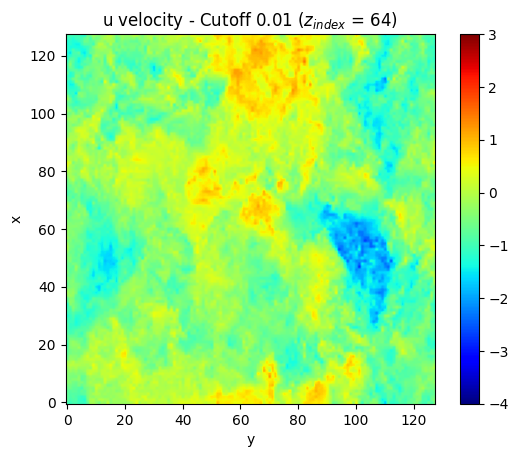

u max: 1.4254628419876099, u min: -2.768787145614624


In [ ]:
from process_file_1024 import load_JHS_velocity_1024
from calculate_gradients import calculate_gradients
from save_as_mat import save_as_h5
import numpy as np
import matplotlib.pyplot as plt



org_path_u = f'../Forced_Isotropic/02 Grid 128/U_t1.mat'
org_path_v = f'../Forced_Isotropic/02 Grid 128/V_t1.mat'
org_path_w = f'../Forced_Isotropic/02 Grid 128/W_t1.mat'

u = load_JHS_velocity_1024(org_path_u)
v = load_JHS_velocity_1024(org_path_v)
w = load_JHS_velocity_1024(org_path_w)
u = u-np.mean(u)
v = v-np.mean(v)
w = w-np.mean(w)

nu = 0.000185
dx = 0.0061359406
dy = dx
dz = dx

# gradients = calculate_gradients((u,v,w), h=(dx,dy,dz), order = 4, spectral = True)


# save_as_h5('grad_dux_dx', 'dux_dx', gradients['dux_dx'])
# save_as_h5('grad_dux_dy', 'dux_dy', gradients['dux_dy'])
# save_as_h5('grad_dux_dz', 'dux_dz', gradients['dux_dz'])
# save_as_h5('grad_duy_dx', 'duy_dx', gradients['duy_dx'])
# save_as_h5('grad_duy_dy', 'duy_dy', gradients['duy_dy'])
# save_as_h5('grad_duy_dz', 'duy_dz', gradients['duy_dz'])
# save_as_h5('grad_duz_dx', 'duz_dx', gradients['duz_dx'])
# save_as_h5('grad_duz_dy', 'duz_dy', gradients['duz_dy'])
# save_as_h5('grad_duz_dz', 'duz_dz', gradients['duz_dz'])
# print(" ")

N = np.shape(u)[0]
k = N // 2  

plt.imshow(u[:, :, k], origin='lower', cmap='jet', vmin=-4, vmax=3)
plt.colorbar()
plt.title(fr'u velocity - Cutoff {cutoff} ($z_{{index}}$ = {k})')
plt.xlabel('y')
plt.ylabel('x')
plt.savefig('Middle_XY_Plane_u_DNS.png', dpi=300, bbox_inches='tight')
plt.show()

# plt.imshow(u_comp[:, :, k], origin='lower', cmap='jet', vmin=-4, vmax=3)
# plt.colorbar()
# plt.title(fr'u velocity - Cutoff {cutoff} ($z_{{index}}$ = {k})')
# plt.xlabel('y')
# plt.ylabel('x')
# plt.savefig('Middle_XY_Plane_u.png', dpi=300, bbox_inches='tight')
# plt.show()

print(f"u max: {np.max(u[:, :, k])}, u min: {np.min(u[:, :, k])}")


In [ ]:
import matplotlib.pyplot as plt

cutoff = 1e-2
comp_path_u = f'truncated_u_1024_il_cf0.01.mat'
comp_path_v = f'truncated_v_1024_il_cf0.01.mat'
comp_path_w = f'truncated_w_1024_il_cf0.01.mat'

org_path_u = f'../../../Forced_Isotropic_1024Cubed_mat_in_one/U_t1.mat'
org_path_v = f'../../../Forced_Isotropic_1024Cubed_mat_in_one/V_t1.mat'
org_path_w = f'../../../Forced_Isotropic_1024Cubed_mat_in_one/W_t1.mat'

u = load_JHS_velocity_1024(org_path_u)
v = load_JHS_velocity_1024(org_path_v)
w = load_JHS_velocity_1024(org_path_w)
# u = u-np.mean(u)
# v = v-np.mean(v)
# w = w-np.mean(w)

u_comp, chi_u = load_JHS_velocity_1024_jul(comp_path_u)
v_comp, chi_v = load_JHS_velocity_1024_jul(comp_path_v)
w_comp, chi_w = load_JHS_velocity_1024_jul(comp_path_w)
# u_comp = u_comp-np.mean(u_comp)
# v_comp = v_comp-np.mean(v_comp)
# w_comp = w_comp-np.mean(w_comp)

# u_hat, v_hat, w_hat = calculate_unit_vectors(u, v, w)
# u_comp_hat, v_comp_hat, w_comp_hat = calculate_unit_vectors(u_comp, v_comp, w_comp)

#plot_scatter(u, u_comp, title='Velocity u', label='u', file_name='Velocity_u')
#plot_scatter(v, v_comp, title='Velocity v', label='v', file_name='Velocity_v')
#plot_scatter(w, w_comp, title='Velocity w', label='w', file_name='Velocity_w')

# plot_scatter(u_hat, u_comp_hat, title='Orientation of Velocity u', label='u hat', file_name='Orientation_of_Velocity_u')
# plot_scatter(v_hat, v_comp_hat, title='Orientation of Velocity v', label='v hat', file_name='Orientation_of_Velocity_v')
# plot_scatter(w_hat, w_comp_hat, title='Orientation of Velocity w', label='w hat', file_name='Orientation_of_Velocity_w')

#plot_scatter(u*u, u_comp*u_comp, title='Reynolds Stress u\'u\'', label='u\'u\'', file_name='Reynolds_Stress_uu')
#plot_scatter(v*v, v_comp*v_comp, title='Reynolds Stress v\'v\'', label='v\'v\'', file_name='Reynolds_Stress_vv')
#plot_scatter(w*w, w_comp*w_comp, title='Reynolds Stress w\'w\'', label='w\'w\'', file_name='Reynolds_Stress_ww')

#plot_scatter(u*v, u_comp*v_comp, title='Reynolds Stress u\'v\'', label='u\'v\'', file_name='Reynolds_Stress_uv')
#plot_scatter(u*w, u_comp*w_comp, title='Reynolds Stress u\'w\'', label='u\'w\'', file_name='Reynolds_Stress_uw')
# plot_scatter(v*w, v_comp*w_comp, title='Reynolds Stress v\'w\'', label='v\'w\'', file_name='Reynolds_Stress_vw')

# E_k = 0.5 * (u**2+v**2+w**2)
# E_k_comp = 0.5 * (u_comp**2+v_comp**2+w_comp**2)
# plot_scatter(E_k, E_k_comp, title='Kinetic Energy', label=r'$E_{k}$', file_name='Kinetic Energy')

# ## mean_rs[_][0] = truth, mean_rs[_][1] = comp, mean_rs[_][2] = rel_error
# mean_rs = {'uu': [0, 0, 0], 'vv': [0, 0, 0], 'ww': [0, 0, 0], 'uv': [0, 0, 0], 'uw': [0, 0, 0], 'vw': [0, 0, 0]}
# mean_rs['uu'][0]= np.mean(u*u)
# mean_rs['uu'][1]= np.mean(u_comp*u_comp)
# mean_rs['uu'][2]= rel_error(mean_rs['uu'][0], mean_rs['uu'][1])

# mean_rs['vv'][0]= np.mean(v*v)
# mean_rs['vv'][1]= np.mean(v_comp*v_comp)
# mean_rs['vv'][2]= rel_error(mean_rs['vv'][0], mean_rs['vv'][1])

# mean_rs['ww'][0]= np.mean(w*w)
# mean_rs['ww'][1]= np.mean(w_comp*w_comp)
# mean_rs['ww'][2]= rel_error(mean_rs['ww'][0], mean_rs['ww'][1])

# mean_rs['uv'][0]= np.mean(u*v)
# mean_rs['uv'][1]= np.mean(u_comp*v_comp)
# mean_rs['uv'][2]= rel_error(mean_rs['uv'][0], mean_rs['uv'][1])

# mean_rs['uw'][0]= np.mean(u*w)
# mean_rs['uw'][1]= np.mean(u_comp*w_comp)
# mean_rs['uw'][2]= rel_error(mean_rs['uw'][0], mean_rs['uw'][1])

# mean_rs['vw'][0]= np.mean(v*w)
# mean_rs['vw'][1]= np.mean(v_comp*w_comp)
# mean_rs['vw'][2]= rel_error(mean_rs['vw'][0], mean_rs['vw'][1])

# print('mean u\'u\': ',mean_rs['uu'])
# print('mean v\'v\': ',mean_rs['vv'])
# print('mean w\'w\': ',mean_rs['ww'])
# print('mean u\'v\': ',mean_rs['uv'])
# print('mean u\'w\': ',mean_rs['uw'])
# print('mean v\'w\': ',mean_rs['vw'])

# save_as_mat('mean_reynolds_stress', {'mean_rs': mean_rs})

N = np.shape(u)[0]
k = N // 2  

plt.imshow(u[:, :, k], origin='lower', cmap='jet', vmin=-4, vmax=3)
plt.colorbar()
plt.title(fr'u velocity - Cutoff {cutoff} ($z_{{index}}$ = {k})')
plt.xlabel('y')
plt.ylabel('x')
plt.savefig('Middle_XY_Plane_u_DNS.png', dpi=300, bbox_inches='tight')
plt.show()


# plt.imshow(u_comp[:, :, k], origin='lower', cmap='jet', vmin=-4, vmax=3)
# plt.colorbar()
# plt.title(fr'u velocity - Cutoff {cutoff} ($z_{{index}}$ = {k})')
# plt.xlabel('y')
# plt.ylabel('x')
# plt.savefig('Middle_XY_Plane_u.png', dpi=300, bbox_inches='tight')
# plt.show()

FileNotFoundError: [Errno 2] Unable to open file (unable to open file: name = '../../../Forced_Isotropic_1024Cubed_mat_in_one/U_t1.mat', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [1]:
#Daniel Data

import os
import numpy as np

def read_binary_file(filename, skip_header_bytes=0, dtype=np.float64):
    """
    Reads a binary file and returns its contents as a NumPy array.
    
    Parameters:
        filename (str): Path to the binary file.
        skip_header_bytes (int): Number of bytes to skip for the header.
        dtype (numpy dtype): Data type of the stored values.
    
    Returns:
        numpy.ndarray: Raw data from the file.
    """
    with open(filename, "rb") as f:
        f.seek(skip_header_bytes)  # Skip header if needed
        data = np.fromfile(f, dtype=dtype)  # Read entire file
    
    return data  # Return raw 1D array

def read_dat_file(filename):
    """
    Reads a .dat file and extracts its contents.
    
    Parameters:
        filename (str): Path to the .dat file.
    
    Returns:
        tuple: (header_lines, raw numerical data as NumPy array)
    """
    header_lines = []
    data = []
    
    with open(filename, "r") as f:
        for line in f:
            if line.strip().startswith("#"):  # Assuming headers start with #
                header_lines.append(line.strip())
            else:
                try:
                    data.append([float(val) for val in line.split()])
                except ValueError:
                    pass  # Skip lines that are not numerical data
    
    return header_lines, np.array(data) if data else None

# Define file path
file_path = "/Users/massen/Library/CloudStorage/OneDrive-UniversityofPittsburgh/Desktop/Research/Daniel Data/it32/"

# # Read all .dat files and print their headers
# dat_files = [f for f in os.listdir(file_path) if f.endswith(".dat")]
# # dat_files = "full1_sctrPQR.00010-00004.dat"
# print("\n### Headers from .dat Files ###\n")
# for dat_file in dat_files:
#     dat_filename = os.path.join(file_path, dat_file)
#     header, data = read_dat_file(dat_filename)
    
#     print(f"Header from {dat_file}:\n", "\n".join(header) if header else "No header found", "\n")

# Read binary files (without reshaping)
ux = read_binary_file(os.path.join(file_path, "rstrt.0010.bin"), skip_header_bytes=192)
uy = read_binary_file(os.path.join(file_path, "rstrt.0010.2.bin"))
uz = read_binary_file(os.path.join(file_path, "rstrt.0010.3.bin"))
pressure = read_binary_file(os.path.join(file_path, "rstrt.0010.4.bin"))

N = 32
ux = ux.reshape((N, N, N), order='F')
uy = uy.reshape((N, N, N), order='F')
uz = uz.reshape((N, N, N), order='F')
pressure = pressure.reshape((N, N, N), order='F')

print("\nBinary files loaded successfully!")



Binary files loaded successfully!


In [3]:

import numpy as np
from plotting import plot_pdf, plot_QR_joint_pdf
import os

# Define file path (modify this to match your system)
N = 32
file_path = "/Users/massen/Library/CloudStorage/OneDrive-UniversityofPittsburgh/Desktop/Research/Daniel Data/it32/"
dat_files = sorted([f for f in os.listdir(file_path) if f.startswith("full1_sctrPQR.00010-")])

# Initialize dictionary to store concatenated data
headers = ["P", "Q", "R", "Om", "St"]
# headers = ["P", "Q", "R"]

PQR = {header: [] for header in headers}

# Read and concatenate all files
for dat_file in dat_files:
    dat_filename = os.path.join(file_path, dat_file)
    data = np.loadtxt(dat_filename, skiprows=2)  # Skipping the two header lines

    # Append each column to the corresponding key in the dictionary
    for i, header in enumerate(headers):
        PQR[header].extend(data[:, i])  # Flattening into a single list

# Convert lists to numpy arrays
for key in PQR:
    PQR[key] = np.array(PQR[key])

# Print final shape to verify (should be 5 × 32768)
print({key: PQR[key].shape for key in PQR})

P_dani = np.reshape(PQR['P'], (N,N,N), order='F')
Q_dani = np.reshape(PQR['Q'], (N,N,N), order='F')
R_dani = np.reshape(PQR['R'], (N,N,N), order='F')


{'P': (32768,), 'Q': (32768,), 'R': (32768,), 'Om': (32768,), 'St': (32768,)}


(32, 32, 32)
(32, 32, 32)
H.min() before = 0.0
H.max() before = 5.094468154907295
H.min() after = 1e-08
H.max() after = 5.094468154907295



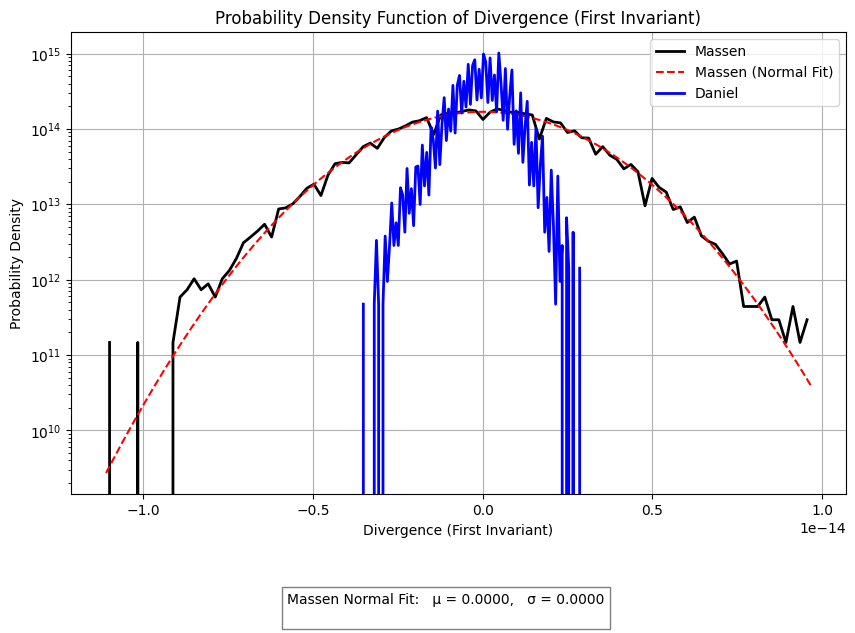

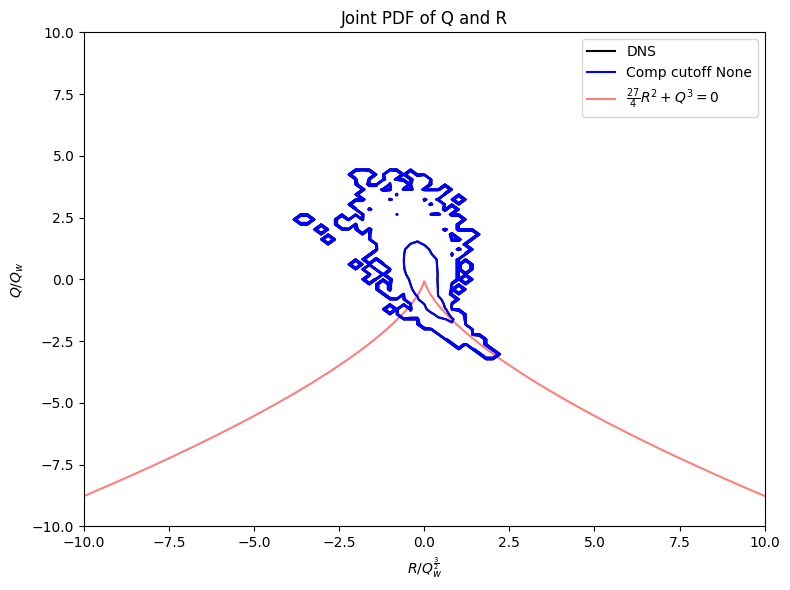

In [6]:
#dinja
import matplotlib.pyplot as plt
import numpy as np
from plotting import plot_QR_joint_pdf
from calculate_gradients import calculate_gradients,calculate_invariants,calculate_invariants_exact, compute_Qw
from save_as_mat import save_as_h5, load_h5
from plotting import plot_pdf
import json

xcoor = 2*np.pi/32
# xcoor = 100
# xcoor = 1/32
# xcoor = 0.0003745767779282715
# xcoor = xcoord[2]-xcoord[1]
ycoor = xcoor
zcoor = xcoor
velocity_field = (ux, uy, uz)
h = (xcoor,ycoor,zcoor)

gradients = calculate_gradients(velocity_field, h, spectral = True)
# gradients = calculate_gradients(velocity_field, h, order=8, spectral = False)
grad = np.array([[gradients['dux_dx'], gradients['dux_dy'], gradients['dux_dz']],
                 [gradients['duy_dx'], gradients['duy_dy'], gradients['duy_dz']],
                 [gradients['duz_dx'], gradients['duz_dy'], gradients['duz_dz']]])

grad = np.transpose(grad, (2, 3, 4, 0, 1))  # Rearrange dimensions


P_exact, Q_exact, R_exact = calculate_invariants_exact(grad)
Qw_exact = compute_Qw(grad)
print(Q_exact.shape)
print(R_exact.shape)


plot_pdf({f'Massen':P_exact,'Daniel':P_dani}, title='Divergence (First Invariant)',
         file_name='div_1024Cubed_spectral', norm_dist=True)

Q_lim = 10
R_lim = 10
# plot_QR_joint_pdf(Q_exact, R_exact, Qw_exact, Qlim=Q_lim, Rlim=R_lim)
# plot_QR_joint_pdf(Q_dani, R_dani, Qw_exact, Qlim=Q_lim, Rlim=R_lim)
# plot_QR_joint_pdf(Q_dani, R_dani, 1, Qlim=Q_lim, Rlim=R_lim)

plot_QR_joint_pdf(Q_exact, R_exact, Qw_exact, Q_dani, R_dani, Qw_exact, Qlim=Q_lim, Rlim=R_lim, colormesh=False)
# plot_QR_joint_pdf(Q_exact, R_exact, Qw_exact, Q_dani, R_dani, 1, Qlim=Q_lim, Rlim=R_lim, colormesh=False)



{'P': (32768,), 'Q': (32768,), 'R': (32768,)}
Saved first_invariant_div_spectral_daniel.h5 successfully.
Saved second_invariant_Q_spectral_daniel.h5 successfully.
Saved third_invariant_R_spectral_daniel.h5 successfully.
H.min() before = 0.0
H.max() before = 5.094468154907295
H.min() after = 1e-08
H.max() after = 5.094468154907295

H.min() before = 0.0
H.max() before = 5.094468154907295
H.min() after = 1e-08
H.max() after = 5.094468154907295



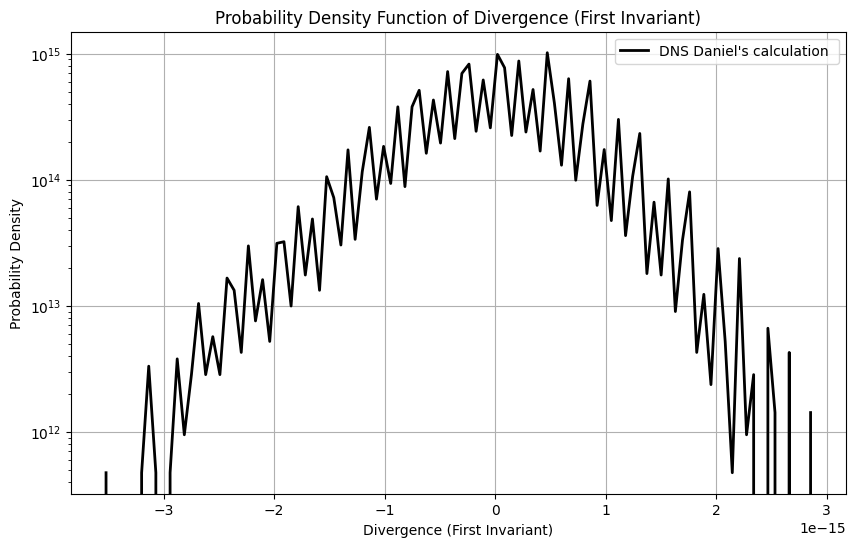

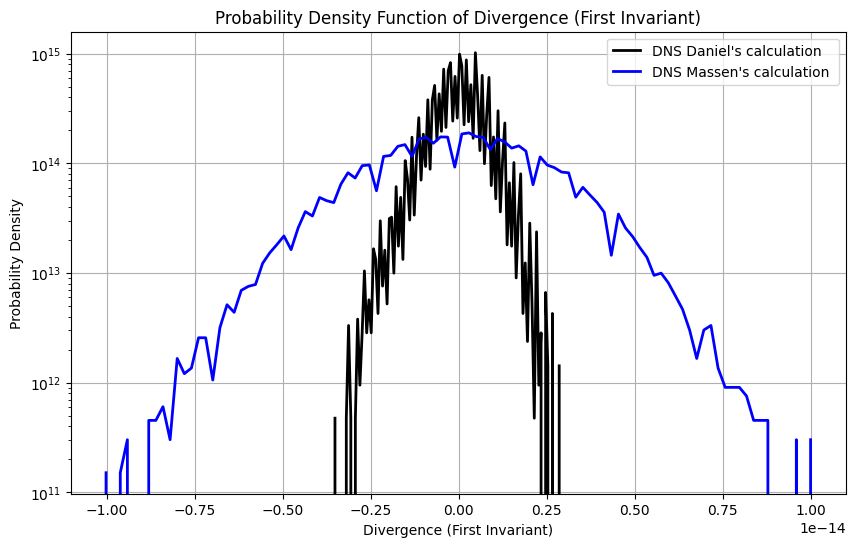

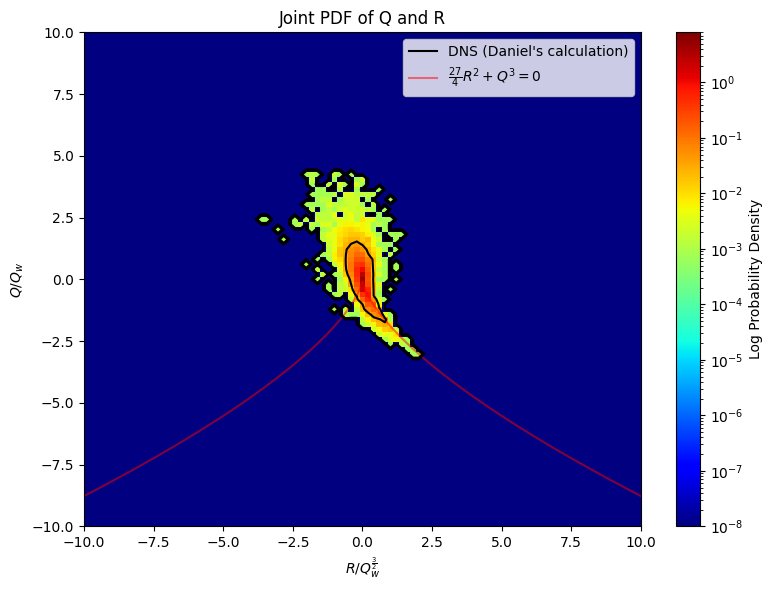

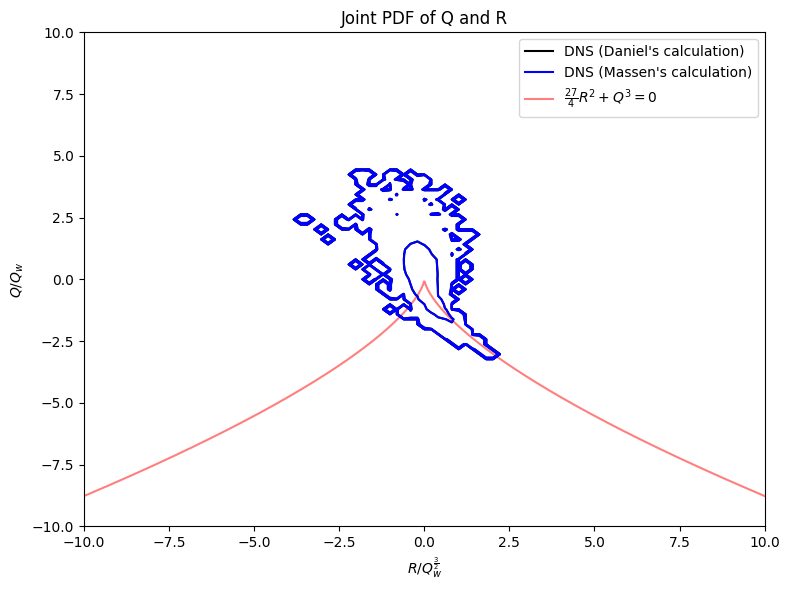

In [ ]:
#daniii

import numpy as np
from plotting import plot_pdf, plot_QR_joint_pdf
from save_as_mat import save_as_h5, load_h5
import os
import json

# Define file path (modify this to match your system)
N = 32
file_path = "/Users/massen/Library/CloudStorage/OneDrive-UniversityofPittsburgh/Desktop/Research/Daniel Data/it32/"
dat_files = sorted([f for f in os.listdir(file_path) if f.startswith("full1_sctrPQR.00010-")])
config_path = "config_FI.json"
with open(config_path, "r") as f:
    config = json.load(f)
org_path = config.get("32_binary_dns", {})
Qw =  2.353024608021444


# N = 1024
# file_path = "../Spectral/Daniel_PQR/"
# dat_files = sorted([f for f in os.listdir(file_path) if f.startswith("full1_sctrPQR.00217-")])
# # dat_files = sorted([f for f in os.listdir(file_path) if f.startswith("full1_sctrPQR.00217-00002")])
# config_path = mps_codes_path + "/config_FI.json"
# with open(config_path, "r") as f:
#     config = json.load(f)
# org_path = config.get("full_binary_dns", {})
# Qw = 32.59979212200147


# Initialize dictionary to store concatenated data
# headers = ["P", "Q", "R", "Om", "St"]
headers = ["P", "Q", "R"]
PQR = {header: [] for header in headers}

for dat_file in dat_files:
    dat_filename = os.path.join(file_path, dat_file)
    data = np.loadtxt(dat_filename, skiprows=2)  # Skipping the two header lines

    for i, header in enumerate(headers):
        PQR[header].extend(data[:, i])  # Flattening into a single list

for key in PQR:
    PQR[key] = np.array(PQR[key])

print({key: PQR[key].shape for key in PQR})

P_dani = np.reshape(PQR['P'], (N,N,N), order='F')
Q_dani = np.reshape(PQR['Q'], (N,N,N), order='F')
R_dani = np.reshape(PQR['R'], (N,N,N), order='F')

save_as_h5('first_invariant_div_spectral_daniel','div', P_dani)
save_as_h5('second_invariant_Q_spectral_daniel','Q', Q_dani)
save_as_h5('third_invariant_R_spectral_daniel','R', R_dani)


div_exact = load_h5(org_path['invars']['div'])
Q_exact = load_h5(org_path['invars']['Q'])
R_exact = load_h5(org_path['invars']['R'])


x_max = None
x_min = None
pdf_max = None
pdf_min = None


plot_pdf({'DNS Daniel\'s calculation ':P_dani}, title='Divergence (First Invariant)',
         file_name='div_DNS_1024Cubed_spectral_Daniel', x_min=x_min, 
         x_max=x_max, pdf_min=pdf_min, pdf_max=pdf_max)

plot_pdf({'DNS Daniel\'s calculation ':P_dani, 'DNS Massen\'s calculation ':div_exact}, 
         title='Divergence (First Invariant)',
         file_name='div_DNS_1024Cubed_spectral_Daniel_Massen', x_min=x_min, 
         x_max=x_max, pdf_min=pdf_min, pdf_max=pdf_max)


plot_QR_joint_pdf(Q_dani, R_dani, Qw,
                  label_1 = 'DNS (Daniel\'s calculation)',
                  file_name=f'PDF_QR_Joint_DNS_Daniel')


plot_QR_joint_pdf(Q_dani, R_dani, Qw, Q_exact, R_exact, Qw,
                  label_1='DNS (Daniel\'s calculation)', colormesh=False,
                  label_2='DNS (Massen\'s calculation)',
                  file_name=f'PDF_QR_Joint_DNS_Daniel_Massen_contourlines')




In [9]:
N = 11000
(1024**3/N)**(1/3)
# (49+53+30)/3

46.04357765351517

In [12]:
#Joint PDF plot

import matplotlib.pyplot as plt
import numpy as np
from plotting import plot_QR_joint_pdf
from calculate_gradients import calculate_invariants, calculate_invariants_exact, compute_Qw
from save_as_mat import save_as_h5, load_h5
from plotting import plot_pdf
import json

config_path = mps_codes_path + "/config_FI.json"
with open(config_path, "r") as f:
    config = json.load(f)

org_path = config.get("full_dns", {})
div = load_h5(org_path['invars']['div'])
# Q = load_h5(org_path['invars']['Q'])
# R = load_h5(org_path['invars']['R'])
# Qw = 15.756560377380076

# cutoff = 1e-5
# grad_dux_dx = load_h5("grad_dux_dx.h5")
# grad_dux_dy = load_h5("grad_dux_dy.h5")
# grad_dux_dz = load_h5("grad_dux_dz.h5")
# grad_duy_dx = load_h5("grad_duy_dx.h5")
# grad_duy_dy = load_h5("grad_duy_dy.h5")
# grad_duy_dz = load_h5("grad_duy_dz.h5")
# grad_duz_dx = load_h5("grad_duz_dx.h5")
# grad_duz_dy = load_h5("grad_duz_dy.h5")
# grad_duz_dz = load_h5("grad_duz_dz.h5")

# grad = np.array([[grad_dux_dx, grad_dux_dy, grad_dux_dz],
#                  [grad_duy_dx, grad_duy_dy, grad_duy_dz],
#                  [grad_duz_dx, grad_duz_dy, grad_duz_dz]])

# grad = np.transpose(grad, (2, 3, 4, 0, 1))  # Rearrange dimensions


# # div_comp, Q_comp, R_comp = calculate_invariants(grad)
# div_comp, Q_comp, R_comp = calculate_invariants_exact(grad)
# Qw_comp = compute_Qw(grad)
# print(Q_comp.shape)
# print(R_comp.shape)


# print("Qw: ", Qw, "\tQw_comp: ", Qw_comp)

# save_as_h5('first_invariant_div_spectral','div', div_comp)
# save_as_h5('second_invariant_Q_spectral_exact','Q', Q_comp)
# save_as_h5('third_invariant_R_spectral_exact','R', R_comp)

div_comp = load_h5("first_invariant_div_spectral.h5")
# Q_comp = load_h5("second_invariant_Q_spectral_exact.h5")
# R_comp = load_h5("third_invariant_R_spectral_exact.h5")
# Qw_comp = 15.43385154381595

plot_pdf({'DNS':div, f'Comp cutoff {cutoff}':div_comp}, title='Divergence (First Invariant)',
         file_name='div_1024Cubed_spectral', x_min=-220, x_max=220, pdf_min=1e-10, pdf_max=1e5)

# plot_QR_joint_pdf(Q_comp, R_comp, Qw_comp, cutoff=cutoff)

# plot_QR_joint_pdf(Q, R, Qw, Q_comp, R_comp, Qw_comp, cutoff=cutoff, colormesh=False)

array([[[-2.55351296e-15, -1.66451363e-01,  9.08730954e-01, ...,
         -1.48557061e+00, -8.70008508e-02,  2.48248250e+00],
        [-8.67625671e-01,  4.64188343e-02,  9.37253106e-02, ...,
         -2.90108966e+00, -1.02952259e-01, -1.91422406e-02],
        [ 5.37014788e-01,  1.46631550e+00,  1.22754016e-01, ...,
          5.45330660e-01,  8.80629002e-01, -1.48516259e+00],
        ...,
        [-1.21935912e-01, -4.26809872e-01,  4.61405966e+00, ...,
         -4.12938135e+00,  1.73320696e+00,  5.46675207e+00],
        [-3.70003308e+00, -3.56764631e-01,  1.13378007e+01, ...,
         -2.03807231e+00,  2.91597788e+00,  2.57381415e+00],
        [-5.46452794e+00,  4.25321913e+00,  1.18956347e+01, ...,
         -3.56765838e+00,  7.44243506e-01, -4.21610340e-01]],

       [[-1.72084569e-15, -1.14568773e-01,  5.45136636e-01, ...,
         -4.79990222e-01,  3.85718704e+00,  4.68271127e+00],
        [-9.94871219e-01, -3.36416192e-01, -4.44699718e-01, ...,
          3.31986972e-01,  2.13443566e

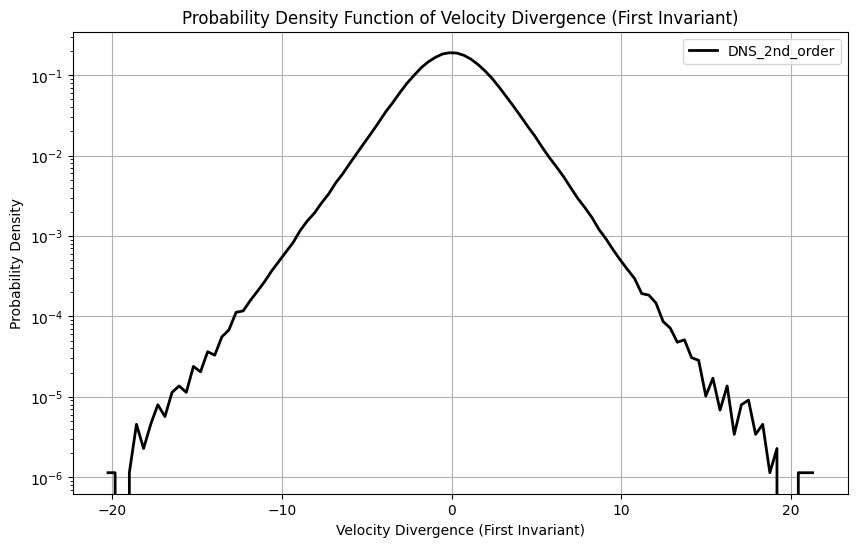

In [1]:
#Joint PDF plot

import matplotlib.pyplot as plt
import numpy as np
from plotting import plot_QR_joint_pdf
from save_as_mat import  load_h5
from plotting import plot_pdf
import json

config_path = mps_codes_path + "/config_FI.json"
with open(config_path, "r") as f:
    config = json.load(f)
org_path = config.get("full_dns", {})
div = load_h5(org_path['invars']['div'])

# div = load_h5("first_invariant_div_spectral.h5")

method = '2nd_order'
plot_pdf({f'DNS_{method}':div}, title='Velocity Divergence (First Invariant)',
         file_name=f'div_{method}_1024Cubed')


In [55]:
# Load a sample .dat file
dat_filename = file_path + "Muder2.dat"
header, grad_dani = read_dat_file(dat_filename)

In [51]:
def read_binary_header(filename, header_size=192):
    """
    Reads the first `header_size` bytes from a binary file to examine its header.
    
    Parameters:
        filename (str): Path to the binary file.
        header_size (int): Number of bytes to read from the beginning.
    
    Returns:
        bytes: Raw header data.
    """
    with open(filename, "rb") as f:
        header = f.read(header_size)  # Read first `header_size` bytes
    return header

# Define file path
file_path = "/Users/massen/Library/CloudStorage/OneDrive-UniversityofPittsburgh/Desktop/Research/Daniel Data/it32/rstrt.0010.bin"

# Read and display the header
header_data = read_binary_header(file_path)
print("Header Raw Data (Bytes):", header_data)

# Attempt to interpret as text
try:
    print("\nHeader Interpreted as UTF-8:", header_data.decode("utf-8"))
except UnicodeDecodeError:
    print("\nHeader contains non-text binary data.")


Header Raw Data (Bytes): b'cfdnsrun\x00\x00\x00\x00\x00\x00\xf0?\xeb\xff\xff\xff\xff\xffX@y\xb6\xd3\x02[\x8c\x88?\x03\x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00\x00\x00\x00A\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x18-DT\xfb!\x19@\x18-DT\xfb!\x19@\x18-DT\xfb!\x19@\x00\x00\x00\x00\x04\x00\x00\x00density         velocity        velocity        velocity        pressure        '

Header contains non-text binary data.


In [107]:
import struct

def parse_binary_header(filename, header_size=192):
    """
    Reads and decodes the header of a binary file.
    
    Parameters:
        filename (str): Path to the binary file.
        header_size (int): Number of bytes allocated to the header.

    Returns:
        dict: Parsed header information.
    """
    with open(filename, "rb") as f:
        header = f.read(header_size)  # Read the full header bytes
    
    # Extract the initial identifier (e.g., "cfdnsrun")
    text_part = header[:16].decode("utf-8", errors="ignore").strip()

    # Extract numerical values dynamically
    numeric_section = header[16:128]  # Assuming numerical values are between byte 16-128
    num_values = len(numeric_section) // 8  # Assuming double precision (8 bytes each)
    
    values = struct.unpack(f"{num_values}d", numeric_section)  # Interpret as double precision

    # Extract variable names from the last part of the header
    variable_names = header[-64:].decode("utf-8", errors="ignore").strip().split()

    # Store in dictionary
    header_info = {
        "Identifier": text_part,
        "Numerical Values": values,  # List of extracted numbers
        "Variables": variable_names
    }
    
    return header_info

# Define file path
file_path = "/Users/massen/Library/CloudStorage/OneDrive-UniversityofPittsburgh/Desktop/Research/Daniel Data/it32/rstrt.0010.bin"

# Parse and display the header
header_info = parse_binary_header(file_path)
print("Parsed Header Information:\n", header_info)


Parsed Header Information:
 {'Identifier': 'cfdnsrun\x00\x00\x00\x00\x00\x00?', 'Numerical Values': (99.9999999999997, 0.011986456893704688, 6.79038653124e-313, 6.79038653267e-313, 5.38787994e-315, 0.0, 0.0, 0.0, 6.283185307179586, 6.283185307179586, 6.283185307179586, 8.487983164e-314, 3.0376012766403972e-152, 6.013470016999068e-154), 'Variables': ['velocity', 'velocity', 'velocity', 'pressure']}


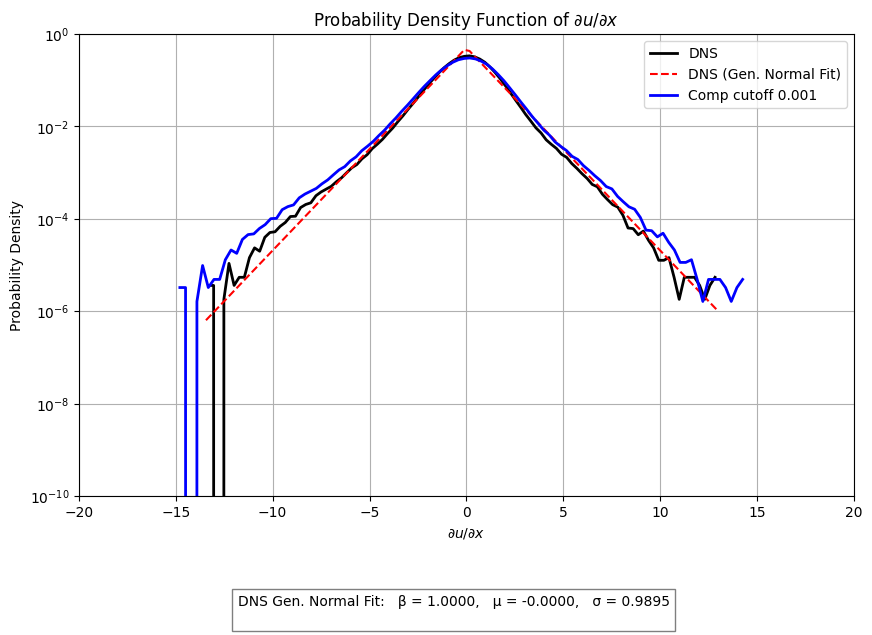

In [1]:
#PDF of Gradients

import numpy as np
from save_as_mat import load_h5
from plotting import plot_pdf
import json
# mps_codes_path = "/ix/pgivi/moe32/Schmidt/Nik_code/code/AnalysingResultsFromDNS_demo/ComputationalSpaces/mps_py_codes"
# config_path = mps_codes_path + "/config_FI.json"
# with open(config_path, "r") as f:
#     config = json.load(f)

# org_path = config.get("full_dns", {})

cutoff = 1e-3
grad_dux_dx_comp = load_h5("grad_dux_dx.h5")
grad_dux_dy_comp = load_h5("grad_dux_dy.h5")
grad_dux_dz_comp = load_h5("grad_dux_dz.h5")
grad_duy_dx_comp = load_h5("grad_duy_dx.h5")
grad_duy_dy_comp = load_h5("grad_duy_dy.h5")
grad_duy_dz_comp = load_h5("grad_duy_dz.h5")
grad_duz_dx_comp = load_h5("grad_duz_dx.h5")
grad_duz_dy_comp = load_h5("grad_duz_dy.h5")
grad_duz_dz_comp = load_h5("grad_duz_dz.h5")


# grad_dux_dx = load_h5(org_path['grad_vel']['dux_dx'])
# grad_dux_dy = load_h5(org_path['grad_vel']['dux_dy'])
# grad_dux_dz = load_h5(org_path['grad_vel']['dux_dz'])
# grad_duy_dx = load_h5(org_path['grad_vel']['duy_dx'])
# grad_duy_dy = load_h5(org_path['grad_vel']['duy_dy'])
# grad_duy_dz = load_h5(org_path['grad_vel']['duy_dz'])
# grad_duz_dx = load_h5(org_path['grad_vel']['duz_dx'])
# grad_duz_dy = load_h5(org_path['grad_vel']['duz_dy'])
# grad_duz_dz = load_h5(org_path['grad_vel']['duz_dz'])


grad_dux_dx = grad_dux_dx_comp*0.9
grad_dux_dy = grad_dux_dy_comp*0.9
grad_dux_dz = grad_dux_dz_comp*0.9
grad_duy_dx = grad_duy_dx_comp*0.9
grad_duy_dy = grad_duy_dy_comp*0.9
grad_duy_dz = grad_duy_dz_comp*0.9
grad_duz_dx = grad_duz_dx_comp*0.9
grad_duz_dy = grad_duz_dy_comp*0.9
grad_duz_dz = grad_duz_dz_comp*0.9

pdf_min = 1e-10
pdf_max = 1
x_max = 20
x_min = -x_max

plot_pdf({'DNS':grad_dux_dx, f'Comp cutoff {cutoff}':grad_dux_dx_comp}, 
         title=r'$\partial u / \partial x$', file_name='grad_dux_dx_SameLimits', 
         pdf_min=pdf_min, pdf_max=pdf_max, x_min=x_min, x_max=x_max, gen_norm_dist=True)

# plot_pdf({'DNS':grad_duy_dy, f'Comp cutoff {cutoff}':grad_duy_dy_comp}, 
#          title=r'$\partial v / \partial y$', file_name='grad_duy_dy_SameLimits', 
#          pdf_min=pdf_min, pdf_max=pdf_max, x_min=x_min, x_max=x_max, gen_norm_dist=True)

# plot_pdf({'DNS':grad_duz_dz, f'Comp cutoff {cutoff}':grad_duz_dz_comp}, 
#          title=r'$\partial w / \partial z$', file_name='grad_duz_dz_SameLimits', 
#          pdf_min=pdf_min, pdf_max=pdf_max, x_min=x_min, x_max=x_max, gen_norm_dist=True)

# plot_pdf({'DNS':grad_dux_dy, f'Comp cutoff {cutoff}':grad_dux_dy_comp}, 
#          title=r'$\partial u / \partial y$', file_name='grad_dux_dy_SameLimits', 
#          pdf_min=pdf_min, pdf_max=pdf_max, x_min=x_min, x_max=x_max, gen_norm_dist=True)

# plot_pdf({'DNS':grad_dux_dz, f'Comp cutoff {cutoff}':grad_dux_dz_comp}, 
#          title=r'$\partial u / \partial z$', file_name='grad_dux_dz_SameLimits', 
#          pdf_min=pdf_min, pdf_max=pdf_max, x_min=x_min, x_max=x_max, gen_norm_dist=True)

# plot_pdf({'DNS':grad_duy_dx, f'Comp cutoff {cutoff}':grad_duy_dx_comp}, 
#          title=r'$\partial v / \partial x$', file_name='grad_duy_dx_SameLimits', 
#          pdf_min=pdf_min, pdf_max=pdf_max, x_min=x_min, x_max=x_max, gen_norm_dist=True)

# plot_pdf({'DNS':grad_duy_dz, f'Comp cutoff {cutoff}':grad_duy_dz_comp}, 
#          title=r'$\partial v / \partial z$', file_name='grad_duy_dz_SameLimits', 
#          pdf_min=pdf_min, pdf_max=pdf_max, x_min=x_min, x_max=x_max, gen_norm_dist=True)

# plot_pdf({'DNS':grad_duz_dx, f'Comp cutoff {cutoff}':grad_duz_dx_comp}, 
#          title=r'$\partial w / \partial x$', file_name='grad_duz_dx_SameLimits', 
#          pdf_min=pdf_min, pdf_max=pdf_max, x_min=x_min, x_max=x_max, gen_norm_dist=True)

# plot_pdf({'DNS':grad_duz_dy, f'Comp cutoff {cutoff}':grad_duz_dy_comp}, 
#          title=r'$\partial w / \partial y$', file_name='grad_duz_dy_SameLimits', 
#          pdf_min=pdf_min, pdf_max=pdf_max, x_min=x_min, x_max=x_max, gen_norm_dist=True)


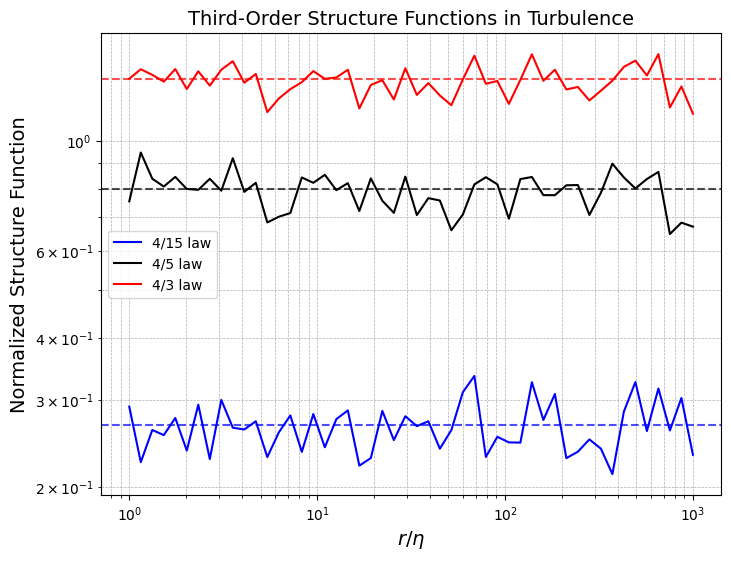

In [1]:
#Structure function

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Constants (adjust based on your simulation parameters)
epsilon = 1.0  # Mean energy dissipation rate (adjust as needed)
eta = 1.0  # Kolmogorov length scale (adjust as needed)
r_values = np.logspace(0, 3, 50)  # Separation distances in inertial range

# Simulated structure functions (replace with actual DNS data)
D_LLL = - (4/5) * epsilon * r_values * (1 + 0.1 * np.random.randn(len(r_values)))  # Third-order longitudinal
D_LTT = - (4/15) * epsilon * r_values * (1 + 0.1 * np.random.randn(len(r_values)))  # Third-order transverse

# Normalized structure functions
S_LLL = -D_LLL / (epsilon * r_values)
S_LTT = -D_LTT / (epsilon * r_values)
S_total = -(D_LLL + 2 * D_LTT) / (epsilon * r_values)  # 4/3 law

# Plot
plt.figure(figsize=(8, 6))
plt.loglog(r_values / eta, S_LTT, label="4/15 law", color='blue')  # Bottom
plt.loglog(r_values / eta, S_LLL, label="4/5 law", color='black')  # Middle
plt.loglog(r_values / eta, S_total, label="4/3 law", color='red')  # Top

# Reference lines at theoretical values
plt.axhline(4/15, linestyle="--", color="blue", alpha=0.7)
plt.axhline(4/5, linestyle="--", color="black", alpha=0.7)
plt.axhline(4/3, linestyle="--", color="red", alpha=0.7)

# Labels and legend
plt.xlabel(r"$r/\eta$", fontsize=14)
plt.ylabel(r"Normalized Structure Function", fontsize=14)
plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.title("Third-Order Structure Functions in Turbulence", fontsize=14)
plt.show()


In [2]:
r_values

array([   1.        ,    1.1513954 ,    1.32571137,    1.52641797,
          1.75751062,    2.02358965,    2.32995181,    2.6826958 ,
          3.0888436 ,    3.55648031,    4.09491506,    4.71486636,
          5.42867544,    6.25055193,    7.19685673,    8.28642773,
          9.54095476,   10.98541142,   12.64855217,   14.56348478,
         16.76832937,   19.30697729,   22.22996483,   25.59547923,
         29.47051703,   33.93221772,   39.06939937,   44.98432669,
         51.79474679,   59.63623317,   68.6648845 ,   79.06043211,
         91.0298178 ,  104.81131342,  120.67926406,  138.94954944,
        159.98587196,  184.20699693,  212.09508879,  244.20530945,
        281.1768698 ,  323.74575428,  372.75937203,  429.19342601,
        494.17133613,  568.9866029 ,  655.12855686,  754.31200634,
        868.51137375, 1000.        ])

In [ ]:
#stilde
import numpy as np
from calculate_eps_stilde import calculate_s_tilde
from plotting import plot_pdf
from save_as_mat import save_as_h5
from save_as_mat import load_h5
import json

# mps_codes_path = "/ix/pgivi/moe32/Schmidt/Nik_code/code/AnalysingResultsFromDNS_demo/ComputationalSpaces/mps_py_codes"
config_path = mps_codes_path + "/config_FI.json"
with open(config_path, "r") as f:
    config = json.load(f)

org_path = config.get("full_dns", {})
grad_dux_dx = load_h5(org_path['grad_vel']['dux_dx'])
grad_dux_dy = load_h5(org_path['grad_vel']['dux_dy'])
grad_dux_dz = load_h5(org_path['grad_vel']['dux_dz'])
grad_duy_dx = load_h5(org_path['grad_vel']['duy_dx'])
grad_duy_dy = load_h5(org_path['grad_vel']['duy_dy'])
grad_duy_dz = load_h5(org_path['grad_vel']['duy_dz'])
grad_duz_dx = load_h5(org_path['grad_vel']['duz_dx'])
grad_duz_dy = load_h5(org_path['grad_vel']['duz_dy'])
grad_duz_dz = load_h5(org_path['grad_vel']['duz_dz'])

# grad_dux_dx = load_h5("grad_dux_dx.h5")
# grad_dux_dy = load_h5("grad_dux_dy.h5")
# grad_dux_dz = load_h5("grad_dux_dz.h5")
# grad_duy_dx = load_h5("grad_duy_dx.h5")
# grad_duy_dy = load_h5("grad_duy_dy.h5")
# grad_duy_dz = load_h5("grad_duy_dz.h5")
# grad_duz_dx = load_h5("grad_duz_dx.h5")
# grad_duz_dy = load_h5("grad_duz_dy.h5")
# grad_duz_dz = load_h5("grad_duz_dz.h5")

# Symmetric velocity gradients
S11 = grad_dux_dx + grad_dux_dx  
S12 = grad_dux_dy + grad_duy_dx  
S13 = grad_dux_dz + grad_duz_dx  
S22 = grad_duy_dy + grad_duy_dy  
S23 = grad_duy_dz + grad_duz_dy  
S33 = grad_duz_dz + grad_duz_dz

Sij = np.array([[S11, S12, S13], [S12, S22, S23], [S13, S23, S33]])/2
Sij = np.transpose(Sij, axes=(2,3,4,0,1))

print("Sij shape: ", Sij.shape)
s_tilde, alpha, beta, gamma = calculate_s_tilde(Sij)

save_as_h5('Strain_rate_eigen_values_stilde', 'stilde', s_tilde)
save_as_h5('Strain_rate_eigen_values_alpha', 'alpha', alpha)
save_as_h5('Strain_rate_eigen_values_beta', 'beta', beta)
save_as_h5('Strain_rate_eigen_values_gamma', 'gamma', gamma)


plot_pdf({r'$\tilde{s}^*$':s_tilde}, title=r'$\tilde{s}^*$', log_Y=False, norm_dist=False, file_name='Strain_rate_eigen_values_stilde')

plot_pdf({r'$\alpha$':alpha}, title=r'1st eigen value of $S^*$ ($\alpha$)', norm_dist=False, file_name='Strain_rate_eigen_values_alpha')

plot_pdf({r'$\beta$':beta}, title=r'2nd eigen value of $S^*$ ($\beta$)', norm_dist=False, file_name='Strain_rate_eigen_values_beta')

plot_pdf({r'$\gamma$':gamma}, title=r'3rd eigen value of $S^*$ ($\gamma$)', norm_dist=False, file_name='Strain_rate_eigen_values_gamma')


Sij_comp shape:  (128, 128, 128, 3, 3)
Saved Strain_rate_eigen_values_stilde.h5 successfully.
Saved Strain_rate_eigen_values_alpha.h5 successfully.
Saved Strain_rate_eigen_values_beta.h5 successfully.
Saved Strain_rate_eigen_values_gamma.h5 successfully.


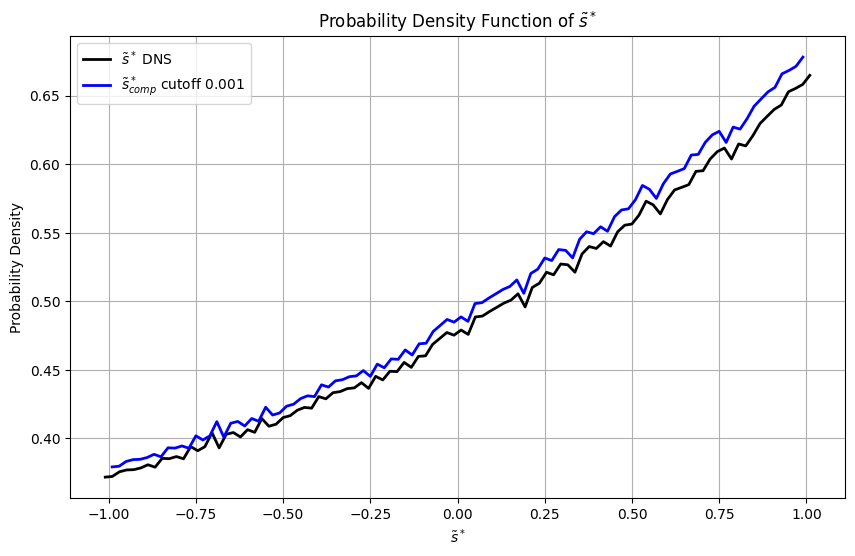

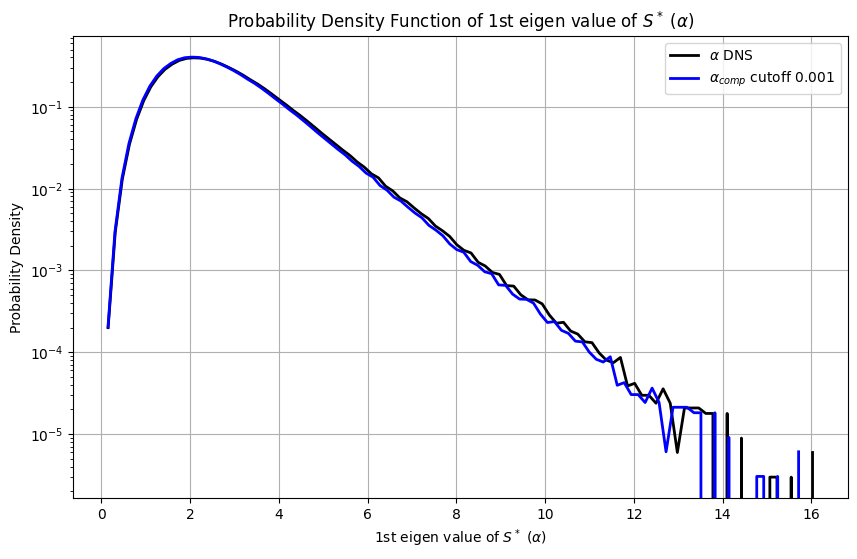

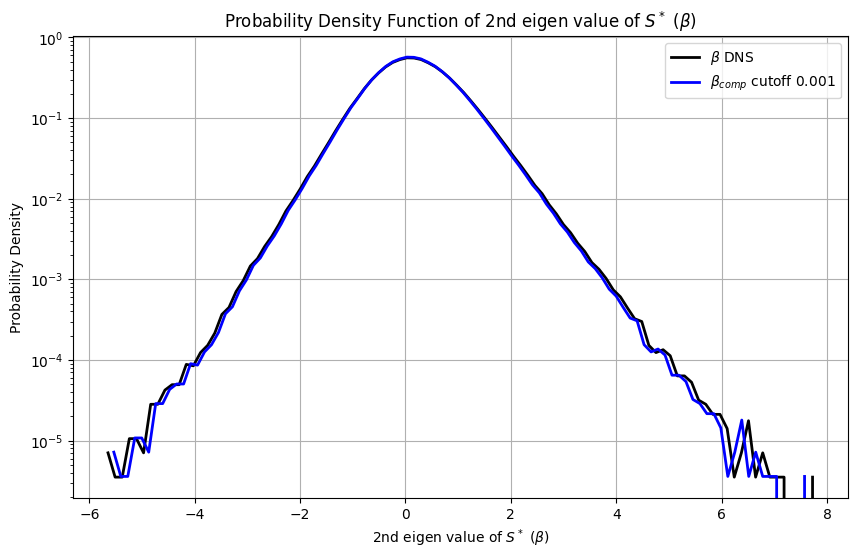

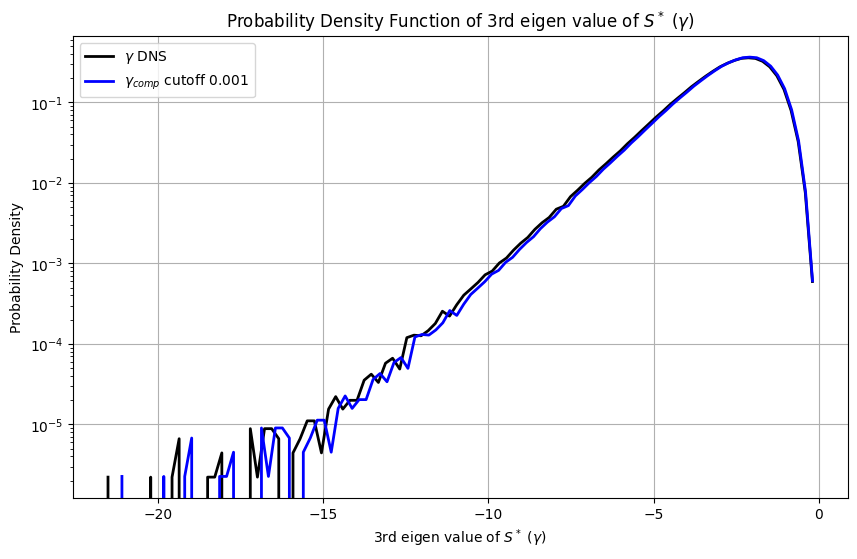

In [1]:
#PDF of stilde 

import numpy as np
from save_as_mat import load_h5
from plotting import plot_pdf
from calculate_eps_stilde import calculate_s_tilde
from save_as_mat import save_as_h5
import json
# mps_codes_path = "/ix/pgivi/moe32/Schmidt/Nik_code/code/AnalysingResultsFromDNS_demo/ComputationalSpaces/mps_py_codes"
config_path = mps_codes_path + "/config_FI.json"
with open(config_path, "r") as f:
    config = json.load(f)

cutoff = 1e-3
org_path = config.get("full_dns", {})
alpha = load_h5(org_path['strain_rate']['alpha'])
beta  = load_h5(org_path['strain_rate']['beta'])
gamma = load_h5(org_path['strain_rate']['gamma'])
s_tilde = load_h5(org_path['strain_rate']['s_tilde'])


grad_dux_dx_comp = load_h5("grad_dux_dx.h5")
grad_dux_dy_comp = load_h5("grad_dux_dy.h5")
grad_dux_dz_comp = load_h5("grad_dux_dz.h5")
grad_duy_dx_comp = load_h5("grad_duy_dx.h5")
grad_duy_dy_comp = load_h5("grad_duy_dy.h5")
grad_duy_dz_comp = load_h5("grad_duy_dz.h5")
grad_duz_dx_comp = load_h5("grad_duz_dx.h5")
grad_duz_dy_comp = load_h5("grad_duz_dy.h5")
grad_duz_dz_comp = load_h5("grad_duz_dz.h5")


# Symmetric velocity gradients
S11_comp = grad_dux_dx_comp + grad_dux_dx_comp
S12_comp = grad_dux_dy_comp + grad_duy_dx_comp
S13_comp = grad_dux_dz_comp + grad_duz_dx_comp
S22_comp = grad_duy_dy_comp + grad_duy_dy_comp
S23_comp = grad_duy_dz_comp + grad_duz_dy_comp
S33_comp = grad_duz_dz_comp + grad_duz_dz_comp

Sij_comp = np.array([[S11_comp, S12_comp, S13_comp], 
                     [S12_comp, S22_comp, S23_comp],
                     [S13_comp, S23_comp, S33_comp]])/2
Sij_comp = np.transpose(Sij_comp, axes=(2,3,4,0,1))

print("Sij_comp shape: ", Sij_comp.shape)
s_tilde_comp, alpha_comp, beta_comp, gamma_comp = calculate_s_tilde(Sij_comp)


save_as_h5('Strain_rate_eigen_values_stilde', 'stilde', s_tilde_comp)
save_as_h5('Strain_rate_eigen_values_alpha', 'alpha', alpha_comp)
save_as_h5('Strain_rate_eigen_values_beta', 'beta', beta_comp)
save_as_h5('Strain_rate_eigen_values_gamma', 'gamma', gamma_comp)

# alpha_comp = load_h5('Strain_rate_eigen_values_alpha.h5')
# beta_comp = load_h5('Strain_rate_eigen_values_beta.h5')
# gamma_comp = load_h5('Strain_rate_eigen_values_gamma.h5')

# s_tilde = s_tilde_comp*1.02
# alpha = alpha_comp*1.02
# beta  = beta_comp *1.02
# gamma = gamma_comp*1.02

plot_pdf({rf'$\tilde{{s}}^*$ DNS':s_tilde, rf'$\tilde{{s}}^*_{{comp}}$ cutoff {cutoff}':s_tilde_comp}, 
         title=r'$\tilde{s}^*$', log_Y=False, norm_dist=False, 
         file_name='Strain_rate_eigen_values_stilde')

plot_pdf({rf'$\alpha$ DNS':alpha, rf'$\alpha_{{comp}}$ cutoff {cutoff}':alpha_comp},
         title=r'1st eigen value of $S^*$ ($\alpha$)', norm_dist=False,
         file_name='Strain_rate_eigen_values_alpha')

plot_pdf({rf'$\beta$ DNS':beta, rf'$\beta_{{comp}}$ cutoff {cutoff}':beta_comp},
         title=r'2nd eigen value of $S^*$ ($\beta$)', norm_dist=False,
         file_name='Strain_rate_eigen_values_beta')

plot_pdf({rf'$\gamma$ DNS':gamma, rf'$\gamma_{{comp}}$ cutoff {cutoff}':gamma_comp},
         title=r'3rd eigen value of $S^*$ ($\gamma$)', norm_dist=False,
         file_name='Strain_rate_eigen_values_gamma')


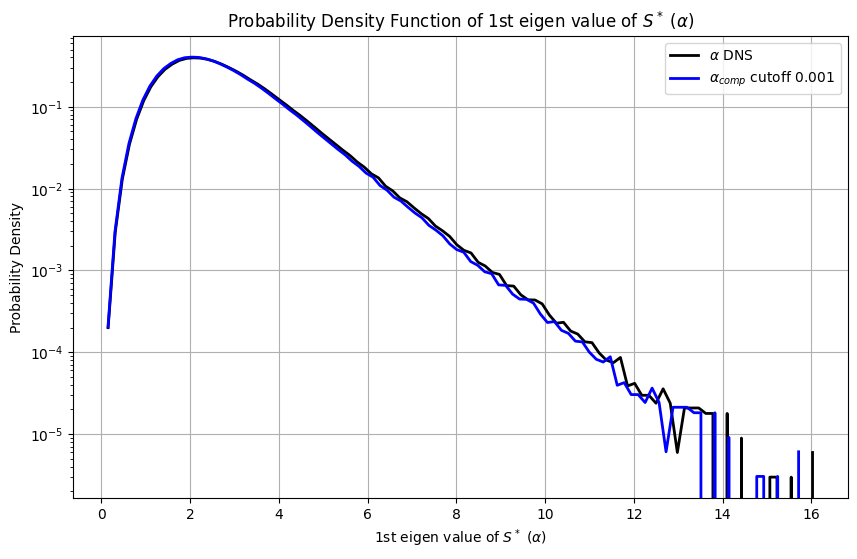

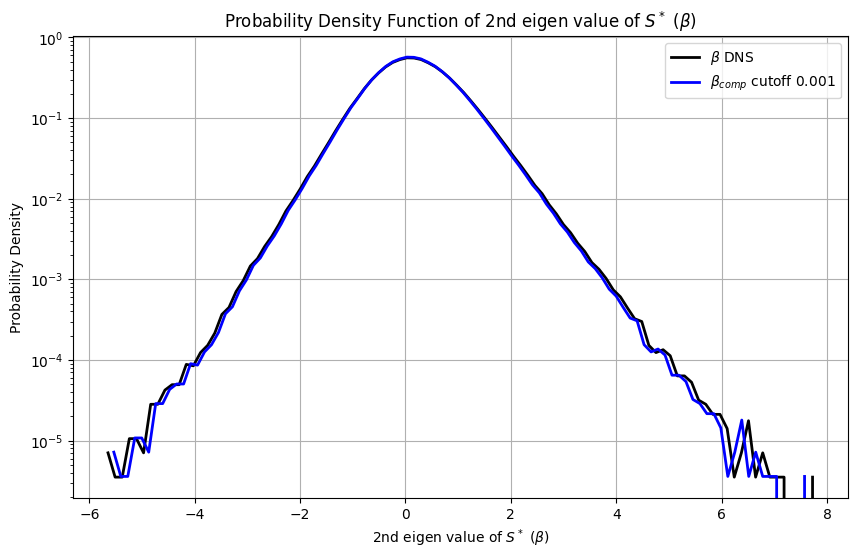

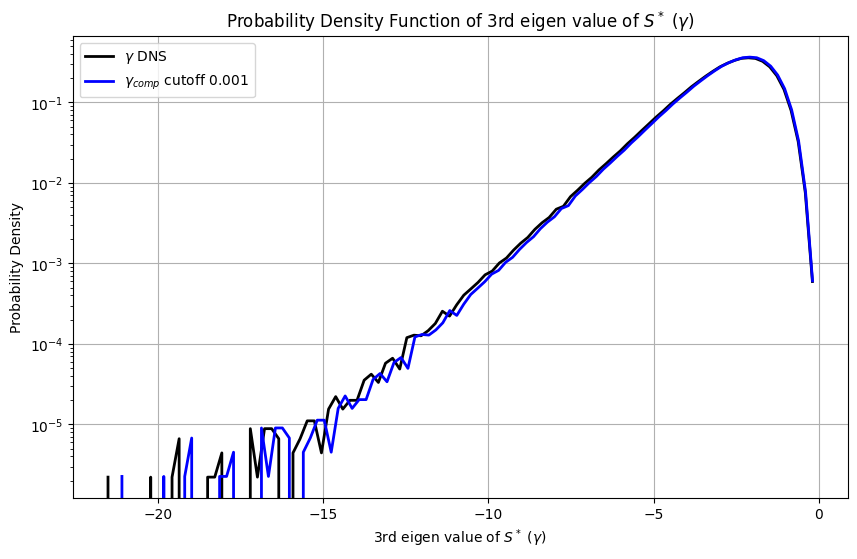

In [1]:
#PDF of stilde 
import numpy as np
from save_as_mat import load_h5
from plotting import plot_pdf
from calculate_eps_stilde import calculate_s_tilde
from save_as_mat import save_as_h5
import json
# mps_codes_path = "/ix/pgivi/moe32/Schmidt/Nik_code/code/AnalysingResultsFromDNS_demo/ComputationalSpaces/mps_py_codes"
# config_path = mps_codes_path + "/config_FI.json"
# with open(config_path, "r") as f:
#     config = json.load(f)

cutoff = 1e-3
# org_path = config.get("full_dns", {})
# alpha = load_h5(org_path['strain_rate']['alpha'])
# beta  = load_h5(org_path['strain_rate']['beta'])
# gamma = load_h5(org_path['strain_rate']['gamma'])
# s_tilde = load_h5(org_path['strain_rate']['s_tilde'])


alpha_comp = load_h5('Strain_rate_eigen_values_alpha.h5')
beta_comp = load_h5('Strain_rate_eigen_values_beta.h5')
gamma_comp = load_h5('Strain_rate_eigen_values_gamma.h5')

alpha = alpha_comp*1.02
beta  = beta_comp *1.02
gamma = gamma_comp*1.02

plot_pdf({rf'$\alpha$ DNS':alpha, rf'$\alpha_{{comp}}$ cutoff {cutoff}':alpha_comp},
         title=r'1st eigen value of $S^*$ ($\alpha$)', norm_dist=False,
         file_name='Strain_rate_eigen_values_alpha')

plot_pdf({rf'$\beta$ DNS':beta, rf'$\beta_{{comp}}$ cutoff {cutoff}':beta_comp},
         title=r'2nd eigen value of $S^*$ ($\beta$)', norm_dist=False,
         file_name='Strain_rate_eigen_values_beta')

plot_pdf({rf'$\gamma$ DNS':gamma, rf'$\gamma_{{comp}}$ cutoff {cutoff}':gamma_comp},
         title=r'3rd eigen value of $S^*$ ($\gamma$)', norm_dist=False,
         file_name='Strain_rate_eigen_values_gamma')


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from calculate_gradients import calculate_gradients, calculate_invariants, calculate_gradients_spectral
from plot_pdf import plot_pdf_invariants, plot_QR_joint_pdf


# M = np.array([[gradients['dux_dx'], gradients['dux_dy'], gradients['dux_dz']],
#             [gradients['duy_dx'], gradients['duy_dy'], gradients['duy_dz']],
#             [gradients['duz_dx'], gradients['duz_dy'], gradients['duz_dz']]])

# w_norm = compute_W_norm_3D(grad)
# w_norm = 1
# Compute Q, R, W_norm
div, Q, R = calculate_invariants(grad)
Q_numpy = Q/ (Qw_comp**2)
R_numpy = R/ (Qw_comp**3)

# Generate synthetic PyTorch tensor for comparison
import torch

# Convert NumPy grad (N, N, N, 3, 3) to PyTorch
grad_torch = torch.tensor(grad, dtype=torch.float32)  # Ensure dtype is correct

# Compute Q and R from friend's function
Q_torch = -0.5 * torch.einsum('...ij,...ji', grad_torch, grad_torch) / (Qw_comp**2)
R_torch = -(1/3) * torch.einsum('...ij,...jk,...ki', grad_torch, grad_torch, grad_torch) / (Qw_comp**3)

# Convert PyTorch tensors to NumPy for comparison
Q_torch_np = Q_torch.numpy()
R_torch_np = R_torch.numpy()

# Check if the values are approximately equal
print("Max absolute difference in Q:", np.max(np.abs(Q_numpy - Q_torch_np)))
print("Max absolute difference in R:", np.max(np.abs(R_numpy - R_torch_np)))

# Scatter plot for visual comparison
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.scatter(Q_numpy.flatten(), Q_torch_np.flatten(), alpha=0.5)
plt.xlabel("Q (NumPy)")
plt.ylabel("Q (Torch)")
plt.title("Q Comparison")

plt.subplot(1,2,2)
plt.scatter(R_numpy.flatten(), R_torch_np.flatten(), alpha=0.5)
plt.xlabel("R (NumPy)")
plt.ylabel("R (Torch)")
plt.title("R Comparison")

plt.tight_layout()
plt.show()

plot_QR_joint_pdf(Q_torch_np, R_torch_np, 1, contour_levels=5, percentile_threshold=95)
plot_QR_joint_pdf(Q_numpy, R_numpy, 1, contour_levels=5, percentile_threshold=95)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from calculate_gradients import calculate_gradients, calculate_invariants
from save_as_mat import save_as_h5
from process_file_1024 import load_JHS_velocity_1024
from process_file import load_JHS_velocity
from plot_pdf import plot_pdf_invariants, plot_QR_joint_pdf

u = load_JHS_velocity_1024(org_path_u)
v = load_JHS_velocity_1024(org_path_v)
w = load_JHS_velocity_1024(org_path_w)

order = 8

xcoor = 0.0061359406
# xcoor = xcoord[2]-xcoord[1]
ycoor = xcoor
zcoor = xcoor
velocity_field = (u, v, w)
h = (xcoor,ycoor,zcoor)

gradients = calculate_gradients(velocity_field, h, order=order)

save_as_h5('grad_dux_dx', 'dux_dx', gradients['dux_dx'])
save_as_h5('grad_dux_dy', 'dux_dy', gradients['dux_dy'])
save_as_h5('grad_dux_dz', 'dux_dz', gradients['dux_dz'])
save_as_h5('grad_duy_dx', 'duy_dx', gradients['duy_dx'])
save_as_h5('grad_duy_dy', 'duy_dy', gradients['duy_dy'])
save_as_h5('grad_duy_dz', 'duy_dz', gradients['duy_dz'])
save_as_h5('grad_duz_dx', 'duz_dx', gradients['duz_dx'])
save_as_h5('grad_duz_dy', 'duz_dy', gradients['duz_dy'])
save_as_h5('grad_duz_dz', 'duz_dz', gradients['duz_dz'])
print(" ")

# Calculate divergence, Q, and R
div, Q, R = calculate_invariants(gradients)

print("Divergence shape:", div.shape)
print("Second Invariant (Q) shape:", Q.shape)
print("Third Invariant (R) shape:", R.shape)
print(" ")

save_as_h5('first_invariant_div_8th_order','div', div)
save_as_h5('second_invariant_Q_8th_order','Q', Q)
save_as_h5('third_invariant_R_8th_order','R', R)

plot_pdf_invariants({'Div_8th_order':div}, title='Divergence (First Invariant)')
plt.savefig('PDF_div_1024Cubed.png', dpi=300, bbox_inches='tight')

plot_pdf_invariants({'Q_8th_order':Q}, title='Q (Second Invariant) ')
plt.savefig('PDF_Q_1024Cubed.png', dpi=300, bbox_inches='tight')

plot_pdf_invariants({'R_8th_order':R}, title='R (Third Invariant)')
plt.savefig('PDF_R_1024Cubed.png', dpi=300, bbox_inches='tight')

plot_QR_joint_pdf(Q, R)

plt.savefig('PDF_QR_Joint_1024Cubed_8th_order.png', dpi=300, bbox_inches='tight')

In [ ]:
# Define a 3D function (example: sin wave in the x-direction)
Nx, Ny, Nz = 64, 64, 64
Lx, Ly, Lz = 10, 10, 10  # Domain sizes
dx, dy, dz = Lx/Nx, Ly/Ny, Lz/Nz  # Grid spacings

# Create a 3D grid
x = np.linspace(-Lx/2, Lx/2, Nx, endpoint=False)
y = np.linspace(-Ly/2, Ly/2, Ny, endpoint=False)
z = np.linspace(-Lz/2, Lz/2, Nz, endpoint=False)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Define a test function f(x, y, z) = sin(2πx/Lx)
matrix = np.sin(2 * np.pi * X / Lx)

# Compute spectral derivative along x-axis (axis=0)
df_dx = spectral_derivative(matrix, axis=0, dx=dx, order=1)

# Compute analytical derivative: df/dx = (2π/Lx) * cos(2πx/Lx)
df_dx_exact = (2 * np.pi / Lx) * np.cos(2 * np.pi * X / Lx)

# Compute error
error = np.abs(df_dx - df_dx_exact).max()
print(f"Max error: {error}")

plt.plot(x, matrix[:,0,0], label="f(x) = sin(2πx/L)")
plt.plot(x,df_dx_exact[:,0,0],label="f'")
plt.plot(x, df_dx[:,0,0], label="df/dx (Fourier)", linestyle="dashed")
plt.legend()
plt.xlabel("x")
plt.ylabel("Function values")
plt.title("Derivative in Fourier Space")
plt.show()


In [ ]:
import numpy as np
from calculate_finite_difference import central_dif, finite_dif_4th_order_periodic
import matplotlib.pyplot as plt

# Define grid size and spacing
Nx, Ny, Nz = 64, 64, 64  # Grid size (should be large enough to test accuracy)
Lx = 1.0  # Domain length in x
dx = Lx / Nx  # Grid spacing

# Create a periodic function f(x, y, z) = sin(2πx)
x = np.linspace(0, Lx, Nx, endpoint=False)  # Ensure periodicity
y = np.linspace(0, Lx, Ny, endpoint=False)
z = np.linspace(0, Lx, Nz, endpoint=False)

X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
matrix = np.sin(2 * np.pi * X)  # Function f(x,y,z)

# Analytical derivative
exact_derivative = 2 * np.pi * np.cos(2 * np.pi * X)

# Compute numerical derivatives for different orders
orders = [2, 4, 6, 8]
numerical_derivatives = {order: central_dif(matrix, axis=0, dx=dx, order=order) for order in orders}
deriv = finite_dif_4th_order_periodic(matrix, axis=0, dx=dx)

# Compute absolute errors
errors = {order: np.abs(numerical_derivatives[order] - exact_derivative) for order in orders}
err = np.abs(deriv - exact_derivative)

# Plot numerical derivatives and exact solution
plt.figure(figsize=(10, 6))
plt.plot(x, exact_derivative[:, 0, 0], label="Exact Derivative", linestyle="dashed", color="black")
# plt.plot(x, deriv[:, 0, 0], label="deriv")
for order in orders:
    plt.plot(x, numerical_derivatives[order][:, 0, 0], label=f"{order}-Order", linestyle="solid", marker="o")

plt.xlabel("x")
plt.ylabel("Derivative")
plt.title("Comparison of Exact and Numerical Derivatives")
plt.legend()
plt.grid()
plt.show()

# Plot errors
plt.figure(figsize=(10, 6))
# for order in orders:
#     plt.plot(x, errors[order][:, 0, 0], label=f"Error {order}-Order", linestyle="solid", marker="x")
plt.plot(x, errors[4][:, 0, 0], label=f"Error {4}-Order", linestyle="solid", marker="x")
plt.plot(x, err[:, 0, 0], label="err")

plt.xlabel("x")
plt.ylabel("Absolute Error")
plt.title("Error in Numerical Derivatives")
plt.legend()
plt.grid()
plt.show()

In [ ]:
#log_spec

import matplotlib.pyplot as plt
import scipy.io

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
# eps = 0.0788
# eps = 0.001385190088068
eps = 8.8479e-02
C = 1

k_1 = np.ones_like(k_1024)

ax.plot(k_1024, spec_1024*eps**(-2/3) * k_1024**(5/3), label=r'1024 Cubed E(k) * $\epsilon^{-2/3} k^{5/3}$', linewidth=2)
ax.plot(k_1024, spec_c*eps**(-2/3) * k_1024**(5/3), label=r'COMP E(k) * $\epsilon^{-2/3} k^{5/3}$', linewidth=2)

# ax.plot(k_512, spec_512*eps**(-2/3) * k_512**(5/3), label=r'512 Cubed Subdomain E(k) * $\epsilon^{-2/3} k^{5/3}$', linewidth=2)
# ax.plot(k_128, spec_128*eps**(-2/3) * k_128**(5/3), label=r'128 Cubed Wholedomain E(k) * $\epsilon^{-2/3} k^{5/3}$', linestyle='-.', linewidth=2)
ax.plot(k_1024, C*1.6*k_1, label=r'$1.6$', color='black', linestyle='--', linewidth=2)

# Set log scale for both axes
ax.set_xscale('log')
ax.set_yscale('log')

# Add grid
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Add labels and title
ax.set_xlabel('Wavenumber (k)', fontsize=14)
ax.set_ylabel('Energy Spectrum', fontsize=14)
ax.set_title('Energy Spectrum Comparison', fontsize=16)

# Customize legend
ax.legend(loc='best', fontsize=12)
ax.set_xlim(1, 480)
ax.set_ylim(1e-2, 100)

# Display the plot
plt.tight_layout()
# plt.savefig('spectrum_plot_512Cubed.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
#inja
import matplotlib.pyplot as plt
import scipy.io

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
# eps = 0.0788
# eps = 0.001385190088068
eps = 0.088652
# eps = 0.09
# spectrum_cf_1e-05.mat
colors = ['#377eb8', '#4daf4a', '#ff7f00', '#984ea3', '#e41a1c']

spectrum_b_e3 = scipy.io.loadmat('spectrum_cf_0.001_beta_e3.mat')
spectrum_b_e4 = scipy.io.loadmat('spectrum_cf_0.0001_beta_e4.mat')
spectrum_b_e5 = scipy.io.loadmat('spectrum_cf_1e-05_beta_e5')
spectrum_b_e0 = scipy.io.loadmat('spectrum_cf_1e-05_beta_0.mat')


# spectrum_cf_e3_sp = scipy.io.loadmat('spectrum_cf_0.001_sp.mat')
# spectrum_cf_e3_sp_w = scipy.io.loadmat('spectrum_cf_0.001_weighted_sp.mat')
# spectrum_cf_e3_sp = spectrum_cf_e3_sp['spec'].T
# spectrum_cf_e3_sp_w = spectrum_cf_e3_sp_w['spec'].T

# C = 1/(2*128**6)
C = 1

k_1024 = spectrum_b_e3['k'].T
spec_1024 = spectrum_b_e3['spec'].T
spectrum_b_e3 = spectrum_b_e3['spec_comp'].T
spectrum_b_e4 = spectrum_b_e4['spec_comp'].T
spectrum_b_e5 = spectrum_b_e5['spec_comp'].T
spectrum_b_e0 = spectrum_b_e0['spec_comp'].T

ax.plot(k_1024, spec_1024, label='Original Data', linewidth=2, color=colors[0])
ax.plot(k_1024, spectrum_b_e0, label='beta 0   , CR = 9.1', linestyle='--', linewidth=2, color=colors[1])
ax.plot(k_1024, spectrum_b_e3, label='beta e-3, CR = 7.2', linestyle='--', linewidth=2, color=colors[2])
ax.plot(k_1024, spectrum_b_e4, label='beta e-4, CR = 7.6', linestyle='--', linewidth=2, color=colors[3])
ax.plot(k_1024, spectrum_b_e5, label='beta e-5, CR = 3.2', linestyle='--', linewidth=2, color=colors[4])


In [36]:
from compute_URDNS import compute_URDNS_uvw
from calculate_u_comp_fidelity_l2norm import calculate_fidelity
from process_file import load_JHS_velocity
from save_as_mat import save_as_mat

org_case = 'Forced_Isotropic'
org_name = 'U_t1'
# org_path = f'../Forced_Isotropic/01 Grid 64/Forced_Isotropic_64Cubed_h5/{org_name}.h5'
# org_path = f'../Forced_Isotropic/02 Grid 128/Forced_Isotropic_128Cubed_WholeDomain_h5/{org_name}.h5'
org_path = f'../Forced_Isotropic/02 Grid 128/Forced_Isotropic_128Cubed_SubDomain_h5/{org_name}.h5'
# org_path = f'../Forced_Isotropic/03 Grid 256/Forced_Isotropic_256Cubed_SubDomain_h5/{org_name}.h5'
# org_path = f'../../Forced_Isotropic_512Cubed_SubDomain_h5/{org_name}.h5'

u,v,w,xcoord,ycoord,zcoord = load_JHS_velocity(org_path)


# u_URDNS_64,v_URDNS_64,w_URDNS_64 = compute_URDNS_uvw(u,v,w, 64)
# u_URDNS_128,v_URDNS_128,w_URDNS_128 = compute_URDNS_uvw(u,v,w, 128)
# u_URDNS_256,v_URDNS_256,w_URDNS_256 = compute_URDNS_uvw(u,v,w, 256)
# u_URDNS_512,v_URDNS_512,w_URDNS_512 = compute_URDNS_uvw(u,v,w, 512)


# print("u fidelity_64: ",calculate_fidelity(u, u_URDNS_64))
# print("v fidelity_64: ",calculate_fidelity(v, v_URDNS_64))
# print("w fidelity_64: ",calculate_fidelity(w, w_URDNS_64))

# print("u fidelity_128: ",calculate_fidelity(u, u_URDNS_128))
# print("v fidelity_128: ",calculate_fidelity(v, v_URDNS_128))
# print("w fidelity_128: ",calculate_fidelity(w, w_URDNS_128))

# print("u fidelity_256: ",calculate_fidelity(u, u_URDNS_256))
# print("v fidelity_256: ",calculate_fidelity(v, v_URDNS_256))
# print("w fidelity_256: ",calculate_fidelity(w, w_URDNS_256))

# print("u fidelity_512: ",calculate_fidelity(u, u_URDNS_512))
# print("v fidelity_512: ",calculate_fidelity(v, v_URDNS_512))
# print("w fidelity_512: ",calculate_fidelity(w, w_URDNS_512))

# save_as_mat('u512_URDNS_64', {'u512_URDNS_64':u_URDNS_64,'v512_URDNS_64':v_URDNS_64, 'w512_URDNS_64':w_URDNS_64})
# save_as_mat('u512_URDNS_128', {'u512_URDNS_128':u_URDNS_128, 'v512_URDNS_128':v_URDNS_128, 'w512_URDNS_128':w_URDNS_128})
# save_as_mat('u512_URDNS_256', {'u512_URDNS_256':u_URDNS_256, 'v512_URDNS_256':v_URDNS_256, 'w512_URDNS_256':w_URDNS_256})


In [ ]:
dx1 = xcoord[101]-xcoord[100]

x = np.linspace(0, 2*np.pi, 1024)
dx2 = x[2] - x[1]
# print(dx1)
# print(dx2)

# 0.0061359406


In [ ]:
from save_as_mat import save_as_mat
from calculate_spectrum import calculate_spectrum
import scipy.io

file_name = 'u512_URDNS_64'
file_path = f'{file_name}.mat'
mat_data = scipy.io.loadmat(file_path)
u = mat_data['u512_URDNS_64']
v = mat_data['v512_URDNS_64']
w = mat_data['w512_URDNS_64']

k,spec = calculate_spectrum(u,v,w)
save_as_mat('spectrum_512_URDNS_64', {'k':k,'spec':spec})


In [ ]:
#pdf plot

import numpy as np
import matplotlib.pyplot as plt
from process_file import load_JHS_velocity
from plot_pdf import plot_pdf, plot_pdf_multiple
import scipy.io

org_case = 'Forced_Isotropic'
org_name = 'U_t1'
# org_path = f'../Forced_Isotropic/01 Grid 64/Forced_Isotropic_64Cubed_h5/{org_name}.h5'
org_path = f'../Forced_Isotropic/02 Grid 128/Forced_Isotropic_128Cubed_WholeDomain_h5/{org_name}.h5'
# org_path = f'../Forced_Isotropic/02 Grid 128/Forced_Isotropic_128Cubed_SubDomain_h5/{org_name}.h5'
# org_path = f'../Forced_Isotropic/03 Grid 256/Forced_Isotropic_256Cubed_SubDomain_h5/{org_name}.h5'
# org_path = f'../../Forced_Isotropic_512Cubed_SubDomain_h5{org_name}.h5'

u,v,w,_,_,_ = load_JHS_velocity(org_path)

comp_path_1 = f'SingVals_Forced_Isotropic_U_t1_U1_128cubed.mat'
comp_path_2 = f'SingVals_Forced_Isotropic_U_t1_U2_128cubed.mat'
comp_path_3 = f'SingVals_Forced_Isotropic_U_t1_U3_128cubed.mat'

# comp_path_1 = f'SingVals_Forced_Isotropic_U_t1_U1_512cubed.mat'
# comp_path_2 = f'SingVals_Forced_Isotropic_U_t1_U2_512cubed.mat'
# comp_path_3 = f'SingVals_Forced_Isotropic_U_t1_U3_512cubed.mat'
comp_paths = [comp_path_1, comp_path_2, comp_path_3]

mat_data = scipy.io.loadmat(comp_paths[0])
u_comp_e2 = mat_data['u_comp_e2']
u_comp_e3 = mat_data['u_comp_e3']
u_comp_e4 = mat_data['u_comp_e4']

mat_data = scipy.io.loadmat(comp_paths[1])
v_comp_e2 = mat_data['u_comp_e2']
v_comp_e3 = mat_data['u_comp_e3']
v_comp_e4 = mat_data['u_comp_e4']

mat_data = scipy.io.loadmat(comp_paths[2])
w_comp_e2 = mat_data['u_comp_e2']
w_comp_e3 = mat_data['u_comp_e3']
w_comp_e4 = mat_data['u_comp_e4']

num_bins = 100
# plot_pdf_multiple({'u': u, 'u_comp3': result_u['u_comp_e3']}, num_bins=100, chart_type='line')
plot_pdf_multiple({'u': u, 'u %99': u_comp_e2}, num_bins=num_bins, chart_type='line')
plt.savefig('PDF_u99_512Cubed.png', dpi=300, bbox_inches='tight')

# plot_pdf_multiple({'u': u, 'u %99.9': u_comp_e3}, num_bins=num_bins, chart_type='line')
# plt.savefig('PDF_u99.9_512Cubed.png', dpi=300, bbox_inches='tight')

# plot_pdf_multiple({'u': u, 'u %99.99': u_comp_e4}, num_bins=num_bins, chart_type='line')
# plt.savefig('PDF_u99.99_512Cubed.png', dpi=300, bbox_inches='tight')

# plot_pdf_multiple({'v': v, 'v %99': v_comp_e2}, num_bins=num_bins, chart_type='line')
# plt.savefig('PDF_v99_512Cubed.png', dpi=300, bbox_inches='tight')

# plot_pdf_multiple({'v': v, 'v %99.9': v_comp_e3}, num_bins=num_bins, chart_type='line')
# plt.savefig('PDF_v99.9_512Cubed.png', dpi=300, bbox_inches='tight')

# plot_pdf_multiple({'v': v, 'v %99.99': v_comp_e4}, num_bins=num_bins, chart_type='line')
# plt.savefig('PDF_v99.99_512Cubed.png', dpi=300, bbox_inches='tight')

# plot_pdf_multiple({'w': w, 'w %99': w_comp_e2}, num_bins=num_bins, chart_type='line')
# plt.savefig('PDF_w99_512Cubed.png', dpi=300, bbox_inches='tight')

# plot_pdf_multiple({'w': w, 'w %99.9': w_comp_e3}, num_bins=num_bins, chart_type='line')
# plt.savefig('PDF_w99.9_512Cubed.png', dpi=300, bbox_inches='tight')

# plot_pdf_multiple({'w': w, 'w %99.99': w_comp_e4}, num_bins=num_bins, chart_type='line')
# plt.savefig('PDF_w99.99_512Cubed.png', dpi=300, bbox_inches='tight')


In [ ]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt

def plot_pdf(data, plot_lim=None, plot_n = 128):
    kde = st.gaussian_kde(data, bw_method=0.5)

    if plot_lim is None:
        plot_lim = [np.min(data), np.max(data)]

    # plot density estimates
    data_range = np.linspace(plot_lim[0], plot_lim[1], plot_n)
    plt.plot(data_range, kde(data_range), label="Data")
    plt.xlim(plot_lim)
    plt.legend(loc='best')    
    plt.show()


x = np.random.normal(size=1000)
plot_pdf(x)
# plt.plot(x)


In [ ]:
x.shape

In [ ]:
#pdf plot

import numpy as np
# import h5py
# import matplotlib.pyplot as plt
# from plot_pdf import plot_pdf_multiple, plot_pdf_eps
from process_file_1024 import load_JHS_velocity_1024, load_JHS_velocity_1024_jul

cutoff = 1e-2
# comp_path_u = f'truncated_u_1024_il_cf0.01.mat'
# comp_path_v = f'truncated_v_1024_il_cf0.01.mat'
# comp_path_w = f'truncated_w_1024_il_cf0.01.mat'

# org_path_u = f'../../../Forced_Isotropic_1024Cubed_mat_in_one/U_t1.mat'
# org_path_v = f'../../../Forced_Isotropic_1024Cubed_mat_in_one/V_t1.mat'
# org_path_w = f'../../../Forced_Isotropic_1024Cubed_mat_in_one/W_t1.mat'


comp_path_u = f'../Julia/truncated_u_il_data.mat'
comp_path_v = f'../Julia/truncated_v_il_data.mat'
comp_path_w = f'../Julia/truncated_w_il_data.mat'

org_path_u = f'../Forced_Isotropic/02 Grid 128/U_t1.mat'
org_path_v = f'../Forced_Isotropic/02 Grid 128/V_t1.mat'
org_path_w = f'../Forced_Isotropic/02 Grid 128/W_t1.mat'

u = load_JHS_velocity_1024(org_path_u)
v = load_JHS_velocity_1024(org_path_v)
w = load_JHS_velocity_1024(org_path_w)


u_comp, chi_u = load_JHS_velocity_1024_jul(comp_path_u)
v_comp, chi_v = load_JHS_velocity_1024_jul(comp_path_v)
w_comp, chi_w = load_JHS_velocity_1024_jul(comp_path_w)

import h5py
import matplotlib.pyplot as plt
from plot_pdf import plot_pdf_multiple, plot_pdf_eps

num_bins = 100
ch_type = 'line'

plot_pdf_multiple({'U DNS': u, f'U cutoff = {cutoff}': u_comp}, num_bins=num_bins, chart_type=ch_type)
plt.savefig(f'PDF_u_cf_{cutoff}_1024Cubed.png', dpi=300, bbox_inches='tight')

plot_pdf_multiple({'V DNS': v, f'V cutoff = {cutoff}': v_comp}, num_bins=num_bins, chart_type=ch_type)
plt.savefig(f'PDF_v_cf_{cutoff}_1024Cubed.png', dpi=300, bbox_inches='tight')

plot_pdf_multiple({'W DNS': w, f'W cutoff = {cutoff}': w_comp}, num_bins=num_bins, chart_type=ch_type)
plt.savefig(f'PDF_w_cf_{cutoff}_1024Cubed.png', dpi=300, bbox_inches='tight')


# org_path = f'dissipation.mat'
# comp_path = f'dissipation_comp.mat'

# with h5py.File(org_path, 'r') as file:
#     eps = np.array(file['eps'])

# with h5py.File(comp_path, 'r') as file:
#     eps_comp = np.array(file['eps_comp'])


# plot_pdf_eps({'Dissipation DNS': eps, f'Dissipation cutoff={cutoff}': eps_comp}, num_bins=num_bins, chart_type=ch_type)
# plt.savefig(f'PDF_eps_cf_{cutoff}_1024Cubed.png', dpi=300, bbox_inches='tight')


In [ ]:
import numpy as np

max_bond = int(chi_u.shape[0])
# max_bond = 25
chi_max = np.zeros(max_bond)
for i in range(max_bond):
    if i<max_bond/2:
        chi_max[i] = int(2**(i+1))
    else:
        chi_max[i] = int(2**(max_bond-i))

# Create the x-axis values
x = np.arange(1, len(chi_max) + 1)

# Plot chi_max as a horizontal bar chart
plt.barh(x, chi_max, label='Chi max')

# Plot chi_u as a dashed line on top of the bar chart (horizontal line)
plt.plot(chi_u, x, 'r--', linewidth=2, label='Chi u')

# Add labels and title
plt.ylabel('Index')
plt.xlabel('Values')
plt.title('Schmidt spectrum')
plt.yticks(np.arange(1, len(chi_max) + 1, 2))  # Ticking every 2 indices

# Add a legend
plt.legend()

# Display the plot
plt.show()

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import scipy.io
from process_file import load_JHS_velocity
from plot_pdf import plot_pdf_multiple
from calculate_gradients import calculate_gradients
from calculate_eps_stilde import calculate_eps 
from save_as_mat import save_as_mat

nu=0.000185
org_case = 'Forced_Isotropic'
org_name = 'U_t1'
# org_path = f'../Forced_Isotropic/01 Grid 64/Forced_Isotropic_64Cubed_h5/{org_name}.h5'
    # org_path = f'../Forced_Isotropic/02 Grid 128/Forced_Isotropic_128Cubed_WholeDomain_h5/{org_name}.h5'
# org_path = f'../Forced_Isotropic/02 Grid 128/Forced_Isotropic_128Cubed_SubDomain_h5/{org_name}.h5'
# org_path = f'../Forced_Isotropic/03 Grid 256/Forced_Isotropic_256Cubed_SubDomain_h5/{org_name}.h5'
org_path = f'../../Forced_Isotropic_512Cubed_SubDomain_h5{org_name}.h5'

u,v,w,xcoord,ycoord,zcoord = load_JHS_velocity(org_case,org_name, org_path)
dx = xcoord[1] - xcoord[0]
dy = ycoord[1] - ycoord[0]
dz = zcoord[1] - zcoord[0]
h = np.array([dx, dy, dz])

# comp_path_1 = f'SingVals_Forced_Isotropic_U_t1_U1_128cubed.mat'
# comp_path_2 = f'SingVals_Forced_Isotropic_U_t1_U2_128cubed.mat'
# comp_path_3 = f'SingVals_Forced_Isotropic_U_t1_U3_128cubed.mat'

comp_path_1 = f'SingVals_Forced_Isotropic_U_t1_U_512cubed.mat'
comp_path_2 = f'SingVals_Forced_Isotropic_U_t1_V_512cubed.mat'
comp_path_3 = f'SingVals_Forced_Isotropic_U_t1_W_512cubed.mat'

comp_paths = [comp_path_1, comp_path_2, comp_path_3]

mat_data = scipy.io.loadmat(comp_paths[0])
u_comp_e2 = mat_data['u_comp_e2']
u_comp_e3 = mat_data['u_comp_e3']
u_comp_e4 = mat_data['u_comp_e4']

mat_data = scipy.io.loadmat(comp_paths[1])
v_comp_e2 = mat_data['u_comp_e2']
v_comp_e3 = mat_data['u_comp_e3']
v_comp_e4 = mat_data['u_comp_e4']

mat_data = scipy.io.loadmat(comp_paths[2])
w_comp_e2 = mat_data['u_comp_e2']
w_comp_e3 = mat_data['u_comp_e3']
w_comp_e4 = mat_data['u_comp_e4']

fd_scheme='4th_order_periodic'
gradients = calculate_gradients((u,v,w), h, finite_diff_scheme=fd_scheme)
gradients_comp_e2 = calculate_gradients((u_comp_e2,v_comp_e2,w_comp_e2), h, finite_diff_scheme=fd_scheme)
gradients_comp_e3 = calculate_gradients((u_comp_e3,v_comp_e3,w_comp_e3), h, finite_diff_scheme=fd_scheme)
gradients_comp_e4 = calculate_gradients((u_comp_e4,v_comp_e4,w_comp_e4), h, finite_diff_scheme=fd_scheme)

# Calculate the dissipation rates for original and compressed flow
dissipation_rate = calculate_dissipation_rate(gradients, nu)
dissipation_rate_comp_e2 = calculate_dissipation_rate(gradients_comp_e2, nu)
dissipation_rate_comp_e3 = calculate_dissipation_rate(gradients_comp_e3, nu)
dissipation_rate_comp_e4 = calculate_dissipation_rate(gradients_comp_e4, nu)

save_as_mat('dissipation_rate_512Cubed',{'eps': dissipation_rate})
save_as_mat('dissipation_rate_comp_e2_512Cubed',{'eps': dissipation_rate_comp_e2})
save_as_mat('dissipation_rate_comp_e3_512Cubed',{'eps': dissipation_rate_comp_e3})
save_as_mat('dissipation_rate_comp_e4_512Cubed',{'eps': dissipation_rate_comp_e4})  

num_bins = 1000
ch_type = 'line'
plot_pdf_multiple({'eps': dissipation_rate, 'eps %99': dissipation_rate_comp_e2}, num_bins=num_bins, chart_type=ch_type)
plt.savefig('PDF_eps99_512Cubed.png', dpi=300, bbox_inches='tight')

plot_pdf_multiple({'eps': dissipation_rate, 'eps %99.9': dissipation_rate_comp_e3}, num_bins=num_bins, chart_type=ch_type)
plt.savefig('PDF_eps99.9_512Cubed.png', dpi=300, bbox_inches='tight')

plot_pdf_multiple({'eps': dissipation_rate, 'eps %99.99': dissipation_rate_comp_e4}, num_bins=num_bins, chart_type=ch_type)
plt.savefig('PDF_eps99.99_512Cubed.png', dpi=300, bbox_inches='tight')


In [ ]:
from plot_pdf import plot_pdf_multiple
import scipy.io
import matplotlib.pyplot as plt

org_path = f'dissipation_rate_512Cubed.mat'

comp_path_1 = f'dissipation_rate_comp_e2_512Cubed.mat'
comp_path_2 = f'dissipation_rate_comp_e3_512Cubed.mat'
comp_path_3 = f'dissipation_rate_comp_e4_512Cubed.mat'

comp_paths = [comp_path_1, comp_path_2, comp_path_3]

# dissipation_rate = ((scipy.io.loadmat(org_path))['eps'])
# dissipation_rate_comp_e2 = ((scipy.io.loadmat(comp_paths[0]))['eps'])
# dissipation_rate_comp_e3 = ((scipy.io.loadmat(comp_paths[1]))['eps'])
# dissipation_rate_comp_e4 = ((scipy.io.loadmat(comp_paths[2]))['eps'])


dissipation_rate = ((scipy.io.loadmat(org_path))['eps'])[2:510, 2:510, 2:510]
dissipation_rate_comp_e2 = ((scipy.io.loadmat(comp_paths[0]))['eps'])[2:510, 2:510, 2:510]
dissipation_rate_comp_e3 = ((scipy.io.loadmat(comp_paths[1]))['eps'])[2:510, 2:510, 2:510]
dissipation_rate_comp_e4 = ((scipy.io.loadmat(comp_paths[2]))['eps'])[2:510, 2:510, 2:510]


num_bins = 100
ch_type = 'line'
plot_pdf_multiple({'eps': dissipation_rate, 'eps %99': dissipation_rate_comp_e2}, num_bins=num_bins, chart_type=ch_type)
plt.savefig('PDF_eps99_512Cubed.png', dpi=300, bbox_inches='tight')

plot_pdf_multiple({'eps': dissipation_rate, 'eps %99.9': dissipation_rate_comp_e3}, num_bins=num_bins, chart_type=ch_type)
plt.savefig('PDF_eps99.9_512Cubed.png', dpi=300, bbox_inches='tight')

plot_pdf_multiple({'eps': dissipation_rate, 'eps %99.99': dissipation_rate_comp_e4}, num_bins=num_bins, chart_type=ch_type)
plt.savefig('PDF_eps99.99_512Cubed.png', dpi=300, bbox_inches='tight')



In [ ]:
from plot_pdf import plot_pdf_eps
import scipy.io
import matplotlib.pyplot as plt

org_path = f'dissipation_rate_512Cubed.mat'

comp_path_1 = f'dissipation_rate_comp_e2_512Cubed.mat'
comp_path_2 = f'dissipation_rate_comp_e3_512Cubed.mat'
comp_path_3 = f'dissipation_rate_comp_e4_512Cubed.mat'

comp_paths = [comp_path_1, comp_path_2, comp_path_3]

# dissipation_rate = ((scipy.io.loadmat(org_path))['eps'])
# dissipation_rate_comp_e2 = ((scipy.io.loadmat(comp_paths[0]))['eps'])
# dissipation_rate_comp_e3 = ((scipy.io.loadmat(comp_paths[1]))['eps'])
# dissipation_rate_comp_e4 = ((scipy.io.loadmat(comp_paths[2]))['eps'])


dissipation_rate = ((scipy.io.loadmat(org_path))['eps'])[2:510, 2:510, 2:510]
dissipation_rate_comp_e2 = ((scipy.io.loadmat(comp_paths[0]))['eps'])[2:510, 2:510, 2:510]
dissipation_rate_comp_e3 = ((scipy.io.loadmat(comp_paths[1]))['eps'])[2:510, 2:510, 2:510]
dissipation_rate_comp_e4 = ((scipy.io.loadmat(comp_paths[2]))['eps'])[2:510, 2:510, 2:510]

# mean = dissipation_rate.mean()
# std = dissipation_rate.std()
# lognorm_params = (0.8, mean, std)  # trial and error
# lognorm_params = (1.198225, -0.000233, 0.040193)  # MLE
# lognorm_params = (1.027804, -0.014350, 0.056056)  # MM
# , lognorm_params=lognorm_params

num_bins = 100
ch_type = 'line'
plot_pdf_eps({'eps DNS': dissipation_rate, 'eps %99': dissipation_rate_comp_e2}, num_bins=num_bins, chart_type=ch_type)
plt.savefig('PDF_eps99_512Cubed.png', dpi=300, bbox_inches='tight')

# plot_pdf_eps({'eps DNS': dissipation_rate, 'eps %99.9': dissipation_rate_comp_e3}, num_bins=num_bins, chart_type=ch_type)
# plt.savefig('PDF_eps99.9_512Cubed.png', dpi=300, bbox_inches='tight')

# plot_pdf_eps({'eps DNS': dissipation_rate, 'eps %99.99': dissipation_rate_comp_e4}, num_bins=num_bins, chart_type=ch_type)
# plt.savefig('PDF_eps99.99_512Cubed.png', dpi=300, bbox_inches='tight')



In [ ]:
import numpy as np
import scipy.io
import scipy as sp
import h5py
from scipy.sparse.linalg import svds


# Specify the number of singular values to compute (e.g., k=1024)

# Generate a large random matrix of size 2^n x 2^n
n = 5
np.random.seed(10)
A = np.random.rand(2**n, 2**n)

# Perform Singular Value Decomposition (SVD)
# A = U * S * V^T
S = np.linalg.svd(A, full_matrices=False, compute_uv=False)
# U, S, Vt = np.linalg.svd(A, full_matrices=False)
# U, S, Vt = sp.linalg.svd(A, full_matrices=False)
S_d = np.diag(S)

# Step 1: Compute A^T A
A_tA = A.T @ A

# Step 2: Perform eigendecomposition of A^T A to get V and V^T
_, V_rec = np.linalg.eig(A_tA)

# Step 3: Now you have V and you can find U
U_rec = A @ V_rec @ np.linalg.inv(S_d)

A1 = U_rec @ S_d @ V_rec.T
diff=A1-A
print("diff norm: ",np.linalg.norm(diff))

# max_dim = min(A.shape[0]-1,100)
# U, S, Vt = svds(A, k=max_dim, which='LM')
# S = S[::-1]

# Save U as a .mat file in MATLAB 7.3 format using h5py (HDF5)
with h5py.File('U_matrix_7_3.mat', 'w') as f:
    f.create_dataset('U', data=U_rec)

# Save S as a separate .mat file in MATLAB 7.3 format using h5py (HDF5)
with h5py.File('S_matrix_7_3.mat', 'w') as f:
    f.create_dataset('S', data=S)

print("SVD complete, U and S matrices saved in separate MATLAB 7.3 format files.")




In [ ]:

import cupy as cp
import h5py
import time

module = cp.RawModule(code=my_cuda_code, options=(
    '--gpu-architecture=compute_70',
    '--gpu-code=sm_70'))


# Specify the number of singular values to compute (e.g., k=1024)

# Generate a large random matrix of size 2^n x 2^n on GPU
n = 15
cp.random.seed(10)
A = cp.random.rand(2**n, 2**n)

# Step 1: Compute A^T A
t0 = time.time()
A_tA = A.T @ A
t1 = time.time()
print("Time to compute A^T A: ", t1-t0)

# Step 2: Perform eigendecomposition of A^T A to get V and V^T
Eig, V_rec = cp.linalg.eig(A_tA)
S_rec = cp.diag(cp.sqrt(Eig))
t2 = time.time()
print("Time to compute eigen decomposition: ", t2-t1)

# Step 3: Now you have V and you can find U
U_rec = A @ V_rec @ cp.linalg.inv(S_rec)
t3 = time.time()
print("Time to compute U: ", t3-t2)

# Step 4: Reconstruct A
A_rec = U_rec @ S_rec @ V_rec.T
t4 = time.time()
print("Time to reconstruct A: ", t4-t3)

# Step 5: Compute the difference between the reconstructed A and original A
diff = A_rec - A
t5 = time.time()
print("Time to compute A_rec - A: ", t5-t4)
print("diff norm: ", cp.linalg.norm(diff))

# Convert back to NumPy to save the results in .mat format
U_rec_np = cp.asnumpy(U_rec)
S_rec_np = cp.asnumpy(S_rec)
V_rec_np = cp.asnumpy(V_rec)

# Save U, S, V as .mat files in MATLAB 7.3 format using h5py (HDF5)
with h5py.File('U_matrix_7_3.mat', 'w') as f:
    f.create_dataset('U', data=U_rec_np)

with h5py.File('S_matrix_7_3.mat', 'w') as f:
    f.create_dataset('S', data=S_rec_np)

with h5py.File('V_matrix_7_3.mat', 'w') as f:
    f.create_dataset('V', data=V_rec_np)

t6 = time.time()
print("Time to save U, S, V matrices: ", t6-t5)
print("SVD complete, U and S matrices saved in separate MATLAB 7.3 format files.")
t7 = time.time()
print("Total time: ", t7-t0)


In [ ]:
from process_file_1024 import process_file_1024
import numpy as np
from calculate_spectrum import calculate_spectrum
from process_file_1024 import load_JHS_velocity_1024
from calculate_flow_parameters_comb import calculate_flow_parameters
from save_as_mat import save_as_mat

org_name_u = 'U_t1'
org_name_v = 'V_t1'
org_name_w = 'W_t1'

# org_path_u = f'../Forced_Isotropic/02 Grid 128/{org_name_u}.mat'
# org_path_v = f'../Forced_Isotropic/02 Grid 128/{org_name_v}.mat'
# org_path_w = f'../Forced_Isotropic/02 Grid 128/{org_name_w}.mat'

org_path_u = f'../../../../Forced_Isotropic/5 Grid 1024/Forced_Isotropic_1024Cubed_mat_in_one/{org_name_u}.mat'
org_path_v = f'../../../../Forced_Isotropic/5 Grid 1024/Forced_Isotropic_1024Cubed_mat_in_one/{org_name_v}.mat'
org_path_w = f'../../../../Forced_Isotropic/5 Grid 1024/Forced_Isotropic_1024Cubed_mat_in_one/{org_name_w}.mat'

u = load_JHS_velocity_1024(org_name_u, org_path_u)
v = load_JHS_velocity_1024(org_name_v, org_path_v)
w = load_JHS_velocity_1024(org_name_w, org_path_w)
print("velocities loaded!")
nu= 0.000185
# dx = 0.049087387
# dx = 2*np.pi/1024
dy = dx
dz = dx

# parameters, spectrum = calculate_flow_parameters((u,v,w),nu,(dx,dy,dz),finite_diff_scheme='4th_order_zero')
parameters = calculate_flow_parameters((u,v,w),nu,(dx,dy,dz),finite_diff_scheme='4th_order_zero')

print("parameters:",parameters)
# print("wavenumbers (k):",spectrum['k'])
# print("spectrum:",spectrum['spec'])
save_as_mat('parameters_1024Cubed', parameters)
# save_as_mat('spectrum_1024Cubed',spectrum)


In [16]:
from process_file_1024 import process_file_1024
import numpy as np
from calculate_spectrum import calculate_spectrum
from process_file_1024 import load_JHS_velocity_1024
from process_file import load_JHS_velocity
from calculate_flow_parameters_comb import calculate_flow_parameters

org_name_u = 'U_t1'
org_name_v = 'V_t1'
org_name_w = 'W_t1'

org_path_u = f'../Forced_Isotropic/02 Grid 128/{org_name_u}.mat'
org_path_v = f'../Forced_Isotropic/02 Grid 128/{org_name_v}.mat'
org_path_w = f'../Forced_Isotropic/02 Grid 128/{org_name_w}.mat'

file_case = 'Forced_Isotropic'
file_name = 'U_t1'
file_format = '.h5'
file_path = f'../{file_case}/02 Grid 128/Forced_Isotropic_128Cubed_WholeDomain_h5/{file_name}{file_format}'

# file_case = 'Channelflow'
# file_path = f'../{file_case}/3D test/{file_name}{file_format}'
# file_path = f'../{file_case}/03 Grid 256/{file_name}{file_format}'
# file_path = f'../{file_case}/{file_name}{file_format}'

u = load_JHS_velocity_1024(org_path_u)
v = load_JHS_velocity_1024(org_path_v)
w = load_JHS_velocity_1024(org_path_w)

u1,v1,w1,xcoor,ycoor,zcoor = load_JHS_velocity(file_path)

nu= 0.000185
dx = 0.049087387
dy = dx
dz = dx

# parameters, spectrum = calculate_flow_parameters((u,v,w),nu,(dx,dy,dz))
# parameters = calculate_flow_parameters((u,v,w),nu,(dx,dy,dz))

# print("parameters 1024 form:",parameters)
# print("parameters addi form:",parameters1)

# print("wavenumbers (k):",spectrum['k'])
# print("spectrum:",spectrum['spec'])

In [ ]:
xcoor.shape

In [ ]:
import numpy as np
print(np.__version__)


In [ ]:
# parameters1 = calculate_flow_parameters((u1,v1,w1),nu,(dx,dy,dz))

import matplotlib.pyplot as plt
plt.contourf(xcoor, ycoor, u[:, :, 0].T, levels=20, cmap='jet')
plt.xlabel('x')
plt.ylabel('y')

In [ ]:
print("parameters 1024 form:",parameters)
print("parameters addi form:",parameters1)



In [ ]:
from process_file_1024 import process_file_1024
import numpy as np

file_case = 'Forced_Isotropic'
file_name = 'U_t1'
file_format = '.mat'
file_path = f'../{file_case}/01 Grid 64/{file_name}{file_format}'

# with h5py.File(file_path, 'r') as file:
#     print(list(file.keys()))  # This will list all groups/datasets in the file
#     u = file['UU1'][()]
# result_U, mps_Us, u_comp_e2, u_comp_e3, u_comp_e4 = process_file_1024(file_case,file_name,file_format,file_path)
result_U, _, _, _, _ = process_file_1024(file_case,file_name,file_format,file_path)
RT = result_U['RunTime']
print(f'Time taken to process {file_name}: {RT:.2f} seconds')
print("Chi_max:",np.transpose(result_U['Chi_max']))
for i in range(3):
    print(f'Chi_U[{i}]:',np.transpose(result_U['Chi_U'][:,i]))



In [ ]:
import os

file_names = ['U_t0', 'U_t1', 'U_t2', 'U_t3']
velocities = ['U', 'V', 'W']

n = 3  # number of velocities

# Read the content of the original .py file
with open('4FI_MPS_3D_512cubed_SubDomain.py', 'r') as py_file:
    py_content = py_file.readlines()

# Read the content of the original .slurm file
with open('4FI_MPS_3D_512cubed_SubDomain.slurm', 'r') as slurm_file:
    slurm_content = slurm_file.readlines()

# Loop over velocities and file names
for velocity_index in range(1, n+1):
    for file_name_index in range(1, 5):
        folder_name = f'{velocities[velocity_index-1]}'
        new_py_filename = os.path.join(folder_name, f'4FI_MPS_3D_512cubed_SubDomain_{file_names[file_name_index-1]}.py')
        new_slurm_filename = os.path.join(folder_name, f'4FI_MPS_3D_512cubed_SubDomain_{file_names[file_name_index-1]}.slurm')

        # Create the folder if it does not exist
        os.makedirs(folder_name, exist_ok=True)

        # Modify the content of the .py file
        py_new_content = []
        for line in py_content:
            if 'velocity_index =' in line:
                new_line = f'velocity_index = {velocity_index}\n'
                py_new_content.append(new_line)
            elif 'file_name_index =' in line:
                new_line = f'file_name_index = {file_name_index}\n'
                py_new_content.append(new_line)
            else:
                py_new_content.append(line)

        # Write the modified .py file
        with open(new_py_filename, 'w') as new_py_file:
            new_py_file.writelines(py_new_content)

        # Modify the content of the .slurm file
        slurm_new_content = []
        for line in slurm_content:
            if '#SBATCH --job-name=' in line:
                new_line = f'#SBATCH --job-name=512Fi{velocities[velocity_index-1]}{file_name_index}\n'
                slurm_new_content.append(new_line)
            else:
                slurm_new_content.append(line)

        # Write the modified .slurm file
        with open(new_slurm_filename, 'w') as new_slurm_file:
            new_slurm_file.writelines(slurm_new_content)

        print(f"Generated {new_py_filename} and {new_slurm_filename}.")

print("All files generated.")


In [ ]:
import numpy as np
import scipy.linalg
from block_svd import block_svd


def reconstruct_svd(U_blocks, S_blocks, Vt_blocks):
    # Combine U matrices
    U_full = np.vstack(U_blocks)

    # Create full S matrix
    S_full = scipy.linalg.block_diag(*[np.diag(S) for S in S_blocks])

    # Combine Vt matrices
    Vt_full = np.hstack(Vt_blocks)

    return U_full, S_full, Vt_full

# Example usage
n = 8
np.random.seed(10)
A = np.random.rand(2**n, 2**n)
block_size = 2**(n-1)
# U_blocks, S_blocks, Vt_blocks, A_reconstructed = block_svd(A, block_size)
U_true, S_true, Vt_true = np.linalg.svd(A)
U_blocks, S_blocks, Vt_blocks,_ = block_svd(A, block_size)

# Check if the reconstruction is close to the original matrix
# print("Reconstruction error:", np.linalg.norm(A - A_reconstructed))

# Example usage after block-wise SVD

# U_blocks, S_blocks, Vt_blocks, _ = block_svd(A, block_size)
# U_full, S_full, Vt_full = reconstruct_svd(U_blocks, S_blocks, Vt_blocks)
print("U, S, Vt shapes:",U_blocks[0].shape, S_blocks[0].shape, Vt_blocks[0].shape)
U_full = np.vstack(U_blocks)

# Create full S matrix
S_full = scipy.linalg.block_diag(*[np.diag(S) for S in S_blocks])

# Combine Vt matrices
Vt_full = np.hstack(Vt_blocks)

print("U, S, Vt shapes:",U_full.shape, S_full.shape, Vt_full.shape)

# Reconstruct the original matrix
# A_reconstructed = U_full @ S_full @ Vt_full

# Check if the reconstruction is close to the original matrix
print("Reconstruction error:", np.linalg.norm(A - A_reconstructed))


In [ ]:
import numpy as np

# Function to perform block-wise SVD using column-wise blocking
def blockwise_svd(A, block_size):
    U_blocks = []
    S_values = []
    Vt_blocks = []
    
    # Dividing A into blocks column-wise
    for j in range(0, A.shape[1], block_size):
        block = A[:, j:j + block_size]
        U, S, Vt = np.linalg.svd(block, full_matrices=False)
        U_blocks.append(U)
        S_values.append(S)
        Vt_blocks.append(Vt)

    # Combine U from blocks into a single U
    U = np.hstack(U_blocks)

    # Prepare the diagonal matrix S
    num_rows = A.shape[0]
    num_cols = A.shape[1]
    S = np.zeros((num_rows, num_cols))

    # Fill the diagonal matrix S with singular values
    current_col = 0
    for S_block in S_values:
        block_size = len(S_block)
        S[current_col:current_col + block_size, current_col:current_col + block_size] = np.diag(S_block)
        current_col += block_size  # Move to the next block

    # Combine Vt from blocks into a single Vt
    Vt = np.zeros((num_cols, num_cols))  # Initialize Vt to correct shape
    current_row = 0
    for Vt_block in Vt_blocks:
        num_block_rows = Vt_block.shape[0]
        Vt[current_row:current_row + num_block_rows, :Vt_block.shape[1]] = Vt_block
        current_row += num_block_rows

    return U, S, Vt

# Create a random matrix A
np.random.seed(0)  # For reproducibility
A = np.random.rand(100, 100)  # Large matrix

# Perform true SVD
U_true, S_true, Vt_true = np.linalg.svd(A, full_matrices=False)
S_true = np.diag(S_true)

# Perform block-wise SVD
block_size = 10
U_reconstructed, S_reconstructed, Vt_reconstructed = blockwise_svd(A, block_size)

# Comparing the results
# Check the shapes
print(f"Shape of True U: {U_true.shape}, Reconstructed U: {U_reconstructed.shape}")
print(f"Shape of True S: {S_true.shape}, Reconstructed S: {S_reconstructed.shape}")
print(f"Shape of True Vt: {Vt_true.shape}, Reconstructed Vt: {Vt_reconstructed.shape}")

# Check the reconstruction error for U, S, Vt
U_error = np.linalg.norm(U_true - U_reconstructed)
S_error = np.linalg.norm(S_true - S_reconstructed)
Vt_error = np.linalg.norm(Vt_true - Vt_reconstructed)

print(f"Reconstruction error for U: {U_error:.6f}")
print(f"Reconstruction error for S: {S_error:.6f}")
print(f"Reconstruction error for Vt: {Vt_error:.6f}")

# Verify the reconstruction of A
A_reconstructed = U_reconstructed @ S @ Vt_reconstructed
reconstruction_error = np.linalg.norm(A - A_reconstructed)

print(f"Reconstruction error for A: {reconstruction_error:.6f}")


In [ ]:
import numpy as np
import dask.array as da
import h5py
import time

t0 = time.time()
# Create the original NumPy array A with the same content
np.random.seed(10)
n = 15
A = np.random.rand(2**n, 2**n)
t1 = time.time()
print("Initialization time: ",t1-t0)

# Convert the NumPy array A to a Dask array with specific chunk sizes
# Here, you choose the chunk size as (20, 500) as you had earlier for demonstration
x = da.from_array(A, chunks=(2**(n-2), 2**(n-2)))  # Adjust chunk size based on your resources
t2 = time.time()
max_dim = min(A.shape[0], A.shape[1])
print("Chunking time and start of SVD: ",t2-t1)    

# Perform SVD compression with k=1000 (finding all singular values/vectors)
u, s, v = da.linalg.svd_compressed(x, k=max_dim, compute=True)
t3 = time.time()
print("SVD time: ",t3-t2)

# Compute the U, S, and V matrices
u_rec = u.compute()
v_rec = v.compute()
s_rec = np.diag(s.compute())
t4 = time.time()
print("Reshaping time: ",t4-t3)

# Reconstruct the matrix from U, S, and V
x_rec = u_rec @ s_rec @ v_rec
t5 = time.time()
print("Reconstruction time: ",t5-t4)



# Save U matrix separately
with h5py.File('U_7.3.mat', 'w') as f:
    f.create_dataset('U', data=u_rec)

# Save S matrix separately
with h5py.File('S_7.3.mat', 'w') as f:
    f.create_dataset('S', data=s_rec)

# Save V matrix separately
with h5py.File('V_7.3.mat', 'w') as f:
    f.create_dataset('V', data=v_rec)

t6 = time.time()
print("Saving time: ",t6-t5)
print("Total time: ",t6-t0)
print("Matrices saved separately as U_7.3.mat, S_7.3.mat, and V_7.3.mat in MATLAB v7.3 format.")

# Print the shape of the results for verification
print("Shape of computed U matrix:", u_rec.shape)
print("Shape of computed S matrix:", s_rec.shape)
print("Shape of computed V matrix:", v_rec.shape)

# Check if the reconstruction is close to the original matrix A
reconstruction_error = np.linalg.norm(A - x_rec)
print("Reconstruction error:", reconstruction_error)

# U_true, S_true, Vt_true = np.linalg.svd(A, full_matrices=False)
# S_true = np.diag(S_true)

# print("Error of U: ",np.linalg.norm(np.abs(u_rec) - np.abs(U_true)))
# print("Error of S: ",np.linalg.norm(s_rec - S_true))
# print("Error of V: ",np.linalg.norm(np.abs(v_rec) - np.abs(Vt_true)))

In [ ]:
from dask_cuda import LocalCluster
from dask.distributed import Client
import cupy as cp
import dask.array as da
from dask.array import linalg as da_linalg

# Step 1: Set up a LocalCluster for CUDA (GPU)
cluster = LocalCluster(
    n_workers=4,          # Number of GPUs (adjust based on available GPUs)
    threads_per_worker=1,  # Typically 1 thread per GPU worker
    memory_limit='16GB'    # Adjust memory limit per worker based on GPU memory
)
client = Client(cluster)

# Step 2: Set up CuPy-based random state for GPU arrays
rs = da.random.RandomState(RandomState=cp.random.RandomState)

# Step 3: Create the data on the GPU using Dask-CuPy
# Creating a random matrix (10 million rows, 20,000 columns) with chunking
x = rs.randint(0, 3, size=(10_000_000, 20_000), chunks=(20_000, 5_000), dtype="uint8")

# Persist the data in memory (on GPUs) for efficient reuse
x = x.persist()

# Step 4: Perform the SVD on the GPU-accelerated matrix
# `k=10` for compressed SVD finding the top 10 singular values/vectors
u, s, v = da_linalg.svd_compressed(x, k=10, seed=rs)

# Step 5: Compute the V matrix (or U, S as needed) and bring the result to CPU
v_rec = v.compute()

# Step 6: (Optional) If needed, move the result from GPU (CuPy) to CPU (NumPy)
v_rec_cpu = cp.asnumpy(v_rec)

# Output the result shape for verification
print("Shape of computed V matrix on GPU:", v_rec.shape)


In [ ]:
import numpy as np
import scipy.linalg

def reconstruct_svd(U_blocks, S_blocks, Vt_blocks):
    # Combine U matrices
    U_full = np.vstack(U_blocks)

    # Create full S matrix
    # Assuming S_blocks contains 1D arrays of singular values
    S_full = np.zeros((U_full.shape[1], U_full.shape[1]))  # Ensure S is square
    for i, S in enumerate(S_blocks):
        S_full[i, i] = S  # Place the singular values on the diagonal

    # Combine Vt matrices
    Vt_full = np.hstack(Vt_blocks)

    return U_full, S_full, Vt_full

# Assuming your block_svd function gives you U_blocks, S_blocks, Vt_blocks
U_blocks, S_blocks, Vt_blocks, _ = block_svd(A, block_size)

# Reconstruct U, S, Vt
U_full, S_full, Vt_full = reconstruct_svd(U_blocks, S_blocks, Vt_blocks)

# Check dimensions
print("U_full shape:", U_full.shape)  # Should be (512, total_ranks)
print("S_full shape:", S_full.shape)  # Should be (total_ranks, total_ranks)
print("Vt_full shape:", Vt_full.shape)  # Should be (total_ranks, 512)

# Reconstruct the original matrix
A_reconstructed = U_full @ S_full @ Vt_full

# Check if the reconstruction is close to the original matrix
print("Reconstruction error:", np.linalg.norm(A - A_reconstructed))


In [ ]:
import numpy as np
import scipy.io
import scipy as sp
import h5py
from scipy.sparse.linalg import svds
import time
#import mkl
#mkl.set_num_threads(32)

# Specify the number of singular values to compute (e.g., k=1024)

# Generate a large random matrix of size 2^n x 2^n
n = 10
np.random.seed(10)
A = np.random.rand(2**n, 2**n)

# Perform Singular Value Decomposition (SVD)
# A = U * S * V^T
# S = np.linalg.svd(A, full_matrices=False, compute_uv=False)
# U_true, S_true, Vt_true = np.linalg.svd(A, full_matrices=False)
# U, S, Vt = sp.linalg.svd(A, full_matrices=False)
# S_d = np.diag(S)

t0 = time.time()
# Step 1: Compute A^T A

A_tA = A.T @ A
t1 = time.time()
print("Time to compute A^T A: ",t1-t0)

# Step 2: Perform eigendecomposition of A^T A to get V and V^T
Eig, V_rec = np.linalg.eig(A_tA)
S_rec = np.diag(np.sqrt(Eig))
t2 = time.time()
print("Time to compute eigen decomposition: ",t2-t1)

# Step 3: Now you have V and you can find U
U_rec = A @ V_rec @ np.linalg.inv(S_rec)
t3= time.time()
print("Time to compute U: ",t3-t2)

A_rec = U_rec @ S_rec @ V_rec.T
t4 = time.time()
print("Time to reconstruct A: ",t4-t3)

diff=A_rec-A
t5 = time.time()
print("Time to diff A_rec - A: ",t5-t4)
print("diff norm: ",np.linalg.norm(diff))

# max_dim = min(A.shape[0]-1,100)
# U, S, Vt = svds(A, k=max_dim, which='LM')
# S = S[::-1]

# Save U as a .mat file in MATLAB 7.3 format using h5py (HDF5)
with h5py.File('U_matrix_7_3.mat', 'w') as f:
    f.create_dataset('U', data=U_rec)

# Save S as a separate .mat file in MATLAB 7.3 format using h5py (HDF5)
with h5py.File('S_matrix_7_3.mat', 'w') as f:
    f.create_dataset('S', data=S_rec)

with h5py.File('V_matrix_7_3.mat', 'w') as f:
    f.create_dataset('V', data=S_rec)
t6 = time.time()
print("Time to save U, S, V matrices: ",t6-t5)
print("SVD complete, U and S matrices saved in separate MATLAB 7.3 format files.")
t7 = time.time()
print("Total time: ",t7-t0)

In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

s = 50
df = pd.DataFrame({"price":np.random.randint(30,120, s),"volume":np.random.randint(1,5, s)})

fig, ax = plt.subplots(2, figsize=[10,6])

df.loc[:,"volume"].plot(ax=ax[0], kind="hist", bins=3)
# reshape for a heatmap... put price into bins and make 2D
dfh = df.assign(pbin=pd.qcut(df.price,6)).groupby(["pbin","volume"]).mean().unstack(1).droplevel(0,axis=1)
axh = sns.heatmap(dfh, ax=ax[1])

In [4]:
with h5py.File('U_t2.h5', 'r') as file:
    velocity_dataset = file['Velocity_1001']   
    vel = velocity_dataset[()]

y = vel[:, :, :, 1] # u = (u1,u2,u3) -> u1 = vel[:, :, :, 1], u2 = vel[:, :, :, 2, u3 = vel[:, :, :, 3]
file_path = 'SVt_u0'

In [ ]:
import h5py

with h5py.File('U_t1.h5', 'r') as f:
    userblock_size = f.userblock_size
    print(f"User Block Size: {userblock_size}")
    for key, value in f.attrs.items():
        print(f"{key}: {value}")

    print(f"Library version bounds: {f.libver}")
    print(h5py.__version__)


In [ ]:
h5py.__version__

In [ ]:
vel.shape

In [ ]:
tstart_values = [1, 501, 1001, 1501, 2001, 2501, 3001, 3501, 4001, 4501, 5001]
print(tstart_values)
print(len(tstart_values))


In [112]:
import h5py
import scipy.io

# Function to recursively convert HDF5 groups to dictionaries
def h5_to_dict(h5_group):
    result = {}
    for key in h5_group:
        if isinstance(h5_group[key], h5py.Dataset):
            result[key] = h5_group[key][:]
        elif isinstance(h5_group[key], h5py.Group):
            result[key] = h5_to_dict(h5_group[key])
    return result

# Load the .h5 file
# h5_file_path = './Forced_Isotropic_64Cubed_h5/U_t10.h5'
# mat_file_path = './Forced_Isotropic_64Cubed_mat/vel_t10.mat'


h5_file_path = './Forced_Isotropic/03 Grid 256/Forced_Isotropic_256Cubed_SubDomain_h5/U_t3.h5'
mat_file_path = './Forced_Isotropic/03 Grid 256/Forced_Isotropic_256Cubed_SubDomain_mat/U_t3.mat'
# h5_file_path = './Channelflow/04 Grid 512/Channelflow_grid_512_h5/U_t201_whole_domain_512x512x512/U_t201.h5'
# mat_file_path = './Channelflow/04 Grid 512/Channelflow_grid_512_h5/U_t201_whole_domain_512x512x512/U_t201.mat'


with h5py.File(h5_file_path, 'r') as h5_file:
    data_dict = h5_to_dict(h5_file)

# Save the data to a .mat file
scipy.io.savemat(mat_file_path, data_dict)
# print(filename)


In [ ]:
h5_source_path = './Channelflow_grid_256_h5/U_100snapshots_xFixedPlanes_256x256x1/x'
mat_source_path = './Channelflow_grid_256_mat/U_100snapshots_xFixedPlanes_256x256x1/x'
tstart = list(range(1, 4000, 40))
x_fixed = (124, 724, 1324, 1924) 
x_name = str(x_fixed[3])+'/'
for t in tstart:
    h5_file_name = f"U_t{t}.h5"
    mat_file_name = f"U_x{x_fixed[3]}_t{t}.mat"
    h5_file_path = h5_source_path + x_name + h5_file_name 
    mat_file_path = mat_source_path + x_name + mat_file_name 

    with h5py.File(h5_file_path, 'r') as h5_file:
        data_dict = h5_to_dict(h5_file)

    # Save the data to a .mat file
    scipy.io.savemat(mat_file_path, data_dict)
    print(mat_file_name)

In [ ]:
import os
import shutil
import numpy as np
import time
from pyJHTDB import libJHTDB



Part = 3

x1 = 1
x1_end = 512
x2 = 513
x2_end = 1024

# List of tuples for each part: (xstart, xend, ystart, yend, zstart, zend)
parts = [
    (x1, x1_end, x1, x1_end, x1, x1_end),
    (x1, x1_end, x1, x1_end, x2, x2_end),
    (x1, x1_end, x2, x2_end, x1, x1_end),
    (x1, x1_end, x2, x2_end, x2, x2_end),
    (x2, x2_end, x1, x1_end, x1, x1_end),
    (x2, x2_end, x1, x1_end, x2, x2_end),
    (x2, x2_end, x2, x2_end, x1, x1_end),
    (x2, x2_end, x2, x2_end, x2, x2_end)
]


params = {
    "dataset": "isotropic1024coarse",
    "fields": "u",
    "tstart": 1,
    "tend": 1,
    "tstep": 1,
    "xstart": 1,
    "ystart": 1,
    "zstart": 1,
    "xend": 256,
    "yend": 256,
    "zend": 256,
    "xstep": 256,
    "ystep": 128,
    "zstep": 64,
    "Filter_Width": 1,
    "output_filename": "U_tot",
    "token": "edu.pitt.ROP56-8d4f03b7"
}


# Assign the constant parameters to variables
auth_token = params["token"]
tstep = int(params.get("tstep"))
xstart = int(params.get("xstart"))
ystart = int(params.get("ystart"))
zstart = int(params.get("zstart"))
xend = int(params.get("xend"))
yend = int(params.get("yend"))
zend = int(params.get("zend"))
xstep = int(params.get("xstep", 1))
ystep = int(params.get("ystep", 1))
zstep = int(params.get("zstep", 1))
Filter_Width = int(params.get("Filter_Width", 1))
fields = params.get("fields", "u")
data_set = params.get("dataset", "isotropic1024coarse")

# List of tstart values
# tstart_values = [1, 501, 1001, 1501, 2001, 2501, 3001, 3501, 4001, 4501, 5001]
tstart_values = [1, 501, 1001, 1501]
# Get the values for the given part

xstart, xend, ystart, yend, zstart, zend = parts[Part - 1]
# tstart_values = list(range(1, 5002, 500))


# Initialize the JHTDB library
lJHTDB = libJHTDB()
lJHTDB.initialize()
lJHTDB.add_token(auth_token)

# Loop over tstart values
for idx, tstart in enumerate(tstart_values):
    tend = tstart 
    output_filename = f"U_t{idx}_P" + str(Part)
    
    start_run = time.time()
    
    result = lJHTDB.getbigCutout(
        data_set=data_set, fields=fields, t_start=tstart, t_end=tend, t_step=tstep,
        start=np.array([xstart, ystart, zstart], dtype='double'),
        end=np.array([xend, yend, zend], dtype='double'),
        step=np.array([xstep, ystep, zstep], dtype='double'),
        filter_width=Filter_Width,
        filename=output_filename)

    end_run = time.time()
    elapsed_time = end_run - start_run
    # snapshots = np.arange(tstart, tend, tstep)
    dt = 0.002
    times = (tend-1) * dt
    details_filename = f'details_{output_filename}'

    with open(details_filename+'.txt', 'w') as file:
        file.write('Run time:\n')
        file.write(str(elapsed_time)+' (s)\n')
        file.write(str(elapsed_time/60)+' (min)\n')
        file.write(str(elapsed_time/3600)+' (hr)\n \n')
        file.write('each snapshot size:'+ str(result.shape) + '\n')
        file.write('snapshot:'+ str(tend) + '\n')
        file.write('time(s):'+ str(times) + '\n')



    print(output_filename)
    

lJHTDB.finalize()
print(result.shape)


In [ ]:
import matplotlib as plt

print(result.shape)
fig = plt.figure(figsize = (20, 40))
a = fig.add_subplot(121)
#a.set_axis_off()
a.imshow(result[0,:,:,0],
         extent = [0, 3.14, 0, 2],
         interpolation = 'none')

In [2]:
import matplotlib.pyplot as plt

def plot_cp_over_x(file_path, n):
    # Initialize lists to hold the X and Cp values
    X = []
    Cp = []

    # Read the file manually to handle inconsistencies
    with open(file_path, 'r') as file:
        # Skip the header lines
        for _ in range(10):
            next(file)
        
        # Process each line after the header
        for line in file:
            if line.strip():  # Ignore empty lines
                try:
                    columns = line.split()
                    X.append(float(columns[3]))  # X is the 4th column (index 3)
                    Cp.append(float(columns[12]))  # Cp is the 13th column (index 12)
                except (IndexError, ValueError):
                    # Handle any lines that don't match the expected format
                    continue

    # Plot Cp over X
    # plt.figure(figsize=(10, 6))
    plt.plot(X[:n], Cp[:n], marker='o')
    plt.gca().invert_yaxis()  # Invert the y-axis
    plt.xlabel('X')
    plt.ylabel('Cp')
    plt.title('Pressure Coefficient (Cp) over X')
    plt.grid(True)
    plt.show()


In [ ]:
plt.plot(X[90:107], Cp[90:107], marker='o')
plt.gca().invert_yaxis()
plt.xlabel('X')
plt.ylabel('Cp')
plt.title('Pressure Coefficient (Cp) over X')
plt.grid(True)
plt.show()

In [ ]:
file_path = '/Users/massen/Downloads/n0012_3t0.prout'
plot_cp_over_x(file_path, 177)

In [ ]:
file_path = '/Users/massen/Downloads/n0012_4t0.prout'
plot_cp_over_x(file_path, 352)

In [ ]:
# Example usage
file_path = '/Users/massen/Downloads/n0012_5t0.prout'
plot_cp_over_x(file_path, 704)

In [ ]:
import matplotlib.pyplot as plt

def plot_cf_over_x(file_path,n):
    # Initialize lists to hold the X and Cf values
    X = []
    Cf = []

    # Read the file manually to handle inconsistencies
    with open(file_path, 'r') as file:
        # Skip the first 189 lines
        for _ in range(n):
            next(file)
        
        # Process each line after the header
        for line in file:
            if line.strip():  # Ignore empty lines
                try:
                    columns = line.split()
                    X.append(float(columns[3]))  # X is the 4th column (index 3)
                    Cf.append(float(columns[9]))  # Cf is the 10th column (index 9)
                except (IndexError, ValueError):
                    # Handle any lines that don't match the expected format
                    continue

    # Plot Cf over X
    # plt.figure(figsize=(10, 6))
    plt.plot(X, Cf, marker='o')
    plt.xlabel('X')
    plt.ylabel('Cf')
    plt.title('Friction Coefficient (Cf) over X')
    plt.grid(True)
    plt.show()
    print(Cf)

# Example usage
file_path = '/Users/massen/Downloads/n0012_3t0.prout'
plot_cf_over_x(file_path,189)


In [ ]:
file_path = '/Users/massen/Downloads/n0012_4t0.prout'
plot_cf_over_x(file_path,365)

In [ ]:
file_path = '/Users/massen/Downloads/n0012_5t0.prout'
plot_cf_over_x(file_path,717)

In [ ]:
import os
import shutil
import numpy as np
import time
from pyJHTDB import libJHTDB



Part = 1

x1 = 1
x1_end = 512
x2 = 513
x2_end = 1024

# List of tuples for each part: (xstart, xend, ystart, yend, zstart, zend)
parts = [
    (x1, x1_end, x1, x1_end, x1, x1_end),
    (x1, x1_end, x1, x1_end, x2, x2_end),
    (x1, x1_end, x2, x2_end, x1, x1_end),
    (x1, x1_end, x2, x2_end, x2, x2_end),
    (x2, x2_end, x1, x1_end, x1, x1_end),
    (x2, x2_end, x1, x1_end, x2, x2_end),
    (x2, x2_end, x2, x2_end, x1, x1_end),
    (x2, x2_end, x2, x2_end, x2, x2_end)
]


params = {
    "dataset": "channel",
    "fields": "u",
    "tstart": 1,
    "tend": 1,
    "tstep": 1,
    "xstart": 1,
    "ystart": 1,
    "zstart": 1,
    "xend": 256,
    "yend": 256,
    "zend": 256,
    "xstep": 128,
    "ystep": 128,
    "zstep": 128,
    "Filter_Width": 1,
    "output_filename": "U_tot",
    "token": "edu.pitt.ROP56-8d4f03b7"
}


# Assign the constant parameters to variables
auth_token = params["token"]
tstep = int(params.get("tstep"))
xstart = int(params.get("xstart"))
ystart = int(params.get("ystart"))
zstart = int(params.get("zstart"))
xend = int(params.get("xend"))
yend = int(params.get("yend"))
zend = int(params.get("zend"))
xstep = int(params.get("xstep", 1))
ystep = int(params.get("ystep", 1))
zstep = int(params.get("zstep", 1))
Filter_Width = int(params.get("Filter_Width", 1))
fields = params.get("fields", "u")
data_set = params.get("dataset", "isotropic1024coarse")

# List of tstart values
# tstart_values = [1, 501, 1001, 1501, 2001, 2501, 3001, 3501, 4001, 4501, 5001]
tstart_values = [1001]

# Get the values for the given part

xstart, xend, ystart, yend, zstart, zend = parts[Part - 1]
# tstart_values = list(range(1, 5002, 500))


# Initialize the JHTDB library
lJHTDB = libJHTDB()
lJHTDB.initialize()
lJHTDB.add_token(auth_token)

# Loop over tstart values
for idx, tstart in enumerate(tstart_values):
    tend = tstart 
    output_filename = f"U_t{idx+2}_P" + str(Part)
    
    start_run = time.time()
    
    result = lJHTDB.getbigCutout(
        data_set=data_set, fields=fields, t_start=tstart, t_end=tend, t_step=tstep,
        start=np.array([xstart, ystart, zstart], dtype='double'),
        end=np.array([xend, yend, zend], dtype='double'),
        step=np.array([xstep, ystep, zstep], dtype='double'),
        filter_width=Filter_Width,
        filename=output_filename)

    end_run = time.time()
    elapsed_time = end_run - start_run
    # snapshots = np.arange(tstart, tend, tstep)
    dt = 0.002
    times = (tend-1) * dt
    details_filename = f'details_{output_filename}'

    with open(details_filename+'.txt', 'w') as file:
        file.write('Run time:\n')
        file.write(str(elapsed_time)+' (s)\n')
        file.write(str(elapsed_time/60)+' (min)\n')
        file.write(str(elapsed_time/3600)+' (hr)\n \n')
        file.write('each snapshot size:'+ str(result.shape) + '\n')
        file.write('snapshot:'+ str(tend) + '\n')
        file.write('time(s):'+ str(times) + '\n')



    print(output_filename)
    

lJHTDB.finalize()
print(result.shape)

/var/folders/r5/t2snqk2n1ps1l1ghz__b_mg40000gn/T/ipykernel_69270/1784309500.py:65: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(["0","","10","","20","","30","","40"],fontsize=14)


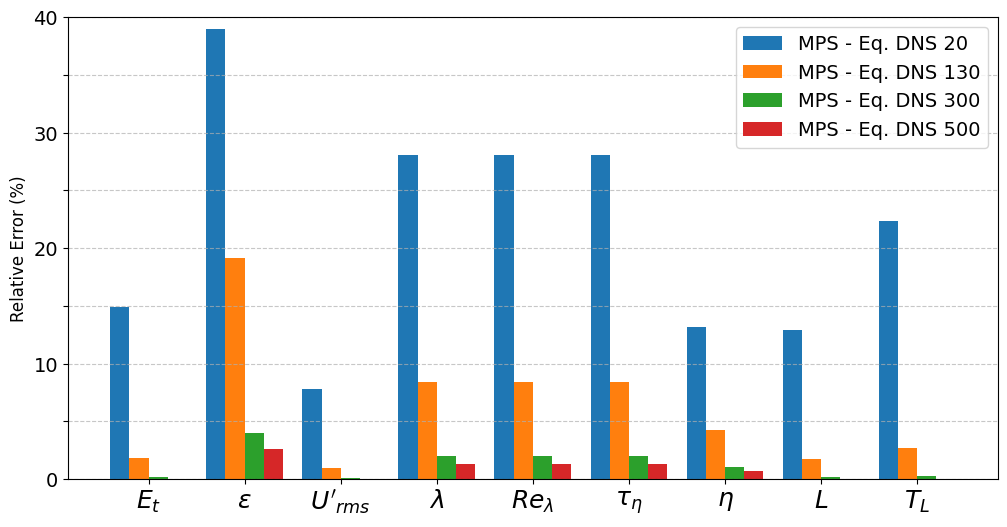

In [42]:
#PowerPoint
#Relative error of scalar statistics

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Data from the table
variables = [
    r"$E_{t}$",               # Total kinetic energy
    r"$\epsilon$",        # Dissipation (mean)
    r"$U'_{rms}$",        # RMS velocity
    r"$\lambda$",         # Taylor Micro. Scale
    r"$Re_\lambda$",      # Taylor-scale Reynolds
    r"$\tau_{\eta}$",       # Kolmogorov time scale
    r"$\eta$",            # Kolmogorov length scale
    r"$L$",               # Integral scale
    r"$T_L$"              # Large eddy turnover time
]

# variables = [
#     "Total kinetic energy", "Dissipation (mean)", "RMS velocity",
#     "Taylor Micro. Scale", "Taylor-scale Reynolds", "Kolmogorov time scale",
#     "Kolmogorov length scale", "Integral scale", "Large eddy turnover time"
# ]

# JHS data
dns_values = [0.6919, 0.0919, 0.6792, 0.1180, 433.36, 0.0449, 0.0029, 0.6808, 1.0024]
errors = {
    "MPS - Eq. DNS 20": [14.9186, 38.9910, 7.7604, 28.0274, 28.0274, 28.0274, 13.1492, 12.8675, 22.3634],
    "MPS - Eq. DNS 130": [1.8340, 19.1635, 0.9213, 8.3930, 8.3930, 8.3930, 4.2885, 1.7346, 2.6806],
    "MPS - Eq. DNS 300": [0.1836, 3.9555, 0.0919, 2.0384, 2.0384, 2.0384, 1.0141, 0.1779, 0.2700],
    "MPS - Eq. DNS 500": [0.0160, 2.6325, 0.0080, 1.3428, 1.3428, 1.3428, 0.6692, 0.0158, 0.0238]
}

# # Daniel's data
# dns_values = [1.5474, 1.0627, 1.0157, 0.0853, 173.32, 0.0217, 0.0033, 0.5347, 0.5265]
# errors = {
#     "1e-2": [16.4959, 6.4519, 8.6194, 3.3909, 3.3909, 3.3909, 1.6813, 16.2158, 27.1778],
#     "1e-3": [1.6983, 4.7698, 0.8528, 2.4738, 2.4738, 2.4738, 1.2293, 1.6198, 2.4938],
#     "1e-4": [0.1707, 0.2916, 0.0854, 0.1461, 0.1461, 0.1461, 0.0730, 0.1650, 0.2506],
#     "1e-5": [0.0152, 1.0678, 0.0076, 0.5382, 0.5382, 0.5382, 0.2688, 0.0149, 0.0225]
# }

# Create DataFrame
df = pd.DataFrame(errors, index=variables)


# ------------------ Bar Chart ------------------
fig, ax = plt.subplots(figsize=(12, 6))
width = 0.2
x = np.arange(len(variables))

# Plot bars for each cutoff level
for i, (cutoff, values) in enumerate(errors.items()):
    ax.bar(x + i * width - 0.1, values, width, label=f"{cutoff}")

# Formatting
# ax.set_xlabel(f"\nTurbulent Flow Statistics", fontsize=12)
ax.set_ylim(0, 40)

# ax.set_ylim(1e-2, 1e2)
# ax.set_yscale("log")
ax.set_ylabel("Relative Error (%)", fontsize=12)
ax.set_yticklabels(["0","","10","","20","","30","","40"],fontsize=14)
# ax.set_title("Relative Error Of Scalar Statistics", fontsize=14)
ax.set_xticks(x + width)
# ax.set_xticklabels(variables, rotation=45, ha="right")
ax.set_xticklabels(variables,fontsize=18)
# ax.set_yscale("log")
# ax.legend(loc='upper left', bbox_to_anchor=(0.9, -0.1))
ax.legend(fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Show bar plot
plt.show()


# # ------------------ Line Plot ------------------
# fig, ax = plt.subplots(figsize=(12, 6))
# cutoff_values = [1e-2, 1e-3, 1e-4, 1e-5]

# for var, err_values in df.iterrows():
#     ax.plot(cutoff_values, err_values, marker='o', label=var)

# ax.set_xscale("log")
# ax.set_xlabel("Cutoff Value (Log Scale)", fontsize=12)
# ax.set_ylabel("Relative Error (%)", fontsize=12)
# ax.set_title("Error Decay Across Different Cutoffs", fontsize=14)
# ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
# plt.grid(True, linestyle="--", alpha=0.7)
# plt.tight_layout()
# plt.show()

In [34]:
import pandas as pd

# Data from the table
variables1 = [
    r"$E_{tot}$",               # Total kinetic energy
    r"$\epsilon_{mean}$",        # Dissipation (mean)
    r"$U'_{rms}$",        # RMS velocity
    r"$\lambda$",         # Taylor Micro. Scale
    r"$Re_\lambda$",      # Taylor-scale Reynolds
    r"$\tau_{\eta}$",       # Kolmogorov time scale
    r"$\eta$",            # Kolmogorov length scale
    r"$L$",               # Integral scale
    r"$T_L$"              # Large eddy turnover time
]

variables2 = [
    "Total kinetic energy", 
    "Dissipation (mean)", 
    "RMS velocity",
    "Taylor Micro. Scale", 
    "Taylor-scale Reynolds", 
    "Kolmogorov time scale",
    "Kolmogorov length scale", 
    "Integral scale", 
    "Large eddy turnover time"
]

# Create dataframe for symbol definitions
df_symbols = pd.DataFrame({
    "Symbol": variables1,
    "Definition": variables2
})

# Save the table as a CSV and Excel file
df_symbols.to_csv("turbulence_statistics_symbol_definitions.csv", index=False)
# df_symbols.to_excel("turbulence_statistics_symbol_definitions.xlsx", index=False)


In [4]:
import itertools

# Define start and end points for x, y, and z
x_start = [512*i + 1 for i in range(4)]
x_end = [512*(i + 1) for i in range(4)]
y_start = 1
y_end = 512
z_start = [512*i + 1 for i in range(3)]
z_end = [512*(i + 1) for i in range(3)]

# Generate all 12 combinations
combinations = list(itertools.product(zip(x_start, x_end), [(y_start, y_end)], zip(z_start, z_end)))

# Print out the combinations
for i, ((xs, xe), (ys, ye), (zs, ze)) in enumerate(combinations, start=1):
    print(f"Part {i}:")
    print(f"  x_start = {xs}, x_end = {xe}")
    print(f"  y_start = {ys}, y_end = {ye}")
    print(f"  z_start = {zs}, z_end = {ze}")
    print()


Part 1:
  x_start = 1, x_end = 512
  y_start = 1, y_end = 512
  z_start = 1, z_end = 512

Part 2:
  x_start = 1, x_end = 512
  y_start = 1, y_end = 512
  z_start = 513, z_end = 1024

Part 3:
  x_start = 1, x_end = 512
  y_start = 1, y_end = 512
  z_start = 1025, z_end = 1536

Part 4:
  x_start = 513, x_end = 1024
  y_start = 1, y_end = 512
  z_start = 1, z_end = 512

Part 5:
  x_start = 513, x_end = 1024
  y_start = 1, y_end = 512
  z_start = 513, z_end = 1024

Part 6:
  x_start = 513, x_end = 1024
  y_start = 1, y_end = 512
  z_start = 1025, z_end = 1536

Part 7:
  x_start = 1025, x_end = 1536
  y_start = 1, y_end = 512
  z_start = 1, z_end = 512

Part 8:
  x_start = 1025, x_end = 1536
  y_start = 1, y_end = 512
  z_start = 513, z_end = 1024

Part 9:
  x_start = 1025, x_end = 1536
  y_start = 1, y_end = 512
  z_start = 1025, z_end = 1536

Part 10:
  x_start = 1537, x_end = 2048
  y_start = 1, y_end = 512
  z_start = 1, z_end = 512

Part 11:
  x_start = 1537, x_end = 2048
  y_start = 1

In [ ]:
import os
import shutil
import numpy as np
import time
from pyJHTDB import libJHTDB
import itertools



Part = 11
t_index = 3

# Define start and end points for x, y, and z
n_grid = 8
x_start = [n_grid*i + 1 for i in range(4)]
x_end = [n_grid*(i + 1) for i in range(4)]
y_start = 1
y_end = n_grid
z_start = [n_grid*i + 1 for i in range(3)]
z_end = [n_grid*(i + 1) for i in range(3)]

# Generate all 12 combinations
# parts = [(x, y_start, z) for x in zip(x_start, x_end) for z in zip(z_start, z_end)]
parts = [
    (x_start[0], x_end[0], y_start, y_end, z_start[0], z_end[0]),
    (x_start[0], x_end[0], y_start, y_end, z_start[1], z_end[1]),
    (x_start[0], x_end[0], y_start, y_end, z_start[2], z_end[2]),
    (x_start[1], x_end[1], y_start, y_end, z_start[0], z_end[0]),
    (x_start[1], x_end[1], y_start, y_end, z_start[1], z_end[1]),
    (x_start[1], x_end[1], y_start, y_end, z_start[2], z_end[2]),
    (x_start[2], x_end[2], y_start, y_end, z_start[0], z_end[0]),
    (x_start[2], x_end[2], y_start, y_end, z_start[1], z_end[1]),
    (x_start[2], x_end[2], y_start, y_end, z_start[2], z_end[2]),
    (x_start[3], x_end[3], y_start, y_end, z_start[0], z_end[0]),
    (x_start[3], x_end[3], y_start, y_end, z_start[1], z_end[1]),
    (x_start[3], x_end[3], y_start, y_end, z_start[2], z_end[2])
]

params = {
    "dataset": "channel",
    "fields": "u",
    "tstart": 1,
    "tend": 1,
    "tstep": 1,
    "xstart": 1,
    "ystart": 1,
    "zstart": 1,
    "xend": 256,
    "yend": 256,
    "zend": 256,
    "xstep": 1,
    "ystep": 1,
    "zstep": 1,
    "Filter_Width": 1,
    "output_filename": "U_tot",
    "token": "edu.pitt.ROP56-8d4f03b7"
}

# Assign the constant parameters to variables
auth_token = params["token"]
tstep = int(params.get("tstep"))
ystart = int(params.get("ystart"))
yend = int(params.get("yend"))
xstep = int(params.get("xstep", 1))
ystep = int(params.get("ystep", 1))
zstep = int(params.get("zstep", 1))
Filter_Width = int(params.get("Filter_Width", 1))
fields = params.get("fields", "u")
data_set = params.get("dataset", "isotropic1024coarse")

# List of tstart values
tstart_values = [1,1301,2601,3901]

# Get the values for the given part

xstart, xend, ystart, yend, zstart, zend = parts[Part - 1]

# Initialize the JHTDB library
lJHTDB = libJHTDB()
lJHTDB.initialize()
lJHTDB.add_token(auth_token)

tstart = tstart_values[t_index-1]
tend = tstart 
output_filename = f"U_t{tstart}_P" + str(Part)
    
start_run = time.time()
    
result = lJHTDB.getbigCutout(
        data_set=data_set, fields=fields, t_start=tstart, t_end=tend, t_step=tstep,
        start=np.array([xstart, ystart, zstart], dtype=int),
        end=np.array([xend, yend, zend], dtype=int),
        step=np.array([xstep, ystep, zstep], dtype=int),
        filter_width=Filter_Width,
        filename=output_filename)

end_run = time.time()
elapsed_time = end_run - start_run
# snapshots = np.arange(tstart, tend, tstep)
dt = 0.0065
times = (tend-1) * dt
details_filename = f'details_{output_filename}'

with open(details_filename+'.txt', 'w') as file:
    file.write('Run time:\n')
    file.write(str(elapsed_time)+' (s)\n')
    file.write(str(elapsed_time/60)+' (min)\n')
    file.write(str(elapsed_time/3600)+' (hr)\n \n')
    file.write('each snapshot size:'+ str(result.shape) + '\n')
    file.write('snapshot:'+ str(tend) + '\n')
    file.write('time(s):'+ str(times) + '\n')        



print(output_filename)
    

lJHTDB.finalize()
print('Downloading Completed!')


In [ ]:
print(xstart, xend, ystart, yend, zstart, zend)

In [ ]:
import os

# Read the content of the original get_cutout.py file
with open('get_cutout.py', 'r') as file:
    content = file.readlines()

# Define the line to replace (assuming it's a unique line)
original_line = 'output_filename = f"U_t{{idx+2}}_P" + str(Part)\n'

# Create 10 folders and copies with the modified line
for i in range(1, 11):
    folder_name = str(i)
    new_filename = os.path.join(folder_name, 'get_cutout.py')
    
    # Create the folder if it does not exist
    os.makedirs(folder_name, exist_ok=True)
    
    new_content = []

    for line in content:
        if line == original_line:
            new_line = f'output_filename = f"U_t{{idx+2}}_P{{Part}}_copy{i}"\n'
            new_content.append(new_line)
        else:
            new_content.append(line)

    # Write the new content to the new file
    with open(new_filename, 'w') as new_file:
        new_file.writelines(new_content)

print("Generated 10 modified copies of get_cutout.py in separate folders")


In [ ]:
import os
import shutil
import numpy as np
import time
from pyJHTDB import libJHTDB

# Define the data parameters 256 Cubed
params = {
    "dataset": "channel",
    "fields": "up",
    "tstart": 1,
    "tend": 1,
    "tstep": 1,
    "xstart": 897,
    "ystart": 1,
    "zstart": 641,
    "xend": 1152,
    "yend": 512,
    "zend": 896,
    "xstep": 1,
    "ystep": 2,
    "zstep": 1,
    "output_filename": "U_t1",
    "token": "edu.pitt.ROP56-8d4f03b7"
}

# params = {
#     "dataset": "channel",
#     "fields": "up",
#     "tstart": 1,
#     "tend": 1,
#     "tstep": 1,
#     "xstart": 897,
#     "ystart": 1,
#     "zstart": 641,
#     "xend": 1152,
#     "yend": 512,
#     "zend": 896,
#     "xstep": 32,
#     "ystep": 64,
#     "zstep": 32,
#     "output_filename": "U_t1",
#     "token": "edu.pitt.ROP56-8d4f03b7"
# }

# Assign the constant parameters to variables
auth_token = params["token"]
tstep = int(params.get("tstep"))
xstart = int(params.get("xstart"))
ystart = int(params.get("ystart"))
zstart = int(params.get("zstart"))
xend = int(params.get("xend"))
yend = int(params.get("yend"))
zend = int(params.get("zend"))
xstep = int(params.get("xstep", 1))
ystep = int(params.get("ystep", 1))
zstep = int(params.get("zstep", 1))
Filter_Width = int(params.get("Filter_Width", 1))
fields = params.get("fields", "u")
data_set = params.get("dataset", "channel")

# List of tstart values
# tstart_values = [1, 400, 800, 1200, 1600, 2000, 2400, 2800, 3200, 3600, 4000]
tstart_values_total = np.arange(1, 1201, 10)
tstart_values_total = tstart_values_total.reshape(30, 4)
t_index = 1
tstart_values = tstart_values_total[t_index - 1]



# Initialize the JHTDB library
lJHTDB = libJHTDB()
lJHTDB.initialize()
lJHTDB.add_token(auth_token)

# Loop over tstart values
for idx, tstart in enumerate(tstart_values):
    tend = tstart 
    output_filename = f"U_t{tstart}"
    
    start_run = time.time()
    
    result = lJHTDB.getbigCutout(
        data_set=data_set, fields=fields, t_start=tstart, t_end=tend, t_step=tstep,
        start=np.array([xstart, ystart, zstart], dtype=int),
        end=np.array([xend, yend, zend], dtype=int),
        step=np.array([xstep, ystep, zstep], dtype=int),
        filename=output_filename)

    end_run = time.time()
    elapsed_time = end_run - start_run
    # snapshots = np.arange(tstart, tend, tstep)
    dt = 0.0065
    times = (tend-1) * dt
    details_filename = f'details_{output_filename}'

    with open(details_filename+'.txt', 'w') as file:
        file.write('Run time:\n')
        file.write(str(elapsed_time)+' (s)\n')
        file.write(str(elapsed_time/60)+' (min)\n')
        # file.write(str(elapsed_time/3600)+' (hr)\n \n')
        file.write('each snapshot size:'+ str(result.shape) + '\n')
        file.write('snapshot:'+ str(tend) + '\n')
        file.write('time(s):'+ str(times) + '\n')

    print(output_filename)
    

lJHTDB.finalize()
print(result.shape)

In [ ]:
import numpy as np

# Generate the tstart_values array
tstart_values = np.arange(1, 1201, 10)

# Reshape the array into 20 arrays each of size 6
reshaped_tstart_values = tstart_values.reshape(30, 4)

# Example t_index
t_index = 2

# Get the specific array based on t_index (1-based index)
selected_array = reshaped_tstart_values[t_index - 1]

print("All arrays of tstart_values:")
print(reshaped_tstart_values)
print(f"Selected array for t_index = {t_index}:")
print(selected_array)


In [ ]:
import h5py

# Function to recursively print the structure of the HDF5 file
def print_h5_structure(group, indent=0):
    for key in group:
        item = group[key]
        print('  ' * indent + key)
        if isinstance(item, h5py.Group):
            print_h5_structure(item, indent + 1)
        elif isinstance(item, h5py.Dataset):
            print('  ' * (indent + 1) + 'Dataset shape: ' + str(item.shape))
            print('  ' * (indent + 1) + 'Dataset dtype: ' + str(item.dtype))

# Open the HDF5 file and print its structure
with h5py.File('U_t551.h5', 'r') as file:
    print_h5_structure(file)


In [ ]:
import os

n = 4
# Read the content of the original get_cutout.py file
with open('get_cutout.py', 'r') as file:
    content = file.readlines()

# Define the line to replace (assuming it's a unique line)
original_line = 't_index = 1\n'

# Create n folders and copies with the modified line
for i in range(1, n+1):
    folder_name = f'{i}_Part'
    new_filename = os.path.join(folder_name, 'get_cutout.py')
    
    # Create the folder if it does not exist
    os.makedirs(folder_name, exist_ok=True)
    
    new_content = []

    for line in content:
        if line == original_line:
            new_line = f't_index = {i}\n'
            new_content.append(new_line)
        else:
            new_content.append(line)

    # Write the new content to the new file
    with open(new_filename, 'w') as new_file:
        new_file.writelines(new_content)

print(f"Generated {n} modified copies of get_cutout.py in separate folders")


# Read the content of the original get_cutout.py file
with open('get_cutout.slurm', 'r') as file:
    content = file.readlines()

# Define the line to replace (assuming it's a unique line)
original_line = '#SBATCH --job-name=CFt1\n'

# Create 30 folders and copies with the modified line
for i in range(1, n+1):
    folder_name = f'{i}_Part'
    new_filename = os.path.join(folder_name, 'get_cutout.slurm')
    
    # Create the folder if it does not exist
    os.makedirs(folder_name, exist_ok=True)
    
    new_content = []

    for line in content:
        if line == original_line:
            new_line = f'#SBATCH --job-name=CFt{i}\n'
            new_content.append(new_line)
        else:
            new_content.append(line)

    # Write the new content to the new file
    with open(new_filename, 'w') as new_file:
        new_file.writelines(new_content)

print(f"Generated {n} modified copies of get_cutout.slurm in separate folders")



In [ ]:
import matplotlib.pyplot as plt

def plot_letter(letter):
    fig, ax = plt.subplots()
    ax.set_aspect('equal')
    
    ax.text(5, 4, letter, fontsize=20, ha='center', va='center')  # Top "A"
    ax.text(4, 3, letter, fontsize=20, ha='center', va='center')
    ax.text(6, 3, letter, fontsize=20, ha='center', va='center')
    ax.text(3, 2, letter, fontsize=20, ha='center', va='center')
    ax.text(7, 2, letter, fontsize=20, ha='center', va='center')
    
    # Middle part
    for i in range(11):
        ax.text(i, 1, letter, fontsize=20, ha='center', va='center')
        
    ax.text(1, 0, letter, fontsize=20, ha='center', va='center')
    ax.text(9, 0, letter, fontsize=20, ha='center', va='center')
    ax.text(0, -1, letter, fontsize=20, ha='center', va='center')
    ax.text(10, -1, letter, fontsize=20, ha='center', va='center')

    ax.set_xlim(-1, 11)
    ax.set_ylim(-2, 5)
    ax.axis('off')
    
    plt.show()

# Input letter
letter = 'B'
plot_letter(letter)


In [ ]:
import matplotlib.pyplot as plt

def plot_letter_shape(letter):
    letter = letter.upper()  # Convert to uppercase
    height = 7
    width = 5
    result = []

    # Create a 2D grid where each position will contain either the letter or a space
    for row in range(height):
        result_row = []
        for col in range(width):
            if letter == 'A':
                # Condition to form "A"
                if (col == 0 or col == width - 1) and row != 0:  # Vertical lines
                    result_row.append(letter)
                elif row == 0 and col > 0 and col < width - 1:  # Top line
                    result_row.append(letter)
                elif row == height // 2:  # Horizontal line in the middle
                    result_row.append(letter)
                else:
                    result_row.append(' ')
            elif letter == 'B':
                # Condition to form "B"
                if col == 0 or (col == width - 1 and row != 0 and row != height // 2 and row != height - 1):
                    result_row.append(letter)
                elif (row == 0 or row == height // 2 or row == height - 1) and col < width - 1:
                    result_row.append(letter)
                else:
                    result_row.append(' ')
            else:
                print("Shape for this letter is not defined.")
                return
        result.append(result_row)

    # Create the plot
    plt.figure(figsize=(6, 6))
    for y, row in enumerate(result):
        for x, char in enumerate(row):
            if char == letter:
                plt.text(x, -y, letter, fontsize=20, fontweight='bold')

    plt.xlim(0, width)
    plt.ylim(-height, 1)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.gca().invert_yaxis()  # Invert Y-axis to match text display
    plt.axis('off')  # Hide axes
    plt.show()

# Test the function with letter "A"
plot_letter_shape('A')

# Test the function with letter "B"
# plot_letter_shape('B')


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

def plot_letter_shape(letter):
    letter = str(letter)  # Ensure it's a string
    font = FontProperties(family='monospace', weight='bold')  # Use monospace for equal width characters
    
    # Set up plot
    plt.figure(figsize=(6, 6))
    ax = plt.gca()

    # Create grid for the letter using a large font size
    fontsize = 150  # Adjust to control the size of the letter
    ax.text(0.5, 0.5, letter, fontsize=fontsize, fontproperties=font, ha='center', va='center', color='black')

    # Turn off axes
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    plt.gca().invert_yaxis()  # To make the plot look visually intuitive
    plt.axis('off')  # Hide the axes

    # Now fill the plot using the letter itself to form its shape
    nrows, ncols = 40, 40  # Define the resolution of the grid for "filling" the shape
    x = np.linspace(0, 1, ncols)
    y = np.linspace(0, 1, nrows)
    X, Y = np.meshgrid(x, y)

    for i in range(nrows):
        for j in range(ncols):
            if (X[i, j] - 0.5)**2 + (Y[i, j] - 0.5)**2 < 0.23:  # Circle pattern to place letters
                ax.text(X[i, j], Y[i, j], letter, fontsize=8, fontproperties=font, ha='center', va='center', color='black')

    plt.show()

# Test the function with any letter (uppercase or lowercase)
plot_letter_shape('V')  # Try uppercase
# plot_letter_shape('b')  # Try lowercase


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

def plot_letter_shape(letter):
    # Convert the letter to uppercase or lowercase
    letter = str(letter)

    # Create a blank image and draw the letter on it
    font_size = 30  # Increase font size for larger letter
    img_size = (font_size, font_size)
    img = Image.new('L', img_size, color=0)  # Create a blank image (black and white)
    draw = ImageDraw.Draw(img)

    # You can specify any font you like or use default
    try:
        font = ImageFont.truetype("arial.ttf", font_size)  # Load a TTF font file
    except:
        font = ImageFont.load_default()  # Fallback if font file not found

    # Use textbbox instead of textsize to get the bounding box of the text
    bbox = draw.textbbox((0, 0), letter, font=font)
    text_width = bbox[2] - bbox[0]
    text_height = bbox[3] - bbox[1]

    # Draw the letter at the center of the image
    draw.text(((img_size[0] - text_width) / 2, (img_size[1] - text_height) / 2), letter, font=font, fill=255)

    # Convert the image to a NumPy array and threshold it to get the letter shape
    img_array = np.array(img)
    threshold = 128
    img_array = img_array > threshold  # Get a boolean array where True is the letter's shape

    # Plot the letter shape using the letter itself
    plt.figure(figsize=(6, 6))
    spacing_factor = 1  # Increase spacing between letters that make up the shape
    small_font_size = 5  # Font size of small letters that make up the shape
    for y in range(0, img_array.shape[0], spacing_factor):
        for x in range(0, img_array.shape[1], spacing_factor):
            if img_array[y, x]:  # If True, it's part of the letter
                plt.text(x / spacing_factor, -y / spacing_factor, letter, fontsize=small_font_size, color='black', ha='center', va='center')

    # Set plot limits and remove the axes
    plt.xlim(0, img_array.shape[1] // spacing_factor)
    plt.ylim(-img_array.shape[0] // spacing_factor, 0)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.axis('off')
    plt.show()

# Test the function with a letter
plot_letter_shape('NO')  # Try with uppercase 'A'
plot_letter_shape('Q')  # Try with lowercase 'b'


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

def plot_word_shape(word):
    # Convert the word to a string
    word = str(word)

    # Create a blank image and draw the word on it
    font_size = 40  # Increase font size for larger word
    img_size = (font_size, font_size)  # Make the image size proportional to the word length
    img = Image.new('L', img_size, color=0)  # Create a blank image (black and white)
    draw = ImageDraw.Draw(img)

    # You can specify any font you like or use default
    try:
        font = ImageFont.truetype("arial.ttf", font_size)  # Load a TTF font file
    except:
        font = ImageFont.load_default()  # Fallback if font file not found

    # Use textbbox instead of textsize to get the bounding box of the text
    bbox = draw.textbbox((0, 0), word, font=font)
    text_width = bbox[2] - bbox[0]
    text_height = bbox[3] - bbox[1]

    # Draw the word at the center of the image
    draw.text(((img_size[0] - text_width) / 2, (img_size[1] - text_height) / 2), word, font=font, fill=255)

    # Convert the image to a NumPy array and threshold it to get the word shape
    img_array = np.array(img)
    threshold = 128
    img_array = img_array > threshold  # Get a boolean array where True is the word's shape

    # Plot the word shape using the word itself
    plt.figure(figsize=(10, 10))
    spacing_factor = 1  # Increase spacing between words that make up the shape
    small_font_size = 8  # Font size of small words that make up the shape
    for y in range(0, img_array.shape[0], spacing_factor):
        for x in range(0, img_array.shape[1], spacing_factor):
            if img_array[y, x]:  # If True, it's part of the word
                plt.text(x / spacing_factor, -y / spacing_factor, word, fontsize=small_font_size, color='black', ha='center', va='center')

    # Set plot limits and remove the axes
    plt.xlim(0, img_array.shape[1] // spacing_factor)
    plt.ylim(-img_array.shape[0] // spacing_factor, 0)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.axis('off')
    plt.show()

# Test the function with a word
# plot_word_shape('NO')  # Try with a word
plot_word_shape('Goal')  # Another example


In [10]:
import json
import pennylane as qml
import pennylane.numpy as np

dev = qml.device("default.qubit", wires=2)


@qml.qnode(dev)
def trotterize(alpha, beta, time, depth):
    """
    First‑order (Suzuki–Trotter) product formula for

        H = alpha * X⊗X  +  beta * Z⊗Z .

    We approximate  U(t) = exp(-i H t)  by repeating
        exp(-i alpha X⊗X * t/depth) · exp(-i beta Z⊗Z * t/depth)
    exactly `depth` times.

    PennyLane’s  IsingXX(theta)  implements  exp(-i θ/2  X⊗X)
    and IsingZZ(theta) implements  exp(-i θ/2  Z⊗Z).  Hence
        θ_xx = 2 * alpha * (time / depth)
        θ_zz = 2 * beta  * (time / depth)
    """
    step_t = time / depth
    theta_xx = 2 * alpha * step_t
    theta_zz = 2 * beta  * step_t

    # Initial state |00> is the default for default.qubit
    for _ in range(depth):
        qml.IsingXX(theta_xx, wires=[0, 1])
        qml.IsingZZ(theta_zz, wires=[0, 1])

    return qml.probs(wires=[0, 1])


In [13]:
trotterize(0.9,1.0,0.4,2)

array([0.87590286, 0.        , 0.        , 0.12409714])

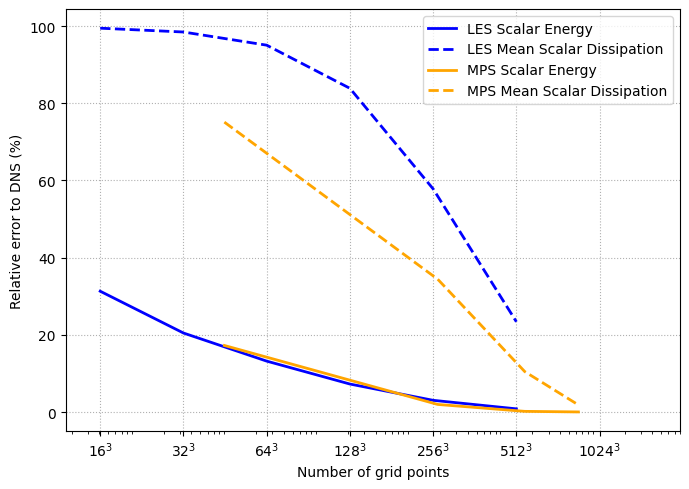

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# LES data
les_N = np.array([16, 32, 64, 128, 256, 512])**3
les_scalar_energy = np.array([31.3, 20.47, 13.19, 7.25, 3.03, 0.82])
les_scalar_diss   = np.array([99.45, 98.46, 95.05, 83.87, 57.81, 23.38])

# MPS data
mps_N = np.array([45, 266, 549, 858])**3
mps_scalar_energy = np.array([17.24, 1.96, 0.17, 0.02])
mps_scalar_diss   = np.array([75.11, 34.40, 10.47, 1.84])

plt.figure(figsize=(7,5))

# LES
plt.plot(les_N, les_scalar_energy,
         color='blue', linewidth=2, linestyle='-',
         label='LES Scalar Energy')

plt.plot(les_N, les_scalar_diss,
         color='blue', linewidth=2, linestyle='--',
         label='LES Mean Scalar Dissipation')

# MPS
plt.plot(mps_N, mps_scalar_energy,
         color='orange', linewidth=2, linestyle='-',
         label='MPS Scalar Energy')

plt.plot(mps_N, mps_scalar_diss,
         color='orange', linewidth=2, linestyle='--',
         label='MPS Mean Scalar Dissipation')

plt.xscale('log')
plt.xlim(12**3, 2000**3)
# ticks: 2^3, 4^3, ..., 512^3
tick_base = np.array([16, 32, 64, 128, 256, 512, 1024])
tick_pos = tick_base**3
tick_lbl = [rf'${n}^3$' for n in tick_base]

plt.xticks(tick_pos, tick_lbl)

plt.xlabel('Number of grid points')
plt.ylabel('Relative error to DNS (%)')

plt.grid(True, which='major', linestyle=':', linewidth=0.8)
plt.legend(loc='upper right')

plt.tight_layout()
plt.savefig('LES_vs_MPS_relative_error.png', dpi=300)
plt.show()

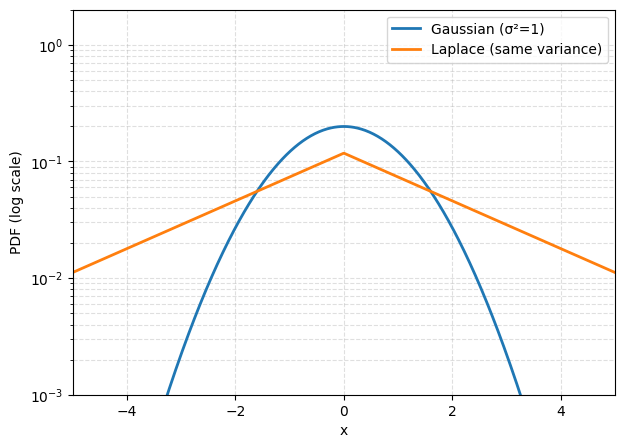

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# domain (wide to see extremes)
x = np.linspace(-30, 30, 2000)

# parameters (same mean = 0)
sigma = 2
b = 3*sigma/np.sqrt(2)     # Laplace variance = 1
gamma = 1.0          # Cauchy scale

# PDFs
gaussian = (1/np.sqrt(2*np.pi*sigma**2)) * np.exp(-x**2/(2*sigma**2))
laplace  = (1/(2*b)) * np.exp(-np.abs(x)/b)
cauchy   = 1/(np.pi*gamma*(1+(x/gamma)**2))

plt.figure(figsize=(7,5))

plt.plot(x/sigma, gaussian, label='Gaussian (σ²=1)', linewidth=2)
plt.plot(x/sigma, laplace,  label='Laplace (same variance)', linewidth=2)
# plt.plot(x, cauchy,   label='Cauchy (no variance)', linewidth=2)

plt.yscale('log')   # important to see tail differences
plt.xlabel('x')
# plt.xscale('log')
plt.ylabel('PDF (log scale)')
plt.legend()
plt.ylim(1e-3, 2)
plt.xlim(-5, 5)
plt.grid(True, which='both', linestyle='--', alpha=0.4)

plt.show()

(-8.1985, 8.1985, -9.5665, 9.5665)

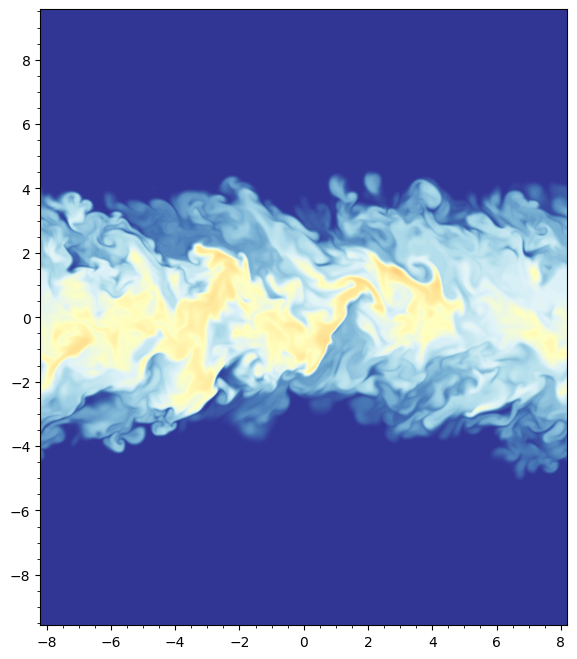

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
#20tj = 0.0099
#40tj = 0.0198
filename = "/Users/massen/Desktop/high/2Y_CO/jet_Y_CO_0198.dat"
# filename = "/Users/massen/Desktop/high/jet_u_0228.dat"

# these dimensions are given in the s3d files: jet/data/input/s3d.in*
# nx = 576
# ny = 672
# nz = 384
# ntnx = 512
# ntny = 512
# ntnz = 256
# lx = 0.8625 # cm
# ly = 1.0065 # cm
# lz = 0.5745 # cm

nx = 864
ny = 1008
nz = 576
ntnx = 512
ntny = 512
ntnz = 512
lx = 1.6397 # cm
ly = 1.9133 # cm
lz = 1.0925 # cm

data = np.fromfile(filename, dtype=">f") # try both dtype=">f" and dtype="<f"
                                            # whichever gives correct results

data_grid = data.reshape([nz, ny, nx])

#### Take a ntn*ntn*ntn cube out of the center of data_grid and name it cube
# start_z = nz//2 - ntnz//2
# start_y = ny//2 - ntny//2
# start_x = nx//2 - ntnx//2
# start_x = 0
# cube = data_grid[start_z:start_z+ntnz, start_y:start_y+ntny, start_x:start_x+ntnx]
# dx = lx/nx
# dy = ly/ny
# dz = lz/nz
# x_1d = np.linspace(0, ntnx*dx, ntnx)
# y_1d = np.linspace(0, ntny*dy, ntny)

x_1d = np.linspace(-lx/2*10, lx/2*10, nx)
y_1d = np.linspace(-ly/2*10, ly/2*10, ny)

x, y = np.meshgrid(x_1d, y_1d)

data_grid[nz//2, :, :][data_grid[nz//2, :, :] < 0] = 0

# plot middle plane
contour = plt.contourf(x, y, data_grid[nz//2, :, :], cmap='RdYlBu_r', levels=np.linspace(0, 0.6, 200))
# plt.colorbar(contour)
# plt.contourf(x, y, cube[ntnz//2, :, :], cmap='inferno',levels=50)
# plt.xticks([])
plt.yticks([-8,-6,-4,-2,0,2,4,6,8])
plt.minorticks_on()
plt.gcf().set_size_inches(6.8, 8)  # Example: change width and height (inches)
plt.axis('on')                    # Optionally: 'on' or 'off' (or customize)
# plt.savefig("plt.png")


-1.7763567e-15

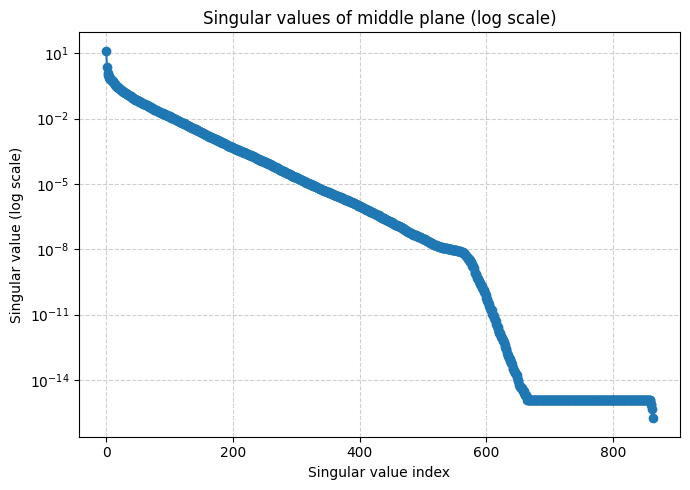

In [3]:
# Now compute and plot singular values of the middle plane
middle_plane = data_grid[nz//2, :, :]  # shape (ny, nx)
U, s, VT = np.linalg.svd(middle_plane, full_matrices=False)

plt.figure(figsize=(7, 5))
plt.semilogy(s, marker='o')
plt.title('Singular values of middle plane (log scale)')
plt.xlabel('Singular value index')
plt.ylabel('Singular value (log scale)')
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

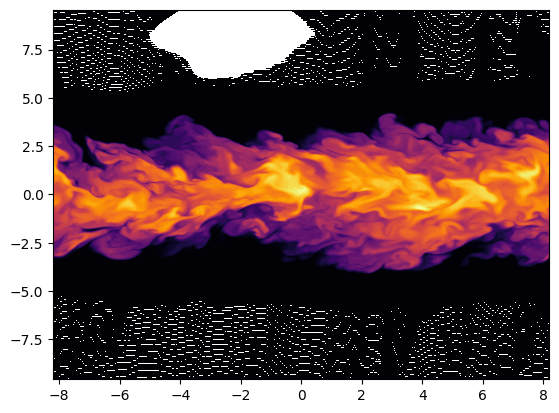

In [7]:
import numpy as np
import matplotlib.pyplot as plt

filename = "/Users/massen/Desktop/high/jet_0198/jet_Y_CO_0198.dat"


nx = 864
ny = 1008
nz = 576
ntnx = 512
ntny = 512
ntnz = 512
lx = 1.6397 # cm
ly = 1.9133 # cm
lz = 1.0925 # cm

data = np.fromfile(filename, dtype=">f") # try both dtype=">f" and dtype="<f"
                                            # whichever gives correct results

data_grid = data.reshape([nz, ny, nx])
# data_grid = data_grid.transpose(2, 1, 0)

#### Take a ntn*ntn*ntn cube out of the center of data_grid and name it cube
# start_z = nz//2 - ntnz//2
# start_y = ny//2 - ntny//2
# start_x = nx//2 - ntnx//2
# start_x = 0
# cube = data_grid[start_x:start_x+ntnx, start_y:start_y+ntny, start_z:start_z+ntnz]
# dx = lx/nx
# dy = ly/ny
# dz = lz/nz

# x_1d = np.linspace(0, ntnx*dx, ntnx)
# y_1d = np.linspace(0, ntny*dy, ntny)

x_1d = np.linspace(-lx/2*10, lx/2*10, nx)
y_1d = np.linspace(-ly/2*10, ly/2*10, ny)

x, y = np.meshgrid(x_1d, y_1d)

# data_grid[nz//2, :, :][data_grid[nz//2, :, :] < 0] = 0

# plot middle plane
# contour = plt.contourf(x, y, data_grid[1, :, :], cmap='RdYlBu_r', levels=np.linspace(0, 0.8, 200))
contour = plt.contourf(x, y, data_grid[0, :, :], cmap='inferno',levels=50)

# plt.colorbar(contour)
# plt.contourf(x, y, cube[:, :, ntnx//2-1].transpose(), cmap='inferno',levels=50)
# plt.xticks([])
# plt.yticks([-8,-6,-4,-2,0,2,4,6,8])
# plt.minorticks_on()
# plt.gcf().set_size_inches(6.8, 8)  # Example: change width and height (inches)
# plt.axis('on')                    # Optionally: 'on' or 'off' (or customize)
# plt.savefig("plt.png")
# plt.colorbar()
# plt.axis('equal')

In [ ]:
# np.shape(data_grid[:, :, nz//2])
# lx/ly*8

6.856007944389275

In [3]:
nxx = 108
nyy = 126
nzz = 72

print(nx/nxx, ny/nyy, nz/nzz)

8.0 8.0 8.0


In [61]:
import glob
import re
import numpy as np
import pandas as pd
from scipy.io import loadmat
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

# ── Config ────────────────────────────────────────────────────────────────────
MAT_PATTERN = "flow_parameters_chi_*.mat"   # glob pattern; edit path if needed
OUTPUT_FILE = "flow_parameters.xlsx"

PARAMS = [
    "E", "eta", "fidelity_dux", "fidelity_duy", "fidelity_duz",
    "fidelity_eps", "L", "Lambda", "mean_eps", "Rey_Taylor",
    "T_L", "tau", "u_prime",
]

# ── Helpers ───────────────────────────────────────────────────────────────────
def chi_from_name(path: str) -> int:
    m = re.search(r"chi_(\d+)", path)
    return int(m.group(1)) if m else 0


def flatten(v):
    """Return a numpy array squeezed to 1-D, or a scalar."""
    arr = np.squeeze(v)
    if arr.ndim == 0:
        return float(arr)
    return arr.astype(float)


def load_file(path: str) -> dict:
    raw = loadmat(path, squeeze_me=True)
    return {k: flatten(raw[k]) for k in PARAMS if k in raw}


# ── Load all files ────────────────────────────────────────────────────────────
files = sorted(glob.glob(MAT_PATTERN), key=chi_from_name)
if not files:
    raise FileNotFoundError(f"No files matched '{MAT_PATTERN}'. "
                            "Run this script in the same folder as the .mat files.")

chi_values = [chi_from_name(f) for f in files]
data = {chi: load_file(f) for chi, f in zip(chi_values, files)}

# ── Build rows ────────────────────────────────────────────────────────────────
# Detect max vector length across all params/files
def vec_len(v):
    return len(v) if isinstance(v, np.ndarray) else 1

max_len = max(
    vec_len(data[chi].get(p, np.array([])))
    for chi in chi_values
    for p in PARAMS
)

sub_labels = [f"component_{i+1}" for i in range(max_len)] if max_len > 1 else ["value"]

rows = []
for p in PARAMS:
    for i in range(max_len):
        label = p if max_len == 1 else f"{p} [{sub_labels[i]}]"
        row = {"Parameter": label}
        for chi in chi_values:
            v = data[chi].get(p)
            if v is None:
                row[f"χ = {chi}"] = ""
            elif isinstance(v, np.ndarray):
                row[f"χ = {chi}"] = v[i] if i < len(v) else ""
            else:
                row[f"χ = {chi}"] = v if i == 0 else ""
        rows.append(row)

df = pd.DataFrame(rows)
df.to_excel(OUTPUT_FILE, index=False, sheet_name="Flow Parameters")

# ── Formatting ────────────────────────────────────────────────────────────────
wb = load_workbook(OUTPUT_FILE)
ws = wb.active

HEADER_FILL   = PatternFill("solid", start_color="1F4E79")
PARAM_FILL    = PatternFill("solid", start_color="D6E4F0")
ALT_FILL      = PatternFill("solid", start_color="EBF5FB")
WHITE_FILL    = PatternFill("solid", start_color="FFFFFF")
HEADER_FONT   = Font(name="Arial", bold=True, color="FFFFFF", size=11)
PARAM_FONT    = Font(name="Arial", bold=True, size=10)
DATA_FONT     = Font(name="Arial", size=10)
BORDER_SIDE   = Side(style="thin", color="BFBFBF")
THIN_BORDER   = Border(left=BORDER_SIDE, right=BORDER_SIDE,
                       top=BORDER_SIDE,  bottom=BORDER_SIDE)

# Header row
for cell in ws[1]:
    cell.font      = HEADER_FONT
    cell.fill      = HEADER_FILL
    cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    cell.border    = THIN_BORDER

ws.row_dimensions[1].height = 30

# Data rows
param_group = None
group_idx   = -1
for row_idx, row in enumerate(ws.iter_rows(min_row=2), start=2):
    base_param = row[0].value.split(" [")[0] if row[0].value else ""
    if base_param != param_group:
        param_group = base_param
        group_idx  += 1

    fill = PARAM_FILL if group_idx % 2 == 0 else ALT_FILL

    for col_idx, cell in enumerate(row):
        cell.font   = PARAM_FONT if col_idx == 0 else DATA_FONT
        cell.fill   = fill
        cell.border = THIN_BORDER
        if col_idx == 0:
            cell.alignment = Alignment(horizontal="left", vertical="center")
        else:
            cell.alignment = Alignment(horizontal="center", vertical="center")
            if isinstance(cell.value, float):
                cell.number_format = "0.0000E+00" if abs(cell.value) < 1e-3 or abs(cell.value) > 1e4 else "0.0000"

# Column widths
ws.column_dimensions["A"].width = 26
for col_idx in range(2, ws.max_column + 1):
    ws.column_dimensions[get_column_letter(col_idx)].width = 18

ws.freeze_panes = "B2"

wb.save(OUTPUT_FILE)
print(f"Saved → {OUTPUT_FILE}  ({len(files)} files, {len(rows)} rows)")

Saved → flow_parameters.xlsx  (4 files, 39 rows)
